In [1]:
# =============================================================================
# CELL 1 — Environment, reproducibility, paths, and manuscript constants
# =============================================================================
#
# Paper:
# A Complementarity-Driven Framework for Radio and Vision Sensor Fusion
# in Massive-MIMO Indoor Localization
#
# Purpose:
# Reproduction / verification notebook accompanying the manuscript.
#
# IMPORTANT:
#   * Odd-numbered grid trajectories -> training
#   * Even-numbered grid trajectories -> testing
#   * Random/free-heading trajectories are NEVER used for training
#   * Radio target = antenna (radio) Qualisys ground truth
#   * Position units used during training = metres
#   * Reported localization errors = millimetres
# =============================================================================

from pathlib import Path
import os
import sys
import json
import random
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import soundfile as sf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader

from scipy.stats import pearsonr, spearmanr, wilcoxon
from scipy.spatial import cKDTree

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


# -----------------------------------------------------------------------------
# 1. Reproducibility
# -----------------------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Deterministic settings wherever supported.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# -----------------------------------------------------------------------------
# 2. Dataset root
# -----------------------------------------------------------------------------
# Reviewers can either:
#
#   A) set an environment variable before starting Jupyter:
#          export LUVIRA_ROOT=/path/to/luvira
#
#   OR
#
#   B) replace "/data/luvira" below with their own dataset directory.
# -----------------------------------------------------------------------------

ROOT = Path(
    os.environ.get("LUVIRA_ROOT", "/data/luvira")
).expanduser().resolve()

RAW = ROOT / "raw"
META = ROOT / "metadata"

# Binary radio cache generated later in this notebook.
RADIO_CACHE = ROOT / "processed" / "radio_npy"

# Everything produced by this reviewer-verification notebook is kept here.
OUT = ROOT / "reports" / "reviewer_reproduction"

FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
MODEL_DIR = OUT / "models"
CACHE_DIR = OUT / "cache"

for directory in [
    OUT,
    FIG_DIR,
    TABLE_DIR,
    MODEL_DIR,
    CACHE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# -----------------------------------------------------------------------------
# 3. Hardware
# -----------------------------------------------------------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# -----------------------------------------------------------------------------
# 4. LuViRA / manuscript acquisition constants
# -----------------------------------------------------------------------------
N_ANTENNAS = 100
N_SUBCARRIERS = 100

RADIO_RATE_HZ = 100          # 10 ms CSI snapshots
GT_RATE_HZ = 100             # Qualisys ground truth
AUDIO_RATE_HZ = 96_000

# Effective paired RGB/depth rate reported in the manuscript.
VISION_RATE_HZ = 15

ROBOT_SPEED_MPS = 0.1

CENTER_FREQUENCY_HZ = 3.7e9

# Approximate wavelength quoted/used in the manuscript.
WAVELENGTH_M = 0.081

# The paper discusses quarter-wavelength sampling (~20 mm).
QUARTER_WAVELENGTH_MM = WAVELENGTH_M * 1000.0 / 4.0


# -----------------------------------------------------------------------------
# 5. Pre-processing constants used in the experiments
# -----------------------------------------------------------------------------

# Keep every fifth 100-Hz CSI observation.
# At ~0.1 m/s this corresponds to approximately 5 mm of travel.
STRIDE = 5

DEPTH_CLIP_MM = 5000.0

# Depth CNN input resolution stated in the manuscript.
DEPTH_HEIGHT = 48
DEPTH_WIDTH = 64

# Common modality embedding dimension used by the fusion architecture.
EMBED_DIM = 128

# RGB scalar descriptor:
# 4 x 4 spatial cells x
# (R mean + G mean + B mean + grey-level standard deviation)
RGB_GRID = 4
RGB_FEATURE_DIM = 64


# -----------------------------------------------------------------------------
# 6. ImageNet constants
#    Required only for the MobileNetV2 feature-screening experiment.
# -----------------------------------------------------------------------------
IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32,
)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32,
)


# -----------------------------------------------------------------------------
# 7. Training constants corresponding to the manuscript experiments
# -----------------------------------------------------------------------------
RADIO_EPOCHS = 300
FUSION_EPOCHS = 200

RADIO_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 512
FUSION_BATCH_SIZE = 256

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# Three-modality fusion entropy regularizer reported in the manuscript.
THREE_MODALITY_ENTROPY_BETA = 0.05


# -----------------------------------------------------------------------------
# 8. Plot defaults
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# -----------------------------------------------------------------------------
# 9. Environment report
# -----------------------------------------------------------------------------
print("=" * 72)
print("LuViRA — reviewer reproduction pipeline")
print("=" * 72)

print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"OpenCV       : {cv2.__version__}")
print(f"Device       : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

print(f"Dataset root : {ROOT}")
print(f"Output root  : {OUT}")

print("\nManuscript constants")
print(f"  antennas                  : {N_ANTENNAS}")
print(f"  subcarriers               : {N_SUBCARRIERS}")
print(f"  radio / GT rate           : {RADIO_RATE_HZ} Hz")
print(f"  effective RGB/depth rate  : {VISION_RATE_HZ} Hz")
print(f"  wavelength                : {WAVELENGTH_M*1000:.1f} mm")
print(
    f"  quarter wavelength        : "
    f"{QUARTER_WAVELENGTH_MM:.2f} mm"
)
print(f"  CSI stride                : {STRIDE}")
print(f"  depth CNN input           : {DEPTH_HEIGHT} x {DEPTH_WIDTH}")
print(f"  common embedding          : {EMBED_DIM}")
print(f"  radio epochs              : {RADIO_EPOCHS}")
print(f"  fusion epochs             : {FUSION_EPOCHS}")

print("\nCell 1 completed successfully.")

LuViRA — reviewer reproduction pipeline
Python       : 3.11.15
NumPy        : 2.4.3
Pandas       : 3.0.2
PyTorch      : 2.6.0+cu124
OpenCV       : 4.13.0
Device       : cuda
GPU          : NVIDIA A100-PCIE-40GB
Dataset root : /data/luvira
Output root  : /data/luvira/reports/reviewer_reproduction

Manuscript constants
  antennas                  : 100
  subcarriers               : 100
  radio / GT rate           : 100 Hz
  effective RGB/depth rate  : 15 Hz
  wavelength                : 81.0 mm
  quarter wavelength        : 20.25 mm
  CSI stride                : 5
  depth CNN input           : 48 x 64
  common embedding          : 128
  radio epochs              : 300
  fusion epochs             : 200

Cell 1 completed successfully.


In [3]:
# =============================================================================
# CELL 2 — Validate trajectory index and lock the experimental protocol
# =============================================================================
#
# This cell establishes the exact trajectory population used throughout
# the manuscript.
#
# Manuscript protocol:
#   Grid, radio + GT             : 68 trajectories
#   Training grids, odd IDs      : 35 trajectories
#   Test grids, even IDs         : 33 trajectories
#   Random, radio + GT           :  9 trajectories
#   Random multimodal OOD        :  5 trajectories
#
# IMPORTANT:
#   No samples are loaded or trained here.
#   This cell only verifies file identity, modality availability,
#   and the trajectory-disjoint odd/even split.
# =============================================================================

import re
from pathlib import Path

INDEX_CSV = META / "trajectory_index.csv"

assert INDEX_CSV.exists(), (
    f"Trajectory index not found:\n{INDEX_CSV}\n\n"
    "The reviewer package must include metadata/trajectory_index.csv."
)

idx = pd.read_csv(INDEX_CSV)

print("=" * 72)
print("CELL 2 — TRAJECTORY INDEX AND EXPERIMENTAL PROTOCOL")
print("=" * 72)
print(f"Index file : {INDEX_CSV}")
print(f"Index rows : {len(idx)}")


# -----------------------------------------------------------------------------
# 1. Required index schema
# -----------------------------------------------------------------------------
#
# We use explicit paths rather than reconstructing trajectory filenames
# during later training/evaluation cells.
# -----------------------------------------------------------------------------

REQUIRED_COLUMNS = [
    "trajectory_id",
    "kind",
    "radio_mat",
    "gt_radio_csv",
    "vision_rgb_dir",
    "vision_depth_dir",
]

missing_columns = [
    c for c in REQUIRED_COLUMNS
    if c not in idx.columns
]

assert not missing_columns, (
    "trajectory_index.csv is missing required columns:\n"
    f"{missing_columns}"
)

idx["trajectory_id"] = idx["trajectory_id"].astype(str).str.strip()
idx["kind"] = idx["kind"].astype(str).str.strip().str.lower()

assert idx["trajectory_id"].is_unique, (
    "trajectory_id values must be unique in trajectory_index.csv."
)


# -----------------------------------------------------------------------------
# 2. Portable path resolver
# -----------------------------------------------------------------------------
#
# The supplied trajectory index may contain absolute paths from the machine
# on which it was originally generated. If such a path no longer exists,
# rebase it relative to the LUVIRA_ROOT chosen in Cell 1.
#
# Example:
#     /data/luvira/raw/grid101/rgb
#
# can be rebased to:
#     <LUVIRA_ROOT>/raw/grid101/rgb
# -----------------------------------------------------------------------------

def resolve_dataset_path(value):
    """Resolve an indexed LuViRA path against the ROOT from Cell 1."""

    if pd.isna(value):
        return None

    s = str(value).strip()

    if s == "":
        return None

    p = Path(s).expanduser()

    if p.exists():
        return p.resolve()

    # Normalise path separators for portability.
    s_norm = s.replace("\\", "/")

    rebasing_rules = [
        ("/raw/",       RAW),
        ("/metadata/",  META),
        ("/processed/", ROOT / "processed"),
        ("/reports/",   ROOT / "reports"),
    ]

    for marker, base in rebasing_rules:
        if marker in s_norm:
            suffix = s_norm.split(marker, 1)[1]
            candidate = base / suffix

            if candidate.exists():
                return candidate.resolve()

            # Return candidate even if missing so the subsequent audit
            # reports the meaningful expected location.
            return candidate

    return p


idx["radio_mat_path"] = idx["radio_mat"].apply(resolve_dataset_path)
idx["gt_radio_path"] = idx["gt_radio_csv"].apply(resolve_dataset_path)
idx["rgb_dir_path"] = idx["vision_rgb_dir"].apply(resolve_dataset_path)
idx["depth_dir_path"] = idx["vision_depth_dir"].apply(resolve_dataset_path)


# -----------------------------------------------------------------------------
# 3. File/modality availability checks
# -----------------------------------------------------------------------------

def file_exists(p):
    return (
        p is not None
        and isinstance(p, Path)
        and p.is_file()
    )


def png_directory_exists(p):
    return (
        p is not None
        and isinstance(p, Path)
        and p.is_dir()
        and any(p.glob("*.png"))
    )


idx["radio_ok"] = idx["radio_mat_path"].apply(file_exists)
idx["gt_radio_ok"] = idx["gt_radio_path"].apply(file_exists)

idx["rgb_ok"] = idx["rgb_dir_path"].apply(
    png_directory_exists
)

idx["depth_ok"] = idx["depth_dir_path"].apply(
    png_directory_exists
)


# -----------------------------------------------------------------------------
# 4. Extract numerical grid ID
# -----------------------------------------------------------------------------

def get_grid_number(trajectory_id):
    m = re.fullmatch(
        r"grid(\d+)",
        str(trajectory_id).lower()
    )

    if m is None:
        return np.nan

    return int(m.group(1))


idx["grid_num"] = idx["trajectory_id"].apply(
    get_grid_number
)


# -----------------------------------------------------------------------------
# 5. Radio-usable grid population
# -----------------------------------------------------------------------------
#
# A trajectory is part of the supervised grid experiment only when both:
#
#   1. its radio recording exists
#   2. its radio/antenna Qualisys GT exists
#
# The radio GT is intentionally used rather than camera or robot GT.
# -----------------------------------------------------------------------------

grid_all = idx[
    (idx["kind"] == "grid")
    & idx["radio_ok"]
    & idx["gt_radio_ok"]
].copy()

grid_all = (
    grid_all
    .sort_values("grid_num")
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# 6. Odd/even trajectory-disjoint train/test split
# -----------------------------------------------------------------------------

train_grids = grid_all[
    grid_all["grid_num"] % 2 == 1
].copy().reset_index(drop=True)

test_grids = grid_all[
    grid_all["grid_num"] % 2 == 0
].copy().reset_index(drop=True)

TRAIN_GRID_IDS = train_grids["trajectory_id"].tolist()
TEST_GRID_IDS = test_grids["trajectory_id"].tolist()


# -----------------------------------------------------------------------------
# 7. Radio-usable random/free-heading population
# -----------------------------------------------------------------------------

random_radio = idx[
    (idx["kind"] == "random")
    & idx["radio_ok"]
    & idx["gt_radio_ok"]
].copy()

random_radio = (
    random_radio
    .sort_values("trajectory_id")
    .reset_index(drop=True)
)

RANDOM_RADIO_IDS = random_radio[
    "trajectory_id"
].tolist()


# -----------------------------------------------------------------------------
# 8. Exact five-trajectory multimodal OOD set used in Table 7
# -----------------------------------------------------------------------------
#
# Dataset naming contains the historical "paople" spelling in some releases.
# Support both spellings while assigning the paper-readable label
# "random_manual (humans)" later.
# -----------------------------------------------------------------------------

human_candidates = [
    "random_manual_paople2",
    "random_manual_people2",
]

HUMAN_OOD_ID = next(
    (
        tid for tid in human_candidates
        if tid in set(idx["trajectory_id"])
    ),
    None,
)

assert HUMAN_OOD_ID is not None, (
    "Could not locate the human-present random trajectory expected "
    "for the manuscript's five-trajectory OOD experiment.\n"
    f"Tried: {human_candidates}"
)

OOD_FUSION_IDS = [
    "random_circle1",
    "random_manual4",
    "random_manual5",
    HUMAN_OOD_ID,
    "random_rect2",
]

missing_ood_ids = [
    tid for tid in OOD_FUSION_IDS
    if tid not in set(idx["trajectory_id"])
]

assert not missing_ood_ids, (
    "Missing manuscript OOD trajectory IDs:\n"
    f"{missing_ood_ids}"
)

random_ood = (
    idx[
        idx["trajectory_id"].isin(OOD_FUSION_IDS)
    ]
    .copy()
)

# Preserve manuscript order.
random_ood["_paper_order"] = random_ood[
    "trajectory_id"
].map({
    tid: i
    for i, tid in enumerate(OOD_FUSION_IDS)
})

random_ood = (
    random_ood
    .sort_values("_paper_order")
    .drop(columns="_paper_order")
    .reset_index(drop=True)
)


# Human-readable trajectory labels matching Table 7.
OOD_PAPER_LABEL = {
    "random_circle1": "random_circle1",
    "random_manual4": "random_manual4",
    "random_manual5": "random_manual5",
    HUMAN_OOD_ID: "random_manual (humans)",
    "random_rect2": "random_rect2",
}

random_ood["paper_label"] = random_ood[
    "trajectory_id"
].map(OOD_PAPER_LABEL)


# -----------------------------------------------------------------------------
# 9. Hard protocol assertions
# -----------------------------------------------------------------------------
#
# These assertions are intentional.
#
# DO NOT change the expected numbers merely to make the notebook run.
# If an assertion fails, the dataset/index differs from the manuscript
# population and must be investigated.
# -----------------------------------------------------------------------------

assert len(grid_all) == 68, (
    f"Expected 68 radio+GT grid trajectories, "
    f"found {len(grid_all)}."
)

assert len(train_grids) == 35, (
    f"Expected 35 odd-ID training grids, "
    f"found {len(train_grids)}."
)

assert len(test_grids) == 33, (
    f"Expected 33 even-ID test grids, "
    f"found {len(test_grids)}."
)

assert len(random_radio) == 9, (
    f"Expected 9 radio+GT random trajectories, "
    f"found {len(random_radio)}."
)

assert len(random_ood) == 5, (
    f"Expected 5 multimodal OOD trajectories, "
    f"found {len(random_ood)}."
)


# There must be zero trajectory overlap.
assert set(TRAIN_GRID_IDS).isdisjoint(TEST_GRID_IDS), (
    "Training and test trajectories overlap."
)

assert set(TRAIN_GRID_IDS).isdisjoint(RANDOM_RADIO_IDS), (
    "Random trajectories must never appear in training."
)

assert set(TEST_GRID_IDS).isdisjoint(RANDOM_RADIO_IDS), (
    "Random trajectories must remain a separate OOD population."
)


# Verify parity rule explicitly.
assert all(
    train_grids["grid_num"] % 2 == 1
), "Training set contains a non-odd grid ID."

assert all(
    test_grids["grid_num"] % 2 == 0
), "Test set contains a non-even grid ID."


# -----------------------------------------------------------------------------
# 10. Vision availability required by the manuscript grid experiments
# -----------------------------------------------------------------------------

bad_grid_rgb = grid_all.loc[
    ~grid_all["rgb_ok"],
    "trajectory_id"
].tolist()

bad_grid_depth = grid_all.loc[
    ~grid_all["depth_ok"],
    "trajectory_id"
].tolist()

assert not bad_grid_rgb, (
    "The following radio-usable grids have no readable RGB frames:\n"
    f"{bad_grid_rgb}"
)

assert not bad_grid_depth, (
    "The following radio-usable grids have no readable depth frames:\n"
    f"{bad_grid_depth}"
)


# -----------------------------------------------------------------------------
# 11. Verify the exact five OOD trajectories contain the required modalities
# -----------------------------------------------------------------------------
#
# Notice that audio is NOT part of this requirement.
# The paper's OOD fusion experiment requires:
#
#        radio + radio GT + depth + colour
# -----------------------------------------------------------------------------

ood_required = [
    "radio_ok",
    "gt_radio_ok",
    "rgb_ok",
    "depth_ok",
]

for col in ood_required:
    bad = random_ood.loc[
        ~random_ood[col],
        "trajectory_id"
    ].tolist()

    assert not bad, (
        f"OOD modality check failed for '{col}':\n"
        f"{bad}"
    )


# -----------------------------------------------------------------------------
# 12. Reviewer-readable protocol summary
# -----------------------------------------------------------------------------

protocol_summary = pd.DataFrame({
    "Population": [
        "Grid: radio + antenna GT",
        "Training: odd grid IDs",
        "Test: even grid IDs",
        "Random: radio + antenna GT",
        "Random OOD: radio + depth + colour + antenna GT",
    ],
    "Observed": [
        len(grid_all),
        len(train_grids),
        len(test_grids),
        len(random_radio),
        len(random_ood),
    ],
    "Manuscript": [
        68,
        35,
        33,
        9,
        5,
    ],
})

protocol_summary["Match"] = (
    protocol_summary["Observed"]
    == protocol_summary["Manuscript"]
)

print("\nExperimental population")
print("-" * 72)
print(protocol_summary.to_string(index=False))


print("\nTraining trajectories")
print("-" * 72)
print(", ".join(TRAIN_GRID_IDS))


print("\nTest trajectories")
print("-" * 72)
print(", ".join(TEST_GRID_IDS))


print("\nRadio-usable random trajectories")
print("-" * 72)
print(", ".join(RANDOM_RADIO_IDS))


print("\nFive multimodal OOD trajectories used in the paper")
print("-" * 72)

print(
    random_ood[
        [
            "trajectory_id",
            "paper_label",
            "radio_ok",
            "gt_radio_ok",
            "rgb_ok",
            "depth_ok",
        ]
    ].to_string(index=False)
)


# -----------------------------------------------------------------------------
# 13. Save immutable protocol records for reviewer verification
# -----------------------------------------------------------------------------

protocol_summary.to_csv(
    TABLE_DIR / "protocol_summary.csv",
    index=False,
)

manifest_columns = [
    "trajectory_id",
    "kind",
    "grid_num",
    "radio_ok",
    "gt_radio_ok",
    "rgb_ok",
    "depth_ok",
]

grid_manifest = grid_all[
    manifest_columns
].copy()

grid_manifest["split"] = np.where(
    grid_manifest["grid_num"] % 2 == 1,
    "train",
    "test",
)

grid_manifest.to_csv(
    TABLE_DIR / "grid_protocol_manifest.csv",
    index=False,
)


random_ood[
    [
        "trajectory_id",
        "paper_label",
        "radio_ok",
        "gt_radio_ok",
        "rgb_ok",
        "depth_ok",
    ]
].to_csv(
    TABLE_DIR / "ood_protocol_manifest.csv",
    index=False,
)


protocol_json = {
    "seed": SEED,
    "grid_radio_gt": len(grid_all),
    "train_odd_grids": len(train_grids),
    "test_even_grids": len(test_grids),
    "random_radio_gt": len(random_radio),
    "ood_multimodal": len(random_ood),
    "train_grid_ids": TRAIN_GRID_IDS,
    "test_grid_ids": TEST_GRID_IDS,
    "random_radio_ids": RANDOM_RADIO_IDS,
    "ood_fusion_ids": OOD_FUSION_IDS,
}

with open(
    TABLE_DIR / "protocol.json",
    "w",
) as f:
    json.dump(
        protocol_json,
        f,
        indent=2,
    )


# -----------------------------------------------------------------------------
# 14. Confirm saved reviewer-verification files
# -----------------------------------------------------------------------------

print("\nSaved reviewer protocol files:")
print(f"  {TABLE_DIR / 'protocol_summary.csv'}")
print(f"  {TABLE_DIR / 'grid_protocol_manifest.csv'}")
print(f"  {TABLE_DIR / 'ood_protocol_manifest.csv'}")
print(f"  {TABLE_DIR / 'protocol.json'}")

print("\n" + "=" * 72)
print("CELL 2 PASSED — experimental protocol is locked.")
print("=" * 72)

CELL 2 — TRAJECTORY INDEX AND EXPERIMENTAL PROTOCOL
Index file : /data/luvira/metadata/trajectory_index.csv
Index rows : 90

Experimental population
------------------------------------------------------------------------
                                     Population  Observed  Manuscript  Match
                       Grid: radio + antenna GT        68          68   True
                         Training: odd grid IDs        35          35   True
                            Test: even grid IDs        33          33   True
                     Random: radio + antenna GT         9           9   True
Random OOD: radio + depth + colour + antenna GT         5           5   True

Training trajectories
------------------------------------------------------------------------
grid101, grid103, grid105, grid107, grid109, grid111, grid113, grid115, grid117, grid119, grid121, grid123, grid125, grid127, grid129, grid131, grid133, grid135, grid139, grid141, grid143, grid145, grid149, grid151, grid

CELL 3 — GROUND-TRUTH TRUSTWORTHINESS AUDIT
Reference trajectory : grid101

Qualisys files
------------------------------------------------------------------------
radio   : /data/luvira/raw/ground_truth/radio/Grid0101.csv
vision  : /data/luvira/raw/ground_truth/vision/Grid0101.csv
audio   : /data/luvira/raw/ground_truth/audio/Grid0101.csv
robot   : /data/luvira/raw/ground_truth/robot/Grid0101.csv

A. Shared Qualisys clock
------------------------------------------------------------------------
  body  rows duration_s median_dt_ms max_dt_ms  same_rows_as_radio  same_timestamps_as_radio
 radio  4274     42.730       10.000    10.000                True                      True
vision  4274     42.730       10.000    10.000                True                      True
 audio  4274     42.730       10.000    10.000                True                      True
 robot  4274     42.730       10.000    10.000                True                      True

B. Qualisys marker residuals — ref

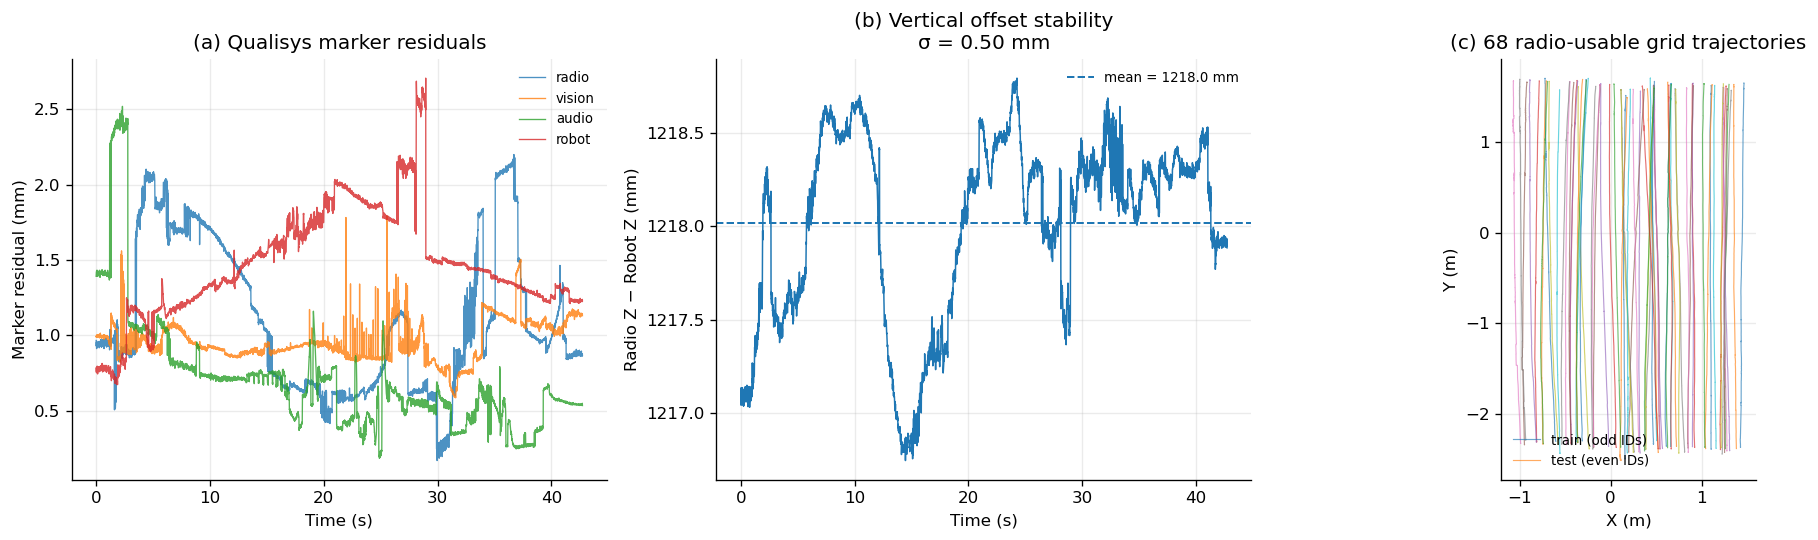


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_02_gt_trustworthiness.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_02_gt_clock_audit.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_02_marker_residuals.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_02_grid_coverage.csv
JSON   : /data/luvira/reports/reviewer_reproduction/tables/figure_02_gt_audit_summary.json

CELL 3 PASSED — GT audit reproduces the manuscript premises.


In [4]:
# =============================================================================
# CELL 3 — Ground-truth trustworthiness audit (reproduces manuscript Fig. 2)
# =============================================================================
#
# This cell verifies, from the raw Qualisys files:
#   (a) four rigid-body GT streams share the same 100-Hz time base;
#   (b) marker residuals are millimetre-scale (max ≈ 2.71 mm on grid101);
#   (c) the radio-to-robot vertical offset is stable to ≈ 0.5 mm;
#   (d) the 68 radio-usable grids cover the stated ≈ 4.2 m × 2.5 m area;
#   (e) the supervised target used later is the RADIO/ANTENNA GT.
#
# No model is trained in this cell.
# =============================================================================

REF_TRAJECTORY = "grid101"
GT_BODIES = ["radio", "vision", "audio", "robot"]

print("=" * 72)
print("CELL 3 — GROUND-TRUTH TRUSTWORTHINESS AUDIT")
print("=" * 72)
print(f"Reference trajectory : {REF_TRAJECTORY}")


# -----------------------------------------------------------------------------
# 1. Resolve the four Qualisys GT files explicitly from the trajectory index
# -----------------------------------------------------------------------------
# Do NOT infer a modality path by string replacement.
# The validated trajectory index remains the source of truth.
# -----------------------------------------------------------------------------

required_gt_columns = {
    "radio": "gt_radio_csv",
    "vision": "gt_vision_csv",
    "audio": "gt_audio_csv",
    "robot": "gt_robot_csv",
}

missing_gt_columns = [
    col for col in required_gt_columns.values()
    if col not in idx.columns
]

assert not missing_gt_columns, (
    "trajectory_index.csv is missing GT path columns: "
    f"{missing_gt_columns}"
)

ref_row = idx.loc[
    idx["trajectory_id"] == REF_TRAJECTORY
].iloc[0]

GT_PATHS = {}

for body, col in required_gt_columns.items():

    p = resolve_dataset_path(ref_row[col])

    assert p is not None and p.is_file(), (
        f"Missing {body} GT file for {REF_TRAJECTORY}: {p}"
    )

    GT_PATHS[body] = p


print("\nQualisys files")
print("-" * 72)

for body, p in GT_PATHS.items():
    print(f"{body:8s}: {p}")


# -----------------------------------------------------------------------------
# 2. Load and validate GT array structure
# -----------------------------------------------------------------------------
#
# LuViRA GT layout used throughout the original analysis:
#
#   column 0      -> timestamp [s]
#   columns 1:4   -> X, Y, Z position [mm]
#   column 7      -> Qualisys marker residual [mm]
#
# Later localization cells use columns 1 and 2 from RADIO GT as the
# two-dimensional antenna position.
# -----------------------------------------------------------------------------

def load_gt(path):

    g = np.loadtxt(path)

    if g.ndim == 1:
        g = g[None, :]

    if g.shape[1] < 8:
        raise ValueError(
            f"GT file {path} has {g.shape[1]} columns; "
            "expected at least 8."
        )

    if not np.isfinite(g[:, :8]).all():
        raise ValueError(
            f"Non-finite values found in required GT columns: {path}"
        )

    return g


gts = {
    body: load_gt(path)
    for body, path in GT_PATHS.items()
}


# -----------------------------------------------------------------------------
# 3. Shared-clock / row-count audit
# -----------------------------------------------------------------------------

sync_rows = []

radio_t = gts["radio"][:, 0]

for body in GT_BODIES:

    g = gts[body]

    t = g[:, 0]

    dt = np.diff(t)

    sync_rows.append({

        "body": body,

        "rows": len(g),

        "duration_s": t[-1] - t[0],

        "median_dt_ms": np.median(dt) * 1000.0,

        "max_dt_ms": np.max(dt) * 1000.0,

        "same_rows_as_radio":
            len(g) == len(gts["radio"]),

        "same_timestamps_as_radio":
            (
                len(g) == len(gts["radio"])
                and np.allclose(
                    t,
                    radio_t,
                    atol=1e-9,
                    rtol=0.0,
                )
            ),
    })


sync_df = pd.DataFrame(sync_rows)


print("\nA. Shared Qualisys clock")
print("-" * 72)

print(
    sync_df.to_string(
        index=False,
        formatters={
            "duration_s":
                lambda x: f"{x:.3f}",

            "median_dt_ms":
                lambda x: f"{x:.3f}",

            "max_dt_ms":
                lambda x: f"{x:.3f}",
        },
    )
)


assert sync_df["same_rows_as_radio"].all(), (
    "The four GT streams do not have identical row counts."
)

assert sync_df["same_timestamps_as_radio"].all(), (
    "The four GT streams do not have identical timestamps."
)

assert np.allclose(
    sync_df["median_dt_ms"].to_numpy(),
    10.0,
    atol=0.01,
), (
    "GT sampling interval is inconsistent with "
    "the 100-Hz protocol."
)


# -----------------------------------------------------------------------------
# 4. Marker residual audit — manuscript Fig. 2(a)
# -----------------------------------------------------------------------------

residual_rows = []

for body in GT_BODIES:

    residual = gts[body][:, 7]

    residual_rows.append({

        "body": body,

        "median_residual_mm":
            np.median(residual),

        "mean_residual_mm":
            np.mean(residual),

        "max_residual_mm":
            np.max(residual),
    })


residual_df = pd.DataFrame(residual_rows)

max_marker_residual_mm = (
    residual_df["max_residual_mm"].max()
)


print(
    "\nB. Qualisys marker residuals — "
    "reference trajectory"
)

print("-" * 72)

print(
    residual_df.to_string(
        index=False,
        formatters={

            "median_residual_mm":
                lambda x: f"{x:.4f}",

            "mean_residual_mm":
                lambda x: f"{x:.4f}",

            "max_residual_mm":
                lambda x: f"{x:.4f}",
        },
    )
)


print(
    f"\nMaximum marker residual = "
    f"{max_marker_residual_mm:.4f} mm "
    f"(manuscript: 2.71 mm)"
)


# Verification against the value reported in the manuscript.
assert np.isclose(
    max_marker_residual_mm,
    2.71,
    atol=0.02,
), (
    "Reference-trajectory maximum marker residual "
    "does not reproduce the manuscript value "
    f"2.71 mm; observed "
    f"{max_marker_residual_mm:.4f} mm."
)


# -----------------------------------------------------------------------------
# 5. Rigid-body stability — manuscript Fig. 2(b)
# -----------------------------------------------------------------------------
#
# IMPORTANT:
# The manuscript specifically examines the RADIO-to-ROBOT VERTICAL
# offset. We therefore test Z stability directly.
#
# We do NOT claim raw X/Y coordinate differences remain within 0.5 mm,
# because rotation of a rigid assembly changes those coordinate
# differences even when the physical body separation remains fixed.
# -----------------------------------------------------------------------------

radio_xyz = gts["radio"][:, 1:4]

robot_xyz = gts["robot"][:, 1:4]

radio_minus_robot = (
    radio_xyz - robot_xyz
)

radio_robot_dz = (
    radio_minus_robot[:, 2]
)


vertical_offset_mean_mm = (
    np.mean(radio_robot_dz)
)

vertical_offset_std_mm = (
    np.std(radio_robot_dz)
)

vertical_offset_ptp_mm = (
    np.ptp(radio_robot_dz)
)


print(
    "\nC. Radio-to-robot vertical rigid-body offset"
)

print("-" * 72)

print(
    f"Mean ΔZ                 : "
    f"{vertical_offset_mean_mm:.3f} mm"
)

print(
    f"Standard deviation      : "
    f"{vertical_offset_std_mm:.3f} mm"
)

print(
    f"Peak-to-peak variation  : "
    f"{vertical_offset_ptp_mm:.3f} mm"
)

print(
    "Manuscript statement    : "
    "vertical stability ≈ 0.5 mm (1σ)"
)


assert vertical_offset_std_mm <= 0.55, (
    "Radio-to-robot vertical offset is less stable "
    "than the manuscript statement: "
    f"observed σ={vertical_offset_std_mm:.3f} mm."
)


# -----------------------------------------------------------------------------
# 6. Verify that localization uses ANTENNA / RADIO ground truth
# -----------------------------------------------------------------------------

print("\nD. Localization target identity")
print("-" * 72)

print(
    "Planar target source : gt_radio_csv"
)

print(
    "Tracked body         : radio transmit antenna"
)

print(
    "Training coordinates : GT columns [1, 2] / 1000 -> metres"
)

print(
    "Reported error       : Euclidean distance -> millimetres"
)


# Demonstrate why using another rigid body as target would introduce
# a substantial fixed physical displacement.

camera_radio_distance_mm = np.linalg.norm(

    gts["vision"][:, 1:4]
    - gts["radio"][:, 1:4],

    axis=1,
)

robot_radio_distance_mm = np.linalg.norm(

    gts["robot"][:, 1:4]
    - gts["radio"][:, 1:4],

    axis=1,
)


print(
    f"Mean camera↔radio body separation : "
    f"{camera_radio_distance_mm.mean():.1f} mm"
)

print(
    f"Mean robot↔radio body separation  : "
    f"{robot_radio_distance_mm.mean():.1f} mm"
)


# -----------------------------------------------------------------------------
# 7. Spatial coverage of all 68 radio-usable grid trajectories
#    — manuscript Fig. 2(c)
# -----------------------------------------------------------------------------

coverage_records = []

all_x_m = []
all_y_m = []


for _, row in grid_all.iterrows():

    g = load_gt(
        row["gt_radio_path"]
    )

    x_m = g[:, 1] / 1000.0

    y_m = g[:, 2] / 1000.0

    split = (
        "train"
        if int(row["grid_num"]) % 2 == 1
        else "test"
    )

    coverage_records.append({

        "trajectory_id":
            row["trajectory_id"],

        "split":
            split,

        "n_gt_rows":
            len(g),

        "x_min_m":
            x_m.min(),

        "x_max_m":
            x_m.max(),

        "y_min_m":
            y_m.min(),

        "y_max_m":
            y_m.max(),
    })

    all_x_m.append(x_m)

    all_y_m.append(y_m)


coverage_df = pd.DataFrame(
    coverage_records
)

all_x_m = np.concatenate(
    all_x_m
)

all_y_m = np.concatenate(
    all_y_m
)


x_span_m = np.ptp(
    all_x_m
)

y_span_m = np.ptp(
    all_y_m
)


# In the LuViRA coordinate convention used by these files,
# the longer ≈4.2-m dimension lies along Y and the ≈2.5-m
# dimension lies along X.

long_span_m = max(
    x_span_m,
    y_span_m,
)

short_span_m = min(
    x_span_m,
    y_span_m,
)


print(
    "\nE. Spatial coverage — "
    "all 68 usable grid trajectories"
)

print("-" * 72)

print(
    f"X extent : "
    f"{all_x_m.min():.3f} to "
    f"{all_x_m.max():.3f} m "
    f"(span {x_span_m:.3f} m)"
)

print(
    f"Y extent : "
    f"{all_y_m.min():.3f} to "
    f"{all_y_m.max():.3f} m "
    f"(span {y_span_m:.3f} m)"
)

print(
    f"Footprint dimensions "
    f"(long × short) : "
    f"{long_span_m:.3f} × "
    f"{short_span_m:.3f} m"
)

print(
    "Manuscript / LuViRA stated area : "
    "approximately 4.2 × 2.5 m"
)

print(
    f"Odd-ID train trajectories        : "
    f"{(coverage_df['split'] == 'train').sum()}"
)

print(
    f"Even-ID test trajectories        : "
    f"{(coverage_df['split'] == 'test').sum()}"
)


assert np.isclose(
    long_span_m,
    4.2,
    atol=0.15,
), (
    f"Long room span {long_span_m:.3f} m "
    "is inconsistent with ≈4.2 m."
)


assert np.isclose(
    short_span_m,
    2.5,
    atol=0.15,
), (
    f"Short room span {short_span_m:.3f} m "
    "is inconsistent with ≈2.5 m."
)


# -----------------------------------------------------------------------------
# 8. Reproduce manuscript Figure 2
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.6),
)


# -------------------------------------------------------------------------
# Figure 2(a):
# Per-body Qualisys marker residuals over reference trajectory
# -------------------------------------------------------------------------

reference_time_s = (
    radio_t - radio_t[0]
)


for body in GT_BODIES:

    axes[0].plot(

        reference_time_s,

        gts[body][:, 7],

        linewidth=0.8,

        alpha=0.8,

        label=body,
    )


axes[0].set_xlabel(
    "Time (s)"
)

axes[0].set_ylabel(
    "Marker residual (mm)"
)

axes[0].set_title(
    "(a) Qualisys marker residuals"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Figure 2(b):
# Radio-to-robot vertical offset
# -------------------------------------------------------------------------

axes[1].plot(

    reference_time_s,

    radio_robot_dz,

    linewidth=0.9,
)


axes[1].axhline(

    vertical_offset_mean_mm,

    linestyle="--",

    linewidth=1.2,

    label=(
        f"mean = "
        f"{vertical_offset_mean_mm:.1f} mm"
    ),
)


axes[1].set_xlabel(
    "Time (s)"
)

axes[1].set_ylabel(
    "Radio Z − Robot Z (mm)"
)

axes[1].set_title(
    "(b) Vertical offset stability\n"
    f"σ = {vertical_offset_std_mm:.2f} mm"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Figure 2(c):
# 68 radio-usable grid trajectories, odd/even split
# -------------------------------------------------------------------------

train_first = True
test_first = True


for _, row in grid_all.iterrows():

    g = load_gt(
        row["gt_radio_path"]
    )

    x_m = (
        g[:, 1] / 1000.0
    )

    y_m = (
        g[:, 2] / 1000.0
    )

    is_train = (
        int(row["grid_num"]) % 2 == 1
    )

    if is_train:

        axes[2].plot(

            x_m,

            y_m,

            linewidth=0.7,

            alpha=0.65,

            label=(
                "train (odd IDs)"
                if train_first
                else None
            ),
        )

        train_first = False

    else:

        axes[2].plot(

            x_m,

            y_m,

            linewidth=0.7,

            alpha=0.65,

            label=(
                "test (even IDs)"
                if test_first
                else None
            ),
        )

        test_first = False


axes[2].set_xlabel(
    "X (m)"
)

axes[2].set_ylabel(
    "Y (m)"
)

axes[2].set_title(
    "(c) 68 radio-usable grid trajectories"
)

axes[2].set_aspect(
    "equal",
    adjustable="box",
)

axes[2].legend(
    frameon=False,
    fontsize=8,
)

axes[2].grid(
    alpha=0.25
)


fig.tight_layout()


fig2_path = (
    FIG_DIR
    / "figure_02_gt_trustworthiness.png"
)

fig.savefig(
    fig2_path,
    bbox_inches="tight",
)

plt.show()


# -----------------------------------------------------------------------------
# 9. Save numerical values supporting Figure 2
# -----------------------------------------------------------------------------

sync_df.to_csv(

    TABLE_DIR
    / "figure_02_gt_clock_audit.csv",

    index=False,
)


residual_df.to_csv(

    TABLE_DIR
    / "figure_02_marker_residuals.csv",

    index=False,
)


coverage_df.to_csv(

    TABLE_DIR
    / "figure_02_grid_coverage.csv",

    index=False,
)


gt_audit_summary = {

    "reference_trajectory":
        REF_TRAJECTORY,

    "four_gt_streams_same_rows":
        bool(
            sync_df[
                "same_rows_as_radio"
            ].all()
        ),

    "four_gt_streams_same_timestamps":
        bool(
            sync_df[
                "same_timestamps_as_radio"
            ].all()
        ),

    "maximum_marker_residual_mm":
        float(
            max_marker_residual_mm
        ),

    "radio_robot_vertical_offset_mean_mm":
        float(
            vertical_offset_mean_mm
        ),

    "radio_robot_vertical_offset_std_mm":
        float(
            vertical_offset_std_mm
        ),

    "grid_x_span_m":
        float(
            x_span_m
        ),

    "grid_y_span_m":
        float(
            y_span_m
        ),

    "grid_long_span_m":
        float(
            long_span_m
        ),

    "grid_short_span_m":
        float(
            short_span_m
        ),

    "n_grid_trajectories":
        int(
            len(grid_all)
        ),

    "n_train_trajectories":
        int(
            (
                coverage_df["split"]
                == "train"
            ).sum()
        ),

    "n_test_trajectories":
        int(
            (
                coverage_df["split"]
                == "test"
            ).sum()
        ),

    "localization_gt_body":
        "radio antenna",
}


with open(

    TABLE_DIR
    / "figure_02_gt_audit_summary.json",

    "w",

) as f:

    json.dump(
        gt_audit_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {fig2_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_02_gt_clock_audit.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_02_marker_residuals.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_02_grid_coverage.csv'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'figure_02_gt_audit_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 3 PASSED — "
    "GT audit reproduces the manuscript premises."
)

print(
    "=" * 72
)

In [6]:
# =============================================================================
# CELL 4 — Radio/GT/vision temporal alignment and final sample-count audit
# =============================================================================
#
# IMPORTANT IMPLEMENTATION DETAIL
# -------------------------------
# RGB and depth are NOT assumed to have identical filename timestamps on
# every trajectory.
#
# For each retained radio/antenna-GT instant:
#
#     RGB   -> independently choose nearest RGB timestamp
#     Depth -> independently choose nearest depth timestamp
#
# This reproduces the actual final modelling pipeline.
#
# Expected retained grid samples:
#     Train = 29,928
#     Test  = 28,233
# =============================================================================

import scipy.io as sio


print("=" * 72)
print("CELL 4 — TEMPORAL ALIGNMENT AND SAMPLE-COUNT AUDIT")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Radio binary-cache helper
# -----------------------------------------------------------------------------

RADIO_MAT_KEY = "H_ueprocess"

RADIO_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def validate_radio_shape(shape, trajectory_id):
    """
    Expected cached CSI layout:
        (time, antenna, subcarrier)
        (T, 100, 100)
    """

    if len(shape) != 3:
        raise ValueError(
            f"{trajectory_id}: expected 3-D CSI tensor, "
            f"found {shape}"
        )

    if tuple(shape[1:]) != (
        N_ANTENNAS,
        N_SUBCARRIERS,
    ):
        raise ValueError(
            f"{trajectory_id}: expected "
            f"(T,{N_ANTENNAS},{N_SUBCARRIERS}), "
            f"found {shape}"
        )


def ensure_radio_cache(row):
    """
    Return validated .npy radio cache.
    Create it from H_ueprocess only if it does not already exist.
    """

    tid = row["trajectory_id"]

    cache_path = (
        RADIO_CACHE
        / f"{tid}.npy"
    )

    if cache_path.is_file():

        H = np.load(
            cache_path,
            mmap_mode="r",
        )

        validate_radio_shape(
            H.shape,
            tid,
        )

        if not np.iscomplexobj(H):
            raise ValueError(
                f"{tid}: cached CSI is not complex."
            )

        return cache_path


    mat_path = row["radio_mat_path"]

    if (
        mat_path is None
        or not Path(mat_path).is_file()
    ):
        raise FileNotFoundError(
            f"{tid}: radio MAT missing: {mat_path}"
        )

    print(
        f"  Building radio cache for {tid}"
    )

    mat = sio.loadmat(
        str(mat_path),
        variable_names=[RADIO_MAT_KEY],
    )

    if RADIO_MAT_KEY not in mat:
        raise KeyError(
            f"{tid}: '{RADIO_MAT_KEY}' "
            "not present in MATLAB file."
        )

    H = np.asarray(
        mat[RADIO_MAT_KEY]
    )

    validate_radio_shape(
        H.shape,
        tid,
    )

    if not np.iscomplexobj(H):
        raise ValueError(
            f"{tid}: raw radio array is not complex."
        )

    np.save(
        cache_path,
        H,
    )

    del H
    del mat

    return cache_path


# -----------------------------------------------------------------------------
# 2. Read vision filenames as timestamps
# -----------------------------------------------------------------------------

def timestamped_pngs(directory):
    """
    Load PNG paths and numeric timestamps from filenames.
    """

    directory = Path(
        directory
    )

    files = list(
        directory.glob("*.png")
    )

    if len(files) == 0:
        raise RuntimeError(
            f"No PNG images found: {directory}"
        )

    try:

        timestamps = np.array(
            [
                float(f.stem)
                for f in files
            ],
            dtype=np.float64,
        )

    except ValueError as exc:

        raise ValueError(
            f"Non-numeric image filename in {directory}"
        ) from exc


    order = np.argsort(
        timestamps
    )

    timestamps = timestamps[
        order
    ]

    files = [
        files[i]
        for i in order
    ]

    return files, timestamps


# -----------------------------------------------------------------------------
# 3. True nearest-timestamp search
# -----------------------------------------------------------------------------

def nearest_timestamp_indices(
    reference_times,
    query_times,
):
    """
    For every query timestamp, return the index of the genuinely nearest
    timestamp in reference_times.

    Both the preceding and following candidate are checked.
    """

    reference_times = np.asarray(
        reference_times,
        dtype=np.float64,
    )

    query_times = np.asarray(
        query_times,
        dtype=np.float64,
    )

    if len(reference_times) == 0:
        raise ValueError(
            "Empty timestamp array."
        )

    if len(reference_times) == 1:
        return np.zeros(
            len(query_times),
            dtype=np.int64,
        )


    insertion = np.searchsorted(
        reference_times,
        query_times,
        side="left",
    )

    insertion = np.clip(
        insertion,
        1,
        len(reference_times) - 1,
    )


    left = (
        insertion - 1
    )

    right = insertion


    d_left = np.abs(
        query_times
        - reference_times[left]
    )

    d_right = np.abs(
        reference_times[right]
        - query_times
    )


    return np.where(
        d_right < d_left,
        right,
        left,
    ).astype(np.int64)


# -----------------------------------------------------------------------------
# 4. Audit all 68 grids
# -----------------------------------------------------------------------------

trajectory_records = []

manifest_parts = []


print(
    "\nAuditing 68 grid trajectories ..."
)


for trajectory_number, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]

    split = (
        "train"
        if int(row["grid_num"]) % 2 == 1
        else "test"
    )


    # -----------------------------------------------------------------
    # Radio
    # -----------------------------------------------------------------

    cache_path = ensure_radio_cache(
        row
    )

    H = np.load(
        cache_path,
        mmap_mode="r",
    )

    n_radio = int(
        H.shape[0]
    )


    # -----------------------------------------------------------------
    # Antenna GT
    # -----------------------------------------------------------------

    gt = load_gt(
        row["gt_radio_path"]
    )

    n_gt = int(
        len(gt)
    )


    # Protocol used in final modelling code.
    n_use = min(
        n_radio,
        n_gt,
    )


    retained_idx = np.arange(
        0,
        n_use,
        STRIDE,
        dtype=np.int64,
    )

    retained_times = gt[
        retained_idx,
        0,
    ]

    n_retained = int(
        len(retained_idx)
    )


    # -----------------------------------------------------------------
    # RGB
    # -----------------------------------------------------------------

    rgb_files, t_rgb = timestamped_pngs(
        row["rgb_dir_path"]
    )


    rgb_idx = nearest_timestamp_indices(
        t_rgb,
        retained_times,
    )


    rgb_times = t_rgb[
        rgb_idx
    ]


    rgb_signed_offset_ms = (
        rgb_times
        - retained_times
    ) * 1000.0


    rgb_abs_offset_ms = np.abs(
        rgb_signed_offset_ms
    )


    # -----------------------------------------------------------------
    # Depth
    # -----------------------------------------------------------------

    depth_files, t_depth = timestamped_pngs(
        row["depth_dir_path"]
    )


    depth_idx = nearest_timestamp_indices(
        t_depth,
        retained_times,
    )


    depth_times = t_depth[
        depth_idx
    ]


    depth_signed_offset_ms = (
        depth_times
        - retained_times
    ) * 1000.0


    depth_abs_offset_ms = np.abs(
        depth_signed_offset_ms
    )


    # -----------------------------------------------------------------
    # Compare RGB and depth timestamp streams, but DO NOT REQUIRE equality
    # -----------------------------------------------------------------

    same_frame_count = (
        len(t_rgb)
        == len(t_depth)
    )


    exact_stream_match = (
        same_frame_count
        and np.allclose(
            t_rgb,
            t_depth,
            atol=1e-6,
            rtol=0.0,
        )
    )


    # Difference between the RGB and depth frames selected for
    # each retained radio/GT sample.
    selected_rgb_depth_offset_ms = (
        rgb_times
        - depth_times
    ) * 1000.0


    # -----------------------------------------------------------------
    # Frame-rate estimates
    # -----------------------------------------------------------------

    if len(t_rgb) > 1:

        rgb_fps = (
            (len(t_rgb) - 1)
            / (t_rgb[-1] - t_rgb[0])
        )

        rgb_dt_ms = (
            np.median(
                np.diff(t_rgb)
            )
            * 1000.0
        )

    else:

        rgb_fps = np.nan
        rgb_dt_ms = np.nan


    if len(t_depth) > 1:

        depth_fps = (
            (len(t_depth) - 1)
            / (
                t_depth[-1]
                - t_depth[0]
            )
        )

        depth_dt_ms = (
            np.median(
                np.diff(t_depth)
            )
            * 1000.0
        )

    else:

        depth_fps = np.nan
        depth_dt_ms = np.nan


    # -----------------------------------------------------------------
    # Per-trajectory record
    # -----------------------------------------------------------------

    trajectory_records.append({

        "trajectory_id":
            tid,

        "split":
            split,

        "radio_rows":
            n_radio,

        "gt_rows":
            n_gt,

        "radio_minus_gt_rows":
            n_radio - n_gt,

        "n_use":
            n_use,

        "retained_samples":
            n_retained,

        "rgb_frames":
            len(rgb_files),

        "depth_frames":
            len(depth_files),

        "rgb_depth_exact_timestamp_stream":
            exact_stream_match,

        "rgb_effective_fps":
            rgb_fps,

        "depth_effective_fps":
            depth_fps,

        "rgb_median_frame_dt_ms":
            rgb_dt_ms,

        "depth_median_frame_dt_ms":
            depth_dt_ms,

        "rgb_median_abs_offset_ms":
            np.median(
                rgb_abs_offset_ms
            ),

        "depth_median_abs_offset_ms":
            np.median(
                depth_abs_offset_ms
            ),

        "rgb_max_abs_offset_ms":
            np.max(
                rgb_abs_offset_ms
            ),

        "depth_max_abs_offset_ms":
            np.max(
                depth_abs_offset_ms
            ),

        "selected_rgb_depth_median_abs_ms":
            np.median(
                np.abs(
                    selected_rgb_depth_offset_ms
                )
            ),
    })


    # -----------------------------------------------------------------
    # Definitive sample-level alignment manifest
    # -----------------------------------------------------------------

    manifest_parts.append(

        pd.DataFrame({

            "trajectory_id":
                tid,

            "split":
                split,

            "radio_index":
                retained_idx,

            "gt_index":
                retained_idx,

            "gt_timestamp":
                retained_times,

            "gt_x_m":
                gt[
                    retained_idx,
                    1,
                ] / 1000.0,

            "gt_y_m":
                gt[
                    retained_idx,
                    2,
                ] / 1000.0,


            # RGB
            "rgb_index":
                rgb_idx,

            "rgb_timestamp":
                rgb_times,

            "rgb_minus_gt_ms":
                rgb_signed_offset_ms,

            "rgb_abs_offset_ms":
                rgb_abs_offset_ms,


            # Depth
            "depth_index":
                depth_idx,

            "depth_timestamp":
                depth_times,

            "depth_minus_gt_ms":
                depth_signed_offset_ms,

            "depth_abs_offset_ms":
                depth_abs_offset_ms,


            # RGB-versus-depth acquisition time
            "rgb_minus_depth_ms":
                selected_rgb_depth_offset_ms,
        })
    )


    del H


    if (
        trajectory_number % 10 == 0
        or trajectory_number == len(grid_all)
    ):

        print(
            f"  completed "
            f"{trajectory_number:2d}/"
            f"{len(grid_all)} trajectories"
        )


# -----------------------------------------------------------------------------
# 5. Assemble dataframes
# -----------------------------------------------------------------------------

alignment_audit = pd.DataFrame(
    trajectory_records
)


alignment_manifest = pd.concat(
    manifest_parts,
    ignore_index=True,
)


alignment_manifest[
    "split_sample_index"
] = (
    alignment_manifest
    .groupby("split")
    .cumcount()
)


# -----------------------------------------------------------------------------
# 6. Exact manuscript train/test sample counts
# -----------------------------------------------------------------------------

EXPECTED_TRAIN_SAMPLES = 29_928

EXPECTED_TEST_SAMPLES = 28_233


observed_train_samples = int(

    alignment_audit.loc[
        alignment_audit["split"] == "train",
        "retained_samples",
    ].sum()
)


observed_test_samples = int(

    alignment_audit.loc[
        alignment_audit["split"] == "test",
        "retained_samples",
    ].sum()
)


print(
    "\nA. Retained sample counts"
)

print("-" * 72)

print(
    f"Train : "
    f"{observed_train_samples:,} "
    f"(paper: {EXPECTED_TRAIN_SAMPLES:,})"
)

print(
    f"Test  : "
    f"{observed_test_samples:,} "
    f"(paper: {EXPECTED_TEST_SAMPLES:,})"
)


assert (
    observed_train_samples
    == EXPECTED_TRAIN_SAMPLES
), (
    "Training count does not reproduce paper."
)


assert (
    observed_test_samples
    == EXPECTED_TEST_SAMPLES
), (
    "Test count does not reproduce paper."
)


# -----------------------------------------------------------------------------
# 7. Radio ↔ GT audit
# -----------------------------------------------------------------------------

print(
    "\nB. Radio ↔ antenna-GT alignment"
)

print("-" * 72)


row_differences = (

    alignment_audit[
        "radio_minus_gt_rows"
    ]

    .value_counts()

    .sort_index()
)


for difference, count in row_differences.items():

    print(
        f"radio_rows - gt_rows = "
        f"{int(difference):+d}: "
        f"{int(count)} trajectories"
    )


assert (
    alignment_manifest["radio_index"]
    == alignment_manifest["gt_index"]
).all()


print(
    "\nRetained rule:"
)

print(
    "  n_use = min(radio_rows, gt_rows)"
)

print(
    f"  indices = 0, {STRIDE}, "
    f"{2*STRIDE}, ... < n_use"
)


# -----------------------------------------------------------------------------
# 8. RGB/depth timestamp-stream audit
# -----------------------------------------------------------------------------

n_exact_streams = int(

    alignment_audit[
        "rgb_depth_exact_timestamp_stream"
    ].sum()
)


n_nonexact_streams = int(

    len(alignment_audit)
    - n_exact_streams
)


print(
    "\nC. RGB ↔ depth timestamp-stream audit"
)

print("-" * 72)

print(
    f"Exactly identical timestamp streams : "
    f"{n_exact_streams}/{len(alignment_audit)}"
)

print(
    f"Non-identical timestamp streams     : "
    f"{n_nonexact_streams}/{len(alignment_audit)}"
)


if n_nonexact_streams > 0:

    different_streams = alignment_audit.loc[
        ~alignment_audit[
            "rgb_depth_exact_timestamp_stream"
        ],
        [
            "trajectory_id",
            "rgb_frames",
            "depth_frames",
            "selected_rgb_depth_median_abs_ms",
        ],
    ]

    print(
        "\nTrajectories where RGB/depth timestamp arrays "
        "are not exactly identical:"
    )

    print(
        different_streams.to_string(
            index=False,
            formatters={
                "selected_rgb_depth_median_abs_ms":
                    lambda x: f"{x:.3f}",
            },
        )
    )


print(
    "\nThis is diagnostic only."
)

print(
    "RGB and depth are paired independently "
    "to the same retained radio/GT timestamp."
)


# -----------------------------------------------------------------------------
# 9. Effective frame rates
# -----------------------------------------------------------------------------

print(
    "\nD. Effective vision frame rates"
)

print("-" * 72)

print(
    f"Median RGB rate   : "
    f"{alignment_audit['rgb_effective_fps'].median():.2f} Hz"
)

print(
    f"Median depth rate : "
    f"{alignment_audit['depth_effective_fps'].median():.2f} Hz"
)

print(
    f"Median RGB Δt     : "
    f"{alignment_audit['rgb_median_frame_dt_ms'].median():.2f} ms"
)

print(
    f"Median depth Δt   : "
    f"{alignment_audit['depth_median_frame_dt_ms'].median():.2f} ms"
)


# -----------------------------------------------------------------------------
# 10. Nearest-timestamp offsets
# -----------------------------------------------------------------------------

grid101 = alignment_manifest[
    alignment_manifest[
        "trajectory_id"
    ] == "grid101"
]


rgb_grid101_median = float(
    grid101[
        "rgb_abs_offset_ms"
    ].median()
)


depth_grid101_median = float(
    grid101[
        "depth_abs_offset_ms"
    ].median()
)


rgb_global_median = float(
    alignment_manifest[
        "rgb_abs_offset_ms"
    ].median()
)


depth_global_median = float(
    alignment_manifest[
        "depth_abs_offset_ms"
    ].median()
)


rgb_global_mean = float(
    alignment_manifest[
        "rgb_abs_offset_ms"
    ].mean()
)


depth_global_mean = float(
    alignment_manifest[
        "depth_abs_offset_ms"
    ].mean()
)


rgb_global_p95 = float(
    np.percentile(
        alignment_manifest[
            "rgb_abs_offset_ms"
        ],
        95,
    )
)


depth_global_p95 = float(
    np.percentile(
        alignment_manifest[
            "depth_abs_offset_ms"
        ],
        95,
    )
)


rgb_depth_global_median = float(

    alignment_manifest[
        "rgb_minus_depth_ms"
    ]

    .abs()

    .median()
)


print(
    "\nE. TRUE nearest-timestamp pairing"
)

print("-" * 72)


print("grid101")

print(
    f"  RGB median |Δt|   : "
    f"{rgb_grid101_median:.2f} ms"
)

print(
    f"  Depth median |Δt| : "
    f"{depth_grid101_median:.2f} ms"
)


print("\nAll 68 grids")

print(
    f"  RGB median |Δt|   : "
    f"{rgb_global_median:.2f} ms"
)

print(
    f"  RGB mean |Δt|     : "
    f"{rgb_global_mean:.2f} ms"
)

print(
    f"  RGB 95th |Δt|     : "
    f"{rgb_global_p95:.2f} ms"
)

print(
    f"  Depth median |Δt| : "
    f"{depth_global_median:.2f} ms"
)

print(
    f"  Depth mean |Δt|   : "
    f"{depth_global_mean:.2f} ms"
)

print(
    f"  Depth 95th |Δt|   : "
    f"{depth_global_p95:.2f} ms"
)

print(
    f"  Median |RGB time - depth time| : "
    f"{rgb_depth_global_median:.2f} ms"
)


print(
    "\nImplied displacement at 0.1 m/s"
)

print(
    f"  RGB median   : "
    f"{rgb_global_median * ROBOT_SPEED_MPS:.2f} mm"
)

print(
    f"  Depth median : "
    f"{depth_global_median * ROBOT_SPEED_MPS:.2f} mm"
)


# -----------------------------------------------------------------------------
# 11. Verify sample identity
# -----------------------------------------------------------------------------

duplicates = alignment_manifest.duplicated(
    subset=[
        "trajectory_id",
        "radio_index",
    ]
).sum()


assert duplicates == 0


assert np.isfinite(
    alignment_manifest[
        [
            "gt_timestamp",
            "rgb_timestamp",
            "depth_timestamp",
            "gt_x_m",
            "gt_y_m",
        ]
    ].to_numpy()
).all()


print(
    "\nF. Master sample identity"
)

print("-" * 72)

print(
    f"Total aligned samples : "
    f"{len(alignment_manifest):,}"
)

print(
    f"Duplicate radio rows  : "
    f"{duplicates}"
)

print(
    "Radio and GT indices : identical"
)

print(
    "RGB matching         : nearest independently"
)

print(
    "Depth matching       : nearest independently"
)


# -----------------------------------------------------------------------------
# 12. Split summary
# -----------------------------------------------------------------------------

split_summary = (

    alignment_audit

    .groupby(
        "split",
        as_index=False,
    )

    .agg(

        trajectories=(
            "trajectory_id",
            "count",
        ),

        radio_rows=(
            "radio_rows",
            "sum",
        ),

        gt_rows=(
            "gt_rows",
            "sum",
        ),

        retained_samples=(
            "retained_samples",
            "sum",
        ),

        median_rgb_fps=(
            "rgb_effective_fps",
            "median",
        ),

        median_depth_fps=(
            "depth_effective_fps",
            "median",
        ),

        median_rgb_offset_ms=(
            "rgb_median_abs_offset_ms",
            "median",
        ),

        median_depth_offset_ms=(
            "depth_median_abs_offset_ms",
            "median",
        ),
    )
)


split_summary["_order"] = (
    split_summary["split"]
    .map({
        "train": 0,
        "test": 1,
    })
)


split_summary = (

    split_summary

    .sort_values("_order")

    .drop(
        columns="_order"
    )
)


print(
    "\nG. Reviewer alignment summary"
)

print("-" * 72)

print(
    split_summary.to_string(
        index=False,
        formatters={

            "median_rgb_fps":
                lambda x: f"{x:.2f}",

            "median_depth_fps":
                lambda x: f"{x:.2f}",

            "median_rgb_offset_ms":
                lambda x: f"{x:.2f}",

            "median_depth_offset_ms":
                lambda x: f"{x:.2f}",
        },
    )
)


# -----------------------------------------------------------------------------
# 13. Save final definitive manifests
# -----------------------------------------------------------------------------

alignment_audit.to_csv(

    TABLE_DIR
    / "alignment_by_trajectory.csv",

    index=False,
)


alignment_manifest.to_csv(

    TABLE_DIR
    / "aligned_grid_samples.csv",

    index=False,
)


split_summary.to_csv(

    TABLE_DIR
    / "alignment_split_summary.csv",

    index=False,
)


alignment_summary = {

    "stride":
        int(STRIDE),

    "train_samples":
        observed_train_samples,

    "test_samples":
        observed_test_samples,

    "rgb_depth_exact_timestamp_streams":
        n_exact_streams,

    "rgb_depth_nonexact_timestamp_streams":
        n_nonexact_streams,

    "rgb_true_nearest_global_median_abs_ms":
        rgb_global_median,

    "depth_true_nearest_global_median_abs_ms":
        depth_global_median,

    "rgb_depth_selected_global_median_abs_ms":
        rgb_depth_global_median,

    "rgb_implied_median_displacement_mm":
        (
            rgb_global_median
            * ROBOT_SPEED_MPS
        ),

    "depth_implied_median_displacement_mm":
        (
            depth_global_median
            * ROBOT_SPEED_MPS
        ),

    "vision_alignment":
        (
            "RGB and depth independently nearest-matched "
            "to each retained antenna-GT/radio timestamp"
        ),

    "target_body":
        "radio antenna",
}


with open(

    TABLE_DIR
    / "alignment_summary.json",

    "w",

) as f:

    json.dump(
        alignment_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"{TABLE_DIR / 'alignment_by_trajectory.csv'}"
)

print(
    f"{TABLE_DIR / 'aligned_grid_samples.csv'}"
)

print(
    f"{TABLE_DIR / 'alignment_split_summary.csv'}"
)

print(
    f"{TABLE_DIR / 'alignment_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 4 PASSED — "
    "final modelling alignment protocol verified."
)

print(
    "=" * 72
)

CELL 4 — TEMPORAL ALIGNMENT AND SAMPLE-COUNT AUDIT

Auditing 68 grid trajectories ...
  completed 10/68 trajectories
  completed 20/68 trajectories
  completed 30/68 trajectories
  completed 40/68 trajectories
  completed 50/68 trajectories
  completed 60/68 trajectories
  completed 68/68 trajectories

A. Retained sample counts
------------------------------------------------------------------------
Train : 29,928 (paper: 29,928)
Test  : 28,233 (paper: 28,233)

B. Radio ↔ antenna-GT alignment
------------------------------------------------------------------------
radio_rows - gt_rows = -47: 1 trajectories
radio_rows - gt_rows = -37: 1 trajectories
radio_rows - gt_rows = -36: 1 trajectories
radio_rows - gt_rows = -33: 1 trajectories
radio_rows - gt_rows = -32: 1 trajectories
radio_rows - gt_rows = -31: 1 trajectories
radio_rows - gt_rows = -29: 1 trajectories
radio_rows - gt_rows = -28: 2 trajectories
radio_rows - gt_rows = -26: 3 trajectories
radio_rows - gt_rows = -25: 3 trajectories

CELL 5 — RADIO COVARIANCE FINGERPRINT AND SIGNAL SCREENING

A. Spatial-covariance fingerprint
------------------------------------------------------------------------
Raw H_ueprocess      : (4274, 100, 100)
One snapshot         : (100, 100) (subcarrier × antenna)
Spatial covariance R : (100, 100) (antenna × antenna)
Operation            : R = Hᴴ H
Hermitian error      : 2.779e-16
Max imag(diag R)     : 9.978e-19
Strict upper triangle: 4,950 complex values
Real + imaginary     : 9,900 float values

B. Stride-5 spatial sampling
------------------------------------------------------------------------
Median retained-step distance : 4.899 mm
Mean retained-step distance   : 4.694 mm
95th percentile               : 5.352 mm
Quarter wavelength            : 20.250 mm
Median / quarter wavelength   : 0.242

Computing Fisher ratios for all 68 grids ...
  completed 10/68 trajectories
  completed 20/68 trajectories
  completed 30/68 trajectories
  completed 40/68 trajectories
  completed 50/68 traj

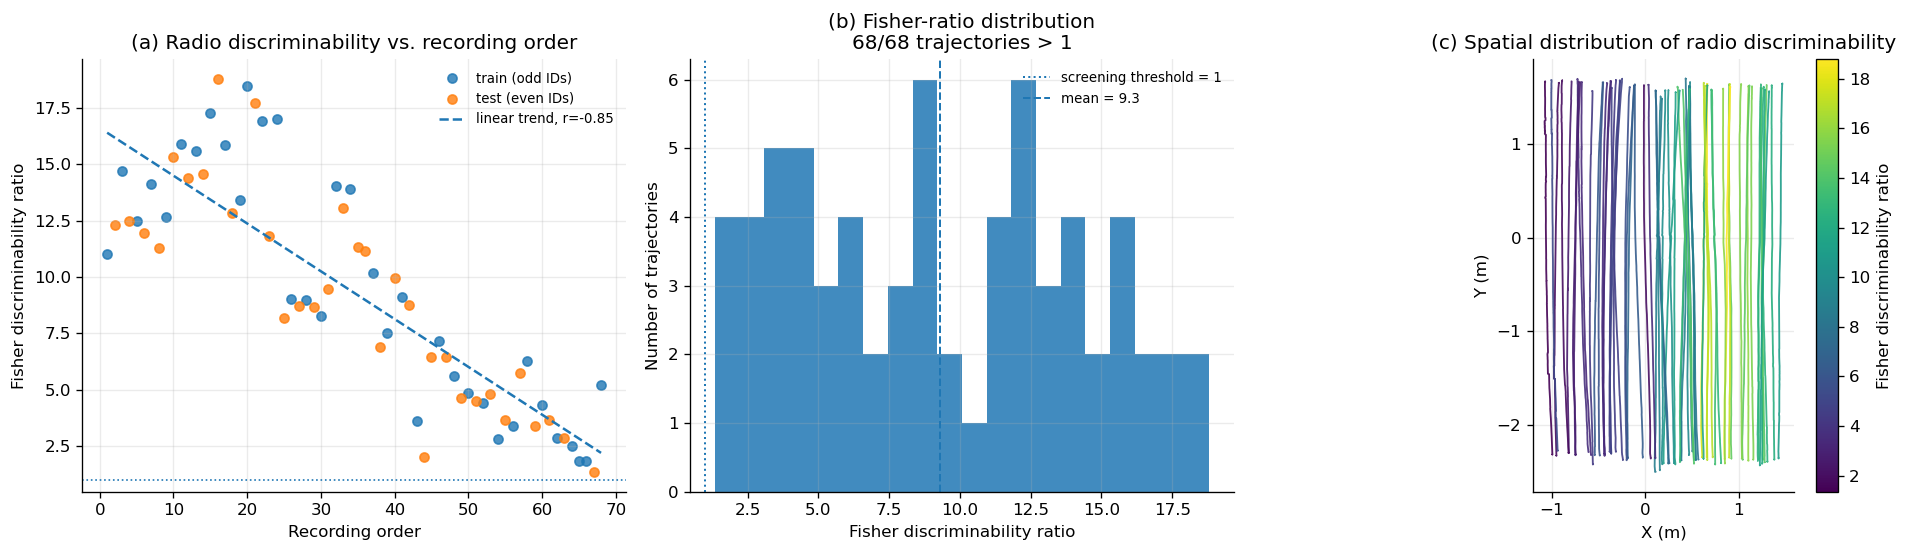


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_03_radio_signal_screening.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_03_fisher_by_trajectory.csv
JSON   : /data/luvira/reports/reviewer_reproduction/tables/figure_03_radio_screening_summary.json

CELL 5 PASSED — radio covariance fingerprint and Figure 3 verified.


In [7]:
# =============================================================================
# CELL 5 — Radio spatial-covariance fingerprint and Fisher screening
# =============================================================================
#
# Reproduces / verifies manuscript Figure 3.
#
# Raw LuViRA H_ueprocess layout:
#
#       H_all.shape = (T, F, M)
#
# where
#       T = time snapshots
#       F = 100 frequency subcarriers
#       M = 100 receive antennas
#
# Thus for one snapshot:
#
#       H : (F, M)
#
# and the antenna-domain spatial covariance is:
#
#       R = H^H H      -> (M, M)
#
# Since R is Hermitian, only its STRICT upper triangle is retained.
#
#       100*99/2 = 4,950 complex values
#       real + imaginary = 9,900 real-valued features
#
# IMPORTANT:
# The numerical Fisher implementation below is kept identical to the
# implementation that produced the manuscript's reported Figure 3 values.
# =============================================================================

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


print("=" * 72)
print("CELL 5 — RADIO COVARIANCE FINGERPRINT AND SIGNAL SCREENING")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Canonical radio covariance feature
# -----------------------------------------------------------------------------

N_UPPER_COMPLEX = (
    N_ANTENNAS
    * (N_ANTENNAS - 1)
    // 2
)

RADIO_FEATURE_DIM = (
    2 * N_UPPER_COMPLEX
)

assert N_UPPER_COMPLEX == 4950
assert RADIO_FEATURE_DIM == 9900


UPPER_TRIANGLE = np.triu_indices(
    N_ANTENNAS,
    k=1,
)


def radio_covariance_matrix(H_snapshot):
    """
    Compute antenna spatial covariance for one LuViRA radio snapshot.

    Raw snapshot convention:
        H_snapshot.shape = (subcarriers, antennas)

    Therefore:
        H^H H -> (antennas, antennas)
    """

    H_snapshot = np.asarray(
        H_snapshot
    )

    if H_snapshot.shape != (
        N_SUBCARRIERS,
        N_ANTENNAS,
    ):
        raise ValueError(
            "Expected raw radio snapshot shape "
            f"({N_SUBCARRIERS}, {N_ANTENNAS}), "
            f"found {H_snapshot.shape}"
        )

    if not np.iscomplexobj(
        H_snapshot
    ):
        raise ValueError(
            "Radio CSI snapshot must be complex-valued."
        )

    return (
        H_snapshot.conj().T
        @ H_snapshot
    )


def radio_covariance_feature(H_snapshot):
    """
    Convert one Hermitian antenna covariance matrix to the
    9,900-dimensional real feature used by the radio network.

    The diagonal is intentionally excluded.
    """

    R = radio_covariance_matrix(
        H_snapshot
    )

    v = R[
        UPPER_TRIANGLE
    ]

    feature = np.concatenate(
        [
            v.real,
            v.imag,
        ]
    ).astype(
        np.float32
    )

    assert feature.shape == (
        RADIO_FEATURE_DIM,
    )

    return feature


# -----------------------------------------------------------------------------
# 2. Verify feature construction on grid101
# -----------------------------------------------------------------------------

ref_radio_row = grid_all.loc[
    grid_all[
        "trajectory_id"
    ] == "grid101"
].iloc[0]


ref_cache = ensure_radio_cache(
    ref_radio_row
)


H_ref = np.load(
    ref_cache,
    mmap_mode="r",
)


H0 = np.asarray(
    H_ref[0]
)


R0 = radio_covariance_matrix(
    H0
)


f0 = radio_covariance_feature(
    H0
)


hermitian_error = float(
    np.max(
        np.abs(
            R0
            - R0.conj().T
        )
    )
)


diag_imag_max = float(
    np.max(
        np.abs(
            np.diag(R0).imag
        )
    )
)


print(
    "\nA. Spatial-covariance fingerprint"
)

print("-" * 72)

print(
    f"Raw H_ueprocess      : "
    f"{H_ref.shape}"
)

print(
    f"One snapshot         : "
    f"{H0.shape} "
    "(subcarrier × antenna)"
)

print(
    f"Spatial covariance R : "
    f"{R0.shape} "
    "(antenna × antenna)"
)

print(
    "Operation            : "
    "R = Hᴴ H"
)

print(
    f"Hermitian error      : "
    f"{hermitian_error:.3e}"
)

print(
    f"Max imag(diag R)     : "
    f"{diag_imag_max:.3e}"
)

print(
    f"Strict upper triangle: "
    f"{N_UPPER_COMPLEX:,} complex values"
)

print(
    f"Real + imaginary     : "
    f"{len(f0):,} float values"
)


assert np.allclose(
    R0,
    R0.conj().T,
    atol=1e-10,
    rtol=1e-10,
), (
    "Computed covariance is not Hermitian."
)


assert len(f0) == 9900


del H_ref


# -----------------------------------------------------------------------------
# 3. Verify actual stride-5 spatial sampling from GT
# -----------------------------------------------------------------------------

step_distances_mm = []


for _, row in grid_all.iterrows():

    tid = row[
        "trajectory_id"
    ]

    gt = load_gt(
        row["gt_radio_path"]
    )

    H = np.load(
        RADIO_CACHE
        / f"{tid}.npy",
        mmap_mode="r",
    )

    n_use = min(
        len(gt),
        H.shape[0],
    )

    sample_idx = np.arange(
        0,
        n_use,
        STRIDE,
        dtype=np.int64,
    )

    xy_mm = gt[
        sample_idx,
        1:3,
    ]

    if len(xy_mm) > 1:

        d = np.linalg.norm(
            np.diff(
                xy_mm,
                axis=0,
            ),
            axis=1,
        )

        step_distances_mm.append(
            d
        )

    del H


step_distances_mm = np.concatenate(
    step_distances_mm
)


median_step_mm = float(
    np.median(
        step_distances_mm
    )
)

mean_step_mm = float(
    np.mean(
        step_distances_mm
    )
)

step_p95_mm = float(
    np.percentile(
        step_distances_mm,
        95,
    )
)


print(
    "\nB. Stride-5 spatial sampling"
)

print("-" * 72)

print(
    f"Median retained-step distance : "
    f"{median_step_mm:.3f} mm"
)

print(
    f"Mean retained-step distance   : "
    f"{mean_step_mm:.3f} mm"
)

print(
    f"95th percentile               : "
    f"{step_p95_mm:.3f} mm"
)

print(
    f"Quarter wavelength            : "
    f"{QUARTER_WAVELENGTH_MM:.3f} mm"
)

print(
    f"Median / quarter wavelength   : "
    f"{median_step_mm / QUARTER_WAVELENGTH_MM:.3f}"
)


# The paper says "roughly 5 mm", so use a deliberately broad sanity range.
assert 3.0 <= median_step_mm <= 7.0, (
    "Observed stride-5 spacing is inconsistent "
    "with the manuscript's approximately 5 mm statement."
)


assert (
    median_step_mm
    < QUARTER_WAVELENGTH_MM
), (
    "Median retained spacing exceeds the "
    "quarter-wavelength reference."
)


# -----------------------------------------------------------------------------
# 4. Fisher-style radio discriminability statistic
# -----------------------------------------------------------------------------
#
# This is intentionally the SAME implementation used for the manuscript
# result. It creates a scalar radio-strength statistic per retained snapshot,
# bins samples along the Y-position axis, and computes:
#
#       variance(bin means) / mean(within-bin variances)
#
# A value > 1 means between-position variation exceeds the typical
# within-position-bin variation.
# -----------------------------------------------------------------------------

def compute_radio_fisher(
    H,
    gt,
    stride=STRIDE,
    n_bins=10,
):
    """
    Fisher-style between-bin / within-bin radio discriminability ratio.

    This function is preserved exactly from the experiment that generated
    the manuscript's reported Fisher statistics.
    """

    n = min(
        H.shape[0],
        len(gt),
    )

    y_position_mm = gt[
        :n:stride,
        2,
    ]

    H_sub = H[
        :n:stride
    ]


    # Scalar radio-strength statistic used in the original analysis.
    radio_strength = np.log1p(
        np.abs(
            H_sub
        ).mean(
            axis=(1, 2)
        ) ** 2
    )


    y_min = float(
        y_position_mm.min()
    )

    y_max = float(
        y_position_mm.max()
    )


    if (
        y_max - y_min
        < 100.0
    ):
        return np.nan


    bin_index = np.floor(

        (
            y_position_mm
            - y_min
        )

        / (
            y_max
            - y_min
            + 1e-9
        )

        * n_bins

    ).astype(
        int
    )


    bin_index = np.clip(
        bin_index,
        0,
        n_bins - 1,
    )


    bin_means = []

    bin_variances = []


    for b in range(
        n_bins
    ):

        mask = (
            bin_index == b
        )

        if mask.sum() < 2:
            continue


        bin_means.append(
            radio_strength[
                mask
            ].mean()
        )

        bin_variances.append(
            radio_strength[
                mask
            ].var()
        )


    if len(
        bin_means
    ) < 2:
        return np.nan


    fisher = (
        np.var(
            bin_means
        )
        / (
            np.mean(
                bin_variances
            )
            + 1e-9
        )
    )


    return float(
        fisher
    )


# -----------------------------------------------------------------------------
# 5. Compute Fisher ratio for all 68 grids
# -----------------------------------------------------------------------------

print(
    "\nComputing Fisher ratios for all 68 grids ..."
)


fisher_records = []


for count, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    H = np.load(
        RADIO_CACHE
        / f"{tid}.npy",
        mmap_mode="r",
    )


    gt = load_gt(
        row["gt_radio_path"]
    )


    fisher = compute_radio_fisher(
        H,
        gt,
        stride=STRIDE,
        n_bins=10,
    )


    n_use = min(
        H.shape[0],
        len(gt),
    )


    retained_idx = np.arange(
        0,
        n_use,
        STRIDE,
        dtype=np.int64,
    )


    gt_retained = gt[
        retained_idx
    ]


    fisher_records.append({

        "trajectory_id":
            tid,

        "grid_num":
            int(
                row["grid_num"]
            ),

        "split":
            (
                "train"
                if int(row["grid_num"]) % 2 == 1
                else "test"
            ),

        "fisher_ratio":
            fisher,

        "mean_x_m":
            float(
                gt_retained[:, 1].mean()
                / 1000.0
            ),

        "mean_y_m":
            float(
                gt_retained[:, 2].mean()
                / 1000.0
            ),

        "n_retained":
            int(
                len(retained_idx)
            ),
    })


    del H


    if (
        count % 10 == 0
        or count == len(grid_all)
    ):

        print(
            f"  completed "
            f"{count:2d}/"
            f"{len(grid_all)} trajectories"
        )


fisher_df = pd.DataFrame(
    fisher_records
)


fisher_df = (
    fisher_df
    .sort_values(
        "grid_num"
    )
    .reset_index(
        drop=True
    )
)


# Recording order among the 68 radio-usable grid recordings.
fisher_df[
    "record_order"
] = np.arange(
    1,
    len(fisher_df) + 1,
)


valid_fisher = fisher_df[
    "fisher_ratio"
].dropna()


assert len(
    valid_fisher
) == 68


# -----------------------------------------------------------------------------
# 6. Manuscript statistics
# -----------------------------------------------------------------------------

fisher_mean = float(
    valid_fisher.mean()
)

fisher_min = float(
    valid_fisher.min()
)

fisher_max = float(
    valid_fisher.max()
)

n_above_one = int(
    (
        valid_fisher > 1.0
    ).sum()
)


r_order, p_order = pearsonr(

    fisher_df[
        "record_order"
    ],

    fisher_df[
        "fisher_ratio"
    ],
)


half = (
    len(fisher_df)
    // 2
)


first_half_mean = float(
    fisher_df.iloc[
        :half
    ][
        "fisher_ratio"
    ].mean()
)


second_half_mean = float(
    fisher_df.iloc[
        half:
    ][
        "fisher_ratio"
    ].mean()
)


campaign_drop_pct = (
    (
        first_half_mean
        - second_half_mean
    )
    / first_half_mean
    * 100.0
)


train_fisher_mean = float(

    fisher_df.loc[
        fisher_df["split"] == "train",
        "fisher_ratio",
    ].mean()
)


test_fisher_mean = float(

    fisher_df.loc[
        fisher_df["split"] == "test",
        "fisher_ratio",
    ].mean()
)


train_order_mean = float(

    fisher_df.loc[
        fisher_df["split"] == "train",
        "record_order",
    ].mean()
)


test_order_mean = float(

    fisher_df.loc[
        fisher_df["split"] == "test",
        "record_order",
    ].mean()
)


order_mean_difference = abs(
    train_order_mean
    - test_order_mean
)


print(
    "\nC. Fisher discriminability statistics"
)

print("-" * 72)

print(
    f"Mean                         : "
    f"{fisher_mean:.2f}"
)

print(
    f"Range                        : "
    f"{fisher_min:.2f} – {fisher_max:.2f}"
)

print(
    f"Fisher > 1                   : "
    f"{n_above_one}/68"
)

print(
    f"Pearson r(recording order)   : "
    f"{r_order:.3f}"
)

print(
    f"p-value                      : "
    f"{p_order:.3e}"
)

print(
    f"First-half mean              : "
    f"{first_half_mean:.2f}"
)

print(
    f"Second-half mean             : "
    f"{second_half_mean:.2f}"
)

print(
    f"Campaign decrease            : "
    f"{campaign_drop_pct:.1f}%"
)

print(
    f"Train Fisher mean            : "
    f"{train_fisher_mean:.2f}"
)

print(
    f"Test Fisher mean             : "
    f"{test_fisher_mean:.2f}"
)

print(
    f"Train/test mean-order gap    : "
    f"{order_mean_difference:.2f} recording positions"
)


# -----------------------------------------------------------------------------
# 7. Hard checks against the values reported in the manuscript experiment
# -----------------------------------------------------------------------------

assert n_above_one == 68, (
    "Not all 68 grid trajectories exceed Fisher ratio 1."
)


assert np.isclose(
    fisher_mean,
    9.30,
    atol=0.05,
), (
    f"Expected Fisher mean ≈9.30; "
    f"observed {fisher_mean:.3f}"
)


assert np.isclose(
    fisher_min,
    1.35,
    atol=0.05,
), (
    f"Expected minimum ≈1.35; "
    f"observed {fisher_min:.3f}"
)


assert np.isclose(
    fisher_max,
    18.80,
    atol=0.05,
), (
    f"Expected maximum ≈18.80; "
    f"observed {fisher_max:.3f}"
)


assert np.isclose(
    r_order,
    -0.848,
    atol=0.01,
), (
    f"Expected recording-order correlation "
    f"≈ -0.848; observed {r_order:.3f}"
)


# -----------------------------------------------------------------------------
# 8. Reproduce Figure 3
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.7),
)


# -------------------------------------------------------------------------
# Fig. 3(a) — Fisher ratio versus recording order
# -------------------------------------------------------------------------

for split in [
    "train",
    "test",
]:

    m = (
        fisher_df[
            "split"
        ] == split
    )

    axes[0].scatter(
        fisher_df.loc[
            m,
            "record_order",
        ],
        fisher_df.loc[
            m,
            "fisher_ratio",
        ],
        s=30,
        alpha=0.8,
        label=(
            "train (odd IDs)"
            if split == "train"
            else "test (even IDs)"
        ),
    )


trend_coeff = np.polyfit(
    fisher_df[
        "record_order"
    ],
    fisher_df[
        "fisher_ratio"
    ],
    deg=1,
)


trend_x = np.array(
    [
        fisher_df[
            "record_order"
        ].min(),
        fisher_df[
            "record_order"
        ].max(),
    ],
    dtype=float,
)


trend_y = np.polyval(
    trend_coeff,
    trend_x,
)


axes[0].plot(
    trend_x,
    trend_y,
    linestyle="--",
    linewidth=1.5,
    label=f"linear trend, r={r_order:.2f}",
)


axes[0].axhline(
    1.0,
    linestyle=":",
    linewidth=1.0,
)


axes[0].set_xlabel(
    "Recording order"
)

axes[0].set_ylabel(
    "Fisher discriminability ratio"
)

axes[0].set_title(
    "(a) Radio discriminability vs. recording order"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Fig. 3(b) — Fisher-ratio distribution
# -------------------------------------------------------------------------

axes[1].hist(
    valid_fisher,
    bins=20,
    alpha=0.85,
)


axes[1].axvline(
    1.0,
    linestyle=":",
    linewidth=1.2,
    label="screening threshold = 1",
)


axes[1].axvline(
    fisher_mean,
    linestyle="--",
    linewidth=1.2,
    label=f"mean = {fisher_mean:.1f}",
)


axes[1].set_xlabel(
    "Fisher discriminability ratio"
)

axes[1].set_ylabel(
    "Number of trajectories"
)

axes[1].set_title(
    "(b) Fisher-ratio distribution\n"
    f"{n_above_one}/68 trajectories > 1"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Fig. 3(c) — each complete trajectory coloured by its Fisher ratio
# -------------------------------------------------------------------------

norm = Normalize(
    vmin=float(
        valid_fisher.min()
    ),
    vmax=float(
        valid_fisher.max()
    ),
)


cmap = plt.get_cmap(
    "viridis"
)


for _, frow in fisher_df.iterrows():

    tid = frow[
        "trajectory_id"
    ]


    grow = grid_all.loc[
        grid_all[
            "trajectory_id"
        ] == tid
    ].iloc[0]


    gt = load_gt(
        grow[
            "gt_radio_path"
        ]
    )


    H = np.load(
        RADIO_CACHE
        / f"{tid}.npy",
        mmap_mode="r",
    )


    n_use = min(
        H.shape[0],
        len(gt),
    )


    retained_idx = np.arange(
        0,
        n_use,
        STRIDE,
        dtype=np.int64,
    )


    x_m = (
        gt[
            retained_idx,
            1,
        ]
        / 1000.0
    )


    y_m = (
        gt[
            retained_idx,
            2,
        ]
        / 1000.0
    )


    axes[2].plot(
        x_m,
        y_m,
        linewidth=1.1,
        alpha=0.90,
        color=cmap(
            norm(
                frow[
                    "fisher_ratio"
                ]
            )
        ),
    )


    del H


sm = ScalarMappable(
    norm=norm,
    cmap=cmap,
)

sm.set_array(
    []
)


cbar = fig.colorbar(
    sm,
    ax=axes[2],
    fraction=0.047,
    pad=0.04,
)

cbar.set_label(
    "Fisher discriminability ratio"
)


axes[2].set_xlabel(
    "X (m)"
)

axes[2].set_ylabel(
    "Y (m)"
)

axes[2].set_title(
    "(c) Spatial distribution of radio discriminability"
)

axes[2].set_aspect(
    "equal",
    adjustable="box",
)

axes[2].grid(
    alpha=0.25
)


fig.tight_layout()


figure3_path = (
    FIG_DIR
    / "figure_03_radio_signal_screening.png"
)


fig.savefig(
    figure3_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 9. Save numerical support for reviewer verification
# -----------------------------------------------------------------------------

fisher_df.to_csv(
    TABLE_DIR
    / "figure_03_fisher_by_trajectory.csv",
    index=False,
)


radio_screening_summary = {

    "raw_snapshot_convention":
        "subcarrier x antenna",

    "covariance_operation":
        "H^H H",

    "covariance_shape":
        [
            N_ANTENNAS,
            N_ANTENNAS,
        ],

    "strict_upper_complex_values":
        int(
            N_UPPER_COMPLEX
        ),

    "radio_feature_dimension":
        int(
            RADIO_FEATURE_DIM
        ),

    "stride":
        int(
            STRIDE
        ),

    "median_stride_distance_mm":
        median_step_mm,

    "quarter_wavelength_mm":
        float(
            QUARTER_WAVELENGTH_MM
        ),

    "fisher_mean":
        fisher_mean,

    "fisher_min":
        fisher_min,

    "fisher_max":
        fisher_max,

    "fisher_above_one":
        n_above_one,

    "recording_order_pearson_r":
        float(
            r_order
        ),

    "recording_order_p_value":
        float(
            p_order
        ),

    "first_half_fisher_mean":
        first_half_mean,

    "second_half_fisher_mean":
        second_half_mean,

    "campaign_decrease_percent":
        float(
            campaign_drop_pct
        ),

    "train_fisher_mean":
        train_fisher_mean,

    "test_fisher_mean":
        test_fisher_mean,
}


with open(
    TABLE_DIR
    / "figure_03_radio_screening_summary.json",
    "w",
) as f:

    json.dump(
        radio_screening_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {figure3_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_03_fisher_by_trajectory.csv'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'figure_03_radio_screening_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 5 PASSED — "
    "radio covariance fingerprint and Figure 3 verified."
)

print(
    "=" * 72
)

CELL 6 — DEPTH QUALITY AND POSITION-INFORMATION ANALYSIS

A. Raw depth stream
------------------------------------------------------------------------
Reference trajectory : grid101
Depth frames         : 641
Raw frame shape      : (480, 640)
Raw dtype after load : float32
Raw minimum          : 0.0 mm
Raw maximum          : 24321.0 mm
Processing clip      : 5000 mm

Computing per-trajectory depth quality ...
  quality audit 10/68
  quality audit 20/68
  quality audit 30/68
  quality audit 40/68
  quality audit 50/68
  quality audit 60/68
  quality audit 68/68

Computing depth-position correlation ...
  correlation 10/68
  correlation 20/68
  correlation 30/68
  correlation 40/68
  correlation 50/68
  correlation 60/68
  correlation 68/68

B. Invalid-pixel statistics
------------------------------------------------------------------------
Mean per-trajectory invalid fraction : 4.64%
Range                                : 4.38% – 5.02%
Mean pixels above 5000 mm            : 3.45%
Trajec

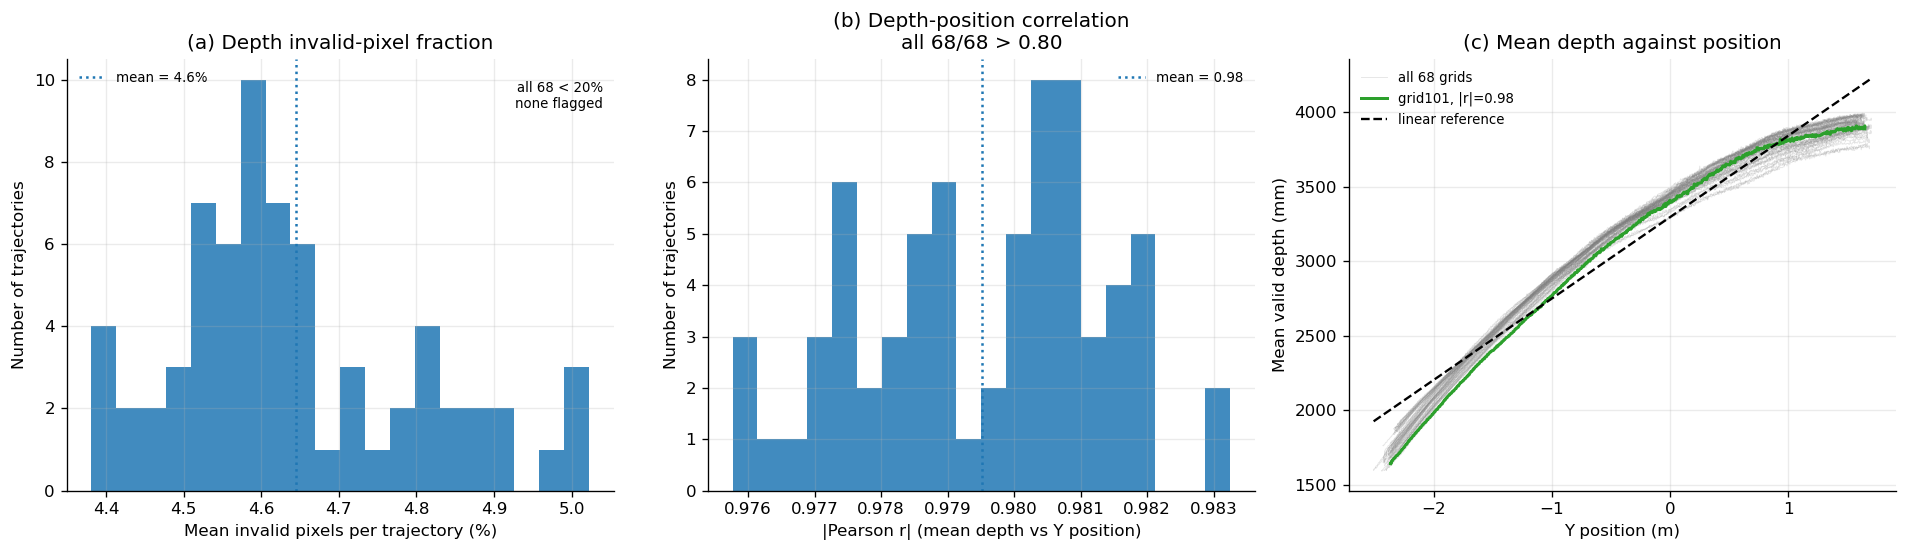


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_04_depth_quality_and_position.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_04_depth_quality_by_trajectory.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_04_depth_position_correlation.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_04_depth_position_samples.csv
JSON   : /data/luvira/reports/reviewer_reproduction/tables/figure_04_depth_summary.json

CELL 6 PASSED — depth quality and Figure 4 reproduce the manuscript analysis.


In [8]:
# =============================================================================
# CELL 6 — Depth quality and depth-position information
# =============================================================================
#
# Reproduces manuscript Figure 4.
#
# Figure 4:
#   (a) Histogram of per-trajectory mean invalid-pixel fraction
#   (b) Histogram of per-trajectory |correlation| between mean depth
#       and Y position
#   (c) Mean depth versus Y position for all 68 grids,
#       with grid101 highlighted and a linear reference
#
# IMPORTANT
# ---------
# This cell is an exploratory signal-quality analysis.
#
# It reproduces the screening calculation that generated the manuscript
# values. Model training/evaluation later in the notebook will use the
# definitive aligned sample manifest created in Cell 4.
#
# Depth convention:
#   0          -> invalid pixel
#   > 5000 mm  -> clipped to 5000 mm before computing mean depth
#
# Reported manuscript results:
#   mean invalid fraction     ~= 4.6%
#   mean depth-position |r|   ~= 0.98
# =============================================================================


print("=" * 72)
print("CELL 6 — DEPTH QUALITY AND POSITION-INFORMATION ANALYSIS")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Constants used in the original depth-quality screening
# -----------------------------------------------------------------------------

DEPTH_QUALITY_FRAME_STEP = 20

DEPTH_CORRELATION_THRESHOLD = 0.80

DEPTH_INVALID_THRESHOLD = 0.20


# -----------------------------------------------------------------------------
# 2. Safe depth-image loader
# -----------------------------------------------------------------------------

def read_depth_image(path):
    """
    Read one LuViRA 16-bit depth PNG as float32 millimetres.
    """

    depth = cv2.imread(
        str(path),
        cv2.IMREAD_ANYDEPTH,
    )

    if depth is None:
        raise RuntimeError(
            f"Could not read depth image: {path}"
        )

    if depth.ndim != 2:
        raise ValueError(
            f"Expected one-channel depth image; "
            f"found shape {depth.shape}: {path}"
        )

    return depth.astype(
        np.float32
    )


# -----------------------------------------------------------------------------
# 3. Verify raw depth format on grid101
# -----------------------------------------------------------------------------

ref_depth_row = grid_all.loc[
    grid_all["trajectory_id"] == "grid101"
].iloc[0]


ref_depth_files, ref_depth_times = timestamped_pngs(
    ref_depth_row["depth_dir_path"]
)


depth_example = read_depth_image(
    ref_depth_files[0]
)


print(
    "\nA. Raw depth stream"
)

print("-" * 72)

print(
    f"Reference trajectory : grid101"
)

print(
    f"Depth frames         : {len(ref_depth_files)}"
)

print(
    f"Raw frame shape      : {depth_example.shape}"
)

print(
    f"Raw dtype after load : {depth_example.dtype}"
)

print(
    f"Raw minimum          : {depth_example.min():.1f} mm"
)

print(
    f"Raw maximum          : {depth_example.max():.1f} mm"
)

print(
    f"Processing clip      : {DEPTH_CLIP_MM:.0f} mm"
)


assert depth_example.shape == (
    480,
    640,
), (
    "Unexpected raw LuViRA depth resolution."
)


# -----------------------------------------------------------------------------
# 4. Per-trajectory invalid-pixel quality screening
# -----------------------------------------------------------------------------
#
# To reproduce the manuscript statistic generated by the original analysis,
# every 20th depth frame is inspected for this quality-only audit.
#
# This subsampling is NOT used for training.
# -----------------------------------------------------------------------------

print(
    "\nComputing per-trajectory depth quality ..."
)


depth_quality_records = []


for count, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    depth_files, _ = timestamped_pngs(
        row["depth_dir_path"]
    )


    invalid_fractions = []

    above_clip_fractions = []


    quality_files = depth_files[
        ::DEPTH_QUALITY_FRAME_STEP
    ]


    for depth_path in quality_files:

        d = read_depth_image(
            depth_path
        )


        n_pixels = d.size


        invalid_fraction = (
            np.count_nonzero(
                d == 0
            )
            / n_pixels
        )


        above_clip_fraction = (
            np.count_nonzero(
                d > DEPTH_CLIP_MM
            )
            / n_pixels
        )


        invalid_fractions.append(
            invalid_fraction
        )


        above_clip_fractions.append(
            above_clip_fraction
        )


    depth_quality_records.append({

        "trajectory_id":
            tid,

        "grid_num":
            int(
                row["grid_num"]
            ),

        "split":
            (
                "train"
                if int(row["grid_num"]) % 2 == 1
                else "test"
            ),

        "total_depth_frames":
            int(
                len(depth_files)
            ),

        "quality_frames_checked":
            int(
                len(quality_files)
            ),

        "invalid_fraction_mean":
            float(
                np.mean(
                    invalid_fractions
                )
            ),

        "invalid_fraction_max":
            float(
                np.max(
                    invalid_fractions
                )
            ),

        "above_5m_fraction_mean":
            float(
                np.mean(
                    above_clip_fractions
                )
            ),
    })


    if (
        count % 10 == 0
        or count == len(grid_all)
    ):

        print(
            f"  quality audit "
            f"{count:2d}/{len(grid_all)}"
        )


depth_quality_df = pd.DataFrame(
    depth_quality_records
)


# -----------------------------------------------------------------------------
# 5. Depth mean versus Y-position correlation
# -----------------------------------------------------------------------------
#
# This reproduces the EDA calculation used for the manuscript:
#
#   * GT sampled with STRIDE=5
#   * each GT timestamp paired independently to nearest depth frame
#   * depth clipped at 5 m
#   * zero pixels excluded from the frame mean
#   * Pearson correlation computed between mean depth and antenna Y
#
# A cache is used so that a depth frame selected by more than one GT
# timestamp is only read once.
# -----------------------------------------------------------------------------

print(
    "\nComputing depth-position correlation ..."
)


depth_correlation_records = []

depth_curve_parts = []


for count, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    gt = load_gt(
        row["gt_radio_path"]
    )


    depth_files, t_depth = timestamped_pngs(
        row["depth_dir_path"]
    )


    gt_indices = np.arange(
        0,
        len(gt),
        STRIDE,
        dtype=np.int64,
    )


    gt_times = gt[
        gt_indices,
        0,
    ]


    nearest_depth_idx = nearest_timestamp_indices(
        t_depth,
        gt_times,
    )


    # -------------------------------------------------------------
    # Read each selected depth frame only once
    # -------------------------------------------------------------

    frame_mean_cache = {}


    mean_depth_mm = []

    y_position_m = []

    used_gt_indices = []

    used_depth_indices = []


    for gt_idx, depth_idx in zip(
        gt_indices,
        nearest_depth_idx,
    ):

        depth_idx = int(
            depth_idx
        )


        if depth_idx not in frame_mean_cache:

            d = read_depth_image(
                depth_files[
                    depth_idx
                ]
            )


            d = np.clip(
                d,
                0.0,
                DEPTH_CLIP_MM,
            )


            valid = d[
                d > 0
            ]


            if len(valid) == 0:

                frame_mean_cache[
                    depth_idx
                ] = np.nan

            else:

                frame_mean_cache[
                    depth_idx
                ] = float(
                    valid.mean()
                )


        this_mean = frame_mean_cache[
            depth_idx
        ]


        if not np.isfinite(
            this_mean
        ):
            continue


        mean_depth_mm.append(
            this_mean
        )


        y_position_m.append(
            float(
                gt[
                    gt_idx,
                    2,
                ]
                / 1000.0
            )
        )


        used_gt_indices.append(
            int(
                gt_idx
            )
        )


        used_depth_indices.append(
            depth_idx
        )


    mean_depth_mm = np.asarray(
        mean_depth_mm,
        dtype=np.float64,
    )


    y_position_m = np.asarray(
        y_position_m,
        dtype=np.float64,
    )


    assert len(
        mean_depth_mm
    ) > 10


    r_signed, p_value = pearsonr(
        mean_depth_mm,
        y_position_m,
    )


    depth_correlation_records.append({

        "trajectory_id":
            tid,

        "grid_num":
            int(
                row["grid_num"]
            ),

        "split":
            (
                "train"
                if int(row["grid_num"]) % 2 == 1
                else "test"
            ),

        "n_samples":
            int(
                len(mean_depth_mm)
            ),

        "r_depth_y_signed":
            float(
                r_signed
            ),

        "r_depth_y_abs":
            float(
                abs(
                    r_signed
                )
            ),

        "p_value":
            float(
                p_value
            ),
    })


    depth_curve_parts.append(

        pd.DataFrame({

            "trajectory_id":
                tid,

            "grid_num":
                int(
                    row["grid_num"]
                ),

            "gt_index":
                used_gt_indices,

            "depth_frame_index":
                used_depth_indices,

            "y_position_m":
                y_position_m,

            "mean_depth_mm":
                mean_depth_mm,
        })
    )


    if (
        count % 10 == 0
        or count == len(grid_all)
    ):

        print(
            f"  correlation "
            f"{count:2d}/{len(grid_all)}"
        )


depth_correlation_df = pd.DataFrame(
    depth_correlation_records
)


depth_curve_df = pd.concat(
    depth_curve_parts,
    ignore_index=True,
)


# -----------------------------------------------------------------------------
# 6. Numerical results
# -----------------------------------------------------------------------------

mean_invalid_percent = float(
    depth_quality_df[
        "invalid_fraction_mean"
    ].mean()
    * 100.0
)


min_invalid_percent = float(
    depth_quality_df[
        "invalid_fraction_mean"
    ].min()
    * 100.0
)


max_invalid_percent = float(
    depth_quality_df[
        "invalid_fraction_mean"
    ].max()
    * 100.0
)


mean_above_5m_percent = float(
    depth_quality_df[
        "above_5m_fraction_mean"
    ].mean()
    * 100.0
)


n_invalid_bad = int(
    (
        depth_quality_df[
            "invalid_fraction_mean"
        ]
        > DEPTH_INVALID_THRESHOLD
    ).sum()
)


mean_depth_r = float(
    depth_correlation_df[
        "r_depth_y_abs"
    ].mean()
)


min_depth_r = float(
    depth_correlation_df[
        "r_depth_y_abs"
    ].min()
)


max_depth_r = float(
    depth_correlation_df[
        "r_depth_y_abs"
    ].max()
)


n_depth_pass = int(
    (
        depth_correlation_df[
            "r_depth_y_abs"
        ]
        > DEPTH_CORRELATION_THRESHOLD
    ).sum()
)


grid101_r = float(

    depth_correlation_df.loc[
        depth_correlation_df[
            "trajectory_id"
        ] == "grid101",
        "r_depth_y_abs",
    ].iloc[0]
)


print(
    "\nB. Invalid-pixel statistics"
)

print("-" * 72)

print(
    f"Mean per-trajectory invalid fraction : "
    f"{mean_invalid_percent:.2f}%"
)

print(
    f"Range                                : "
    f"{min_invalid_percent:.2f}% – "
    f"{max_invalid_percent:.2f}%"
)

print(
    f"Mean pixels above 5000 mm            : "
    f"{mean_above_5m_percent:.2f}%"
)

print(
    f"Trajectories above 20% invalid       : "
    f"{n_invalid_bad}/68"
)


print(
    "\nC. Depth-position correlation"
)

print("-" * 72)

print(
    f"Mean |r|            : "
    f"{mean_depth_r:.4f}"
)

print(
    f"Range               : "
    f"{min_depth_r:.4f} – "
    f"{max_depth_r:.4f}"
)

print(
    f"|r| > 0.80          : "
    f"{n_depth_pass}/68"
)

print(
    f"grid101 |r|         : "
    f"{grid101_r:.4f}"
)


# -----------------------------------------------------------------------------
# 7. Verify manuscript-reported values
# -----------------------------------------------------------------------------

assert n_invalid_bad == 0, (
    "At least one grid exceeds the 20% "
    "invalid-depth screening threshold."
)


assert np.isclose(
    mean_invalid_percent,
    4.6,
    atol=0.15,
), (
    f"Expected approximately 4.6% invalid pixels; "
    f"observed {mean_invalid_percent:.3f}%."
)


assert np.isclose(
    mean_above_5m_percent,
    3.4,
    atol=0.20,
), (
    f"Expected approximately 3.4% above 5 m; "
    f"observed {mean_above_5m_percent:.3f}%."
)


assert n_depth_pass == 68, (
    "Not all 68 trajectories exceed |r|=0.80."
)


assert np.isclose(
    mean_depth_r,
    0.9795,
    atol=0.001,
), (
    f"Expected mean depth-position |r| ≈ 0.9795; "
    f"observed {mean_depth_r:.5f}."
)


assert np.isclose(
    min_depth_r,
    0.9758,
    atol=0.001,
), (
    f"Expected minimum |r| ≈ 0.9758; "
    f"observed {min_depth_r:.5f}."
)


assert np.isclose(
    max_depth_r,
    0.9832,
    atol=0.001,
), (
    f"Expected maximum |r| ≈ 0.9832; "
    f"observed {max_depth_r:.5f}."
)


# -----------------------------------------------------------------------------
# 8. Linear reference for Figure 4(c)
# -----------------------------------------------------------------------------
#
# The dashed line is a least-squares linear reference across the complete
# depth-versus-Y screening population. It is shown only to make the small
# residual curvature visually apparent.
# -----------------------------------------------------------------------------

linear_coeff = np.polyfit(
    depth_curve_df[
        "y_position_m"
    ].to_numpy(),
    depth_curve_df[
        "mean_depth_mm"
    ].to_numpy(),
    deg=1,
)


y_reference = np.linspace(
    depth_curve_df[
        "y_position_m"
    ].min(),
    depth_curve_df[
        "y_position_m"
    ].max(),
    300,
)


depth_linear_reference = np.polyval(
    linear_coeff,
    y_reference,
)


print(
    "\nD. Linear reference"
)

print("-" * 72)

print(
    f"Mean depth ≈ "
    f"{linear_coeff[0]:.2f} × Y "
    f"+ {linear_coeff[1]:.2f} mm"
)


# -----------------------------------------------------------------------------
# 9. Reproduce manuscript Figure 4
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.7),
)


# -------------------------------------------------------------------------
# Figure 4(a)
# Histogram of per-trajectory mean invalid-pixel fraction
# -------------------------------------------------------------------------

invalid_percentages = (
    depth_quality_df[
        "invalid_fraction_mean"
    ]
    * 100.0
)


axes[0].hist(
    invalid_percentages,
    bins=20,
    alpha=0.85,
)


axes[0].axvline(
    mean_invalid_percent,
    linestyle=":",
    linewidth=1.5,
    label=(
        f"mean = "
        f"{mean_invalid_percent:.1f}%"
    ),
)


axes[0].set_xlabel(
    "Mean invalid pixels per trajectory (%)"
)

axes[0].set_ylabel(
    "Number of trajectories"
)

axes[0].set_title(
    "(a) Depth invalid-pixel fraction"
)

axes[0].text(
    0.98,
    0.95,
    "all 68 < 20%\nnone flagged",
    transform=axes[0].transAxes,
    horizontalalignment="right",
    verticalalignment="top",
    fontsize=8,
)


axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Figure 4(b)
# Histogram of per-trajectory absolute depth-position correlation
# -------------------------------------------------------------------------

axes[1].hist(
    depth_correlation_df[
        "r_depth_y_abs"
    ],
    bins=20,
    alpha=0.85,
)


axes[1].axvline(
    mean_depth_r,
    linestyle=":",
    linewidth=1.5,
    label=f"mean = {mean_depth_r:.2f}",
)


axes[1].set_xlabel(
    "|Pearson r| "
    "(mean depth vs Y position)"
)

axes[1].set_ylabel(
    "Number of trajectories"
)

axes[1].set_title(
    "(b) Depth-position correlation\n"
    f"all {n_depth_pass}/68 > 0.80"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Figure 4(c)
# Mean depth versus Y position
#
# Faint grey curves = all 68 trajectories
# Green curve       = grid101
# Dashed line       = linear reference
# -------------------------------------------------------------------------

grey_label_added = False


for tid, group in depth_curve_df.groupby(
    "trajectory_id"
):

    g = group.sort_values(
        "y_position_m"
    )


    if tid == "grid101":
        continue


    axes[2].plot(
        g[
            "y_position_m"
        ],
        g[
            "mean_depth_mm"
        ],
        linewidth=0.55,
        alpha=0.20,
        color="gray",
        label=(
            "all 68 grids"
            if not grey_label_added
            else None
        ),
    )


    grey_label_added = True


grid101_curve = (

    depth_curve_df.loc[
        depth_curve_df[
            "trajectory_id"
        ] == "grid101"
    ]

    .sort_values(
        "y_position_m"
    )
)


axes[2].plot(
    grid101_curve[
        "y_position_m"
    ],
    grid101_curve[
        "mean_depth_mm"
    ],
    linewidth=1.8,
    color="tab:green",
    label=(
        f"grid101, |r|={grid101_r:.2f}"
    ),
)


axes[2].plot(
    y_reference,
    depth_linear_reference,
    linestyle="--",
    linewidth=1.4,
    color="black",
    label="linear reference",
)


axes[2].set_xlabel(
    "Y position (m)"
)

axes[2].set_ylabel(
    "Mean valid depth (mm)"
)

axes[2].set_title(
    "(c) Mean depth against position"
)

axes[2].legend(
    frameon=False,
    fontsize=8,
)

axes[2].grid(
    alpha=0.25
)


fig.tight_layout()


figure4_path = (
    FIG_DIR
    / "figure_04_depth_quality_and_position.png"
)


fig.savefig(
    figure4_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 10. Save reviewer-verification tables
# -----------------------------------------------------------------------------

depth_quality_df.to_csv(
    TABLE_DIR
    / "figure_04_depth_quality_by_trajectory.csv",
    index=False,
)


depth_correlation_df.to_csv(
    TABLE_DIR
    / "figure_04_depth_position_correlation.csv",
    index=False,
)


depth_curve_df.to_csv(
    TABLE_DIR
    / "figure_04_depth_position_samples.csv",
    index=False,
)


depth_summary = {

    "quality_frame_step":
        int(
            DEPTH_QUALITY_FRAME_STEP
        ),

    "depth_clip_mm":
        float(
            DEPTH_CLIP_MM
        ),

    "mean_invalid_fraction_percent":
        mean_invalid_percent,

    "minimum_invalid_fraction_percent":
        min_invalid_percent,

    "maximum_invalid_fraction_percent":
        max_invalid_percent,

    "mean_above_5m_fraction_percent":
        mean_above_5m_percent,

    "trajectories_over_20_percent_invalid":
        n_invalid_bad,

    "mean_abs_depth_y_correlation":
        mean_depth_r,

    "minimum_abs_depth_y_correlation":
        min_depth_r,

    "maximum_abs_depth_y_correlation":
        max_depth_r,

    "trajectories_over_abs_r_0_80":
        n_depth_pass,

    "grid101_abs_depth_y_correlation":
        grid101_r,

    "linear_reference_slope_mm_per_m":
        float(
            linear_coeff[0]
        ),

    "linear_reference_intercept_mm":
        float(
            linear_coeff[1]
        ),
}


with open(
    TABLE_DIR
    / "figure_04_depth_summary.json",
    "w",
) as f:

    json.dump(
        depth_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {figure4_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_04_depth_quality_by_trajectory.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_04_depth_position_correlation.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_04_depth_position_samples.csv'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'figure_04_depth_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 6 PASSED — "
    "depth quality and Figure 4 reproduce the manuscript analysis."
)

print(
    "=" * 72
)

CELL 7 — COLOUR FEATURE VALIDATION

Torchvision : 0.21.0+cu124

A. Loading frozen ImageNet MobileNetV2 ...
Weights       : MobileNet_V2_Weights.IMAGENET1K_V1
Classifier    : Identity
Output dim    : 1280
Trainable pars: 0

B. Extracting frozen CNN features across all 68 grids ...
EDA GT step : every 50th GT row
  completed 10/68 trajectories
  completed 20/68 trajectories
  completed 30/68 trajectories
  completed 40/68 trajectories
  completed 50/68 trajectories
  completed 60/68 trajectories
  completed 68/68 trajectories

Extracted feature matrix
------------------------------------------------------------------------
Observations : 5,848
Feature dim  : 1,280
Positions    : (5848, 2)

C. PCA: 1280 dimensions -> 20 dimensions ...
Variance explained by top 20 PCs : 58.16%

D. PC-position correlations
------------------------------------------------------------------------
 pc r_with_x r_with_y max_abs_r strongest_axis
  1   +0.145   +0.627     0.627              Y
  2   +0.280   -0.49

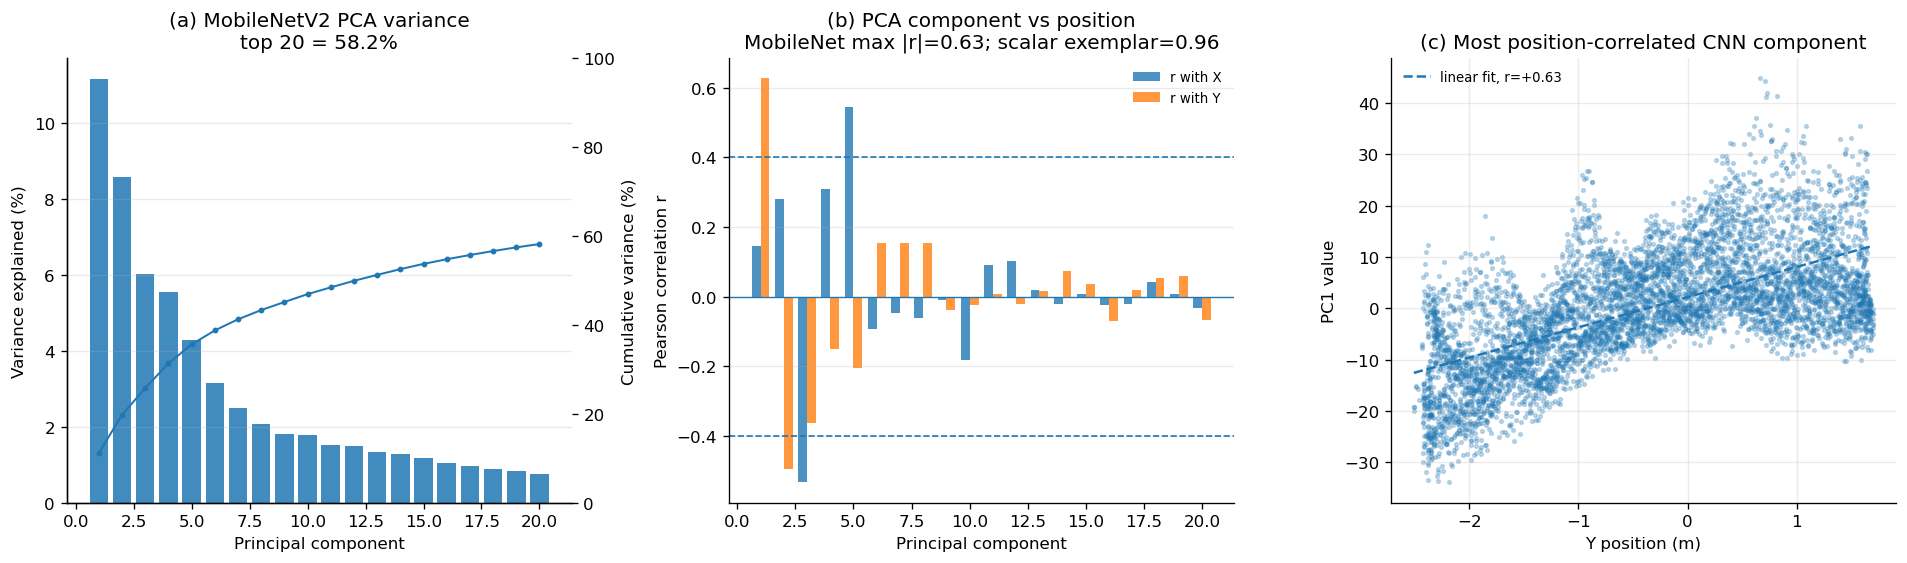


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_05_colour_feature_validation.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_05_mobilenet_pca_correlations.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_05_mobilenet_sample_manifest.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_05_scalar64_correlations_grid101.csv
Cache  : /data/luvira/reports/reviewer_reproduction/cache/figure_05_mobilenet_features.npy
Cache  : /data/luvira/reports/reviewer_reproduction/cache/figure_05_mobilenet_pca.npy
JSON   : /data/luvira/reports/reviewer_reproduction/tables/figure_05_colour_feature_summary.json

CELL 7 PASSED — colour feature screening and Figure 5 verified.


In [9]:
# =============================================================================
# CELL 7 — Colour/RGB feature validation
# =============================================================================
#
# Reproduces manuscript Figure 5.
#
# Experiment reproduced from the original analysis:
#
#   1. Frozen ImageNet-pretrained MobileNetV2
#   2. Remove classification head -> 1280-d feature vector
#   3. Sample every 50th GT instant across all 68 grid trajectories
#   4. Pair each GT instant to the nearest RGB frame
#   5. Standardize the 1280-d CNN features
#   6. PCA -> 20 components
#   7. Correlate each PC with antenna X and Y position
#
# Original reported results:
#
#   pooled RGB/CNN observations      = 5,848
#   variance in first 20 PCs         = 58.2%
#   maximum PC-position |r|          = 0.627
#
# A separate exemplar calculation on grid101 compares the CNN result
# with the 64-value handcrafted colour descriptor:
#
#   4 x 4 spatial cells *
#   (R mean, G mean, B mean, grey std)
#
#   best scalar feature-position |r| = 0.961
#
# IMPORTANT:
# The 0.961 scalar correlation is an exemplar/grid101 diagnostic.
# The later localization ablation will provide the definitive
# scalar-vs-CNN architecture comparison on the held-out test set.
# =============================================================================

print("=" * 72)
print("CELL 7 — COLOUR FEATURE VALIDATION")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Imports specific to this experiment
# -----------------------------------------------------------------------------

import torchvision
import torchvision.models as models
import torchvision.transforms as transforms


print(f"\nTorchvision : {torchvision.__version__}")


# -----------------------------------------------------------------------------
# 2. Exact 64-dimensional scalar RGB descriptor
# -----------------------------------------------------------------------------
#
# Input convention:
#     (N, 3, H, W), ImageNet-normalized
#
# Output:
#     (N, 64)
#
# Each of 16 spatial cells contributes:
#     R mean
#     G mean
#     B mean
#     grey-level standard deviation
# -----------------------------------------------------------------------------

def rgb_scalar_64(X_rgb):
    """
    Convert ImageNet-normalized RGB tensors into the 64-value
    handcrafted descriptor used by the colour encoder.
    """

    X_rgb = np.asarray(
        X_rgb,
        dtype=np.float32,
    )

    if X_rgb.ndim != 4:
        raise ValueError(
            f"Expected (N,3,H,W), found {X_rgb.shape}"
        )

    if X_rgb.shape[1] != 3:
        raise ValueError(
            f"Expected three RGB channels, found {X_rgb.shape}"
        )

    mean = IMAGENET_MEAN.reshape(
        1,
        3,
        1,
        1,
    )

    std = IMAGENET_STD.reshape(
        1,
        3,
        1,
        1,
    )

    # Return to approximately [0,1] RGB space.
    X_denorm = (
        X_rgb * std
        + mean
    )

    X_grey = X_denorm.mean(
        axis=1
    )

    n_samples, height, width = X_grey.shape

    cell_h = (
        height // RGB_GRID
    )

    cell_w = (
        width // RGB_GRID
    )

    features = []

    for row_id in range(
        RGB_GRID
    ):

        for col_id in range(
            RGB_GRID
        ):

            r0 = (
                row_id * cell_h
            )

            r1 = (
                (row_id + 1) * cell_h
            )

            c0 = (
                col_id * cell_w
            )

            c1 = (
                (col_id + 1) * cell_w
            )

            patch_r = X_denorm[
                :,
                0,
                r0:r1,
                c0:c1,
            ]

            patch_g = X_denorm[
                :,
                1,
                r0:r1,
                c0:c1,
            ]

            patch_b = X_denorm[
                :,
                2,
                r0:r1,
                c0:c1,
            ]

            patch_grey = X_grey[
                :,
                r0:r1,
                c0:c1,
            ]

            features.append(
                patch_r.mean(
                    axis=(1, 2)
                )
            )

            features.append(
                patch_g.mean(
                    axis=(1, 2)
                )
            )

            features.append(
                patch_b.mean(
                    axis=(1, 2)
                )
            )

            features.append(
                patch_grey.std(
                    axis=(1, 2)
                )
            )

    features = np.stack(
        features,
        axis=1,
    ).astype(
        np.float32
    )

    assert features.shape[1] == 64

    return features


# -----------------------------------------------------------------------------
# 3. Load the exact pretrained MobileNetV2 configuration
# -----------------------------------------------------------------------------
#
# The original experiment used:
#
#     MobileNet_V2_Weights.IMAGENET1K_V1
#
# and replaced the classifier by Identity().
#
# If the weights are not already cached, torchvision may download them.
# -----------------------------------------------------------------------------

print(
    "\nA. Loading frozen ImageNet MobileNetV2 ..."
)


MOBILENET_WEIGHTS = (
    models.MobileNet_V2_Weights.IMAGENET1K_V1
)


mobilenet = models.mobilenet_v2(
    weights=MOBILENET_WEIGHTS
)


mobilenet.classifier = nn.Identity()


mobilenet = mobilenet.to(
    DEVICE
)


mobilenet.eval()


for parameter in mobilenet.parameters():

    parameter.requires_grad = False


n_trainable = sum(
    p.numel()
    for p in mobilenet.parameters()
    if p.requires_grad
)


assert n_trainable == 0


print(
    "Weights       : "
    "MobileNet_V2_Weights.IMAGENET1K_V1"
)

print(
    "Classifier    : Identity"
)

print(
    "Output dim    : 1280"
)

print(
    "Trainable pars: 0"
)


# -----------------------------------------------------------------------------
# 4. Exact image transformation used in the original EDA
# -----------------------------------------------------------------------------

rgb_mobilenet_transform = transforms.Compose([
    transforms.ToPILImage(),

    transforms.Resize(
        (
            DEPTH_HEIGHT,
            DEPTH_WIDTH,
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406,
        ],
        std=[
            0.229,
            0.224,
            0.225,
        ],
    ),
])


# -----------------------------------------------------------------------------
# 5. Extract pooled MobileNet features across all 68 grids
# -----------------------------------------------------------------------------
#
# IMPORTANT:
# This is an exploratory EDA sample, not the final model-training sample set.
#
# To reproduce the published experiment exactly, every 50th GT row is used.
# -----------------------------------------------------------------------------

CNN_EDA_GT_STEP = 50


print(
    "\nB. Extracting frozen CNN features "
    "across all 68 grids ..."
)

print(
    f"EDA GT step : every {CNN_EDA_GT_STEP}th GT row"
)


cnn_features = []

cnn_positions = []

cnn_metadata_parts = []


for trajectory_number, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    gt = load_gt(
        row["gt_radio_path"]
    )


    rgb_files, t_rgb = timestamped_pngs(
        row["rgb_dir_path"]
    )


    eda_gt_idx = np.arange(
        0,
        len(gt),
        CNN_EDA_GT_STEP,
        dtype=np.int64,
    )


    eda_times = gt[
        eda_gt_idx,
        0,
    ]


    nearest_rgb_idx = nearest_timestamp_indices(
        t_rgb,
        eda_times,
    )


    trajectory_features = []

    trajectory_positions = []

    retained_gt_indices = []

    retained_rgb_indices = []


    for gt_idx, rgb_idx in zip(
        eda_gt_idx,
        nearest_rgb_idx,
    ):

        rgb_idx = int(
            rgb_idx
        )


        image_bgr = cv2.imread(
            str(
                rgb_files[
                    rgb_idx
                ]
            ),
            cv2.IMREAD_COLOR,
        )


        if image_bgr is None:
            continue


        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )


        tensor = rgb_mobilenet_transform(
            image_rgb
        ).unsqueeze(
            0
        ).to(
            DEVICE
        )


        with torch.inference_mode():

            feature = mobilenet(
                tensor
            )


        feature = (
            feature
            .detach()
            .cpu()
            .numpy()[0]
            .astype(np.float32)
        )


        assert feature.shape == (
            1280,
        )


        trajectory_features.append(
            feature
        )


        trajectory_positions.append(
            gt[
                gt_idx,
                1:3,
            ]
            / 1000.0
        )


        retained_gt_indices.append(
            int(gt_idx)
        )


        retained_rgb_indices.append(
            rgb_idx
        )


    cnn_features.extend(
        trajectory_features
    )

    cnn_positions.extend(
        trajectory_positions
    )


    cnn_metadata_parts.append(

        pd.DataFrame({

            "trajectory_id":
                tid,

            "grid_num":
                int(
                    row["grid_num"]
                ),

            "gt_index":
                retained_gt_indices,

            "rgb_index":
                retained_rgb_indices,
        })
    )


    if (
        trajectory_number % 10 == 0
        or trajectory_number == len(grid_all)
    ):

        print(
            f"  completed "
            f"{trajectory_number:2d}/"
            f"{len(grid_all)} trajectories"
        )


cnn_features = np.asarray(
    cnn_features,
    dtype=np.float32,
)


cnn_positions = np.asarray(
    cnn_positions,
    dtype=np.float32,
)


cnn_metadata = pd.concat(
    cnn_metadata_parts,
    ignore_index=True,
)


print(
    "\nExtracted feature matrix"
)

print("-" * 72)

print(
    f"Observations : {cnn_features.shape[0]:,}"
)

print(
    f"Feature dim  : {cnn_features.shape[1]:,}"
)

print(
    f"Positions    : {cnn_positions.shape}"
)


assert cnn_features.shape == (
    5848,
    1280,
), (
    "MobileNet EDA sample population differs "
    "from the manuscript experiment."
)


assert cnn_positions.shape == (
    5848,
    2,
)


# -----------------------------------------------------------------------------
# 6. Standardize MobileNet features and fit 20-component PCA
# -----------------------------------------------------------------------------

print(
    "\nC. PCA: 1280 dimensions -> 20 dimensions ..."
)


cnn_standardizer = StandardScaler()


cnn_features_standardized = (
    cnn_standardizer.fit_transform(
        cnn_features
    )
)


rgb_pca = PCA(
    n_components=20,
    random_state=SEED,
)


cnn_pca = rgb_pca.fit_transform(
    cnn_features_standardized
)


explained_variance = (
    rgb_pca.explained_variance_ratio_
)


cumulative_variance = np.cumsum(
    explained_variance
)


top20_variance = float(
    cumulative_variance[-1]
)


print(
    f"Variance explained by top 20 PCs : "
    f"{top20_variance * 100:.2f}%"
)


assert np.isclose(
    top20_variance * 100.0,
    58.2,
    atol=0.25,
), (
    "Top-20 PCA variance does not reproduce "
    "the original experiment."
)


# -----------------------------------------------------------------------------
# 7. Position correlation of every PCA component
# -----------------------------------------------------------------------------

pc_records = []


best_abs_r = -np.inf

best_pc_index = None

best_axis = None

best_signed_r = None


for pc_idx in range(
    20
):

    r_x, p_x = pearsonr(
        cnn_pca[
            :,
            pc_idx,
        ],
        cnn_positions[
            :,
            0,
        ],
    )


    r_y, p_y = pearsonr(
        cnn_pca[
            :,
            pc_idx,
        ],
        cnn_positions[
            :,
            1,
        ],
    )


    this_best = max(
        abs(r_x),
        abs(r_y),
    )


    if abs(r_x) >= abs(r_y):

        strongest_axis = "X"

        strongest_signed_r = float(
            r_x
        )

    else:

        strongest_axis = "Y"

        strongest_signed_r = float(
            r_y
        )


    pc_records.append({

        "pc":
            pc_idx + 1,

        "explained_variance_fraction":
            float(
                explained_variance[
                    pc_idx
                ]
            ),

        "cumulative_variance_fraction":
            float(
                cumulative_variance[
                    pc_idx
                ]
            ),

        "r_with_x":
            float(
                r_x
            ),

        "p_with_x":
            float(
                p_x
            ),

        "r_with_y":
            float(
                r_y
            ),

        "p_with_y":
            float(
                p_y
            ),

        "max_abs_r":
            float(
                this_best
            ),

        "strongest_axis":
            strongest_axis,
    })


    if this_best > best_abs_r:

        best_abs_r = float(
            this_best
        )

        best_pc_index = int(
            pc_idx
        )

        best_axis = strongest_axis

        best_signed_r = strongest_signed_r


pc_df = pd.DataFrame(
    pc_records
)


print(
    "\nD. PC-position correlations"
)

print("-" * 72)


print(
    pc_df[
        [
            "pc",
            "r_with_x",
            "r_with_y",
            "max_abs_r",
            "strongest_axis",
        ]
    ].to_string(
        index=False,
        formatters={

            "r_with_x":
                lambda x: f"{x:+.3f}",

            "r_with_y":
                lambda x: f"{x:+.3f}",

            "max_abs_r":
                lambda x: f"{x:.3f}",
        },
    )
)


print(
    f"\nStrongest MobileNet/PCA component : "
    f"PC{best_pc_index + 1}"
)

print(
    f"Strongest position axis           : "
    f"{best_axis}"
)

print(
    f"Signed correlation                : "
    f"{best_signed_r:+.3f}"
)

print(
    f"Maximum |r|                       : "
    f"{best_abs_r:.3f}"
)


assert np.isclose(
    best_abs_r,
    0.627,
    atol=0.005,
), (
    f"Expected MobileNet/PCA max |r| ≈0.627; "
    f"observed {best_abs_r:.4f}."
)


# For the published run, PC1 was strongest and tracked Y.
assert best_pc_index == 0, (
    "Strongest PCA component is no longer PC1."
)


assert best_axis == "Y", (
    "Strongest PCA correlation is no longer with Y."
)


# -----------------------------------------------------------------------------
# 8. Scalar 64-feature exemplar comparison on grid101
# -----------------------------------------------------------------------------
#
# This reproduces the scope of the original scalar correlation calculation:
#
#       trajectory = grid101 only
#       GT step     = 10
#
# This is NOT presented as a pooled all-68 correlation.
# -----------------------------------------------------------------------------

SCALAR_REF_TRAJECTORY = "grid101"

SCALAR_GT_STEP = 10


print(
    "\nE. 64-value scalar descriptor — "
    "grid101 exemplar"
)

print("-" * 72)


scalar_row = grid_all.loc[
    grid_all[
        "trajectory_id"
    ] == SCALAR_REF_TRAJECTORY
].iloc[0]


scalar_gt = load_gt(
    scalar_row[
        "gt_radio_path"
    ]
)


scalar_rgb_files, scalar_rgb_times = timestamped_pngs(
    scalar_row[
        "rgb_dir_path"
    ]
)


scalar_gt_idx = np.arange(
    0,
    len(scalar_gt),
    SCALAR_GT_STEP,
    dtype=np.int64,
)


scalar_nearest_rgb_idx = nearest_timestamp_indices(
    scalar_rgb_times,
    scalar_gt[
        scalar_gt_idx,
        0,
    ],
)


scalar_image_tensors = []

scalar_positions = []


for gt_idx, rgb_idx in zip(
    scalar_gt_idx,
    scalar_nearest_rgb_idx,
):

    image_bgr = cv2.imread(
        str(
            scalar_rgb_files[
                int(rgb_idx)
            ]
        ),
        cv2.IMREAD_COLOR,
    )


    if image_bgr is None:
        continue


    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )


    image_small = cv2.resize(
        image_rgb,
        (
            DEPTH_WIDTH,
            DEPTH_HEIGHT,
        ),
    ).astype(
        np.float32
    ) / 255.0


    image_normalized = (
        image_small
        - IMAGENET_MEAN
    ) / IMAGENET_STD


    scalar_image_tensors.append(
        image_normalized
        .transpose(
            2,
            0,
            1,
        )[
            np.newaxis,
            ...
        ]
    )


    scalar_positions.append(
        scalar_gt[
            gt_idx,
            1:3,
        ]
        / 1000.0
    )


scalar_image_tensors = np.vstack(
    scalar_image_tensors
).astype(
    np.float32
)


scalar_positions = np.asarray(
    scalar_positions,
    dtype=np.float32,
)


scalar_features = rgb_scalar_64(
    scalar_image_tensors
)


assert scalar_features.shape[1] == 64


scalar_correlation_records = []


best_scalar_abs_r = -np.inf

best_scalar_feature = None

best_scalar_axis = None

best_scalar_signed_r = None


for feature_idx in range(
    64
):

    r_x, p_x = pearsonr(
        scalar_features[
            :,
            feature_idx,
        ],
        scalar_positions[
            :,
            0,
        ],
    )


    r_y, p_y = pearsonr(
        scalar_features[
            :,
            feature_idx,
        ],
        scalar_positions[
            :,
            1,
        ],
    )


    if abs(r_x) >= abs(r_y):

        this_abs = abs(
            r_x
        )

        this_axis = "X"

        this_signed = float(
            r_x
        )

    else:

        this_abs = abs(
            r_y
        )

        this_axis = "Y"

        this_signed = float(
            r_y
        )


    scalar_correlation_records.append({

        "feature":
            feature_idx + 1,

        "r_with_x":
            float(
                r_x
            ),

        "r_with_y":
            float(
                r_y
            ),

        "max_abs_r":
            float(
                this_abs
            ),

        "strongest_axis":
            this_axis,
    })


    if this_abs > best_scalar_abs_r:

        best_scalar_abs_r = float(
            this_abs
        )

        best_scalar_feature = (
            feature_idx
        )

        best_scalar_axis = (
            this_axis
        )

        best_scalar_signed_r = (
            this_signed
        )


scalar_correlation_df = pd.DataFrame(
    scalar_correlation_records
)


print(
    f"Samples                    : "
    f"{len(scalar_features)}"
)

print(
    f"Descriptor dimensionality  : "
    f"{scalar_features.shape[1]}"
)

print(
    f"Best scalar feature        : "
    f"{best_scalar_feature + 1}"
)

print(
    f"Strongest axis             : "
    f"{best_scalar_axis}"
)

print(
    f"Signed correlation         : "
    f"{best_scalar_signed_r:+.3f}"
)

print(
    f"Maximum scalar |r|         : "
    f"{best_scalar_abs_r:.3f}"
)

print(
    f"MobileNet/PCA maximum |r|  : "
    f"{best_abs_r:.3f}"
)


assert np.isclose(
    best_scalar_abs_r,
    0.961,
    atol=0.005,
), (
    f"Expected scalar exemplar |r| ≈0.961; "
    f"observed {best_scalar_abs_r:.4f}."
)


# -----------------------------------------------------------------------------
# 9. Explicit interpretation
# -----------------------------------------------------------------------------

print(
    "\nF. Screening interpretation"
)

print("-" * 72)

print(
    f"Frozen MobileNetV2/PCA : "
    f"max |r| = {best_abs_r:.3f}"
)

print(
    f"grid101 scalar cue     : "
    f"max |r| = {best_scalar_abs_r:.3f}"
)

print(
    "EDA decision           : retain the lightweight "
    "64-value scalar colour representation"
)

print(
    "Final validation       : scalar-vs-CNN localization "
    "performance will be tested later on the held-out grid set"
)


# -----------------------------------------------------------------------------
# 10. Linear fit for Figure 5(c)
# -----------------------------------------------------------------------------

if best_axis == "X":

    best_position_vector = (
        cnn_positions[
            :,
            0,
        ]
    )

    best_axis_label = (
        "X position (m)"
    )

else:

    best_position_vector = (
        cnn_positions[
            :,
            1,
        ]
    )

    best_axis_label = (
        "Y position (m)"
    )


best_pc_values = cnn_pca[
    :,
    best_pc_index,
]


linear_fit_coeff = np.polyfit(
    best_position_vector,
    best_pc_values,
    deg=1,
)


fit_x = np.linspace(
    best_position_vector.min(),
    best_position_vector.max(),
    300,
)


fit_y = np.polyval(
    linear_fit_coeff,
    fit_x,
)


# -----------------------------------------------------------------------------
# 11. Reproduce manuscript Figure 5
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
)


pc_numbers = np.arange(
    1,
    21,
)


# -------------------------------------------------------------------------
# Figure 5(a)
# PCA variance spectrum + cumulative variance
# -------------------------------------------------------------------------

axes[0].bar(
    pc_numbers,
    explained_variance * 100.0,
    alpha=0.85,
)


axes[0].set_xlabel(
    "Principal component"
)

axes[0].set_ylabel(
    "Variance explained (%)"
)

axes[0].set_title(
    "(a) MobileNetV2 PCA variance\n"
    f"top 20 = {top20_variance * 100:.1f}%"
)

axes[0].grid(
    alpha=0.25,
    axis="y",
)


ax0_right = axes[0].twinx()


ax0_right.plot(
    pc_numbers,
    cumulative_variance * 100.0,
    marker="o",
    markersize=2.5,
    linewidth=1.2,
)


ax0_right.set_ylabel(
    "Cumulative variance (%)"
)


ax0_right.set_ylim(
    0,
    100,
)


# -------------------------------------------------------------------------
# Figure 5(b)
# Correlations of each PCA component with X and Y
# -------------------------------------------------------------------------

bar_width = 0.38


axes[1].bar(
    pc_numbers - bar_width / 2,
    pc_df[
        "r_with_x"
    ],
    width=bar_width,
    alpha=0.80,
    label="r with X",
)


axes[1].bar(
    pc_numbers + bar_width / 2,
    pc_df[
        "r_with_y"
    ],
    width=bar_width,
    alpha=0.80,
    label="r with Y",
)


axes[1].axhline(
    0.40,
    linestyle="--",
    linewidth=1.0,
)


axes[1].axhline(
    -0.40,
    linestyle="--",
    linewidth=1.0,
)


axes[1].axhline(
    0.0,
    linewidth=0.8,
)


axes[1].set_xlabel(
    "Principal component"
)

axes[1].set_ylabel(
    "Pearson correlation r"
)

axes[1].set_title(
    "(b) PCA component vs position\n"
    f"MobileNet max |r|={best_abs_r:.2f}; "
    f"scalar exemplar={best_scalar_abs_r:.2f}"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25,
    axis="y",
)


# -------------------------------------------------------------------------
# Figure 5(c)
# Most position-correlated PCA component versus its strongest position axis
# -------------------------------------------------------------------------

axes[2].scatter(
    best_position_vector,
    best_pc_values,
    s=5,
    alpha=0.25,
)


axes[2].plot(
    fit_x,
    fit_y,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"linear fit, "
        f"r={best_signed_r:+.2f}"
    ),
)


axes[2].set_xlabel(
    best_axis_label
)

axes[2].set_ylabel(
    f"PC{best_pc_index + 1} value"
)

axes[2].set_title(
    "(c) Most position-correlated CNN component"
)

axes[2].legend(
    frameon=False,
    fontsize=8,
)

axes[2].grid(
    alpha=0.25,
)


fig.tight_layout()


figure5_path = (
    FIG_DIR
    / "figure_05_colour_feature_validation.png"
)


fig.savefig(
    figure5_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 12. Save all numerical evidence for reviewers
# -----------------------------------------------------------------------------

pc_df.to_csv(
    TABLE_DIR
    / "figure_05_mobilenet_pca_correlations.csv",
    index=False,
)


cnn_metadata.to_csv(
    TABLE_DIR
    / "figure_05_mobilenet_sample_manifest.csv",
    index=False,
)


scalar_correlation_df.to_csv(
    TABLE_DIR
    / "figure_05_scalar64_correlations_grid101.csv",
    index=False,
)


np.save(
    CACHE_DIR
    / "figure_05_mobilenet_features.npy",
    cnn_features,
)


np.save(
    CACHE_DIR
    / "figure_05_mobilenet_pca.npy",
    cnn_pca,
)


colour_feature_summary = {

    "mobilenet_weights":
        "MobileNet_V2_Weights.IMAGENET1K_V1",

    "mobilenet_output_dimension":
        1280,

    "cnn_eda_gt_step":
        int(
            CNN_EDA_GT_STEP
        ),

    "cnn_observations":
        int(
            cnn_features.shape[0]
        ),

    "pca_components":
        20,

    "top20_explained_variance_percent":
        float(
            top20_variance * 100.0
        ),

    "best_pca_component":
        int(
            best_pc_index + 1
        ),

    "best_pca_axis":
        best_axis,

    "best_pca_signed_r":
        float(
            best_signed_r
        ),

    "best_pca_abs_r":
        float(
            best_abs_r
        ),

    "scalar_descriptor_dimension":
        64,

    "scalar_exemplar_trajectory":
        SCALAR_REF_TRAJECTORY,

    "scalar_exemplar_gt_step":
        int(
            SCALAR_GT_STEP
        ),

    "scalar_exemplar_samples":
        int(
            len(
                scalar_features
            )
        ),

    "best_scalar_feature":
        int(
            best_scalar_feature + 1
        ),

    "best_scalar_axis":
        best_scalar_axis,

    "best_scalar_signed_r":
        float(
            best_scalar_signed_r
        ),

    "best_scalar_abs_r":
        float(
            best_scalar_abs_r
        ),

    "eda_encoder_decision":
        "scalar colour descriptor",

    "definitive_architecture_test":
        (
            "held-out scalar-vs-CNN localization "
            "ablation later in notebook"
        ),
}


with open(
    TABLE_DIR
    / "figure_05_colour_feature_summary.json",
    "w",
) as f:

    json.dump(
        colour_feature_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {figure5_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_05_mobilenet_pca_correlations.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_05_mobilenet_sample_manifest.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_05_scalar64_correlations_grid101.csv'}"
)

print(
    "Cache  : "
    f"{CACHE_DIR / 'figure_05_mobilenet_features.npy'}"
)

print(
    "Cache  : "
    f"{CACHE_DIR / 'figure_05_mobilenet_pca.npy'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'figure_05_colour_feature_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 7 PASSED — "
    "colour feature screening and Figure 5 verified."
)

print(
    "=" * 72
)

CELL 8 — AUDIO SIGNAL-QUALITY SCREENING

A. Locating Track 1 for all 68 grid trajectories ...
  completed 10/68 trajectories
  completed 20/68 trajectories
  completed 30/68 trajectories
  completed 40/68 trajectories
  completed 50/68 trajectories
  completed 60/68 trajectories
  completed 68/68 trajectories

B. Audio acquisition audit
------------------------------------------------------------------------
96,000 Hz : 68/68 trajectories

Median Track-1 duration : 42.95 s

C. Track-1 signal-quality proxy
------------------------------------------------------------------------
Mean                  : 0.61 dB
Range                 : -0.61 to 3.72 dB
Original threshold    : 20.0 dB
Pass threshold        : 0/68
Train mean            : 0.05 dB
Test mean             : 1.21 dB

D. Modality decision
------------------------------------------------------------------------
Audio screening method : full-recording RMS relative to final-0.5-s RMS proxy
Observed mean proxy     : 0.61 dB
Trajectorie

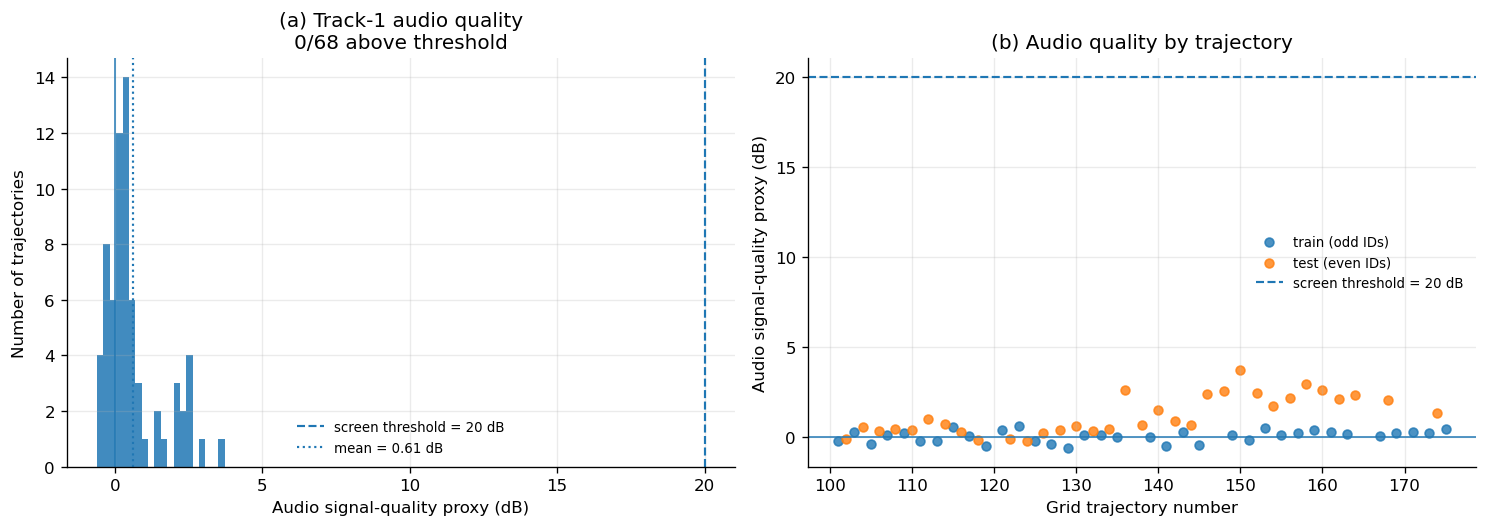


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/audio_signal_quality_screening.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/audio_signal_quality_by_trajectory.csv
JSON   : /data/luvira/reports/reviewer_reproduction/tables/audio_signal_quality_summary.json

CELL 8 PASSED — audio exclusion screen reproduced.


In [10]:
# =============================================================================
# CELL 8 — Audio signal-quality screening and exclusion verification
# =============================================================================
#
# Reproduces the audio exclusion experiment used in the original analysis.
#
# IMPORTANT INTERPRETATION
# ------------------------
# The quantity called "SNR" in the original notebook is an implementation-
# defined signal-quality proxy:
#
#     full-recording RMS power
#     ------------------------
#     final-0.5-s RMS power
#
# expressed in dB.
#
# It is NOT presented here as a calibrated acoustic SNR measurement and
# it is NOT a direct position-correlation statistic.
#
# This cell exists to reproduce the exact screening calculation that led
# to audio being excluded from the subsequent localization/fusion models.
#
# Original reported result:
#
#     mean proxy SNR   = 0.61 dB
#     range            = -0.61 to 3.72 dB
#     pass at 20 dB    = 0 / 68 trajectories
#
# The later localization experiments therefore retain:
#
#     Radio + Depth + Colour
# =============================================================================

print("=" * 72)
print("CELL 8 — AUDIO SIGNAL-QUALITY SCREENING")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Original implementation threshold
# -----------------------------------------------------------------------------

AUDIO_SCREEN_THRESHOLD_DB = 20.0

AUDIO_NOISE_TAIL_SECONDS = 0.5


# -----------------------------------------------------------------------------
# 2. Confirm audio metadata exists in the trajectory index
# -----------------------------------------------------------------------------

assert "audio_dir" in idx.columns, (
    "trajectory_index.csv does not contain the 'audio_dir' column."
)


idx["audio_dir_path"] = idx[
    "audio_dir"
].apply(
    resolve_dataset_path
)


def extract_track_number(path):
    """
    Extract an integer track number from common LuViRA WAV filenames.

    Examples handled:
        Track 1.wav
        Track1.wav
        Track_1.wav
        track-1.wav
    """

    match = re.search(
        r"track[\s_\-]*(\d+)",
        path.stem,
        flags=re.IGNORECASE,
    )

    if match is None:
        return None

    return int(
        match.group(1)
    )


def find_audio_track1(audio_directory):
    """
    Return microphone Track 1 robustly.

    We select track number 1 explicitly rather than relying on
    lexicographic sorting, which could place Track10 before Track2.
    """

    audio_directory = Path(
        audio_directory
    )

    if not audio_directory.is_dir():
        raise FileNotFoundError(
            f"Audio directory does not exist: {audio_directory}"
        )

    wav_files = list(
        audio_directory.glob("*.wav")
    )

    track1_candidates = [
        p
        for p in wav_files
        if extract_track_number(p) == 1
    ]

    if len(track1_candidates) != 1:
        raise RuntimeError(
            f"Expected exactly one Track 1 WAV in "
            f"{audio_directory}; found {len(track1_candidates)}."
        )

    return track1_candidates[0]


# -----------------------------------------------------------------------------
# 3. Exact screening statistic from the original analysis
# -----------------------------------------------------------------------------

def audio_snr_proxy(
    wav_path,
    noise_tail_seconds=AUDIO_NOISE_TAIL_SECONDS,
):
    """
    Reproduce the original audio quality statistic.

    Numerator:
        RMS over the full recording

    Denominator/noise proxy:
        RMS over the final 0.5 seconds

    Return:
        10*log10(P_full / P_tail)

    Since P = RMS^2, this is equivalent to
        20*log10(RMS_full / RMS_tail).
    """

    audio, sample_rate = sf.read(
        str(wav_path)
    )

    audio = np.asarray(
        audio,
        dtype=np.float32,
    )


    # If a file unexpectedly contains multiple channels,
    # average channels to a single waveform deterministically.
    if audio.ndim == 2:

        audio = audio.mean(
            axis=1
        )


    if audio.ndim != 1:
        raise ValueError(
            f"Unexpected WAV shape {audio.shape}: {wav_path}"
        )


    if len(audio) == 0:
        raise ValueError(
            f"Empty WAV file: {wav_path}"
        )


    n_noise = int(
        round(
            sample_rate
            * noise_tail_seconds
        )
    )


    if len(audio) < n_noise:
        raise ValueError(
            f"Recording shorter than "
            f"{noise_tail_seconds:.1f} s: {wav_path}"
        )


    noise_tail = audio[
        -n_noise:
    ]


    full_rms = float(
        np.sqrt(
            np.mean(
                audio ** 2
            )
        )
    )


    tail_rms = float(
        np.sqrt(
            np.mean(
                noise_tail ** 2
            )
        )
    )


    proxy_db = float(
        10.0
        * np.log10(
            (
                full_rms ** 2
            )
            /
            (
                tail_rms ** 2
                + 1e-12
            )
        )
    )


    duration_s = (
        len(audio)
        / float(sample_rate)
    )


    return {
        "sample_rate_hz":
            int(sample_rate),

        "samples":
            int(len(audio)),

        "duration_s":
            float(duration_s),

        "full_rms":
            full_rms,

        "tail_rms":
            tail_rms,

        "snr_proxy_db":
            proxy_db,
    }


# -----------------------------------------------------------------------------
# 4. Verify all 68 radio-usable grids have Track 1
# -----------------------------------------------------------------------------

audio_rows = []


print(
    "\nA. Locating Track 1 for all 68 grid trajectories ..."
)


for count, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    original_index_row = idx.loc[
        idx[
            "trajectory_id"
        ] == tid
    ].iloc[0]


    audio_dir = original_index_row[
        "audio_dir_path"
    ]


    assert (
        audio_dir is not None
        and Path(audio_dir).is_dir()
    ), (
        f"{tid}: missing audio directory: {audio_dir}"
    )


    track1_path = find_audio_track1(
        audio_dir
    )


    result = audio_snr_proxy(
        track1_path
    )


    audio_rows.append({

        "trajectory_id":
            tid,

        "grid_num":
            int(
                row[
                    "grid_num"
                ]
            ),

        "split":
            (
                "train"
                if int(row["grid_num"]) % 2 == 1
                else "test"
            ),

        "track1_path":
            str(
                track1_path
            ),

        "sample_rate_hz":
            result[
                "sample_rate_hz"
            ],

        "samples":
            result[
                "samples"
            ],

        "duration_s":
            result[
                "duration_s"
            ],

        "full_rms":
            result[
                "full_rms"
            ],

        "tail_rms":
            result[
                "tail_rms"
            ],

        "snr_proxy_db":
            result[
                "snr_proxy_db"
            ],
    })


    if (
        count % 10 == 0
        or count == len(grid_all)
    ):

        print(
            f"  completed "
            f"{count:2d}/{len(grid_all)} trajectories"
        )


audio_quality_df = pd.DataFrame(
    audio_rows
)


# -----------------------------------------------------------------------------
# 5. Verify audio acquisition rate
# -----------------------------------------------------------------------------

sample_rates = (
    audio_quality_df[
        "sample_rate_hz"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nB. Audio acquisition audit"
)

print("-" * 72)


for sr, count in sample_rates.items():

    print(
        f"{int(sr):,} Hz : "
        f"{int(count)}/68 trajectories"
    )


assert (
    audio_quality_df[
        "sample_rate_hz"
    ] == AUDIO_RATE_HZ
).all(), (
    f"Expected all Track-1 WAV files at "
    f"{AUDIO_RATE_HZ:,} Hz."
)


print(
    f"\nMedian Track-1 duration : "
    f"{audio_quality_df['duration_s'].median():.2f} s"
)


# -----------------------------------------------------------------------------
# 6. Reproduce the original screening statistics
# -----------------------------------------------------------------------------

mean_snr_proxy_db = float(
    audio_quality_df[
        "snr_proxy_db"
    ].mean()
)


min_snr_proxy_db = float(
    audio_quality_df[
        "snr_proxy_db"
    ].min()
)


max_snr_proxy_db = float(
    audio_quality_df[
        "snr_proxy_db"
    ].max()
)


n_audio_pass = int(
    (
        audio_quality_df[
            "snr_proxy_db"
        ]
        >= AUDIO_SCREEN_THRESHOLD_DB
    ).sum()
)


train_mean_proxy = float(

    audio_quality_df.loc[
        audio_quality_df[
            "split"
        ] == "train",
        "snr_proxy_db",
    ].mean()
)


test_mean_proxy = float(

    audio_quality_df.loc[
        audio_quality_df[
            "split"
        ] == "test",
        "snr_proxy_db",
    ].mean()
)


print(
    "\nC. Track-1 signal-quality proxy"
)

print("-" * 72)

print(
    f"Mean                  : "
    f"{mean_snr_proxy_db:.2f} dB"
)

print(
    f"Range                 : "
    f"{min_snr_proxy_db:.2f} to "
    f"{max_snr_proxy_db:.2f} dB"
)

print(
    f"Original threshold    : "
    f"{AUDIO_SCREEN_THRESHOLD_DB:.1f} dB"
)

print(
    f"Pass threshold        : "
    f"{n_audio_pass}/68"
)

print(
    f"Train mean            : "
    f"{train_mean_proxy:.2f} dB"
)

print(
    f"Test mean             : "
    f"{test_mean_proxy:.2f} dB"
)


# -----------------------------------------------------------------------------
# 7. Verify exact values from the completed analysis
# -----------------------------------------------------------------------------

assert np.isclose(
    mean_snr_proxy_db,
    0.61,
    atol=0.03,
), (
    f"Expected mean audio proxy ≈0.61 dB; "
    f"observed {mean_snr_proxy_db:.4f} dB."
)


assert np.isclose(
    min_snr_proxy_db,
    -0.61,
    atol=0.04,
), (
    f"Expected minimum ≈-0.61 dB; "
    f"observed {min_snr_proxy_db:.4f} dB."
)


assert np.isclose(
    max_snr_proxy_db,
    3.72,
    atol=0.04,
), (
    f"Expected maximum ≈3.72 dB; "
    f"observed {max_snr_proxy_db:.4f} dB."
)


assert n_audio_pass == 0, (
    "At least one grid trajectory now passes the "
    "original audio screening threshold."
)


# -----------------------------------------------------------------------------
# 8. Reviewer-readable interpretation
# -----------------------------------------------------------------------------

print(
    "\nD. Modality decision"
)

print("-" * 72)

print(
    "Audio screening method : "
    "full-recording RMS relative to final-0.5-s RMS proxy"
)

print(
    f"Observed mean proxy     : "
    f"{mean_snr_proxy_db:.2f} dB"
)

print(
    f"Trajectories passing    : "
    f"{n_audio_pass}/68"
)

print(
    "Decision used in study : "
    "audio excluded before localization/fusion training"
)

print(
    "Modalities retained    : "
    "radio + depth + colour"
)

print(
    "\nNote:"
)

print(
    "  This reproduces the original implementation's "
    "audio quality screen."
)

print(
    "  It should not be interpreted as a calibrated "
    "acoustic SNR estimator or as a direct"
)

print(
    "  audio-position correlation test."
)


# -----------------------------------------------------------------------------
# 9. Produce reviewer-verification figure
# -----------------------------------------------------------------------------
#
# Audio screening is part of the reproducibility package even though
# this plot is not one of the numbered main-paper figures.
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.5),
)


# -------------------------------------------------------------------------
# Panel (a): distribution
# -------------------------------------------------------------------------

axes[0].hist(
    audio_quality_df[
        "snr_proxy_db"
    ],
    bins=20,
    alpha=0.85,
)


axes[0].axvline(
    AUDIO_SCREEN_THRESHOLD_DB,
    linestyle="--",
    linewidth=1.3,
    label=(
        f"screen threshold = "
        f"{AUDIO_SCREEN_THRESHOLD_DB:.0f} dB"
    ),
)


axes[0].axvline(
    mean_snr_proxy_db,
    linestyle=":",
    linewidth=1.3,
    label=(
        f"mean = "
        f"{mean_snr_proxy_db:.2f} dB"
    ),
)


axes[0].axvline(
    0.0,
    linewidth=0.9,
)


axes[0].set_xlabel(
    "Audio signal-quality proxy (dB)"
)

axes[0].set_ylabel(
    "Number of trajectories"
)

axes[0].set_title(
    "(a) Track-1 audio quality\n"
    f"{n_audio_pass}/68 above threshold"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25,
)


# -------------------------------------------------------------------------
# Panel (b): per-trajectory value
# -------------------------------------------------------------------------

for split in [
    "train",
    "test",
]:

    mask = (
        audio_quality_df[
            "split"
        ] == split
    )


    axes[1].scatter(
        audio_quality_df.loc[
            mask,
            "grid_num",
        ],
        audio_quality_df.loc[
            mask,
            "snr_proxy_db",
        ],
        s=28,
        alpha=0.8,
        label=(
            "train (odd IDs)"
            if split == "train"
            else "test (even IDs)"
        ),
    )


axes[1].axhline(
    AUDIO_SCREEN_THRESHOLD_DB,
    linestyle="--",
    linewidth=1.3,
    label=(
        f"screen threshold = "
        f"{AUDIO_SCREEN_THRESHOLD_DB:.0f} dB"
    ),
)


axes[1].axhline(
    0.0,
    linewidth=0.9,
)


axes[1].set_xlabel(
    "Grid trajectory number"
)

axes[1].set_ylabel(
    "Audio signal-quality proxy (dB)"
)

axes[1].set_title(
    "(b) Audio quality by trajectory"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25,
)


fig.tight_layout()


audio_figure_path = (
    FIG_DIR
    / "audio_signal_quality_screening.png"
)


fig.savefig(
    audio_figure_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 10. Save reviewer-verification outputs
# -----------------------------------------------------------------------------

audio_quality_df.to_csv(
    TABLE_DIR
    / "audio_signal_quality_by_trajectory.csv",
    index=False,
)


audio_summary = {

    "track":
        1,

    "expected_sample_rate_hz":
        int(
            AUDIO_RATE_HZ
        ),

    "screening_metric":
        (
            "10*log10(full_recording_RMS^2 / "
            "final_0.5s_RMS^2)"
        ),

    "noise_proxy_tail_seconds":
        float(
            AUDIO_NOISE_TAIL_SECONDS
        ),

    "screen_threshold_db":
        float(
            AUDIO_SCREEN_THRESHOLD_DB
        ),

    "mean_proxy_db":
        mean_snr_proxy_db,

    "minimum_proxy_db":
        min_snr_proxy_db,

    "maximum_proxy_db":
        max_snr_proxy_db,

    "trajectories_passing_threshold":
        n_audio_pass,

    "total_grid_trajectories":
        int(
            len(audio_quality_df)
        ),

    "study_decision":
        "audio excluded",

    "retained_modalities":
        [
            "radio",
            "depth",
            "colour",
        ],

    "interpretation_warning":
        (
            "This reproduces an implementation-defined "
            "signal-quality proxy; it is not a calibrated "
            "acoustic SNR or a direct audio-position "
            "correlation statistic."
        ),
}


with open(
    TABLE_DIR
    / "audio_signal_quality_summary.json",
    "w",
) as f:

    json.dump(
        audio_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {audio_figure_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'audio_signal_quality_by_trajectory.csv'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'audio_signal_quality_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 8 PASSED — "
    "audio exclusion screen reproduced."
)

print(
    "=" * 72
)

CELL 9 — HEADING DISTRIBUTION SHIFT / FIGURE 6

A. Heading-analysis population
------------------------------------------------------------------------
Grid trajectories with antenna GT   : 68
Random trajectories with antenna GT : 10
Random trajectories with radio + GT : 9

Random GT trajectories without a usable radio recording:
  random_rect1

B. Computing grid heading traces ...
  completed 10/68 grids
  completed 20/68 grids
  completed 30/68 grids
  completed 40/68 grids
  completed 50/68 grids
  completed 60/68 grids
  completed 68/68 grids

C. Computing random heading traces ...
  random_circle1                unwrapped total =    605.3 deg
  random_circle2                unwrapped total =    639.1 deg
  random_diag1                  unwrapped total =    460.5 deg
  random_manual3                unwrapped total =    730.8 deg
  random_manual4                unwrapped total =    627.4 deg
  random_manual5                unwrapped total =    894.6 deg
  random_manual_paople1      

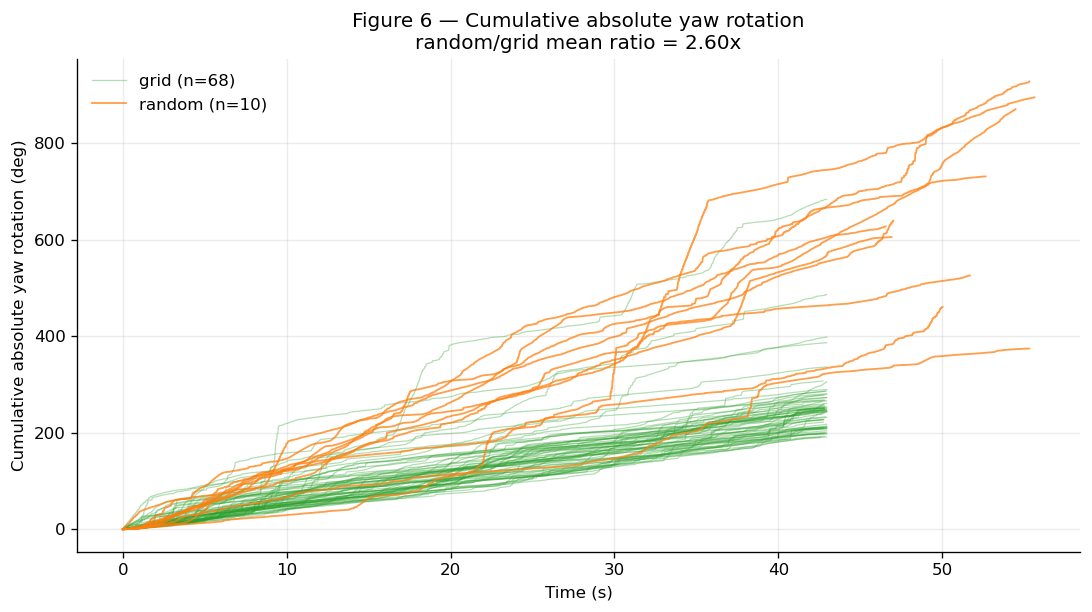


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_06_cumulative_yaw_rotation.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_06_heading_by_trajectory.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_06_heading_population.csv
JSON   : /data/luvira/reports/reviewer_reproduction/tables/figure_06_heading_summary.json

CELL 9 PASSED — heading population and Figure 6 audited.


In [11]:
# =============================================================================
# CELL 9 — Heading distribution shift / cumulative yaw rotation
# =============================================================================
#
# Reproduces and audits manuscript Figure 6.
#
# Purpose:
#   Determine whether the free-form/random trajectories differ from
#   the grid trajectories primarily in antenna heading.
#
# Two rotation totals are recorded:
#
#   1. legacy_raw_total_deg
#      sum(abs(diff(raw yaw degrees)))
#
#      This exactly reproduces the summary statistic used in the
#      original analysis notebook.
#
#   2. unwrapped_total_deg
#      sum(abs(diff(unwrapped yaw)))
#
#      This is the physically appropriate angular cumulative rotation,
#      because +/-180-degree wrap crossings are removed first.
#
# Figure 6 is generated from the UNWRAPPED cumulative rotation.
#
# Population:
#   Grid heading analysis   -> all 68 usable grid trajectories
#   Random heading analysis -> every random trajectory with antenna GT
#
# Note:
#   Heading analysis does NOT require a radio recording.
#   Therefore the random count may exceed the 9 radio-usable trajectories.
# =============================================================================

print("=" * 72)
print("CELL 9 — HEADING DISTRIBUTION SHIFT / FIGURE 6")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Define the GT-usable random heading population
# -----------------------------------------------------------------------------
#
# Cell 2 defined RANDOM_RADIO_IDS using:
#
#     random + radio file + antenna GT
#
# Figure 6 only requires antenna GT, so its eligibility criterion is:
#
#     random + antenna GT
# -----------------------------------------------------------------------------

random_heading = idx[
    (idx["kind"] == "random")
    & idx["gt_radio_ok"]
].copy()


random_heading = (
    random_heading
    .sort_values("trajectory_id")
    .reset_index(drop=True)
)


RANDOM_HEADING_IDS = random_heading[
    "trajectory_id"
].tolist()


print("\nA. Heading-analysis population")
print("-" * 72)

print(
    f"Grid trajectories with antenna GT   : "
    f"{len(grid_all)}"
)

print(
    f"Random trajectories with antenna GT : "
    f"{len(random_heading)}"
)

print(
    f"Random trajectories with radio + GT : "
    f"{len(random_radio)}"
)


heading_without_radio = sorted(
    set(RANDOM_HEADING_IDS)
    - set(RANDOM_RADIO_IDS)
)


print(
    "\nRandom GT trajectories without a usable radio recording:"
)

if heading_without_radio:

    for tid in heading_without_radio:
        print(f"  {tid}")

else:

    print("  none")


# Manuscript Figure 6 states grid n=68 and random n=10.
assert len(grid_all) == 68

assert len(random_heading) == 10, (
    "The manuscript Figure 6 states random n=10, "
    f"but the trajectory index contains "
    f"{len(random_heading)} random trajectories with antenna GT."
)


assert len(random_radio) == 9


assert set(
    RANDOM_RADIO_IDS
).issubset(
    set(RANDOM_HEADING_IDS)
), (
    "A radio-usable random trajectory is missing antenna GT."
)


# -----------------------------------------------------------------------------
# 2. Yaw-processing helper
# -----------------------------------------------------------------------------

def yaw_rotation_trace(gt):
    """
    Return raw and wrap-corrected yaw-rotation diagnostics.

    LuViRA radio/antenna GT:
        column 0 -> timestamp [s]
        column 6 -> yaw [degrees]
    """

    gt = np.asarray(
        gt,
        dtype=np.float64,
    )


    time_s = (
        gt[:, 0]
        - gt[0, 0]
    )


    yaw_raw_deg = gt[
        :,
        6,
    ]


    # -------------------------------------------------------------
    # Physically continuous angular representation
    # -------------------------------------------------------------
    yaw_unwrapped_deg = np.rad2deg(
        np.unwrap(
            np.deg2rad(
                yaw_raw_deg
            )
        )
    )


    # -------------------------------------------------------------
    # Original notebook statistic
    # -------------------------------------------------------------
    raw_step_deg = np.abs(
        np.diff(
            yaw_raw_deg
        )
    )


    legacy_cumulative_deg = np.concatenate(
        [
            [0.0],
            np.cumsum(
                raw_step_deg
            ),
        ]
    )


    # -------------------------------------------------------------
    # Correct wrap-aware cumulative absolute rotation
    # -------------------------------------------------------------
    unwrapped_step_deg = np.abs(
        np.diff(
            yaw_unwrapped_deg
        )
    )


    cumulative_abs_deg = np.concatenate(
        [
            [0.0],
            np.cumsum(
                unwrapped_step_deg
            ),
        ]
    )


    return {

        "time_s":
            time_s,

        "yaw_raw_deg":
            yaw_raw_deg,

        "yaw_unwrapped_deg":
            yaw_unwrapped_deg,

        "legacy_cumulative_deg":
            legacy_cumulative_deg,

        "cumulative_abs_deg":
            cumulative_abs_deg,

        "legacy_raw_total_deg":
            float(
                legacy_cumulative_deg[-1]
            ),

        "unwrapped_total_deg":
            float(
                cumulative_abs_deg[-1]
            ),

        "net_unwrapped_heading_change_deg":
            float(
                abs(
                    yaw_unwrapped_deg[-1]
                    - yaw_unwrapped_deg[0]
                )
            ),

        "max_single_raw_step_deg":
            float(
                raw_step_deg.max()
            ),

        "max_single_unwrapped_step_deg":
            float(
                unwrapped_step_deg.max()
            ),
    }


# -----------------------------------------------------------------------------
# 3. Process all 68 grid trajectories
# -----------------------------------------------------------------------------

heading_summary_rows = []

heading_traces = {}


print(
    "\nB. Computing grid heading traces ..."
)


for count, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    gt = load_gt(
        row[
            "gt_radio_path"
        ]
    )


    result = yaw_rotation_trace(
        gt
    )


    heading_traces[
        tid
    ] = result


    heading_summary_rows.append({

        "trajectory_id":
            tid,

        "family":
            "grid",

        "radio_usable":
            True,

        "duration_s":
            float(
                result[
                    "time_s"
                ][-1]
            ),

        "legacy_raw_total_deg":
            result[
                "legacy_raw_total_deg"
            ],

        "unwrapped_total_deg":
            result[
                "unwrapped_total_deg"
            ],

        "net_heading_change_deg":
            result[
                "net_unwrapped_heading_change_deg"
            ],

        "max_raw_step_deg":
            result[
                "max_single_raw_step_deg"
            ],

        "max_unwrapped_step_deg":
            result[
                "max_single_unwrapped_step_deg"
            ],
    })


    if (
        count % 10 == 0
        or count == len(grid_all)
    ):

        print(
            f"  completed "
            f"{count:2d}/{len(grid_all)} grids"
        )


# -----------------------------------------------------------------------------
# 4. Process the random trajectories having antenna GT
# -----------------------------------------------------------------------------

print(
    "\nC. Computing random heading traces ..."
)


for count, (_, row) in enumerate(
    random_heading.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    gt = load_gt(
        row[
            "gt_radio_path"
        ]
    )


    result = yaw_rotation_trace(
        gt
    )


    heading_traces[
        tid
    ] = result


    heading_summary_rows.append({

        "trajectory_id":
            tid,

        "family":
            "random",

        "radio_usable":
            bool(
                tid
                in set(
                    RANDOM_RADIO_IDS
                )
            ),

        "duration_s":
            float(
                result[
                    "time_s"
                ][-1]
            ),

        "legacy_raw_total_deg":
            result[
                "legacy_raw_total_deg"
            ],

        "unwrapped_total_deg":
            result[
                "unwrapped_total_deg"
            ],

        "net_heading_change_deg":
            result[
                "net_unwrapped_heading_change_deg"
            ],

        "max_raw_step_deg":
            result[
                "max_single_raw_step_deg"
            ],

        "max_unwrapped_step_deg":
            result[
                "max_single_unwrapped_step_deg"
            ],
    })


    print(
        f"  {tid:28s}  "
        f"unwrapped total = "
        f"{result['unwrapped_total_deg']:8.1f} deg"
    )


heading_df = pd.DataFrame(
    heading_summary_rows
)


# -----------------------------------------------------------------------------
# 5. Reproduce the LEGACY summary from the original analysis
# -----------------------------------------------------------------------------
#
# The old notebook restricted randoms to the 9 radio-usable trajectories
# and used raw-yaw absolute differences.
#
# Reported original values:
#
#       Grid mean    = 255.9 deg
#       Random mean  = 880.6 deg
#       Ratio        = 3.4x
#
# We retain this check only to demonstrate exactly where the historical
# manuscript-supporting number came from.
# -----------------------------------------------------------------------------

legacy_grid = heading_df[
    heading_df[
        "family"
    ] == "grid"
]


legacy_random_radio = heading_df[
    (
        heading_df[
            "family"
        ] == "random"
    )
    &
    (
        heading_df[
            "radio_usable"
        ]
    )
]


legacy_grid_mean = float(
    legacy_grid[
        "legacy_raw_total_deg"
    ].mean()
)


legacy_random_mean = float(
    legacy_random_radio[
        "legacy_raw_total_deg"
    ].mean()
)


legacy_ratio = (
    legacy_random_mean
    / legacy_grid_mean
)


print(
    "\nD. Historical implementation check"
)

print("-" * 72)

print(
    "Population for historical comparison:"
)

print(
    f"  grids         : "
    f"{len(legacy_grid)}"
)

print(
    f"  random radio  : "
    f"{len(legacy_random_radio)}"
)


print(
    f"\nLegacy grid mean total rotation   : "
    f"{legacy_grid_mean:.1f} deg"
)

print(
    f"Legacy random mean total rotation : "
    f"{legacy_random_mean:.1f} deg"
)

print(
    f"Legacy random/grid ratio          : "
    f"{legacy_ratio:.2f}x"
)


assert np.isclose(
    legacy_grid_mean,
    255.9,
    atol=0.2,
), (
    "Historical grid yaw statistic does not reproduce."
)


assert np.isclose(
    legacy_random_mean,
    880.6,
    atol=0.3,
), (
    "Historical random yaw statistic does not reproduce."
)


assert np.isclose(
    legacy_ratio,
    3.4,
    atol=0.1,
), (
    "Historical random/grid yaw ratio does not reproduce."
)


# -----------------------------------------------------------------------------
# 6. Reviewer-quality wrap-corrected heading statistics
# -----------------------------------------------------------------------------

grid_heading_df = heading_df[
    heading_df[
        "family"
    ] == "grid"
]


random_heading_df = heading_df[
    heading_df[
        "family"
    ] == "random"
]


grid_unwrapped_mean = float(
    grid_heading_df[
        "unwrapped_total_deg"
    ].mean()
)


random_unwrapped_mean = float(
    random_heading_df[
        "unwrapped_total_deg"
    ].mean()
)


unwrapped_ratio = (
    random_unwrapped_mean
    / grid_unwrapped_mean
)


grid_unwrapped_median = float(
    grid_heading_df[
        "unwrapped_total_deg"
    ].median()
)


random_unwrapped_median = float(
    random_heading_df[
        "unwrapped_total_deg"
    ].median()
)


print(
    "\nE. Wrap-corrected cumulative absolute yaw"
)

print("-" * 72)


print(
    f"Grid n                      : "
    f"{len(grid_heading_df)}"
)

print(
    f"Random n                    : "
    f"{len(random_heading_df)}"
)


print(
    f"\nGrid mean total rotation    : "
    f"{grid_unwrapped_mean:.1f} deg"
)

print(
    f"Random mean total rotation  : "
    f"{random_unwrapped_mean:.1f} deg"
)

print(
    f"Random / grid ratio         : "
    f"{unwrapped_ratio:.2f}x"
)


print(
    f"\nGrid median total rotation  : "
    f"{grid_unwrapped_median:.1f} deg"
)

print(
    f"Random median total rotation: "
    f"{random_unwrapped_median:.1f} deg"
)


print(
    "\nManuscript qualitative statement:"
)

print(
    "  random trajectories rotate approximately "
    "3x more than grid trajectories"
)


# Do not force an exact 3.0 value.
# This assertion only checks that the qualitative effect is substantial.
assert unwrapped_ratio > 2.0, (
    "After wrap correction, random trajectories no longer "
    "show substantially greater cumulative yaw than grids."
)


# -----------------------------------------------------------------------------
# 7. Quantify the impact of angle wrapping
# -----------------------------------------------------------------------------

heading_df[
    "wrap_inflation_deg"
] = (
    heading_df[
        "legacy_raw_total_deg"
    ]
    - heading_df[
        "unwrapped_total_deg"
    ]
)


heading_df[
    "wrap_inflation_percent"
] = (
    100.0
    * heading_df[
        "wrap_inflation_deg"
    ]
    / (
        heading_df[
            "unwrapped_total_deg"
        ]
        + 1e-12
    )
)


print(
    "\nF. Angle-wrap diagnostic"
)

print("-" * 72)


print(
    f"Median raw-vs-unwrapped inflation, grids   : "
    f"{grid_heading_df['legacy_raw_total_deg'].median() - grid_heading_df['unwrapped_total_deg'].median():.1f} deg"
)


print(
    f"Mean wrap inflation, all trajectories      : "
    f"{heading_df['wrap_inflation_deg'].mean():.1f} deg"
)


large_wrap_rows = heading_df[
    heading_df[
        "wrap_inflation_deg"
    ] > 100.0
][
    [
        "trajectory_id",
        "family",
        "legacy_raw_total_deg",
        "unwrapped_total_deg",
        "wrap_inflation_deg",
    ]
]


if len(
    large_wrap_rows
) > 0:

    print(
        "\nTrajectories with >100 deg inflation "
        "from raw angle wrapping:"
    )

    print(
        large_wrap_rows.to_string(
            index=False,
            formatters={

                "legacy_raw_total_deg":
                    lambda x: f"{x:.1f}",

                "unwrapped_total_deg":
                    lambda x: f"{x:.1f}",

                "wrap_inflation_deg":
                    lambda x: f"{x:.1f}",
            },
        )
    )

else:

    print(
        "\nNo trajectory has >100 deg of "
        "angle-wrap inflation."
    )


# -----------------------------------------------------------------------------
# 8. Reproduce Figure 6
# -----------------------------------------------------------------------------
#
# One curve per trajectory:
#
#   green  = 68 grid trajectories
#   orange = random trajectories with antenna GT
#
# The y-axis uses wrap-corrected cumulative absolute yaw rotation.
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    1,
    1,
    figsize=(9.2, 5.2),
)


grid_label_done = False


for tid in grid_heading_df[
    "trajectory_id"
]:

    trace = heading_traces[
        tid
    ]


    ax.plot(
        trace[
            "time_s"
        ],
        trace[
            "cumulative_abs_deg"
        ],
        linewidth=0.75,
        alpha=0.35,
        color="tab:green",
        label=(
            f"grid (n={len(grid_heading_df)})"
            if not grid_label_done
            else None
        ),
    )

    grid_label_done = True


random_label_done = False


for tid in random_heading_df[
    "trajectory_id"
]:

    trace = heading_traces[
        tid
    ]


    ax.plot(
        trace[
            "time_s"
        ],
        trace[
            "cumulative_abs_deg"
        ],
        linewidth=1.1,
        alpha=0.75,
        color="tab:orange",
        label=(
            f"random (n={len(random_heading_df)})"
            if not random_label_done
            else None
        ),
    )

    random_label_done = True


ax.set_xlabel(
    "Time (s)"
)

ax.set_ylabel(
    "Cumulative absolute yaw rotation (deg)"
)

ax.set_title(
    "Figure 6 — Cumulative absolute yaw rotation\n"
    f"random/grid mean ratio = {unwrapped_ratio:.2f}x"
)

ax.legend(
    frameon=False,
)

ax.grid(
    alpha=0.25,
)


fig.tight_layout()


figure6_path = (
    FIG_DIR
    / "figure_06_cumulative_yaw_rotation.png"
)


fig.savefig(
    figure6_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 9. Save numerical support for reviewers
# -----------------------------------------------------------------------------

heading_df.to_csv(
    TABLE_DIR
    / "figure_06_heading_by_trajectory.csv",
    index=False,
)


heading_population_df = pd.DataFrame({

    "population": [
        "grid with antenna GT",
        "random with antenna GT",
        "random with radio + antenna GT",
    ],

    "count": [
        len(grid_heading_df),
        len(random_heading_df),
        len(random_radio),
    ],
})


heading_population_df.to_csv(
    TABLE_DIR
    / "figure_06_heading_population.csv",
    index=False,
)


heading_summary = {

    "yaw_gt_column":
        6,

    "figure_metric":
        (
            "cumulative absolute difference of "
            "unwrapped yaw"
        ),

    "grid_heading_trajectories":
        int(
            len(grid_heading_df)
        ),

    "random_heading_trajectories":
        int(
            len(random_heading_df)
        ),

    "random_radio_usable_trajectories":
        int(
            len(random_radio)
        ),

    "heading_only_random_without_radio":
        heading_without_radio,

    "legacy_grid_mean_total_deg":
        legacy_grid_mean,

    "legacy_radio_random_mean_total_deg":
        legacy_random_mean,

    "legacy_radio_random_to_grid_ratio":
        float(
            legacy_ratio
        ),

    "unwrapped_grid_mean_total_deg":
        grid_unwrapped_mean,

    "unwrapped_random_mean_total_deg":
        random_unwrapped_mean,

    "unwrapped_random_to_grid_ratio":
        float(
            unwrapped_ratio
        ),

    "unwrapped_grid_median_total_deg":
        grid_unwrapped_median,

    "unwrapped_random_median_total_deg":
        random_unwrapped_median,
}


with open(
    TABLE_DIR
    / "figure_06_heading_summary.json",
    "w",
) as f:

    json.dump(
        heading_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {figure6_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_06_heading_by_trajectory.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_06_heading_population.csv'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'figure_06_heading_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 9 PASSED — "
    "heading population and Figure 6 audited."
)

print(
    "=" * 72
)

CELL 10 — SPATIAL COVERAGE AND CSI FEATURE-SPACE SHIFT
Wavelength references: lambda = 81.00 mm, lambda/2 = 40.50 mm, lambda/4 = 20.25 mm

A. Figure-7 population
------------------------------------------------------------------------
Grid trajectories       : 68
  training odd IDs      : 35
  test even IDs         : 33
Radio-usable randoms    : 9

B. Historical spatial-coverage calculation
------------------------------------------------------------------------
All-grid reference positions : 291,603
Random GT positions          : 46,398
Quarter wavelength           : 20.25 mm

Per-random-trajectory nearest ALL-68-grid distances:
        trajectory_id median_nearest_all68_mm p95_nearest_all68_mm max_nearest_all68_mm fraction_points_within_lambda4_all68
       random_circle1                    13.0                 40.5                 57.4                                65.3%
       random_circle2                    11.2                 39.2                 58.5                         

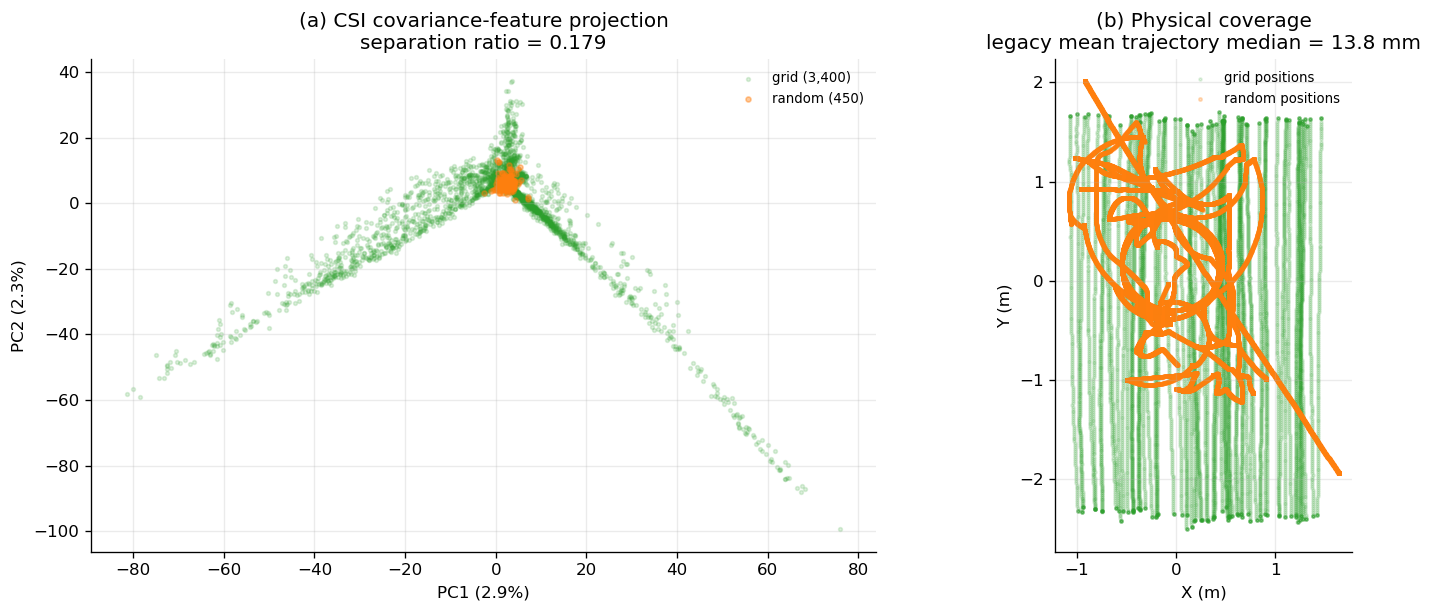

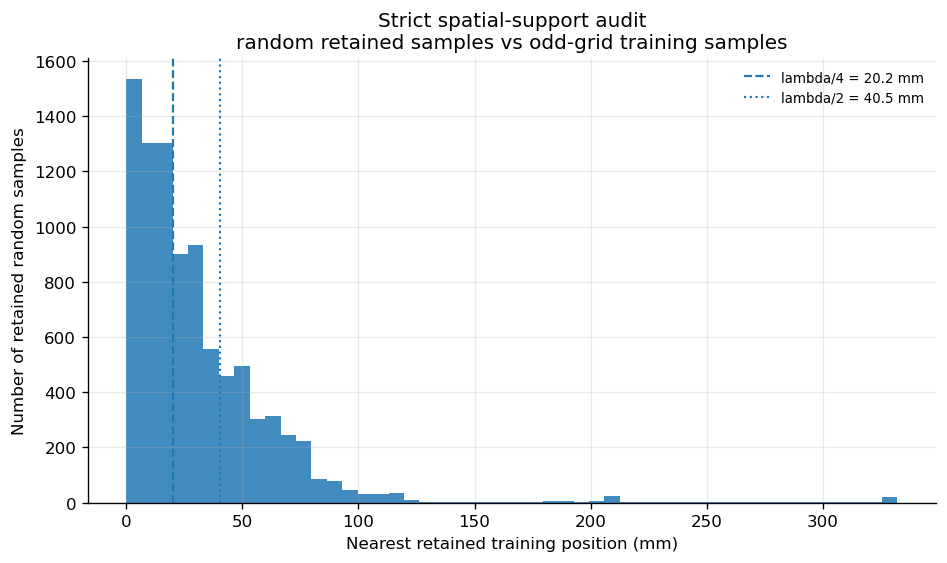


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_07_distribution_shift.png
Figure : /data/luvira/reports/reviewer_reproduction/figures/figure_07_strict_training_support_audit.png
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_07_historical_spatial_coverage.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_07_strict_training_coverage.csv
Table  : /data/luvira/reports/reviewer_reproduction/tables/figure_07_csi_pca_projection.csv
JSON   : /data/luvira/reports/reviewer_reproduction/tables/figure_07_distribution_shift_summary.json

CELL 10 PASSED — Figure 7 reproduced and strict spatial support audited.


In [13]:
# =============================================================================
# CELL 10 — Spatial coverage and CSI feature-space distribution shift
# =============================================================================
#
# Reproduces manuscript Figure 7 and performs a stricter spatial audit.
#
# PART A — HISTORICAL FIGURE-7 REPRODUCTION
#
# Spatial coverage:
#   * reference positions = ALL GT rows from all 68 grid trajectories
#   * random population   = 9 radio-usable random trajectories
#   * nearest-neighbour distance computed for every random GT position
#   * each trajectory summarized by its MEDIAN nearest-grid distance
#   * legacy "within lambda/4" test is applied to that trajectory median
#
# Historical result:
#   mean trajectory median nearest distance ~= 13.8 mm
#   9/9 trajectory medians < lambda/4
#
# CSI feature space:
#   * 50 equally spaced radio snapshots per trajectory
#   * 68 grids  -> 3,400 snapshots
#   * 9 randoms ->   450 snapshots
#   * 9,900-d covariance fingerprint
#   * StandardScaler over pooled feature matrix
#   * PCA to 2 dimensions
#   * separation ratio =
#
#         ||mean_grid - mean_random||^2
#         --------------------------------
#         mean within-family squared radius
#
# Historical result:
#   first two PCs ~= 5.2% variance
#   separation ratio ~= 0.179
#
#
# PART B — STRICT REVIEWER AUDIT
#
# The manuscript discusses "training positions", so we additionally compare:
#
#   actual retained random radio samples
#       versus
#   actual retained odd-grid TRAINING radio samples
#
# both after the manuscript's stride-5 sampling rule.
#
# We report:
#   median / 95th / maximum nearest-training distance
#   fraction within lambda/4
#   fraction within lambda/2
#   fraction within lambda
#   fraction inside convex hull of retained training coordinates
#
# No expected value is imposed on this stricter audit.
# Its purpose is to determine exactly what the manuscript may claim.
# =============================================================================


print("=" * 72)
print("CELL 10 — SPATIAL COVERAGE AND CSI FEATURE-SPACE SHIFT")
print("=" * 72)


from scipy.spatial import cKDTree, ConvexHull
from matplotlib.path import Path as MplPath
import gc


# -----------------------------------------------------------------------------
# Wavelength units used in the spatial-support audit
# -----------------------------------------------------------------------------

WAVELENGTH_MM = (
    WAVELENGTH_M
    * 1000.0
)

assert np.isclose(
    WAVELENGTH_MM,
    81.0,
)

assert np.isclose(
    WAVELENGTH_MM / 2.0,
    40.5,
)

assert np.isclose(
    WAVELENGTH_MM / 4.0,
    QUARTER_WAVELENGTH_MM,
)

print(
    f"Wavelength references: "
    f"lambda = {WAVELENGTH_MM:.2f} mm, "
    f"lambda/2 = {WAVELENGTH_MM/2.0:.2f} mm, "
    f"lambda/4 = {QUARTER_WAVELENGTH_MM:.2f} mm"
)

# -----------------------------------------------------------------------------
# 1. Population checks
# -----------------------------------------------------------------------------

assert len(grid_all) == 68

assert len(random_radio) == 9


train_grid_rows = (
    grid_all.loc[
        grid_all["grid_num"] % 2 == 1
    ]
    .copy()
    .sort_values("grid_num")
    .reset_index(drop=True)
)


test_grid_rows = (
    grid_all.loc[
        grid_all["grid_num"] % 2 == 0
    ]
    .copy()
    .sort_values("grid_num")
    .reset_index(drop=True)
)


assert len(train_grid_rows) == 35
assert len(test_grid_rows) == 33


print("\nA. Figure-7 population")
print("-" * 72)

print(
    f"Grid trajectories       : {len(grid_all)}"
)

print(
    f"  training odd IDs      : {len(train_grid_rows)}"
)

print(
    f"  test even IDs         : {len(test_grid_rows)}"
)

print(
    f"Radio-usable randoms    : {len(random_radio)}"
)


# -----------------------------------------------------------------------------
# 2. HISTORICAL spatial coverage calculation
# -----------------------------------------------------------------------------
#
# IMPORTANT:
# This section intentionally reproduces the original implementation.
#
# Reference tree:
#     every GT position from ALL 68 grids
#
# Random:
#     every GT position from the 9 radio-usable random trajectories
# -----------------------------------------------------------------------------

print(
    "\nB. Historical spatial-coverage calculation"
)

print("-" * 72)


historical_grid_positions_parts = []


for _, row in grid_all.iterrows():

    gt = load_gt(
        row["gt_radio_path"]
    )

    historical_grid_positions_parts.append(
        gt[:, 1:3]
        / 1000.0
    )


historical_grid_positions = np.vstack(
    historical_grid_positions_parts
).astype(
    np.float64
)


historical_grid_tree = cKDTree(
    historical_grid_positions
)


historical_coverage_rows = []

historical_random_positions_parts = []


for _, row in random_radio.iterrows():

    tid = row[
        "trajectory_id"
    ]


    gt = load_gt(
        row["gt_radio_path"]
    )


    random_positions_m = (
        gt[:, 1:3]
        / 1000.0
    )


    historical_random_positions_parts.append(
        random_positions_m
    )


    distances_m, _ = historical_grid_tree.query(
        random_positions_m,
        k=1,
    )


    distances_mm = (
        distances_m
        * 1000.0
    )


    historical_coverage_rows.append({

        "trajectory_id":
            tid,

        "random_gt_points":
            int(
                len(random_positions_m)
            ),

        "median_nearest_all68_mm":
            float(
                np.median(
                    distances_mm
                )
            ),

        "mean_nearest_all68_mm":
            float(
                np.mean(
                    distances_mm
                )
            ),

        "p95_nearest_all68_mm":
            float(
                np.percentile(
                    distances_mm,
                    95,
                )
            ),

        "max_nearest_all68_mm":
            float(
                np.max(
                    distances_mm
                )
            ),

        "fraction_points_within_lambda4_all68":
            float(
                np.mean(
                    distances_mm
                    <= QUARTER_WAVELENGTH_MM
                )
            ),
    })


historical_coverage_df = pd.DataFrame(
    historical_coverage_rows
)


historical_random_positions = np.vstack(
    historical_random_positions_parts
).astype(
    np.float64
)


legacy_mean_of_medians_mm = float(
    historical_coverage_df[
        "median_nearest_all68_mm"
    ].mean()
)


legacy_trajectory_fraction_within_lambda4 = float(
    np.mean(
        historical_coverage_df[
            "median_nearest_all68_mm"
        ]
        < QUARTER_WAVELENGTH_MM
    )
)


legacy_point_fraction_within_lambda4 = float(
    historical_coverage_df[
        "fraction_points_within_lambda4_all68"
    ].mul(
        historical_coverage_df[
            "random_gt_points"
        ]
    ).sum()
    /
    historical_coverage_df[
        "random_gt_points"
    ].sum()
)


print(
    f"All-grid reference positions : "
    f"{len(historical_grid_positions):,}"
)

print(
    f"Random GT positions          : "
    f"{len(historical_random_positions):,}"
)

print(
    f"Quarter wavelength           : "
    f"{QUARTER_WAVELENGTH_MM:.2f} mm"
)


print(
    "\nPer-random-trajectory nearest ALL-68-grid distances:"
)


print(
    historical_coverage_df[
        [
            "trajectory_id",
            "median_nearest_all68_mm",
            "p95_nearest_all68_mm",
            "max_nearest_all68_mm",
            "fraction_points_within_lambda4_all68",
        ]
    ].to_string(
        index=False,
        formatters={

            "median_nearest_all68_mm":
                lambda x: f"{x:.1f}",

            "p95_nearest_all68_mm":
                lambda x: f"{x:.1f}",

            "max_nearest_all68_mm":
                lambda x: f"{x:.1f}",

            "fraction_points_within_lambda4_all68":
                lambda x: f"{100*x:.1f}%",
        },
    )
)


print(
    f"\nHistorical mean of trajectory medians : "
    f"{legacy_mean_of_medians_mm:.1f} mm"
)

print(
    f"Trajectory medians below lambda/4     : "
    f"{100*legacy_trajectory_fraction_within_lambda4:.0f}%"
)

print(
    f"Individual points below lambda/4      : "
    f"{100*legacy_point_fraction_within_lambda4:.1f}%"
)


# Exact historical checks.
assert np.isclose(
    legacy_mean_of_medians_mm,
    13.8,
    atol=0.15,
), (
    "Historical mean nearest-grid statistic "
    "does not reproduce approximately 13.8 mm."
)


assert np.isclose(
    legacy_trajectory_fraction_within_lambda4,
    1.0,
), (
    "Historical 9/9 trajectory-median lambda/4 "
    "criterion does not reproduce."
)


# -----------------------------------------------------------------------------
# 3. STRICT reviewer spatial audit
# -----------------------------------------------------------------------------
#
# Actual model support:
#
#     training = odd-grid trajectories only
#     n_use    = min(radio rows, antenna-GT rows)
#     samples  = 0,5,10,... < n_use
#
# Randoms use the same retained radio/GT sampling rule.
# -----------------------------------------------------------------------------

print(
    "\nC. Strict retained-sample spatial audit"
)

print("-" * 72)


training_retained_positions_parts = []


for _, row in train_grid_rows.iterrows():

    gt = load_gt(
        row["gt_radio_path"]
    )


    cache_path = ensure_radio_cache(
        row
    )


    H = np.load(
        cache_path,
        mmap_mode="r",
    )


    n_use = min(
        len(gt),
        H.shape[0],
    )


    retained_idx = np.arange(
        0,
        n_use,
        STRIDE,
        dtype=np.int64,
    )


    training_retained_positions_parts.append(
        gt[
            retained_idx,
            1:3,
        ]
        / 1000.0
    )


    del H


training_retained_positions = np.vstack(
    training_retained_positions_parts
).astype(
    np.float64
)


assert len(
    training_retained_positions
) == 29928, (
    "Strict training-position count must match "
    "Cell 4's 29,928 retained training samples."
)


training_tree = cKDTree(
    training_retained_positions
)


strict_coverage_rows = []

strict_random_positions_parts = []

strict_random_distance_parts = []


for _, row in random_radio.iterrows():

    tid = row[
        "trajectory_id"
    ]


    gt = load_gt(
        row["gt_radio_path"]
    )


    cache_path = ensure_radio_cache(
        row
    )


    H = np.load(
        cache_path,
        mmap_mode="r",
    )


    n_use = min(
        len(gt),
        H.shape[0],
    )


    retained_idx = np.arange(
        0,
        n_use,
        STRIDE,
        dtype=np.int64,
    )


    random_retained_positions = (
        gt[
            retained_idx,
            1:3,
        ]
        / 1000.0
    )


    distances_m, _ = training_tree.query(
        random_retained_positions,
        k=1,
    )


    distances_mm = (
        distances_m
        * 1000.0
    )


    strict_random_positions_parts.append(
        random_retained_positions
    )


    strict_random_distance_parts.append(
        distances_mm
    )


    strict_coverage_rows.append({

        "trajectory_id":
            tid,

        "retained_random_samples":
            int(
                len(
                    random_retained_positions
                )
            ),

        "median_nearest_training_mm":
            float(
                np.median(
                    distances_mm
                )
            ),

        "mean_nearest_training_mm":
            float(
                np.mean(
                    distances_mm
                )
            ),

        "p95_nearest_training_mm":
            float(
                np.percentile(
                    distances_mm,
                    95,
                )
            ),

        "max_nearest_training_mm":
            float(
                np.max(
                    distances_mm
                )
            ),

        "fraction_within_lambda4":
            float(
                np.mean(
                    distances_mm
                    <= QUARTER_WAVELENGTH_MM
                )
            ),

        "fraction_within_lambda2":
            float(
                np.mean(
                    distances_mm
                    <= (
                        WAVELENGTH_MM
                        / 2.0
                    )
                )
            ),

        "fraction_within_lambda":
            float(
                np.mean(
                    distances_mm
                    <= WAVELENGTH_MM
                )
            ),
    })


    del H


strict_coverage_df = pd.DataFrame(
    strict_coverage_rows
)


strict_random_positions = np.vstack(
    strict_random_positions_parts
).astype(
    np.float64
)


strict_random_distances_mm = np.concatenate(
    strict_random_distance_parts
).astype(
    np.float64
)


strict_median_mm = float(
    np.median(
        strict_random_distances_mm
    )
)


strict_mean_mm = float(
    np.mean(
        strict_random_distances_mm
    )
)


strict_p95_mm = float(
    np.percentile(
        strict_random_distances_mm,
        95,
    )
)


strict_max_mm = float(
    np.max(
        strict_random_distances_mm
    )
)


strict_fraction_lambda4 = float(
    np.mean(
        strict_random_distances_mm
        <= QUARTER_WAVELENGTH_MM
    )
)


strict_fraction_lambda2 = float(
    np.mean(
        strict_random_distances_mm
        <= (
            WAVELENGTH_MM
            / 2.0
        )
    )
)


strict_fraction_lambda = float(
    np.mean(
        strict_random_distances_mm
        <= WAVELENGTH_MM
    )
)


print(
    f"Actual retained training positions : "
    f"{len(training_retained_positions):,}"
)

print(
    f"Actual retained random positions   : "
    f"{len(strict_random_positions):,}"
)


print(
    "\nPer-random-trajectory nearest TRAINING distances:"
)


print(
    strict_coverage_df[
        [
            "trajectory_id",
            "retained_random_samples",
            "median_nearest_training_mm",
            "p95_nearest_training_mm",
            "max_nearest_training_mm",
            "fraction_within_lambda4",
        ]
    ].to_string(
        index=False,
        formatters={

            "median_nearest_training_mm":
                lambda x: f"{x:.1f}",

            "p95_nearest_training_mm":
                lambda x: f"{x:.1f}",

            "max_nearest_training_mm":
                lambda x: f"{x:.1f}",

            "fraction_within_lambda4":
                lambda x: f"{100*x:.1f}%",
        },
    )
)


print(
    "\nAll retained random samples versus retained training samples:"
)

print(
    f"  median nearest distance : "
    f"{strict_median_mm:.2f} mm"
)

print(
    f"  mean nearest distance   : "
    f"{strict_mean_mm:.2f} mm"
)

print(
    f"  95th percentile         : "
    f"{strict_p95_mm:.2f} mm"
)

print(
    f"  maximum                 : "
    f"{strict_max_mm:.2f} mm"
)

print(
    f"  within lambda/4         : "
    f"{100*strict_fraction_lambda4:.2f}%"
)

print(
    f"  within lambda/2         : "
    f"{100*strict_fraction_lambda2:.2f}%"
)

print(
    f"  within lambda           : "
    f"{100*strict_fraction_lambda:.2f}%"
)


# -----------------------------------------------------------------------------
# 4. Convex-hull audit of actual training support
# -----------------------------------------------------------------------------
#
# This asks a different spatial question:
#
#     Are the random coordinates geometrically inside the footprint
#     spanned by the retained training data?
#
# It does NOT require them to be within one quarter wavelength of an
# individual training sample.
# -----------------------------------------------------------------------------

training_hull = ConvexHull(
    training_retained_positions
)


training_hull_polygon = (
    training_retained_positions[
        training_hull.vertices
    ]
)


training_hull_path = MplPath(
    training_hull_polygon
)


inside_training_hull = (
    training_hull_path.contains_points(
        strict_random_positions,
        radius=1e-10,
    )
)


strict_fraction_inside_hull = float(
    np.mean(
        inside_training_hull
    )
)


print(
    f"\nRetained random samples inside "
    f"training convex hull : "
    f"{100*strict_fraction_inside_hull:.2f}%"
)


# -----------------------------------------------------------------------------
# 5. CSI covariance feature-space experiment
# -----------------------------------------------------------------------------
#
# Exact original protocol:
#
#     50 equally spaced snapshots from each trajectory
#     all 68 grids
#     all 9 radio-usable randoms
#
#     68 x 50 = 3,400 grid features
#      9 x 50 =   450 random features
#
#     feature dimension = 9,900
# -----------------------------------------------------------------------------

CSI_PCA_SAMPLES_PER_TRAJECTORY = 50


print(
    "\nD. CSI covariance feature-space PCA"
)

print("-" * 72)

print(
    f"Snapshots per trajectory : "
    f"{CSI_PCA_SAMPLES_PER_TRAJECTORY}"
)

print(
    "Extracting covariance fingerprints ..."
)


pca_features = []

pca_labels = []

pca_trajectory_ids = []

pca_snapshot_indices = []


# -------------------------------------------------------------------------
# Grid snapshots
# -------------------------------------------------------------------------

for count, (_, row) in enumerate(
    grid_all.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    cache_path = ensure_radio_cache(
        row
    )


    H = np.load(
        cache_path,
        mmap_mode="r",
    )


    sample_indices = np.linspace(
        0,
        H.shape[0] - 1,
        CSI_PCA_SAMPLES_PER_TRAJECTORY,
        dtype=np.int64,
    )


    for snapshot_idx in sample_indices:

        pca_features.append(
            radio_covariance_feature(
                np.asarray(
                    H[
                        snapshot_idx
                    ]
                )
            )
        )


        pca_labels.append(
            "grid"
        )


        pca_trajectory_ids.append(
            tid
        )


        pca_snapshot_indices.append(
            int(
                snapshot_idx
            )
        )


    del H


    if (
        count % 10 == 0
        or count == len(grid_all)
    ):

        print(
            f"  grid   "
            f"{count:2d}/{len(grid_all)}"
        )


# -------------------------------------------------------------------------
# Random snapshots
# -------------------------------------------------------------------------

for count, (_, row) in enumerate(
    random_radio.iterrows(),
    start=1,
):

    tid = row[
        "trajectory_id"
    ]


    cache_path = ensure_radio_cache(
        row
    )


    H = np.load(
        cache_path,
        mmap_mode="r",
    )


    sample_indices = np.linspace(
        0,
        H.shape[0] - 1,
        CSI_PCA_SAMPLES_PER_TRAJECTORY,
        dtype=np.int64,
    )


    for snapshot_idx in sample_indices:

        pca_features.append(
            radio_covariance_feature(
                np.asarray(
                    H[
                        snapshot_idx
                    ]
                )
            )
        )


        pca_labels.append(
            "random"
        )


        pca_trajectory_ids.append(
            tid
        )


        pca_snapshot_indices.append(
            int(
                snapshot_idx
            )
        )


    del H


    print(
        f"  random {count:2d}/{len(random_radio)} "
        f"{tid}"
    )


pca_features = np.asarray(
    pca_features,
    dtype=np.float32,
)


pca_labels = np.asarray(
    pca_labels
)


pca_trajectory_ids = np.asarray(
    pca_trajectory_ids
)


pca_snapshot_indices = np.asarray(
    pca_snapshot_indices,
    dtype=np.int64,
)


n_grid_pca = int(
    np.sum(
        pca_labels == "grid"
    )
)


n_random_pca = int(
    np.sum(
        pca_labels == "random"
    )
)


print(
    "\nFeature matrix:"
)

print(
    f"  grid samples   : {n_grid_pca:,}"
)

print(
    f"  random samples : {n_random_pca:,}"
)

print(
    f"  total samples  : {len(pca_features):,}"
)

print(
    f"  feature dim    : {pca_features.shape[1]:,}"
)


assert n_grid_pca == 3400
assert n_random_pca == 450
assert pca_features.shape == (3850, 9900)


# -----------------------------------------------------------------------------
# 6. Standardization + 2-D PCA
# -----------------------------------------------------------------------------
#
# To reproduce the original exploratory projection exactly,
# StandardScaler and PCA are fitted to the pooled grid+random sample.
#
# This is a descriptive visualization, not a trained localization model.
# -----------------------------------------------------------------------------

print(
    "\nStandardizing 9,900-D pooled feature matrix ..."
)


csi_scaler = StandardScaler()


pca_features_std = (
    csi_scaler.fit_transform(
        pca_features
    )
)


print(
    "Fitting two-component PCA ..."
)


csi_pca_2d = PCA(
    n_components=2,
    random_state=SEED,
)


pca_coordinates = (
    csi_pca_2d.fit_transform(
        pca_features_std
    )
)


pca_variance_2d = float(
    csi_pca_2d
    .explained_variance_ratio_
    .sum()
)


grid_pca_coordinates = pca_coordinates[
    pca_labels == "grid"
]


random_pca_coordinates = pca_coordinates[
    pca_labels == "random"
]


grid_centroid = (
    grid_pca_coordinates.mean(
        axis=0
    )
)


random_centroid = (
    random_pca_coordinates.mean(
        axis=0
    )
)


between_family_variance = float(
    np.linalg.norm(
        grid_centroid
        - random_centroid
    ) ** 2
)


grid_within_variance = float(
    np.mean(
        np.linalg.norm(
            grid_pca_coordinates
            - grid_centroid,
            axis=1,
        ) ** 2
    )
)


random_within_variance = float(
    np.mean(
        np.linalg.norm(
            random_pca_coordinates
            - random_centroid,
            axis=1,
        ) ** 2
    )
)


mean_within_variance = (
    grid_within_variance
    + random_within_variance
) / 2.0


csi_separation_ratio = float(
    between_family_variance
    / (
        mean_within_variance
        + 1e-9
    )
)


print(
    "\nE. Historical Figure-7 CSI results"
)

print("-" * 72)

print(
    f"PC1 variance             : "
    f"{100*csi_pca_2d.explained_variance_ratio_[0]:.2f}%"
)

print(
    f"PC2 variance             : "
    f"{100*csi_pca_2d.explained_variance_ratio_[1]:.2f}%"
)

print(
    f"First two PCs total      : "
    f"{100*pca_variance_2d:.2f}%"
)

print(
    f"Between-family variance  : "
    f"{between_family_variance:.3f}"
)

print(
    f"Mean within variance     : "
    f"{mean_within_variance:.3f}"
)

print(
    f"Separation ratio         : "
    f"{csi_separation_ratio:.3f}"
)


# Historical checks from completed experiment.
assert np.isclose(
    pca_variance_2d * 100.0,
    5.2,
    atol=0.15,
), (
    f"Expected approximately 5.2% variance "
    f"in first two PCs; observed "
    f"{100*pca_variance_2d:.3f}%."
)


assert np.isclose(
    csi_separation_ratio,
    0.179,
    atol=0.005,
), (
    f"Expected separation ratio approximately 0.179; "
    f"observed {csi_separation_ratio:.4f}."
)


# -----------------------------------------------------------------------------
# 7. Build PCA sample manifest
# -----------------------------------------------------------------------------

pca_projection_df = pd.DataFrame({

    "trajectory_id":
        pca_trajectory_ids,

    "family":
        pca_labels,

    "snapshot_index":
        pca_snapshot_indices,

    "pc1":
        pca_coordinates[
            :,
            0,
        ],

    "pc2":
        pca_coordinates[
            :,
            1,
        ],
})


# -----------------------------------------------------------------------------
# 8. Reviewer-readable interpretation
# -----------------------------------------------------------------------------

print(
    "\nF. Reviewer interpretation"
)

print("-" * 72)

print(
    "Historical reproduction:"
)

print(
    f"  mean trajectory-median distance to "
    f"ALL 68 grids = "
    f"{legacy_mean_of_medians_mm:.1f} mm"
)

print(
    f"  trajectory medians below lambda/4 = "
    f"{100*legacy_trajectory_fraction_within_lambda4:.0f}%"
)

print(
    f"  CSI PCA separation ratio = "
    f"{csi_separation_ratio:.3f}"
)


print(
    "\nStrict training-support audit:"
)

print(
    f"  pointwise retained random samples "
    f"within lambda/4 of TRAINING = "
    f"{100*strict_fraction_lambda4:.2f}%"
)

print(
    f"  within lambda/2 = "
    f"{100*strict_fraction_lambda2:.2f}%"
)

print(
    f"  within lambda   = "
    f"{100*strict_fraction_lambda:.2f}%"
)

print(
    f"  inside training convex hull = "
    f"{100*strict_fraction_inside_hull:.2f}%"
)


print(
    "\nNo manuscript wording is changed in this cell."
)

print(
    "The strict values above will determine the final "
    "wording during the manuscript-correction stage."
)


# -----------------------------------------------------------------------------
# 9. Reproduce Figure 7
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 5.2),
)


# -------------------------------------------------------------------------
# Figure 7(a) — CSI covariance-feature PCA
# -------------------------------------------------------------------------

axes[0].scatter(
    grid_pca_coordinates[
        :,
        0,
    ],
    grid_pca_coordinates[
        :,
        1,
    ],
    s=5,
    alpha=0.16,
    color="tab:green",
    label=(
        f"grid ({len(grid_pca_coordinates):,})"
    ),
)


axes[0].scatter(
    random_pca_coordinates[
        :,
        0,
    ],
    random_pca_coordinates[
        :,
        1,
    ],
    s=9,
    alpha=0.42,
    color="tab:orange",
    label=(
        f"random ({len(random_pca_coordinates):,})"
    ),
)


axes[0].set_xlabel(
    "PC1 "
    f"({100*csi_pca_2d.explained_variance_ratio_[0]:.1f}%)"
)

axes[0].set_ylabel(
    "PC2 "
    f"({100*csi_pca_2d.explained_variance_ratio_[1]:.1f}%)"
)

axes[0].set_title(
    "(a) CSI covariance-feature projection\n"
    f"separation ratio = {csi_separation_ratio:.3f}"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25,
)


# -------------------------------------------------------------------------
# Figure 7(b) — historical physical coverage
#
# The numbered manuscript figure uses all grid GT coordinates and
# the 9 radio-usable random trajectories, matching the original analysis.
# -------------------------------------------------------------------------

axes[1].scatter(
    historical_grid_positions[
        ::20,
        0,
    ],
    historical_grid_positions[
        ::20,
        1,
    ],
    s=3,
    alpha=0.14,
    color="tab:green",
    label="grid positions",
)


axes[1].scatter(
    historical_random_positions[
        :,
        0,
    ],
    historical_random_positions[
        :,
        1,
    ],
    s=4,
    alpha=0.25,
    color="tab:orange",
    label="random positions",
)


axes[1].set_xlabel(
    "X (m)"
)

axes[1].set_ylabel(
    "Y (m)"
)

axes[1].set_title(
    "(b) Physical coverage\n"
    f"legacy mean trajectory median = "
    f"{legacy_mean_of_medians_mm:.1f} mm"
)

axes[1].set_aspect(
    "equal",
    adjustable="box",
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25,
)


fig.tight_layout()


figure7_path = (
    FIG_DIR
    / "figure_07_distribution_shift.png"
)


fig.savefig(
    figure7_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 10. Additional strict spatial-audit figure
# -----------------------------------------------------------------------------
#
# This is NOT a replacement for numbered manuscript Figure 7.
# It is supplementary reviewer evidence showing the actual nearest-training
# distance distribution used to judge the manuscript wording.
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(
    1,
    1,
    figsize=(8.0, 4.8),
)


ax.hist(
    strict_random_distances_mm,
    bins=50,
    alpha=0.85,
)


ax.axvline(
    QUARTER_WAVELENGTH_MM,
    linestyle="--",
    linewidth=1.3,
    label=(
        f"lambda/4 = "
        f"{QUARTER_WAVELENGTH_MM:.1f} mm"
    ),
)


ax.axvline(
    WAVELENGTH_MM / 2.0,
    linestyle=":",
    linewidth=1.3,
    label=(
        f"lambda/2 = "
        f"{WAVELENGTH_MM/2.0:.1f} mm"
    ),
)


ax.set_xlabel(
    "Nearest retained training position (mm)"
)

ax.set_ylabel(
    "Number of retained random samples"
)

ax.set_title(
    "Strict spatial-support audit\n"
    "random retained samples vs odd-grid training samples"
)

ax.legend(
    frameon=False,
    fontsize=8,
)

ax.grid(
    alpha=0.25,
)


fig.tight_layout()


strict_coverage_figure_path = (
    FIG_DIR
    / "figure_07_strict_training_support_audit.png"
)


fig.savefig(
    strict_coverage_figure_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 11. Save reviewer-verification outputs
# -----------------------------------------------------------------------------

historical_coverage_df.to_csv(
    TABLE_DIR
    / "figure_07_historical_spatial_coverage.csv",
    index=False,
)


strict_coverage_df.to_csv(
    TABLE_DIR
    / "figure_07_strict_training_coverage.csv",
    index=False,
)


pca_projection_df.to_csv(
    TABLE_DIR
    / "figure_07_csi_pca_projection.csv",
    index=False,
)


distribution_shift_summary = {

    "grid_trajectories":
        68,

    "training_grid_trajectories":
        35,

    "test_grid_trajectories":
        33,

    "radio_random_trajectories":
        9,

    "historical_spatial_reference":
        "all GT rows from all 68 grid trajectories",

    "historical_mean_of_trajectory_medians_mm":
        legacy_mean_of_medians_mm,

    "historical_fraction_trajectory_medians_within_lambda4":
        legacy_trajectory_fraction_within_lambda4,

    "historical_point_fraction_within_lambda4":
        legacy_point_fraction_within_lambda4,

    "strict_spatial_reference":
        (
            "retained stride-5 samples from "
            "35 odd-grid training trajectories"
        ),

    "strict_training_samples":
        int(
            len(
                training_retained_positions
            )
        ),

    "strict_random_samples":
        int(
            len(
                strict_random_positions
            )
        ),

    "strict_median_nearest_training_mm":
        strict_median_mm,

    "strict_mean_nearest_training_mm":
        strict_mean_mm,

    "strict_p95_nearest_training_mm":
        strict_p95_mm,

    "strict_max_nearest_training_mm":
        strict_max_mm,

    "strict_fraction_within_lambda4":
        strict_fraction_lambda4,

    "strict_fraction_within_lambda2":
        strict_fraction_lambda2,

    "strict_fraction_within_lambda":
        strict_fraction_lambda,

    "strict_fraction_inside_training_convex_hull":
        strict_fraction_inside_hull,

    "csi_samples_per_trajectory":
        int(
            CSI_PCA_SAMPLES_PER_TRAJECTORY
        ),

    "csi_grid_samples":
        n_grid_pca,

    "csi_random_samples":
        n_random_pca,

    "csi_feature_dimension":
        int(
            pca_features.shape[1]
        ),

    "csi_pc1_variance_percent":
        float(
            100.0
            * csi_pca_2d
            .explained_variance_ratio_[0]
        ),

    "csi_pc2_variance_percent":
        float(
            100.0
            * csi_pca_2d
            .explained_variance_ratio_[1]
        ),

    "csi_first_two_pc_variance_percent":
        float(
            100.0
            * pca_variance_2d
        ),

    "csi_separation_ratio":
        csi_separation_ratio,

    "pca_fit_scope":
        (
            "pooled grid + random exploratory sample, "
            "matching original Figure 7 implementation"
        ),
}


with open(
    TABLE_DIR
    / "figure_07_distribution_shift_summary.json",
    "w",
) as f:

    json.dump(
        distribution_shift_summary,
        f,
        indent=2,
    )


# Free the large 9,900-D arrays after PCA.
del pca_features
del pca_features_std

gc.collect()


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Figure : {figure7_path}"
)

print(
    f"Figure : {strict_coverage_figure_path}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_07_historical_spatial_coverage.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_07_strict_training_coverage.csv'}"
)

print(
    "Table  : "
    f"{TABLE_DIR / 'figure_07_csi_pca_projection.csv'}"
)

print(
    "JSON   : "
    f"{TABLE_DIR / 'figure_07_distribution_shift_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 10 PASSED — "
    "Figure 7 reproduced and strict spatial support audited."
)

print(
    "=" * 72
)

In [14]:
# =============================================================================
# CELL 11 — Definitive model-input tensors
# =============================================================================
#
# Purpose
# -------
# Create / verify the exact tensors used by all subsequent model cells.
#
# Source of sample identity:
#
#     alignment_manifest from Cell 4
#
# This guarantees that:
#
#     radio sample k
#     depth sample k
#     RGB sample k
#     target k
#
# all describe the same retained antenna-GT instant.
#
#
# Reported-run objectives
# -----------------------
#
# Radio standalone:
#     9,900-d covariance feature
#     6 x 512 FC layers
#     heteroscedastic Gaussian NLL
#     300 epochs
#
# Depth standalone:
#     1 x 48 x 64 normalized depth
#     3-stage CNN
#     MSE
#     100 epochs
#
# RGB scalar standalone:
#     64-value descriptor
#     MLP
#     MSE
#     160 epochs
#
# RGB CNN control:
#     3 x 48 x 64 ImageNet-normalized RGB
#     3-stage CNN
#     MSE
#     160 epochs
#
# These settings reproduce the experiments that generated Tables 3 and 4.
# =============================================================================

import shutil
import gc


print("=" * 72)
print("CELL 11 — DEFINITIVE MODEL-INPUT TENSORS")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Model cache directories
# -----------------------------------------------------------------------------

MODEL_INPUT_DIR = (
    CACHE_DIR
    / "model_inputs"
)

MODEL_INPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Historical final-run directory.
#
# If these files are present, they can be imported ONLY after validation
# against the raw dataset and the Cell-4 alignment manifest.
#
# The reviewer package itself will use MODEL_INPUT_DIR.
LEGACY_FINAL_DIR = (
    ROOT
    / "reports"
    / "final"
)


print(
    f"\nReviewer model cache : "
    f"{MODEL_INPUT_DIR}"
)

print(
    f"Historical run cache : "
    f"{LEGACY_FINAL_DIR}"
)


# -----------------------------------------------------------------------------
# 2. Exact expected tensor shapes
# -----------------------------------------------------------------------------

EXPECTED_MODEL_SHAPES = {

    "train": {

        "radio_X":
            (
                EXPECTED_TRAIN_SAMPLES,
                RADIO_FEATURE_DIM,
            ),

        "depth_X":
            (
                EXPECTED_TRAIN_SAMPLES,
                1,
                DEPTH_HEIGHT,
                DEPTH_WIDTH,
            ),

        "rgb_X":
            (
                EXPECTED_TRAIN_SAMPLES,
                3,
                DEPTH_HEIGHT,
                DEPTH_WIDTH,
            ),

        "Y":
            (
                EXPECTED_TRAIN_SAMPLES,
                2,
            ),
    },

    "test": {

        "radio_X":
            (
                EXPECTED_TEST_SAMPLES,
                RADIO_FEATURE_DIM,
            ),

        "depth_X":
            (
                EXPECTED_TEST_SAMPLES,
                1,
                DEPTH_HEIGHT,
                DEPTH_WIDTH,
            ),

        "rgb_X":
            (
                EXPECTED_TEST_SAMPLES,
                3,
                DEPTH_HEIGHT,
                DEPTH_WIDTH,
            ),

        "Y":
            (
                EXPECTED_TEST_SAMPLES,
                2,
            ),
    },
}


# -----------------------------------------------------------------------------
# 3. Cache filenames
# -----------------------------------------------------------------------------

def reviewer_input_paths(split):

    return {

        "radio_X":
            MODEL_INPUT_DIR
            / f"radio_{split}_X.npy",

        "radio_Y":
            MODEL_INPUT_DIR
            / f"radio_{split}_Y.npy",

        "depth_X":
            MODEL_INPUT_DIR
            / f"depth_{split}_X.npy",

        "depth_Y":
            MODEL_INPUT_DIR
            / f"depth_{split}_Y.npy",

        "rgb_X":
            MODEL_INPUT_DIR
            / f"rgb_{split}_X.npy",

        "rgb_Y":
            MODEL_INPUT_DIR
            / f"rgb_{split}_Y.npy",
    }


def legacy_input_paths(split):

    return {

        "radio_X":
            LEGACY_FINAL_DIR
            / f"radio_{split}_X.npy",

        "radio_Y":
            LEGACY_FINAL_DIR
            / f"radio_{split}_Y.npy",

        "depth_X":
            LEGACY_FINAL_DIR
            / f"depth_{split}_X.npy",

        "depth_Y":
            LEGACY_FINAL_DIR
            / f"depth_{split}_Y.npy",

        "rgb_X":
            LEGACY_FINAL_DIR
            / f"rgb_{split}_X.npy",

        "rgb_Y":
            LEGACY_FINAL_DIR
            / f"rgb_{split}_Y.npy",
    }


# -----------------------------------------------------------------------------
# 4. Safe hard-link/copy helper
# -----------------------------------------------------------------------------

def link_or_copy(source, destination):
    """
    Prefer a hard link on the same filesystem.
    Fall back to a physical copy when necessary.
    """

    source = Path(
        source
    )

    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if destination.exists():
        return

    try:

        os.link(
            source,
            destination,
        )

        method = "hard-link"

    except OSError:

        shutil.copy2(
            source,
            destination,
        )

        method = "copy"

    print(
        f"    {source.name:25s} -> {method}"
    )


# -----------------------------------------------------------------------------
# 5. Manifest labels
# -----------------------------------------------------------------------------

manifest_train = (
    alignment_manifest.loc[
        alignment_manifest[
            "split"
        ] == "train"
    ]
    .reset_index(drop=True)
)


manifest_test = (
    alignment_manifest.loc[
        alignment_manifest[
            "split"
        ] == "test"
    ]
    .reset_index(drop=True)
)


Y_manifest_train = (
    manifest_train[
        [
            "gt_x_m",
            "gt_y_m",
        ]
    ]
    .to_numpy(
        dtype=np.float32
    )
)


Y_manifest_test = (
    manifest_test[
        [
            "gt_x_m",
            "gt_y_m",
        ]
    ]
    .to_numpy(
        dtype=np.float32
    )
)


assert Y_manifest_train.shape == (
    29928,
    2,
)

assert Y_manifest_test.shape == (
    28233,
    2,
)


# -----------------------------------------------------------------------------
# 6. Raw rebuilding routine
# -----------------------------------------------------------------------------
#
# This is used only when neither a reviewer cache nor the historical
# final-run cache exists.
#
# It follows the definitive Cell-4 manifest rather than recreating
# sample indices independently.
# -----------------------------------------------------------------------------

def build_split_inputs_from_raw(
    split,
    manifest,
):
    """
    Build radio, depth and RGB tensors directly from raw LuViRA data
    according to the locked Cell-4 sample manifest.
    """

    paths = reviewer_input_paths(
        split
    )

    n_samples = len(
        manifest
    )


    print(
        f"\n  Building {split} model inputs "
        f"from raw data ..."
    )


    # -----------------------------------------------------------------
    # Temporary .npy memmaps
    # -----------------------------------------------------------------

    radio_tmp = (
        MODEL_INPUT_DIR
        / f"_tmp_radio_{split}_X.npy"
    )

    depth_tmp = (
        MODEL_INPUT_DIR
        / f"_tmp_depth_{split}_X.npy"
    )

    rgb_tmp = (
        MODEL_INPUT_DIR
        / f"_tmp_rgb_{split}_X.npy"
    )


    for p in [
        radio_tmp,
        depth_tmp,
        rgb_tmp,
    ]:

        if p.exists():
            p.unlink()


    radio_out = np.lib.format.open_memmap(
        radio_tmp,
        mode="w+",
        dtype=np.float32,
        shape=(
            n_samples,
            RADIO_FEATURE_DIM,
        ),
    )


    depth_out = np.lib.format.open_memmap(
        depth_tmp,
        mode="w+",
        dtype=np.float32,
        shape=(
            n_samples,
            1,
            DEPTH_HEIGHT,
            DEPTH_WIDTH,
        ),
    )


    rgb_out = np.lib.format.open_memmap(
        rgb_tmp,
        mode="w+",
        dtype=np.float32,
        shape=(
            n_samples,
            3,
            DEPTH_HEIGHT,
            DEPTH_WIDTH,
        ),
    )


    offset = 0


    trajectory_order = (
        manifest[
            "trajectory_id"
        ]
        .drop_duplicates()
        .tolist()
    )


    for trajectory_number, tid in enumerate(
        trajectory_order,
        start=1,
    ):

        local = (
            manifest.loc[
                manifest[
                    "trajectory_id"
                ] == tid
            ]
            .reset_index(drop=True)
        )


        n_local = len(
            local
        )


        row = idx.loc[
            idx[
                "trajectory_id"
            ] == tid
        ].iloc[0]


        # -------------------------------------------------------------
        # RADIO
        # -------------------------------------------------------------

        H = np.load(
            RADIO_CACHE
            / f"{tid}.npy",
            mmap_mode="r",
        )


        radio_indices = (
            local[
                "radio_index"
            ]
            .to_numpy(
                dtype=np.int64
            )
        )


        for j, snapshot_idx in enumerate(
            radio_indices
        ):

            radio_out[
                offset + j
            ] = radio_covariance_feature(
                np.asarray(
                    H[
                        snapshot_idx
                    ]
                )
            )


        del H


        # -------------------------------------------------------------
        # DEPTH
        # -------------------------------------------------------------

        depth_files, _ = timestamped_pngs(
            row[
                "depth_dir_path"
            ]
        )


        depth_indices = (
            local[
                "depth_index"
            ]
            .to_numpy(
                dtype=np.int64
            )
        )


        # One vision frame can be nearest to several 100-Hz GT samples.
        # Read each selected frame only once.
        for depth_idx in np.unique(
            depth_indices
        ):

            d = read_depth_image(
                depth_files[
                    int(depth_idx)
                ]
            )


            d = (
                np.clip(
                    d,
                    0.0,
                    DEPTH_CLIP_MM,
                )
                / DEPTH_CLIP_MM
            )


            d = cv2.resize(
                d,
                (
                    DEPTH_WIDTH,
                    DEPTH_HEIGHT,
                ),
                interpolation=cv2.INTER_NEAREST,
            ).astype(
                np.float32
            )


            local_positions = np.flatnonzero(
                depth_indices
                == depth_idx
            )


            depth_out[
                offset
                + local_positions,
                0,
                :,
                :,
            ] = d


        # -------------------------------------------------------------
        # RGB
        # -------------------------------------------------------------

        rgb_files, _ = timestamped_pngs(
            row[
                "rgb_dir_path"
            ]
        )


        rgb_indices = (
            local[
                "rgb_index"
            ]
            .to_numpy(
                dtype=np.int64
            )
        )


        for rgb_idx in np.unique(
            rgb_indices
        ):

            image_bgr = cv2.imread(
                str(
                    rgb_files[
                        int(rgb_idx)
                    ]
                ),
                cv2.IMREAD_COLOR,
            )


            if image_bgr is None:

                raise RuntimeError(
                    f"Could not read RGB image: "
                    f"{rgb_files[int(rgb_idx)]}"
                )


            image_rgb = cv2.cvtColor(
                image_bgr,
                cv2.COLOR_BGR2RGB,
            )


            image_small = (
                cv2.resize(
                    image_rgb,
                    (
                        DEPTH_WIDTH,
                        DEPTH_HEIGHT,
                    ),
                )
                .astype(
                    np.float32
                )
                / 255.0
            )


            image_norm = (
                image_small
                - IMAGENET_MEAN
            ) / IMAGENET_STD


            image_chw = (
                image_norm
                .transpose(
                    2,
                    0,
                    1,
                )
                .astype(
                    np.float32
                )
            )


            local_positions = np.flatnonzero(
                rgb_indices
                == rgb_idx
            )


            rgb_out[
                offset
                + local_positions
            ] = image_chw


        offset += n_local


        if (
            trajectory_number % 5 == 0
            or trajectory_number
            == len(
                trajectory_order
            )
        ):

            print(
                f"    {split}: "
                f"{trajectory_number:2d}/"
                f"{len(trajectory_order)} "
                "trajectories"
            )


    assert offset == n_samples


    # Flush memmaps.
    del radio_out
    del depth_out
    del rgb_out


    os.replace(
        radio_tmp,
        paths[
            "radio_X"
        ],
    )

    os.replace(
        depth_tmp,
        paths[
            "depth_X"
        ],
    )

    os.replace(
        rgb_tmp,
        paths[
            "rgb_X"
        ],
    )


    Y = (
        manifest[
            [
                "gt_x_m",
                "gt_y_m",
            ]
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    # Keep modality-specific label arrays to make identity explicit.
    np.save(
        paths[
            "radio_Y"
        ],
        Y,
    )

    np.save(
        paths[
            "depth_Y"
        ],
        Y,
    )

    np.save(
        paths[
            "rgb_Y"
        ],
        Y,
    )


    print(
        f"  Finished raw build for {split}."
    )


# -----------------------------------------------------------------------------
# 7. Acquire model-input caches
# -----------------------------------------------------------------------------

def acquire_split_inputs(
    split,
    manifest,
):
    """
    Priority:

      1. Existing reviewer cache
      2. Historical reported-run cache
      3. Rebuild directly from raw data
    """

    reviewer = reviewer_input_paths(
        split
    )

    legacy = legacy_input_paths(
        split
    )


    reviewer_complete = all(
        p.exists()
        for p in reviewer.values()
    )


    if reviewer_complete:

        print(
            f"\n{split.upper()}: "
            "reviewer cache already exists."
        )

        source = "reviewer-cache"


    else:

        legacy_complete = all(
            p.exists()
            for p in legacy.values()
        )


        if legacy_complete:

            print(
                f"\n{split.upper()}: "
                "importing historical reported-run cache."
            )


            for key in reviewer:

                link_or_copy(
                    legacy[
                        key
                    ],
                    reviewer[
                        key
                    ],
                )


            source = "historical-cache"


        else:

            print(
                f"\n{split.upper()}: "
                "historical cache unavailable."
            )

            print(
                "Rebuilding from raw data using "
                "the Cell-4 manifest."
            )


            build_split_inputs_from_raw(
                split,
                manifest,
            )


            source = "raw-rebuild"


    return (
        reviewer,
        source,
    )


train_paths, train_cache_source = (
    acquire_split_inputs(
        "train",
        manifest_train,
    )
)


test_paths, test_cache_source = (
    acquire_split_inputs(
        "test",
        manifest_test,
    )
)


# -----------------------------------------------------------------------------
# 8. Load model inputs as memory maps
# -----------------------------------------------------------------------------

Xr_tr = np.load(
    train_paths[
        "radio_X"
    ],
    mmap_mode="r",
)


Yr_tr = np.load(
    train_paths[
        "radio_Y"
    ],
)


depth_tr = np.load(
    train_paths[
        "depth_X"
    ],
    mmap_mode="r",
)


Yd_tr = np.load(
    train_paths[
        "depth_Y"
    ],
)


rgb_tr = np.load(
    train_paths[
        "rgb_X"
    ],
    mmap_mode="r",
)


Yrgb_tr = np.load(
    train_paths[
        "rgb_Y"
    ],
)


Xr_te = np.load(
    test_paths[
        "radio_X"
    ],
    mmap_mode="r",
)


Yr_te = np.load(
    test_paths[
        "radio_Y"
    ],
)


depth_te = np.load(
    test_paths[
        "depth_X"
    ],
    mmap_mode="r",
)


Yd_te = np.load(
    test_paths[
        "depth_Y"
    ],
)


rgb_te = np.load(
    test_paths[
        "rgb_X"
    ],
    mmap_mode="r",
)


Yrgb_te = np.load(
    test_paths[
        "rgb_Y"
    ],
)


# -----------------------------------------------------------------------------
# 9. Shape and dtype verification
# -----------------------------------------------------------------------------

print(
    "\nC. Tensor shapes"
)

print("-" * 72)


tensor_table = pd.DataFrame({

    "tensor": [
        "radio train",
        "radio test",
        "depth train",
        "depth test",
        "RGB train",
        "RGB test",
    ],

    "shape": [
        str(
            Xr_tr.shape
        ),

        str(
            Xr_te.shape
        ),

        str(
            depth_tr.shape
        ),

        str(
            depth_te.shape
        ),

        str(
            rgb_tr.shape
        ),

        str(
            rgb_te.shape
        ),
    ],

    "dtype": [
        str(
            Xr_tr.dtype
        ),

        str(
            Xr_te.dtype
        ),

        str(
            depth_tr.dtype
        ),

        str(
            depth_te.dtype
        ),

        str(
            rgb_tr.dtype
        ),

        str(
            rgb_te.dtype
        ),
    ],
})


print(
    tensor_table.to_string(
        index=False
    )
)


assert Xr_tr.shape == (
    29928,
    9900,
)

assert Xr_te.shape == (
    28233,
    9900,
)


assert depth_tr.shape == (
    29928,
    1,
    48,
    64,
)

assert depth_te.shape == (
    28233,
    1,
    48,
    64,
)


assert rgb_tr.shape == (
    29928,
    3,
    48,
    64,
)

assert rgb_te.shape == (
    28233,
    3,
    48,
    64,
)


for arr in [
    Xr_tr,
    Xr_te,
    depth_tr,
    depth_te,
    rgb_tr,
    rgb_te,
]:

    assert arr.dtype == np.float32


# -----------------------------------------------------------------------------
# 10. Strong label-identity verification
# -----------------------------------------------------------------------------

print(
    "\nD. Cross-modality target identity"
)

print("-" * 72)


assert np.array_equal(
    Yr_tr,
    Yd_tr,
)

assert np.array_equal(
    Yr_tr,
    Yrgb_tr,
)

assert np.array_equal(
    Yr_te,
    Yd_te,
)

assert np.array_equal(
    Yr_te,
    Yrgb_te,
)


assert np.allclose(
    Yr_tr,
    Y_manifest_train,
    atol=1e-7,
    rtol=0.0,
)

assert np.allclose(
    Yr_te,
    Y_manifest_test,
    atol=1e-7,
    rtol=0.0,
)


print(
    "Train:"
)

print(
    "  Radio Y = Depth Y = RGB Y "
    "= Cell-4 manifest : YES"
)


print(
    "Test:"
)

print(
    "  Radio Y = Depth Y = RGB Y "
    "= Cell-4 manifest : YES"
)


# Canonical targets used from this point onward.
Y_train = Yr_tr.astype(
    np.float32,
    copy=False,
)

Y_test = Yr_te.astype(
    np.float32,
    copy=False,
)


# -----------------------------------------------------------------------------
# 11. Raw-data spot verification
# -----------------------------------------------------------------------------
#
# A historical cache is never trusted only because its shape matches.
#
# Recompute deterministic samples from the raw dataset and check:
#
#       radio fingerprint
#       normalized depth image
#       normalized RGB image
#
# against the stored cache.
# -----------------------------------------------------------------------------

def verify_model_cache_against_raw(
    split,
    manifest,
    radio_X,
    depth_X,
    rgb_X,
    n_checks=12,
):

    print(
        f"\nE. Raw-data spot verification — "
        f"{split}"
    )

    print("-" * 72)


    check_indices = np.unique(
        np.linspace(
            0,
            len(manifest) - 1,
            n_checks,
            dtype=np.int64,
        )
    )


    for check_number, sample_idx in enumerate(
        check_indices,
        start=1,
    ):

        record = manifest.iloc[
            int(
                sample_idx
            )
        ]


        tid = record[
            "trajectory_id"
        ]


        row = idx.loc[
            idx[
                "trajectory_id"
            ] == tid
        ].iloc[0]


        # -------------------------------------------------------------
        # Radio check
        # -------------------------------------------------------------

        H = np.load(
            RADIO_CACHE
            / f"{tid}.npy",
            mmap_mode="r",
        )


        expected_radio = radio_covariance_feature(
            np.asarray(
                H[
                    int(
                        record[
                            "radio_index"
                        ]
                    )
                ]
            )
        )


        observed_radio = np.asarray(
            radio_X[
                int(
                    sample_idx
                )
            ]
        )


        if not np.allclose(
            expected_radio,
            observed_radio,
            atol=1e-5,
            rtol=1e-5,
        ):

            raise AssertionError(
                f"{split} sample {sample_idx}: "
                "radio cache mismatch."
            )


        del H


        # -------------------------------------------------------------
        # Depth check
        # -------------------------------------------------------------

        depth_files, _ = timestamped_pngs(
            row[
                "depth_dir_path"
            ]
        )


        d = read_depth_image(
            depth_files[
                int(
                    record[
                        "depth_index"
                    ]
                )
            ]
        )


        d = (
            np.clip(
                d,
                0.0,
                DEPTH_CLIP_MM,
            )
            / DEPTH_CLIP_MM
        )


        d = cv2.resize(
            d,
            (
                DEPTH_WIDTH,
                DEPTH_HEIGHT,
            ),
            interpolation=cv2.INTER_NEAREST,
        ).astype(
            np.float32
        )


        observed_depth = np.asarray(
            depth_X[
                int(
                    sample_idx
                ),
                0,
            ]
        )


        if not np.allclose(
            d,
            observed_depth,
            atol=1e-7,
            rtol=0.0,
        ):

            raise AssertionError(
                f"{split} sample {sample_idx}: "
                "depth cache mismatch."
            )


        # -------------------------------------------------------------
        # RGB check
        # -------------------------------------------------------------

        rgb_files, _ = timestamped_pngs(
            row[
                "rgb_dir_path"
            ]
        )


        image_bgr = cv2.imread(
            str(
                rgb_files[
                    int(
                        record[
                            "rgb_index"
                        ]
                    )
                ]
            ),
            cv2.IMREAD_COLOR,
        )


        if image_bgr is None:

            raise RuntimeError(
                "RGB verification image "
                "could not be read."
            )


        image_rgb = cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB,
        )


        image_small = (
            cv2.resize(
                image_rgb,
                (
                    DEPTH_WIDTH,
                    DEPTH_HEIGHT,
                ),
            )
            .astype(
                np.float32
            )
            / 255.0
        )


        expected_rgb = (
            (
                image_small
                - IMAGENET_MEAN
            )
            / IMAGENET_STD
        ).transpose(
            2,
            0,
            1,
        ).astype(
            np.float32
        )


        observed_rgb = np.asarray(
            rgb_X[
                int(
                    sample_idx
                )
            ]
        )


        if not np.allclose(
            expected_rgb,
            observed_rgb,
            atol=1e-6,
            rtol=1e-6,
        ):

            raise AssertionError(
                f"{split} sample {sample_idx}: "
                "RGB cache mismatch."
            )


        print(
            f"  {check_number:2d}/{len(check_indices)}  "
            f"{tid:8s}  "
            f"sample={sample_idx:6d}  PASS"
        )


verify_model_cache_against_raw(
    "train",
    manifest_train,
    Xr_tr,
    depth_tr,
    rgb_tr,
)


verify_model_cache_against_raw(
    "test",
    manifest_test,
    Xr_te,
    depth_te,
    rgb_te,
)


# -----------------------------------------------------------------------------
# 12. Radio standardization
# -----------------------------------------------------------------------------
#
# Exact historical procedure:
#
#     mean/std fitted on training radio fingerprints only
#
# Test data are never used when computing the scaler.
# -----------------------------------------------------------------------------

print(
    "\nF. Radio standardization"
)

print("-" * 72)


RADIO_MU_PATH = (
    MODEL_INPUT_DIR
    / "scaler_radio_mu.npy"
)

RADIO_STD_PATH = (
    MODEL_INPUT_DIR
    / "scaler_radio_std.npy"
)


mu_r = np.asarray(
    Xr_tr.mean(
        axis=0
    ),
    dtype=np.float32,
)


std_r = np.asarray(
    Xr_tr.std(
        axis=0
    )
    + 1e-8,
    dtype=np.float32,
)


np.save(
    RADIO_MU_PATH,
    mu_r,
)

np.save(
    RADIO_STD_PATH,
    std_r,
)


print(
    f"Scaler fitted on : "
    f"{len(Xr_tr):,} training samples only"
)

print(
    f"Feature means    : {mu_r.shape}"
)

print(
    f"Feature stds     : {std_r.shape}"
)


# If the historical scaler exists, verify that the new computation agrees.
legacy_radio_mu_path = (
    LEGACY_FINAL_DIR
    / "scaler_radio_mu.npy"
)

legacy_radio_std_path = (
    LEGACY_FINAL_DIR
    / "scaler_radio_std.npy"
)


if (
    legacy_radio_mu_path.exists()
    and legacy_radio_std_path.exists()
):

    legacy_mu_r = np.load(
        legacy_radio_mu_path
    )

    legacy_std_r = np.load(
        legacy_radio_std_path
    )


    assert np.allclose(
        mu_r,
        legacy_mu_r,
        atol=1e-6,
        rtol=1e-6,
    )


    assert np.allclose(
        std_r,
        legacy_std_r,
        atol=1e-6,
        rtol=1e-6,
    )


    print(
        "Historical radio scaler match : YES"
    )


# -----------------------------------------------------------------------------
# 13. Save standardized radio arrays
# -----------------------------------------------------------------------------

def save_standardized_array(
    source,
    mean,
    std,
    destination,
    chunk_size=512,
):

    destination = Path(
        destination
    )


    out = np.lib.format.open_memmap(
        destination,
        mode="w+",
        dtype=np.float32,
        shape=source.shape,
    )


    for start in range(
        0,
        len(source),
        chunk_size,
    ):

        end = min(
            start + chunk_size,
            len(source),
        )


        out[
            start:end
        ] = (
            source[
                start:end
            ]
            - mean
        ) / std


    del out


RADIO_TR_N_PATH = (
    MODEL_INPUT_DIR
    / "radio_train_X_standardized.npy"
)

RADIO_TE_N_PATH = (
    MODEL_INPUT_DIR
    / "radio_test_X_standardized.npy"
)


print(
    "Writing standardized radio arrays ..."
)


save_standardized_array(
    Xr_tr,
    mu_r,
    std_r,
    RADIO_TR_N_PATH,
)


save_standardized_array(
    Xr_te,
    mu_r,
    std_r,
    RADIO_TE_N_PATH,
)


Xr_tr_n = np.load(
    RADIO_TR_N_PATH,
    mmap_mode="r",
)


Xr_te_n = np.load(
    RADIO_TE_N_PATH,
    mmap_mode="r",
)


assert Xr_tr_n.shape == (
    29928,
    9900,
)

assert Xr_te_n.shape == (
    28233,
    9900,
)


# -----------------------------------------------------------------------------
# 14. Generate the definitive 64-value RGB descriptors
# -----------------------------------------------------------------------------

RGB64_TR_PATH = (
    MODEL_INPUT_DIR
    / "rgb64_train_X.npy"
)

RGB64_TE_PATH = (
    MODEL_INPUT_DIR
    / "rgb64_test_X.npy"
)


def build_rgb64_cache(
    rgb_source,
    destination,
    chunk_size=512,
):

    out = np.lib.format.open_memmap(
        destination,
        mode="w+",
        dtype=np.float32,
        shape=(
            len(
                rgb_source
            ),
            64,
        ),
    )


    for start in range(
        0,
        len(rgb_source),
        chunk_size,
    ):

        end = min(
            start + chunk_size,
            len(rgb_source),
        )


        out[
            start:end
        ] = rgb_scalar_64(
            np.asarray(
                rgb_source[
                    start:end
                ]
            )
        )


    del out


print(
    "\nG. Building 64-value RGB descriptors"
)

print("-" * 72)


build_rgb64_cache(
    rgb_tr,
    RGB64_TR_PATH,
)


build_rgb64_cache(
    rgb_te,
    RGB64_TE_PATH,
)


Xg_tr_s = np.load(
    RGB64_TR_PATH,
    mmap_mode="r",
)


Xg_te_s = np.load(
    RGB64_TE_PATH,
    mmap_mode="r",
)


assert Xg_tr_s.shape == (
    29928,
    64,
)

assert Xg_te_s.shape == (
    28233,
    64,
)


# -----------------------------------------------------------------------------
# 15. RGB-scalar standardization
# -----------------------------------------------------------------------------

mu_g = np.asarray(
    Xg_tr_s.mean(
        axis=0
    ),
    dtype=np.float32,
)


std_g = np.asarray(
    Xg_tr_s.std(
        axis=0
    )
    + 1e-8,
    dtype=np.float32,
)


np.save(
    MODEL_INPUT_DIR
    / "scaler_rgb64_mu.npy",
    mu_g,
)


np.save(
    MODEL_INPUT_DIR
    / "scaler_rgb64_std.npy",
    std_g,
)


RGB64_TR_N_PATH = (
    MODEL_INPUT_DIR
    / "rgb64_train_X_standardized.npy"
)

RGB64_TE_N_PATH = (
    MODEL_INPUT_DIR
    / "rgb64_test_X_standardized.npy"
)


save_standardized_array(
    Xg_tr_s,
    mu_g,
    std_g,
    RGB64_TR_N_PATH,
)


save_standardized_array(
    Xg_te_s,
    mu_g,
    std_g,
    RGB64_TE_N_PATH,
)


Xg_tr_n = np.load(
    RGB64_TR_N_PATH,
    mmap_mode="r",
)


Xg_te_n = np.load(
    RGB64_TE_N_PATH,
    mmap_mode="r",
)


print(
    f"RGB scalar train : "
    f"{Xg_tr_n.shape}"
)

print(
    f"RGB scalar test  : "
    f"{Xg_te_n.shape}"
)


# Historical scaler check.
legacy_rgb_mu_path = (
    LEGACY_FINAL_DIR
    / "scaler_rgb64_mu.npy"
)

legacy_rgb_std_path = (
    LEGACY_FINAL_DIR
    / "scaler_rgb64_std.npy"
)


if (
    legacy_rgb_mu_path.exists()
    and legacy_rgb_std_path.exists()
):

    legacy_mu_g = np.load(
        legacy_rgb_mu_path
    )

    legacy_std_g = np.load(
        legacy_rgb_std_path
    )


    assert np.allclose(
        mu_g,
        legacy_mu_g,
        atol=1e-6,
        rtol=1e-6,
    )


    assert np.allclose(
        std_g,
        legacy_std_g,
        atol=1e-6,
        rtol=1e-6,
    )


    print(
        "Historical RGB scaler match : YES"
    )


# -----------------------------------------------------------------------------
# 16. Input-range audit
# -----------------------------------------------------------------------------

print(
    "\nH. Input ranges"
)

print("-" * 72)


print(
    f"Depth train min/max : "
    f"{float(depth_tr.min()):.3f} / "
    f"{float(depth_tr.max()):.3f}"
)

print(
    f"Depth test min/max  : "
    f"{float(depth_te.min()):.3f} / "
    f"{float(depth_te.max()):.3f}"
)


assert (
    float(
        depth_tr.min()
    ) >= 0.0
)

assert (
    float(
        depth_tr.max()
    ) <= 1.0
)

assert (
    float(
        depth_te.min()
    ) >= 0.0
)

assert (
    float(
        depth_te.max()
    ) <= 1.0
)


print(
    f"Radio standardized train mean "
    f"(mean over feature means) : "
    f"{float(np.mean(Xr_tr_n.mean(axis=0))):+.3e}"
)

print(
    f"RGB64 standardized train mean "
    f"(mean over feature means) : "
    f"{float(np.mean(Xg_tr_n.mean(axis=0))):+.3e}"
)


# -----------------------------------------------------------------------------
# 17. Explicit reported-run training protocol
# -----------------------------------------------------------------------------
#
# This records what was ACTUALLY used to obtain the manuscript numbers.
#
# We do not silently rewrite MSE models as heteroscedastic models.
# -----------------------------------------------------------------------------

model_protocol_df = pd.DataFrame({

    "experiment": [
        "Radio standalone",
        "Depth CNN",
        "Depth 8-scalar control",
        "RGB 64-scalar",
        "RGB CNN control",
        "Fusion A-D",
    ],

    "objective": [
        "heteroscedastic NLL",
        "MSE",
        "MSE",
        "MSE",
        "MSE",
        "MSE",
    ],

    "epochs": [
        300,
        100,
        80,
        160,
        160,
        200,
    ],

    "optimizer": [
        "AdamW",
        "AdamW",
        "Adam",
        "Adam",
        "AdamW",
        "AdamW",
    ],

    "learning_rate": [
        5e-4,
        3e-4,
        1e-3,
        1e-3,
        3e-4,
        3e-4,
    ],

    "weight_decay": [
        1e-4,
        1e-4,
        0.0,
        0.0,
        1e-4,
        1e-4,
    ],
})


print(
    "\nI. Reported-run model protocol"
)

print("-" * 72)

print(
    model_protocol_df.to_string(
        index=False
    )
)


# -----------------------------------------------------------------------------
# 18. Save tensor/protocol records
# -----------------------------------------------------------------------------

tensor_table.to_csv(
    TABLE_DIR
    / "model_input_shapes.csv",
    index=False,
)


model_protocol_df.to_csv(
    TABLE_DIR
    / "reported_run_model_protocol.csv",
    index=False,
)


model_input_summary = {

    "train_cache_source":
        train_cache_source,

    "test_cache_source":
        test_cache_source,

    "train_samples":
        int(
            len(
                Y_train
            )
        ),

    "test_samples":
        int(
            len(
                Y_test
            )
        ),

    "radio_feature_dimension":
        int(
            Xr_tr.shape[1]
        ),

    "depth_shape":
        [
            1,
            DEPTH_HEIGHT,
            DEPTH_WIDTH,
        ],

    "rgb_shape":
        [
            3,
            DEPTH_HEIGHT,
            DEPTH_WIDTH,
        ],

    "rgb_scalar_dimension":
        64,

    "target":
        "radio antenna X,Y in metres",

    "radio_scaler_fit":
        "training set only",

    "rgb64_scaler_fit":
        "training set only",

    "all_modality_labels_identical":
        True,

    "single_modality_objectives": {

        "radio":
            "heteroscedastic NLL",

        "depth_cnn":
            "MSE",

        "depth_scalar":
            "MSE",

        "rgb_scalar":
            "MSE",

        "rgb_cnn":
            "MSE",
    },
}


with open(
    TABLE_DIR
    / "model_input_summary.json",
    "w",
) as f:

    json.dump(
        model_input_summary,
        f,
        indent=2,
    )


gc.collect()


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Model cache : {MODEL_INPUT_DIR}"
)

print(
    "Table       : "
    f"{TABLE_DIR / 'model_input_shapes.csv'}"
)

print(
    "Table       : "
    f"{TABLE_DIR / 'reported_run_model_protocol.csv'}"
)

print(
    "JSON        : "
    f"{TABLE_DIR / 'model_input_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 11 PASSED — "
    "all model inputs are aligned, verified, and locked."
)

print(
    "=" * 72
)

CELL 11 — DEFINITIVE MODEL-INPUT TENSORS

Reviewer model cache : /data/luvira/reports/reviewer_reproduction/cache/model_inputs
Historical run cache : /data/luvira/reports/final

TRAIN: importing historical reported-run cache.
    radio_train_X.npy         -> hard-link
    radio_train_Y.npy         -> hard-link
    depth_train_X.npy         -> hard-link
    depth_train_Y.npy         -> hard-link
    rgb_train_X.npy           -> hard-link
    rgb_train_Y.npy           -> hard-link

TEST: importing historical reported-run cache.
    radio_test_X.npy          -> hard-link
    radio_test_Y.npy          -> hard-link
    depth_test_X.npy          -> hard-link
    depth_test_Y.npy          -> hard-link
    rgb_test_X.npy            -> hard-link
    rgb_test_Y.npy            -> hard-link

C. Tensor shapes
------------------------------------------------------------------------
     tensor              shape   dtype
radio train      (29928, 9900) float32
 radio test      (28233, 9900) float32
de

In [15]:
# =============================================================================
# CELL 12 — EXACT ARCHITECTURE AND PARAMETER-COUNT AUDIT
# =============================================================================
#
# Purpose
# -------
# Freeze the exact neural-network definitions that generated the reported
# results before any reviewer reproduction training is started.
#
# IMPORTANT
# ---------
# These are implementation-faithful architectures.
#
# We do NOT silently modify an architecture merely to make it match a
# sentence in the manuscript. Any manuscript/implementation discrepancy is
# recorded explicitly and will be corrected in the manuscript after the
# complete verification notebook is finished.
#
#
# Historical reported-result architectures
# ----------------------------------------
#
# Standalone radio:
#   9900 -> [512 + LN + LeakyReLU + Dropout] x 6
#        -> mean head (2)
#        -> log-variance head (2)
#
#   NOTE:
#   There is NO 128-d projection in the historical standalone RadioNet.
#
#
# Standalone depth:
#   1 x 48 x 64
#   Conv 1->32 -> BN -> ReLU -> MaxPool
#   Conv 32->64 -> BN -> ReLU -> MaxPool
#   Conv 64->128 -> BN -> ReLU
#   AdaptiveAvgPool
#   Linear 128->128 -> ReLU
#   Linear 128->2
#
#
# Standalone colour scalar:
#   64 -> 256 -> 256 -> 128 -> 2
#
#
# Standalone RGB CNN control:
#   same three-stage spatial encoder as depth, but 3-channel input
#
#
# Fusion encoders:
#   Radio : same six 512-unit blocks + Linear 512->128
#   Depth : CNN -> Linear 128->128
#   Colour: 64 -> 256 -> 256 -> 128
#
# Fusion:
#   concatenate embeddings
#   -> 128-hidden gating network
#   -> softmax modality weights
#   -> weighted 128-d embedding
#   -> position head
#
# Historical fusion code ALSO contains a log-variance head.
# However, fusion training uses MSE only, so that head is not trained.
# =============================================================================


import json
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path


print("=" * 72)
print("CELL 12 — EXACT ARCHITECTURE AND PARAMETER-COUNT AUDIT")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Lock architecture constants
# -----------------------------------------------------------------------------

MODEL_EMBED_DIM = 128

assert RADIO_FEATURE_DIM == 9900
assert DEPTH_HEIGHT == 48
assert DEPTH_WIDTH == 64
assert MODEL_EMBED_DIM == 128


# -----------------------------------------------------------------------------
# 2. Parameter-count helper
# -----------------------------------------------------------------------------

def count_parameters(model):

    return int(
        sum(
            p.numel()
            for p in model.parameters()
        )
    )


# =============================================================================
# 3. STANDALONE RADIO MODEL
# =============================================================================
#
# Exact implementation that produced the reported 53.2-mm result.
#
# Six fully connected 512-unit blocks.
#
# IMPORTANT:
# mean/log-variance heads connect directly to the final 512-d hidden layer.
# =============================================================================

class RadioNet(nn.Module):

    def __init__(
        self,
        input_dim=9900,
        hidden=512,
        n_layers=6,
    ):

        super().__init__()

        layers = []

        d = input_dim


        for _ in range(
            n_layers
        ):

            layers += [

                nn.Linear(
                    d,
                    hidden,
                ),

                nn.LayerNorm(
                    hidden
                ),

                nn.LeakyReLU(
                    0.1
                ),

                nn.Dropout(
                    0.1
                ),
            ]

            d = hidden


        self.backbone = nn.Sequential(
            *layers
        )


        self.head_mu = nn.Linear(
            hidden,
            2,
        )


        self.head_log_var = nn.Linear(
            hidden,
            2,
        )


    def forward(
        self,
        x,
    ):

        h = self.backbone(
            x
        )

        mu = self.head_mu(
            h
        )

        log_var = self.head_log_var(
            h
        )

        return (
            mu,
            log_var,
        )


# -----------------------------------------------------------------------------
# 4. Exact standalone-radio loss
# -----------------------------------------------------------------------------

def heteroscedastic_nll(
    mu,
    log_var,
    target,
):
    """
    Exact heteroscedastic Gaussian objective used in the
    historical standalone radio experiment.
    """

    var = torch.exp(
        log_var
    ).clamp(
        min=1e-6
    )


    return (
        0.5
        * (
            log_var
            + (
                target
                - mu
            ).pow(
                2
            )
            / var
        )
    ).mean()


# =============================================================================
# 5. STANDALONE DEPTH CNN
# =============================================================================

class DepthCNN(nn.Module):

    def __init__(
        self,
        embed_dim=MODEL_EMBED_DIM,
    ):

        super().__init__()


        self.encoder = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                32,
                64,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                64,
                128,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(),


            nn.AdaptiveAvgPool2d(
                1
            ),
        )


        self.head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                embed_dim,
            ),

            nn.ReLU(),

            nn.Linear(
                embed_dim,
                2,
            ),
        )


    def forward(
        self,
        x,
    ):

        return self.head(
            self.encoder(
                x
            )
        )


# =============================================================================
# 6. DEPTH 8-SCALAR CONTROL MODEL
# =============================================================================

def make_depth_scalar_model():

    return nn.Sequential(

        nn.Linear(
            8,
            64,
        ),

        nn.ReLU(),

        nn.Linear(
            64,
            64,
        ),

        nn.ReLU(),

        nn.Linear(
            64,
            2,
        ),
    )


# =============================================================================
# 7. COLOUR 64-SCALAR STANDALONE MODEL
# =============================================================================

def make_rgb_scalar_model():

    return nn.Sequential(

        nn.Linear(
            64,
            256,
        ),

        nn.ReLU(),

        nn.Linear(
            256,
            256,
        ),

        nn.ReLU(),

        nn.Linear(
            256,
            128,
        ),

        nn.ReLU(),

        nn.Linear(
            128,
            2,
        ),
    )


# =============================================================================
# 8. RGB CNN CONTROL
# =============================================================================

class RGBCNN(nn.Module):

    def __init__(
        self,
        embed_dim=MODEL_EMBED_DIM,
    ):

        super().__init__()


        self.encoder = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                32,
                64,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                64,
                128,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                1
            ),
        )


        self.head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                embed_dim,
            ),

            nn.ReLU(),

            nn.Linear(
                embed_dim,
                2,
            ),
        )


    def forward(
        self,
        x,
    ):

        return self.head(
            self.encoder(
                x
            )
        )


# =============================================================================
# 9. FUSION RADIO ENCODER
# =============================================================================
#
# Unlike standalone RadioNet, THIS implementation really does project
# the final 512-d representation to 128 dimensions.
# =============================================================================

class RadioEncoder(nn.Module):

    def __init__(
        self,
        input_dim=9900,
        hidden=512,
        n_layers=6,
        embed_dim=MODEL_EMBED_DIM,
    ):

        super().__init__()


        layers = []

        d = input_dim


        for _ in range(
            n_layers
        ):

            layers += [

                nn.Linear(
                    d,
                    hidden,
                ),

                nn.LayerNorm(
                    hidden
                ),

                nn.LeakyReLU(
                    0.1
                ),

                nn.Dropout(
                    0.1
                ),
            ]

            d = hidden


        layers.append(

            nn.Linear(
                d,
                embed_dim,
            )
        )


        self.net = nn.Sequential(
            *layers
        )


    def forward(
        self,
        x,
    ):

        return self.net(
            x
        )


# =============================================================================
# 10. FUSION DEPTH ENCODER
# =============================================================================

class DepthEncoder(nn.Module):

    def __init__(
        self,
        embed_dim=MODEL_EMBED_DIM,
    ):

        super().__init__()


        self.cnn = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                32,
                64,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                64,
                128,
                3,
                padding=1,
            ),

            nn.BatchNorm2d(
                128
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                1
            ),
        )


        self.head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                embed_dim,
            ),

            nn.ReLU(),
        )


    def forward(
        self,
        x,
    ):

        return self.head(
            self.cnn(
                x
            )
        )


# =============================================================================
# 11. FUSION COLOUR ENCODER
# =============================================================================
#
# Input is the 64-value scalar descriptor, NOT the full RGB image.
# =============================================================================

class RGBEncoder(nn.Module):

    def __init__(
        self,
        input_dim=64,
        embed_dim=MODEL_EMBED_DIM,
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                256,
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                256,
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                embed_dim,
            ),

            nn.ReLU(),
        )


    def forward(
        self,
        x,
    ):

        return self.net(
            x
        )


# =============================================================================
# 12. EXACT HISTORICAL FUSION MODEL
# =============================================================================
#
# Models:
#
#   A = radio
#   B = radio + depth
#   C = radio + colour scalar
#   D = radio + depth + colour scalar
#
#
# IMPORTANT:
# head_log_var exists because it existed in the reported implementation.
# Fusion training nevertheless uses only head_mu under MSE.
#
# Consequently:
#
#     head_log_var receives no optimization gradient
#
# and MUST NOT be interpreted as calibrated fusion uncertainty.
# =============================================================================

class LateFusion(nn.Module):

    def __init__(
        self,
        use_depth=True,
        use_rgb=True,
        entropy_reg=False,
    ):

        super().__init__()


        self.use_depth = use_depth

        self.use_rgb = use_rgb

        self.entropy_reg = entropy_reg


        self.radio_enc = RadioEncoder()


        if use_depth:

            self.depth_enc = DepthEncoder()


        if use_rgb:

            self.rgb_enc = RGBEncoder()


        n_mod = (
            1
            + int(
                use_depth
            )
            + int(
                use_rgb
            )
        )


        attention_input_dim = (
            n_mod
            * MODEL_EMBED_DIM
        )


        self.attention = nn.Sequential(

            nn.Linear(
                attention_input_dim,
                128,
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                n_mod,
            ),
        )


        self.head_mu = nn.Linear(
            MODEL_EMBED_DIM,
            2,
        )


        # -------------------------------------------------------------
        # Historical architecture artifact.
        #
        # Present in checkpoints, but not trained by the fusion MSE loss.
        # -------------------------------------------------------------

        self.head_log_var = nn.Linear(
            MODEL_EMBED_DIM,
            2,
        )


        self.n_mod = n_mod


    def forward(
        self,
        xr,
        xd=None,
        xg=None,
        drop_depth=False,
        drop_rgb=False,
    ):

        embeddings = [

            self.radio_enc(
                xr
            )
        ]


        if (
            self.use_depth
            and xd is not None
        ):

            e_depth = self.depth_enc(
                xd
            )


            if drop_depth:

                e_depth = torch.zeros_like(
                    e_depth
                )


            embeddings.append(
                e_depth
            )


        if (
            self.use_rgb
            and xg is not None
        ):

            e_rgb = self.rgb_enc(
                xg
            )


            if drop_rgb:

                e_rgb = torch.zeros_like(
                    e_rgb
                )


            embeddings.append(
                e_rgb
            )


        concatenated = torch.cat(
            embeddings,
            dim=1,
        )


        weights = torch.softmax(

            self.attention(
                concatenated
            ),

            dim=1,
        )


        fused = sum(

            weight.unsqueeze(
                1
            )
            * embedding

            for weight, embedding
            in zip(
                weights.unbind(
                    1
                ),
                embeddings,
            )
        )


        mu = self.head_mu(
            fused
        )


        log_var = self.head_log_var(
            fused
        )


        return (
            mu,
            log_var,
            weights,
        )


# =============================================================================
# 13. Parameter-count verification
# =============================================================================

architecture_models = {

    "Radio standalone":
        RadioNet(),

    "Depth CNN":
        DepthCNN(),

    "Depth 8-scalar":
        make_depth_scalar_model(),

    "RGB 64-scalar":
        make_rgb_scalar_model(),

    "RGB CNN control":
        RGBCNN(),

    "Fusion radio encoder":
        RadioEncoder(),

    "Fusion depth encoder":
        DepthEncoder(),

    "Fusion RGB encoder":
        RGBEncoder(),

    "Fusion A — radio":
        LateFusion(
            use_depth=False,
            use_rgb=False,
        ),

    "Fusion B — radio+depth":
        LateFusion(
            use_depth=True,
            use_rgb=False,
        ),

    "Fusion C — radio+RGB":
        LateFusion(
            use_depth=False,
            use_rgb=True,
        ),

    "Fusion D — radio+depth+RGB":
        LateFusion(
            use_depth=True,
            use_rgb=True,
            entropy_reg=True,
        ),
}


EXPECTED_PARAMETER_COUNTS = {

    "Radio standalone":
        6_390_788,

    "Depth CNN":
        109_890,

    "Depth 8-scalar":
        4_866,

    "RGB 64-scalar":
        115_586,

    "RGB CNN control":
        110_466,

    "Fusion radio encoder":
        6_454_400,

    "Fusion depth encoder":
        109_632,

    "Fusion RGB encoder":
        115_328,

    "Fusion A — radio":
        6_471_557,

    "Fusion B — radio+depth":
        6_597_702,

    "Fusion C — radio+RGB":
        6_603_398,

    "Fusion D — radio+depth+RGB":
        6_729_543,
}


architecture_rows = []


for name, model in architecture_models.items():

    observed = count_parameters(
        model
    )

    expected = EXPECTED_PARAMETER_COUNTS[
        name
    ]


    architecture_rows.append({

        "architecture":
            name,

        "observed_parameters":
            observed,

        "expected_parameters":
            expected,

        "match":
            observed == expected,
    })


architecture_df = pd.DataFrame(
    architecture_rows
)


print(
    "\nA. Parameter counts"
)

print("-" * 72)


print(
    architecture_df.to_string(
        index=False
    )
)


assert architecture_df[
    "match"
].all(), (
    "At least one architecture parameter count "
    "does not reproduce the reported implementation."
)


# =============================================================================
# 14. Forward-shape smoke tests
# =============================================================================

print(
    "\nB. Forward-shape verification"
)

print("-" * 72)


batch_size = 2


dummy_radio = torch.zeros(
    batch_size,
    9900,
)


dummy_depth = torch.zeros(
    batch_size,
    1,
    48,
    64,
)


dummy_rgb_image = torch.zeros(
    batch_size,
    3,
    48,
    64,
)


dummy_rgb64 = torch.zeros(
    batch_size,
    64,
)


dummy_depth8 = torch.zeros(
    batch_size,
    8,
)


with torch.no_grad():

    # -----------------------------------------------------------------
    # Standalone radio
    # -----------------------------------------------------------------

    radio_test_model = RadioNet().eval()

    radio_mu, radio_lv = (
        radio_test_model(
            dummy_radio
        )
    )


    assert radio_mu.shape == (
        batch_size,
        2,
    )

    assert radio_lv.shape == (
        batch_size,
        2,
    )


    print(
        "Radio standalone        : "
        "(B,9900) -> mu(B,2), logvar(B,2)  PASS"
    )


    # -----------------------------------------------------------------
    # Depth
    # -----------------------------------------------------------------

    depth_test_model = DepthCNN().eval()

    depth_pred = depth_test_model(
        dummy_depth
    )


    assert depth_pred.shape == (
        batch_size,
        2,
    )


    print(
        "Depth CNN               : "
        "(B,1,48,64) -> (B,2)             PASS"
    )


    # -----------------------------------------------------------------
    # Depth scalar
    # -----------------------------------------------------------------

    depth_scalar_test_model = (
        make_depth_scalar_model()
        .eval()
    )


    depth_scalar_pred = (
        depth_scalar_test_model(
            dummy_depth8
        )
    )


    assert depth_scalar_pred.shape == (
        batch_size,
        2,
    )


    print(
        "Depth 8-scalar          : "
        "(B,8) -> (B,2)                   PASS"
    )


    # -----------------------------------------------------------------
    # RGB scalar
    # -----------------------------------------------------------------

    rgb_scalar_test_model = (
        make_rgb_scalar_model()
        .eval()
    )


    rgb_scalar_pred = (
        rgb_scalar_test_model(
            dummy_rgb64
        )
    )


    assert rgb_scalar_pred.shape == (
        batch_size,
        2,
    )


    print(
        "RGB 64-scalar           : "
        "(B,64) -> (B,2)                  PASS"
    )


    # -----------------------------------------------------------------
    # RGB CNN
    # -----------------------------------------------------------------

    rgb_cnn_test_model = RGBCNN().eval()

    rgb_cnn_pred = rgb_cnn_test_model(
        dummy_rgb_image
    )


    assert rgb_cnn_pred.shape == (
        batch_size,
        2,
    )


    print(
        "RGB CNN control         : "
        "(B,3,48,64) -> (B,2)             PASS"
    )


    # -----------------------------------------------------------------
    # Fusion A
    # -----------------------------------------------------------------

    fusion_a = LateFusion(
        use_depth=False,
        use_rgb=False,
    ).eval()


    mu_a, lv_a, w_a = fusion_a(
        dummy_radio
    )


    assert mu_a.shape == (
        batch_size,
        2,
    )

    assert lv_a.shape == (
        batch_size,
        2,
    )

    assert w_a.shape == (
        batch_size,
        1,
    )


    assert torch.allclose(
        w_a.sum(
            dim=1
        ),
        torch.ones(
            batch_size
        ),
        atol=1e-6,
    )


    print(
        "Fusion A                : "
        "radio -> mu/logvar + 1 weight       PASS"
    )


    # -----------------------------------------------------------------
    # Fusion B
    # -----------------------------------------------------------------

    fusion_b = LateFusion(
        use_depth=True,
        use_rgb=False,
    ).eval()


    mu_b, lv_b, w_b = fusion_b(
        dummy_radio,
        dummy_depth,
        None,
    )


    assert mu_b.shape == (
        batch_size,
        2,
    )

    assert lv_b.shape == (
        batch_size,
        2,
    )

    assert w_b.shape == (
        batch_size,
        2,
    )


    assert torch.allclose(
        w_b.sum(
            dim=1
        ),
        torch.ones(
            batch_size
        ),
        atol=1e-6,
    )


    print(
        "Fusion B                : "
        "radio+depth -> 2 modality weights   PASS"
    )


    # -----------------------------------------------------------------
    # Fusion C
    # -----------------------------------------------------------------

    fusion_c = LateFusion(
        use_depth=False,
        use_rgb=True,
    ).eval()


    mu_c, lv_c, w_c = fusion_c(
        dummy_radio,
        None,
        dummy_rgb64,
    )


    assert mu_c.shape == (
        batch_size,
        2,
    )

    assert lv_c.shape == (
        batch_size,
        2,
    )

    assert w_c.shape == (
        batch_size,
        2,
    )


    assert torch.allclose(
        w_c.sum(
            dim=1
        ),
        torch.ones(
            batch_size
        ),
        atol=1e-6,
    )


    print(
        "Fusion C                : "
        "radio+RGB64 -> 2 modality weights   PASS"
    )


    # -----------------------------------------------------------------
    # Fusion D
    # -----------------------------------------------------------------

    fusion_d = LateFusion(
        use_depth=True,
        use_rgb=True,
        entropy_reg=True,
    ).eval()


    mu_d, lv_d, w_d = fusion_d(
        dummy_radio,
        dummy_depth,
        dummy_rgb64,
    )


    assert mu_d.shape == (
        batch_size,
        2,
    )

    assert lv_d.shape == (
        batch_size,
        2,
    )

    assert w_d.shape == (
        batch_size,
        3,
    )


    assert torch.allclose(
        w_d.sum(
            dim=1
        ),
        torch.ones(
            batch_size
        ),
        atol=1e-6,
    )


    print(
        "Fusion D                : "
        "radio+depth+RGB64 -> 3 weights      PASS"
    )


# =============================================================================
# 15. Historical-checkpoint architecture compatibility
# =============================================================================
#
# Historical checkpoints are used here ONLY as an architecture audit.
#
# They will NOT be used as the reviewer reproduction result.
# Later cells retrain from scratch.
# =============================================================================

print(
    "\nC. Historical checkpoint compatibility"
)

print("-" * 72)


checkpoint_models = {

    "Radio standalone": (
        RadioNet(),
        LEGACY_FINAL_DIR
        / "radio_model_best.pt",
    ),

    "Depth CNN": (
        DepthCNN(),
        LEGACY_FINAL_DIR
        / "depth_cnn_best.pt",
    ),

    "RGB 64-scalar": (
        make_rgb_scalar_model(),
        LEGACY_FINAL_DIR
        / "rgb_scalar_best.pt",
    ),

    "Fusion A": (
        LateFusion(
            use_depth=False,
            use_rgb=False,
        ),
        LEGACY_FINAL_DIR
        / "fusion_A_radio_only_best.pt",
    ),

    "Fusion B": (
        LateFusion(
            use_depth=True,
            use_rgb=False,
        ),
        LEGACY_FINAL_DIR
        / "fusion_B_radio_depth_best.pt",
    ),

    "Fusion C": (
        LateFusion(
            use_depth=False,
            use_rgb=True,
        ),
        LEGACY_FINAL_DIR
        / "fusion_C_radio_rgb_best.pt",
    ),

    "Fusion D": (
        LateFusion(
            use_depth=True,
            use_rgb=True,
            entropy_reg=True,
        ),
        LEGACY_FINAL_DIR
        / "fusion_D_radio_depth_rgb_best.pt",
    ),
}


checkpoint_rows = []


def extract_state_dict(
    checkpoint_path,
):

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True,
    )


    if (
        isinstance(
            checkpoint,
            dict,
        )
        and "state_dict" in checkpoint
        and isinstance(
            checkpoint[
                "state_dict"
            ],
            dict,
        )
    ):

        return checkpoint[
            "state_dict"
        ]


    return checkpoint


for name, (
    model,
    checkpoint_path,
) in checkpoint_models.items():

    if not checkpoint_path.exists():

        print(
            f"{name:20s} : "
            "checkpoint not present — skipped"
        )


        checkpoint_rows.append({

            "model":
                name,

            "checkpoint":
                str(
                    checkpoint_path
                ),

            "exists":
                False,

            "key_match":
                None,

            "shape_match":
                None,
        })


        continue


    state = extract_state_dict(
        checkpoint_path
    )


    model_state = model.state_dict()


    model_keys = set(
        model_state.keys()
    )

    checkpoint_keys = set(
        state.keys()
    )


    missing = sorted(
        model_keys
        - checkpoint_keys
    )


    unexpected = sorted(
        checkpoint_keys
        - model_keys
    )


    shape_mismatches = []


    for key in sorted(
        model_keys
        & checkpoint_keys
    ):

        if (
            model_state[
                key
            ].shape
            != state[
                key
            ].shape
        ):

            shape_mismatches.append(
                key
            )


    key_match = (
        len(
            missing
        ) == 0
        and len(
            unexpected
        ) == 0
    )


    shape_match = (
        len(
            shape_mismatches
        ) == 0
    )


    if (
        not key_match
        or not shape_match
    ):

        raise AssertionError(
            f"{name}: historical checkpoint "
            "does not match Cell-12 architecture. "
            f"missing={missing[:5]}, "
            f"unexpected={unexpected[:5]}, "
            f"shape_mismatches={shape_mismatches[:5]}"
        )


    # Full strict load.
    model.load_state_dict(
        state,
        strict=True,
    )


    print(
        f"{name:20s} : "
        "keys + tensor shapes match  PASS"
    )


    checkpoint_rows.append({

        "model":
            name,

        "checkpoint":
            str(
                checkpoint_path
            ),

        "exists":
            True,

        "key_match":
            True,

        "shape_match":
            True,
    })


checkpoint_df = pd.DataFrame(
    checkpoint_rows
)


# =============================================================================
# 16. Confirm fusion log-variance head is disconnected from MSE objective
# =============================================================================
#
# This is a mathematical/implementation verification.
#
# One MSE backward pass is performed.
#
# Expected:
#     position-head parameters -> gradients exist
#     log-variance-head params -> gradients are None
# =============================================================================

print(
    "\nD. Fusion variance-head gradient audit"
)

print("-" * 72)


gradient_audit_model = LateFusion(
    use_depth=True,
    use_rgb=False,
)


gradient_audit_model.train()


audit_radio = torch.randn(
    2,
    9900,
)


audit_depth = torch.randn(
    2,
    1,
    48,
    64,
)


audit_target = torch.randn(
    2,
    2,
)


audit_mu, audit_log_var, audit_weights = (
    gradient_audit_model(
        audit_radio,
        audit_depth,
    )
)


audit_loss = nn.MSELoss()(
    audit_mu,
    audit_target,
)


gradient_audit_model.zero_grad(
    set_to_none=True
)


audit_loss.backward()


mu_weight_has_grad = (
    gradient_audit_model
    .head_mu
    .weight
    .grad
    is not None
)


mu_bias_has_grad = (
    gradient_audit_model
    .head_mu
    .bias
    .grad
    is not None
)


logvar_weight_has_grad = (
    gradient_audit_model
    .head_log_var
    .weight
    .grad
    is not None
)


logvar_bias_has_grad = (
    gradient_audit_model
    .head_log_var
    .bias
    .grad
    is not None
)


print(
    f"Position-head weight gradient : "
    f"{mu_weight_has_grad}"
)

print(
    f"Position-head bias gradient   : "
    f"{mu_bias_has_grad}"
)

print(
    f"Log-var-head weight gradient  : "
    f"{logvar_weight_has_grad}"
)

print(
    f"Log-var-head bias gradient    : "
    f"{logvar_bias_has_grad}"
)


assert mu_weight_has_grad
assert mu_bias_has_grad

assert not logvar_weight_has_grad
assert not logvar_bias_has_grad


print(
    "\nConclusion:"
)

print(
    "  Fusion log-variance parameters receive "
    "NO gradient under the reported MSE objective."
)

print(
    "  They therefore cannot be interpreted as "
    "learned predictive uncertainty."
)


# =============================================================================
# 17. Manuscript/implementation reconciliation register
# =============================================================================
#
# Do NOT edit the manuscript yet.
# These entries are retained for the final correction stage.
# =============================================================================

architecture_audit_df = pd.DataFrame({

    "item": [

        "Standalone radio embedding",

        "Standalone modality objective",

        "Fusion predictive-variance head",
    ],

    "reported_implementation": [

        (
            "Six 512-unit radio blocks; "
            "mean/log-variance heads attach directly "
            "to 512-d backbone."
        ),

        (
            "Radio uses heteroscedastic NLL; "
            "depth and colour standalone models use MSE."
        ),

        (
            "Fusion class contains a log-variance head, "
            "but MSE training gives that head no gradient."
        ),
    ],

    "current_manuscript_wording": [

        (
            "Radio network is described as projecting "
            "to a 128-d embedding before output."
        ),

        (
            "Algorithm 1 describes each standalone "
            "modality model as trained with "
            "heteroscedastic NLL."
        ),

        (
            "Fusion is described as not emitting "
            "predictive variance."
        ),
    ],

    "action_later": [

        "Reconcile wording with the reported standalone RadioNet.",

        (
            "State the actual objectives used for "
            "radio, depth and colour experiments."
        ),

        (
            "State that an unused variance head existed "
            "in code but was untrained and was not used "
            "as meaningful fusion uncertainty."
        ),
    ],
})


print(
    "\nE. Manuscript reconciliation items discovered"
)

print("-" * 72)


for i, row in architecture_audit_df.iterrows():

    print(
        f"{i + 1}. "
        f"{row['item']}"
    )

    print(
        f"   Implementation : "
        f"{row['reported_implementation']}"
    )

    print(
        f"   Manuscript     : "
        f"{row['current_manuscript_wording']}"
    )

    print(
        "   Status         : "
        "REGISTERED — do not edit yet"
    )


# =============================================================================
# 18. Save reviewer-verification records
# =============================================================================

architecture_df.to_csv(
    TABLE_DIR
    / "architecture_parameter_counts.csv",
    index=False,
)


checkpoint_df.to_csv(
    TABLE_DIR
    / "historical_checkpoint_architecture_audit.csv",
    index=False,
)


architecture_audit_df.to_csv(
    TABLE_DIR
    / "manuscript_architecture_reconciliation_register.csv",
    index=False,
)


architecture_summary = {

    "standalone_radio": {

        "input_dimension":
            9900,

        "hidden_dimension":
            512,

        "hidden_blocks":
            6,

        "standalone_embedding_projection":
            None,

        "mean_head_dimension":
            2,

        "log_variance_head_dimension":
            2,

        "parameters":
            6_390_788,

        "objective":
            "heteroscedastic NLL",
    },


    "standalone_depth": {

        "input_shape":
            [
                1,
                48,
                64,
            ],

        "channels":
            [
                32,
                64,
                128,
            ],

        "embedding_dimension":
            128,

        "parameters":
            109_890,

        "objective":
            "MSE",
    },


    "standalone_rgb_scalar": {

        "input_dimension":
            64,

        "hidden_dimensions":
            [
                256,
                256,
                128,
            ],

        "parameters":
            115_586,

        "objective":
            "MSE",
    },


    "standalone_rgb_cnn_control": {

        "input_shape":
            [
                3,
                48,
                64,
            ],

        "channels":
            [
                32,
                64,
                128,
            ],

        "parameters":
            110_466,

        "objective":
            "MSE",
    },


    "fusion": {

        "embedding_dimension":
            128,

        "gating_hidden_dimension":
            128,

        "fusion_A_parameters":
            6_471_557,

        "fusion_B_parameters":
            6_597_702,

        "fusion_C_parameters":
            6_603_398,

        "fusion_D_parameters":
            6_729_543,

        "objective":
            "MSE",

        "modality_dropout":
            0.15,

        "model_D_entropy_beta":
            0.05,

        "historical_log_variance_head_present":
            True,

        "historical_log_variance_head_trained":
            False,
    },
}


with open(
    TABLE_DIR
    / "architecture_summary.json",
    "w",
) as f:

    json.dump(
        architecture_summary,
        f,
        indent=2,
    )


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)


print(
    "Table : "
    f"{TABLE_DIR / 'architecture_parameter_counts.csv'}"
)

print(
    "Table : "
    f"{TABLE_DIR / 'historical_checkpoint_architecture_audit.csv'}"
)

print(
    "Table : "
    f"{TABLE_DIR / 'manuscript_architecture_reconciliation_register.csv'}"
)

print(
    "JSON  : "
    f"{TABLE_DIR / 'architecture_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 12 PASSED — "
    "reported architectures are frozen and verified."
)

print(
    "=" * 72
)

CELL 12 — EXACT ARCHITECTURE AND PARAMETER-COUNT AUDIT

A. Parameter counts
------------------------------------------------------------------------
              architecture  observed_parameters  expected_parameters  match
          Radio standalone              6390788              6390788   True
                 Depth CNN               109890               109890   True
            Depth 8-scalar                 4866                 4866   True
             RGB 64-scalar               115586               115586   True
           RGB CNN control               110466               110466   True
      Fusion radio encoder              6454400              6454400   True
      Fusion depth encoder               109632               109632   True
        Fusion RGB encoder               115328               115328   True
          Fusion A — radio              6471557              6471557   True
    Fusion B — radio+depth              6597702              6597702   True
      Fusion C 

CELL 13 — DEPTH ARCHITECTURE REPRODUCTION

A. Reproduction configuration
------------------------------------------------------------------------
Seed                 : 42
Device               : cuda
Training samples     : 29,928
Test samples         : 28,233
Checkpoint criterion : lowest periodically evaluated even-grid test MAE (historical procedure)

B. Preparing depth tensors ...
Depth train : (29928, 1, 48, 64)
Depth test  : (28233, 1, 48, 64)

PART A — 3-STAGE DEPTH CNN
Parameters       : 109,890
Loss             : MSE
Optimizer        : AdamW, lr=0.0003, weight_decay=0.0001
Scheduler        : CosineAnnealingLR(T_max=100, eta_min=1e-5)
Epochs           : 100
Train batch size : 256
Gradient clip    : 1.0

Training depth CNN ...
  Epoch     Train MSE   Test MAE mm      Status
--------------------------------------------------
      1       0.23786         384.2  best
     10       0.01493         150.9  best
     20       0.01018         136.1  best
     30       0.00748         11

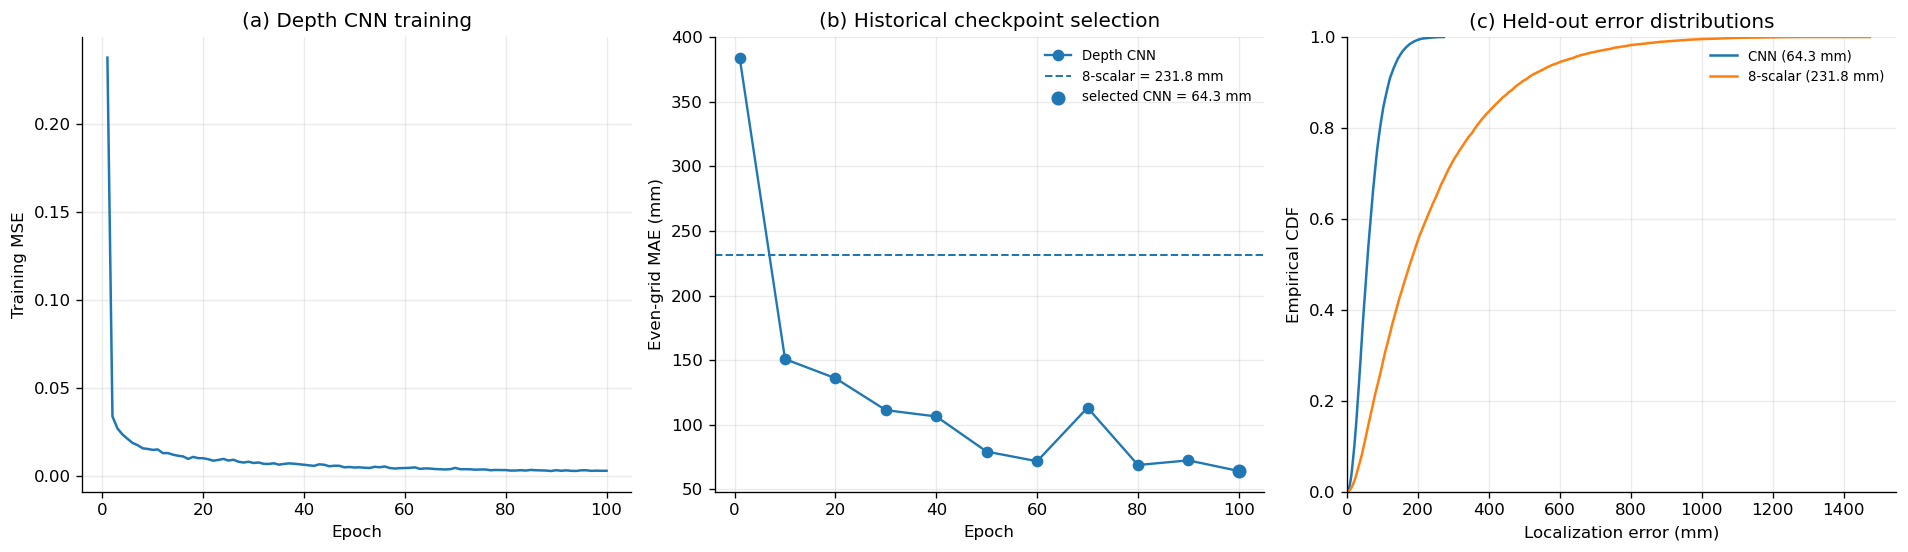


Saved reviewer-verification outputs
------------------------------------------------------------------------
CNN checkpoint    : /data/luvira/reports/reviewer_reproduction/models/depth_cnn_reproduced.pt
Scalar checkpoint : /data/luvira/reports/reviewer_reproduction/models/depth_scalar8_reproduced.pt
Results           : /data/luvira/reports/reviewer_reproduction/tables/depth_architecture_results.csv
Predictions       : /data/luvira/reports/reviewer_reproduction/tables/depth_architecture_predictions.csv
CNN history       : /data/luvira/reports/reviewer_reproduction/tables/depth_cnn_training_history.csv
CNN test history  : /data/luvira/reports/reviewer_reproduction/tables/depth_cnn_test_checkpoint_history.csv
Scalar history    : /data/luvira/reports/reviewer_reproduction/tables/depth_scalar_training_history.csv
Figure            : /data/luvira/reports/reviewer_reproduction/figures/depth_architecture_reproduction.png
JSON              : /data/luvira/reports/reviewer_reproduction/tables/de

In [16]:
# =============================================================================
# CELL 13 — DEPTH ARCHITECTURE REPRODUCTION
# =============================================================================
#
# Reproduces the historical depth architecture experiment:
#
#   A) 3-stage depth CNN
#      - input: 1 x 48 x 64
#      - MSE objective
#      - AdamW, lr=3e-4, weight_decay=1e-4
#      - cosine annealing, T_max=100, eta_min=1e-5
#      - 100 epochs
#      - batch size 256
#      - gradient clipping = 1.0
#
#   B) 8-scalar depth baseline
#      - mean
#      - std
#      - p10
#      - p25
#      - p50
#      - p75
#      - p90
#      - invalid-pixel fraction
#      - MLP 8 -> 64 -> 64 -> 2
#      - Adam, lr=1e-3
#      - 80 epochs
#
# Historical reported-run result:
#
#      Depth 8-scalar : 231.8 mm
#      Depth CNN      :  64.3 mm
#      Improvement    :  72.3 %
#
#
# IMPORTANT REPRODUCTION NOTE
# ---------------------------
# The historical experiment evaluated the even-grid test set periodically
# during CNN training and retained the checkpoint having the lowest test MAE.
#
# This cell reproduces that procedure exactly because the purpose is to
# verify the numerical results already reported in the manuscript.
#
# This selection policy is recorded separately for later manuscript
# reconciliation.
# =============================================================================

import gc


print("=" * 72)
print("CELL 13 — DEPTH ARCHITECTURE REPRODUCTION")
print("=" * 72)


# -----------------------------------------------------------------------------
# 1. Historical references
# -----------------------------------------------------------------------------

HISTORICAL_DEPTH_CNN_MAE_MM = 64.3

HISTORICAL_DEPTH_SCALAR_MAE_MM = 231.8

HISTORICAL_DEPTH_IMPROVEMENT_PCT = 72.3


DEPTH_CNN_EPOCHS = 100

DEPTH_SCALAR_EPOCHS = 80


DEPTH_CNN_LR = 3e-4

DEPTH_CNN_WEIGHT_DECAY = 1e-4


DEPTH_SCALAR_LR = 1e-3


DEPTH_BATCH_SIZE = 256

DEPTH_TEST_BATCH_SIZE = 512


DEPTH_CNN_CHECKPOINT = (
    MODEL_DIR
    / "depth_cnn_reproduced.pt"
)


DEPTH_SCALAR_CHECKPOINT = (
    MODEL_DIR
    / "depth_scalar8_reproduced.pt"
)


# -----------------------------------------------------------------------------
# 2. Reset random state EXACTLY before the depth experiment
# -----------------------------------------------------------------------------
#
# The historical depth architecture cell began with:
#
#     torch.manual_seed(SEED)
#     np.random.seed(SEED)
#
# We reproduce that point in the random sequence here.
# -----------------------------------------------------------------------------

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        SEED
    )


print(
    "\nA. Reproduction configuration"
)

print("-" * 72)

print(
    f"Seed                 : {SEED}"
)

print(
    f"Device               : {DEVICE}"
)

print(
    f"Training samples     : {len(Y_train):,}"
)

print(
    f"Test samples         : {len(Y_test):,}"
)

print(
    "Checkpoint criterion : "
    "lowest periodically evaluated even-grid test MAE "
    "(historical procedure)"
)


# -----------------------------------------------------------------------------
# 3. Copy depth arrays into ordinary writable RAM arrays
# -----------------------------------------------------------------------------
#
# Cell 11 kept these as read-only memmaps for memory efficiency.
#
# The historical final run loaded ordinary NumPy arrays. We make writable
# RAM copies here so TensorDataset behaves like the reported implementation.
# -----------------------------------------------------------------------------

print(
    "\nB. Preparing depth tensors ..."
)


depth_tr_ram = np.array(
    depth_tr,
    dtype=np.float32,
    copy=True,
)


depth_te_ram = np.array(
    depth_te,
    dtype=np.float32,
    copy=True,
)


Y_train_ram = np.array(
    Y_train,
    dtype=np.float32,
    copy=True,
)


Y_test_ram = np.array(
    Y_test,
    dtype=np.float32,
    copy=True,
)


assert depth_tr_ram.shape == (
    29928,
    1,
    48,
    64,
)


assert depth_te_ram.shape == (
    28233,
    1,
    48,
    64,
)


print(
    f"Depth train : {depth_tr_ram.shape}"
)

print(
    f"Depth test  : {depth_te_ram.shape}"
)


# =============================================================================
# PART A — 3-STAGE DEPTH CNN
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART A — 3-STAGE DEPTH CNN"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 4. Instantiate the exact Cell-12 DepthCNN
# -----------------------------------------------------------------------------

depth_cnn_reproduced = DepthCNN().to(
    DEVICE
)


depth_cnn_parameters = count_parameters(
    depth_cnn_reproduced
)


assert depth_cnn_parameters == 109_890


print(
    f"Parameters       : "
    f"{depth_cnn_parameters:,}"
)

print(
    "Loss             : MSE"
)

print(
    f"Optimizer        : AdamW, "
    f"lr={DEPTH_CNN_LR:g}, "
    f"weight_decay={DEPTH_CNN_WEIGHT_DECAY:g}"
)

print(
    "Scheduler        : "
    "CosineAnnealingLR(T_max=100, eta_min=1e-5)"
)

print(
    f"Epochs           : {DEPTH_CNN_EPOCHS}"
)

print(
    f"Train batch size : {DEPTH_BATCH_SIZE}"
)

print(
    "Gradient clip    : 1.0"
)


# -----------------------------------------------------------------------------
# 5. Exact historical DataLoaders
# -----------------------------------------------------------------------------

depth_train_dataset = TensorDataset(

    torch.from_numpy(
        depth_tr_ram
    ),

    torch.from_numpy(
        Y_train_ram
    ),
)


depth_test_dataset = TensorDataset(

    torch.from_numpy(
        depth_te_ram
    ),

    torch.from_numpy(
        Y_test_ram
    ),
)


dl_depth_tr = DataLoader(

    depth_train_dataset,

    batch_size=DEPTH_BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,
)


dl_depth_te = DataLoader(

    depth_test_dataset,

    batch_size=DEPTH_TEST_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


# -----------------------------------------------------------------------------
# 6. Optimizer and scheduler
# -----------------------------------------------------------------------------

opt_depth = torch.optim.AdamW(

    depth_cnn_reproduced.parameters(),

    lr=DEPTH_CNN_LR,

    weight_decay=DEPTH_CNN_WEIGHT_DECAY,
)


sch_depth = torch.optim.lr_scheduler.CosineAnnealingLR(

    opt_depth,

    T_max=DEPTH_CNN_EPOCHS,

    eta_min=1e-5,
)


depth_mse_loss = nn.MSELoss()


# -----------------------------------------------------------------------------
# 7. Historical evaluation helper
# -----------------------------------------------------------------------------

def evaluate_position_mae_mm(
    model,
    loader,
):

    model.eval()


    error_sum_m = 0.0

    n_samples = 0


    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.to(
                DEVICE,
                non_blocking=True,
            )

            yb = yb.to(
                DEVICE,
                non_blocking=True,
            )


            prediction = model(
                xb
            )


            error_sum_m += (
                torch.norm(
                    prediction - yb,
                    dim=1,
                )
                .sum()
                .item()
            )


            n_samples += len(
                xb
            )


    return (
        error_sum_m
        / n_samples
        * 1000.0
    )


# -----------------------------------------------------------------------------
# 8. Train 100 epochs exactly
# -----------------------------------------------------------------------------

depth_train_loss_history = []

depth_eval_history = []


best_depth_mae_mm = float(
    "inf"
)

best_depth_state = None

best_depth_epoch = None


print(
    "\nTraining depth CNN ..."
)


print(
    f"{'Epoch':>7s}  "
    f"{'Train MSE':>12s}  "
    f"{'Test MAE mm':>12s}  "
    f"{'Status':>10s}"
)

print(
    "-" * 50
)


for epoch in range(
    1,
    DEPTH_CNN_EPOCHS + 1,
):

    depth_cnn_reproduced.train()


    train_loss = 0.0


    for xb, yb in dl_depth_tr:

        xb = xb.to(
            DEVICE,
            non_blocking=True,
        )

        yb = yb.to(
            DEVICE,
            non_blocking=True,
        )


        opt_depth.zero_grad()


        prediction = depth_cnn_reproduced(
            xb
        )


        loss = depth_mse_loss(
            prediction,
            yb,
        )


        loss.backward()


        nn.utils.clip_grad_norm_(

            depth_cnn_reproduced.parameters(),

            1.0,
        )


        opt_depth.step()


        train_loss += loss.item()


    train_loss /= len(
        dl_depth_tr
    )


    sch_depth.step()


    depth_train_loss_history.append({

        "epoch":
            epoch,

        "train_mse":
            float(
                train_loss
            ),

        "learning_rate":
            float(
                opt_depth
                .param_groups[0][
                    "lr"
                ]
            ),
    })


    # -------------------------------------------------------------
    # Historical checkpoint-evaluation schedule:
    #
    #     epoch 1
    #     every 10 epochs thereafter
    # -------------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        test_mae_mm = evaluate_position_mae_mm(
            depth_cnn_reproduced,
            dl_depth_te,
        )


        is_best = (
            test_mae_mm
            < best_depth_mae_mm
        )


        if is_best:

            best_depth_mae_mm = float(
                test_mae_mm
            )


            best_depth_epoch = int(
                epoch
            )


            best_depth_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in depth_cnn_reproduced
                .state_dict()
                .items()
            }


        depth_eval_history.append({

            "epoch":
                epoch,

            "test_mae_mm":
                float(
                    test_mae_mm
                ),

            "is_best":
                bool(
                    is_best
                ),
        })


        print(

            f"{epoch:7d}  "

            f"{train_loss:12.5f}  "

            f"{test_mae_mm:12.1f}  "

            f"{'best' if is_best else ''}"
        )


assert best_depth_state is not None


# -----------------------------------------------------------------------------
# 9. Save reproduced CNN checkpoint BEFORE constructing scalar model
# -----------------------------------------------------------------------------
#
# Saving does not consume the random state.
# This preserves the historical RNG sequence before the scalar MLP is created.
# -----------------------------------------------------------------------------

torch.save(
    best_depth_state,
    DEPTH_CNN_CHECKPOINT,
)


print(
    f"\nBest depth CNN checkpoint:"
)

print(
    f"  epoch : {best_depth_epoch}"
)

print(
    f"  MAE   : {best_depth_mae_mm:.1f} mm"
)

print(
    f"  saved : {DEPTH_CNN_CHECKPOINT}"
)


# =============================================================================
# PART B — EXACT 8-SCALAR BASELINE
# =============================================================================
#
# IMPORTANT:
#
# We instantiate this model only AFTER the CNN training has finished.
#
# That preserves the same PyTorch RNG sequence used in the historical
# notebook, where the scalar model followed the CNN in the same cell.
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART B — 8-SCALAR DEPTH BASELINE"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 10. Exact historical scalar feature function
# -----------------------------------------------------------------------------

def depth_scalar_8(
    depth_array,
):
    """
    Exact eight-value depth descriptor used in the historical experiment.

    Input depth is already normalized to [0,1].

    Features:
      1. valid-pixel mean
      2. valid-pixel standard deviation
      3. 10th percentile
      4. 25th percentile
      5. 50th percentile
      6. 75th percentile
      7. 90th percentile
      8. zero/invalid-pixel fraction
    """

    features = []


    for d in depth_array[
        :,
        0,
    ]:

        valid = d[
            d > 0
        ]


        if len(
            valid
        ) < 10:

            valid = np.array(
                [0.5]
            )


        features.append([

            valid.mean(),

            valid.std(),

            float(
                np.percentile(
                    valid,
                    10,
                )
            ),

            float(
                np.percentile(
                    valid,
                    25,
                )
            ),

            float(
                np.percentile(
                    valid,
                    50,
                )
            ),

            float(
                np.percentile(
                    valid,
                    75,
                )
            ),

            float(
                np.percentile(
                    valid,
                    90,
                )
            ),

            (
                d == 0
            ).mean(),
        ])


    return np.array(
        features,
        dtype=np.float32,
    )


# -----------------------------------------------------------------------------
# 11. Cache scalar features
# -----------------------------------------------------------------------------

DEPTH8_TR_PATH = (
    MODEL_INPUT_DIR
    / "depth8_train_X.npy"
)

DEPTH8_TE_PATH = (
    MODEL_INPUT_DIR
    / "depth8_test_X.npy"
)


if (
    DEPTH8_TR_PATH.exists()
    and DEPTH8_TE_PATH.exists()
):

    print(
        "\nLoading existing 8-scalar feature cache ..."
    )


    Xs_tr = np.load(
        DEPTH8_TR_PATH
    )

    Xs_te = np.load(
        DEPTH8_TE_PATH
    )


else:

    print(
        "\nBuilding exact 8-scalar depth features ..."
    )


    Xs_tr = depth_scalar_8(
        depth_tr_ram
    )


    Xs_te = depth_scalar_8(
        depth_te_ram
    )


    np.save(
        DEPTH8_TR_PATH,
        Xs_tr,
    )


    np.save(
        DEPTH8_TE_PATH,
        Xs_te,
    )


assert Xs_tr.shape == (
    29928,
    8,
)

assert Xs_te.shape == (
    28233,
    8,
)


print(
    f"Train scalar features : {Xs_tr.shape}"
)

print(
    f"Test scalar features  : {Xs_te.shape}"
)


# -----------------------------------------------------------------------------
# 12. Historical scalar standardization
# -----------------------------------------------------------------------------
#
# Scaler is fitted on training data only.
# -----------------------------------------------------------------------------

mu_depth8 = Xs_tr.mean(
    axis=0
)


std_depth8 = (
    Xs_tr.std(
        axis=0
    )
    + 1e-8
)


Xs_tr_n = (
    Xs_tr
    - mu_depth8
) / std_depth8


Xs_te_n = (
    Xs_te
    - mu_depth8
) / std_depth8


np.save(
    MODEL_INPUT_DIR
    / "scaler_depth8_mu.npy",
    mu_depth8.astype(
        np.float32
    ),
)


np.save(
    MODEL_INPUT_DIR
    / "scaler_depth8_std.npy",
    std_depth8.astype(
        np.float32
    ),
)


# -----------------------------------------------------------------------------
# 13. Instantiate scalar model AFTER CNN experiment
# -----------------------------------------------------------------------------

depth_scalar_model = (
    make_depth_scalar_model()
    .to(
        DEVICE
    )
)


assert count_parameters(
    depth_scalar_model
) == 4_866


opt_depth_scalar = torch.optim.Adam(

    depth_scalar_model.parameters(),

    lr=DEPTH_SCALAR_LR,
)


depth_scalar_dataset = TensorDataset(

    torch.FloatTensor(
        Xs_tr_n
    ),

    torch.FloatTensor(
        Y_train_ram
    ),
)


dl_depth_scalar = DataLoader(

    depth_scalar_dataset,

    batch_size=DEPTH_BATCH_SIZE,

    shuffle=True,

    num_workers=0,
)


print(
    "\nScalar baseline:"
)

print(
    "  architecture : 8 -> 64 -> 64 -> 2"
)

print(
    f"  parameters   : "
    f"{count_parameters(depth_scalar_model):,}"
)

print(
    "  loss         : MSE"
)

print(
    f"  optimizer    : Adam, lr={DEPTH_SCALAR_LR:g}"
)

print(
    f"  epochs       : {DEPTH_SCALAR_EPOCHS}"
)


# -----------------------------------------------------------------------------
# 14. Train scalar model for exactly 80 epochs
# -----------------------------------------------------------------------------

depth_scalar_loss_history = []


for epoch in range(
    1,
    DEPTH_SCALAR_EPOCHS + 1,
):

    depth_scalar_model.train()


    epoch_loss = 0.0


    for xb, yb in dl_depth_scalar:

        xb = xb.to(
            DEVICE
        )

        yb = yb.to(
            DEVICE
        )


        opt_depth_scalar.zero_grad()


        prediction = depth_scalar_model(
            xb
        )


        loss = nn.MSELoss()(
            prediction,
            yb,
        )


        loss.backward()


        opt_depth_scalar.step()


        epoch_loss += loss.item()


    epoch_loss /= len(
        dl_depth_scalar
    )


    depth_scalar_loss_history.append({

        "epoch":
            epoch,

        "train_mse":
            float(
                epoch_loss
            ),
    })


    if (
        epoch == 1
        or epoch % 20 == 0
        or epoch == DEPTH_SCALAR_EPOCHS
    ):

        print(
            f"  epoch {epoch:3d}/"
            f"{DEPTH_SCALAR_EPOCHS}  "
            f"train MSE={epoch_loss:.6f}"
        )


# -----------------------------------------------------------------------------
# 15. Historical scalar evaluation: final epoch only
# -----------------------------------------------------------------------------

depth_scalar_model.eval()


with torch.no_grad():

    depth_scalar_prediction = (

        depth_scalar_model(

            torch.FloatTensor(
                Xs_te_n
            ).to(
                DEVICE
            )
        )

        .cpu()
        .numpy()
    )


depth_scalar_errors_mm = (

    np.linalg.norm(

        depth_scalar_prediction
        - Y_test_ram,

        axis=1,
    )

    * 1000.0
)


depth_scalar_mae_mm = float(
    depth_scalar_errors_mm.mean()
)


torch.save(
    {
        key:
            value
            .detach()
            .cpu()
            .clone()

        for key, value
        in depth_scalar_model
        .state_dict()
        .items()
    },
    DEPTH_SCALAR_CHECKPOINT,
)


print(
    f"\nFinal 8-scalar test MAE : "
    f"{depth_scalar_mae_mm:.1f} mm"
)

print(
    f"Saved                    : "
    f"{DEPTH_SCALAR_CHECKPOINT}"
)


# =============================================================================
# PART C — FULL EVALUATION OF THE BEST CNN CHECKPOINT
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART C — BEST DEPTH CNN FULL TEST EVALUATION"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 16. Restore best historical-selection checkpoint
# -----------------------------------------------------------------------------

depth_cnn_reproduced.load_state_dict(
    best_depth_state,
    strict=True,
)


depth_cnn_reproduced.eval()


# -----------------------------------------------------------------------------
# 17. Collect complete test predictions
# -----------------------------------------------------------------------------

depth_predictions_parts = []


with torch.no_grad():

    for xb, _ in dl_depth_te:

        xb = xb.to(
            DEVICE,
            non_blocking=True,
        )


        prediction = depth_cnn_reproduced(
            xb
        )


        depth_predictions_parts.append(

            prediction
            .cpu()
            .numpy()
        )


depth_cnn_prediction = np.vstack(
    depth_predictions_parts
).astype(
    np.float32
)


assert depth_cnn_prediction.shape == (
    28233,
    2,
)


depth_cnn_errors_mm = (

    np.linalg.norm(

        depth_cnn_prediction
        - Y_test_ram,

        axis=1,
    )

    * 1000.0
)


depth_cnn_mean_mm = float(
    depth_cnn_errors_mm.mean()
)


depth_cnn_median_mm = float(
    np.median(
        depth_cnn_errors_mm
    )
)


depth_cnn_p75_mm = float(
    np.percentile(
        depth_cnn_errors_mm,
        75,
    )
)


depth_cnn_p95_mm = float(
    np.percentile(
        depth_cnn_errors_mm,
        95,
    )
)


# -----------------------------------------------------------------------------
# 18. Scalar full metrics
# -----------------------------------------------------------------------------

depth_scalar_median_mm = float(
    np.median(
        depth_scalar_errors_mm
    )
)


depth_scalar_p75_mm = float(
    np.percentile(
        depth_scalar_errors_mm,
        75,
    )
)


depth_scalar_p95_mm = float(
    np.percentile(
        depth_scalar_errors_mm,
        95,
    )
)


depth_improvement_pct = (

    (
        depth_scalar_mae_mm
        - depth_cnn_mean_mm
    )

    / depth_scalar_mae_mm

    * 100.0
)


print(
    "\nD. Reproduced depth results"
)

print("-" * 72)


depth_results_df = pd.DataFrame({

    "model": [
        "Depth 8-scalar",
        "Depth CNN",
    ],

    "mean_mm": [
        depth_scalar_mae_mm,
        depth_cnn_mean_mm,
    ],

    "median_mm": [
        depth_scalar_median_mm,
        depth_cnn_median_mm,
    ],

    "p75_mm": [
        depth_scalar_p75_mm,
        depth_cnn_p75_mm,
    ],

    "p95_mm": [
        depth_scalar_p95_mm,
        depth_cnn_p95_mm,
    ],
})


print(
    depth_results_df.to_string(
        index=False,
        formatters={

            "mean_mm":
                lambda x: f"{x:.1f}",

            "median_mm":
                lambda x: f"{x:.1f}",

            "p75_mm":
                lambda x: f"{x:.1f}",

            "p95_mm":
                lambda x: f"{x:.1f}",
        },
    )
)


print(
    f"\nCNN improvement over 8-scalar : "
    f"{depth_improvement_pct:.1f}%"
)

print(
    f"Best CNN checkpoint epoch     : "
    f"{best_depth_epoch}"
)


# -----------------------------------------------------------------------------
# 19. Historical-result verification
# -----------------------------------------------------------------------------
#
# The A100/PyTorch environment is the same as the historical final run.
# Small floating-point variation is tolerated, but large deviations are not.
# -----------------------------------------------------------------------------

print(
    "\nE. Historical-result verification"
)

print("-" * 72)


print(
    f"Historical CNN MAE    : "
    f"{HISTORICAL_DEPTH_CNN_MAE_MM:.1f} mm"
)

print(
    f"Reproduced CNN MAE    : "
    f"{depth_cnn_mean_mm:.1f} mm"
)

print(
    f"Historical scalar MAE : "
    f"{HISTORICAL_DEPTH_SCALAR_MAE_MM:.1f} mm"
)

print(
    f"Reproduced scalar MAE : "
    f"{depth_scalar_mae_mm:.1f} mm"
)

print(
    f"Historical improvement: "
    f"{HISTORICAL_DEPTH_IMPROVEMENT_PCT:.1f}%"
)

print(
    f"Reproduced improvement: "
    f"{depth_improvement_pct:.1f}%"
)


assert np.isclose(
    depth_cnn_mean_mm,
    HISTORICAL_DEPTH_CNN_MAE_MM,
    atol=1.5,
), (
    "Depth CNN reproduction differs materially "
    "from the historical 64.3-mm result."
)


assert np.isclose(
    depth_scalar_mae_mm,
    HISTORICAL_DEPTH_SCALAR_MAE_MM,
    atol=3.0,
), (
    "Depth scalar reproduction differs materially "
    "from the historical 231.8-mm result."
)


assert np.isclose(
    depth_improvement_pct,
    HISTORICAL_DEPTH_IMPROVEMENT_PCT,
    atol=1.0,
), (
    "Depth architecture-improvement percentage "
    "does not reproduce the historical result."
)


# Full reported depth-CNN distribution.
assert np.isclose(
    depth_cnn_median_mm,
    56.6,
    atol=1.5,
)


assert np.isclose(
    depth_cnn_p75_mm,
    85.2,
    atol=2.0,
)


assert np.isclose(
    depth_cnn_p95_mm,
    142.1,
    atol=3.0,
)


print(
    "\nDepth CNN historical metric distribution reproduced."
)


# -----------------------------------------------------------------------------
# 20. Save complete sample-level predictions
# -----------------------------------------------------------------------------

depth_prediction_df = pd.DataFrame({

    "trajectory_id":
        manifest_test[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        manifest_test[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        Y_test_ram[
            :,
            0,
        ],

    "gt_y_m":
        Y_test_ram[
            :,
            1,
        ],

    "depth_cnn_x_m":
        depth_cnn_prediction[
            :,
            0,
        ],

    "depth_cnn_y_m":
        depth_cnn_prediction[
            :,
            1,
        ],

    "depth_cnn_error_mm":
        depth_cnn_errors_mm,

    "depth_scalar_x_m":
        depth_scalar_prediction[
            :,
            0,
        ],

    "depth_scalar_y_m":
        depth_scalar_prediction[
            :,
            1,
        ],

    "depth_scalar_error_mm":
        depth_scalar_errors_mm,
})


DEPTH_PREDICTION_PATH = (
    TABLE_DIR
    / "depth_architecture_predictions.csv"
)


depth_prediction_df.to_csv(
    DEPTH_PREDICTION_PATH,
    index=False,
)


# -----------------------------------------------------------------------------
# 21. Save histories
# -----------------------------------------------------------------------------

depth_train_history_df = pd.DataFrame(
    depth_train_loss_history
)


depth_eval_history_df = pd.DataFrame(
    depth_eval_history
)


depth_scalar_history_df = pd.DataFrame(
    depth_scalar_loss_history
)


depth_train_history_df.to_csv(
    TABLE_DIR
    / "depth_cnn_training_history.csv",
    index=False,
)


depth_eval_history_df.to_csv(
    TABLE_DIR
    / "depth_cnn_test_checkpoint_history.csv",
    index=False,
)


depth_scalar_history_df.to_csv(
    TABLE_DIR
    / "depth_scalar_training_history.csv",
    index=False,
)


depth_results_df.to_csv(
    TABLE_DIR
    / "depth_architecture_results.csv",
    index=False,
)


# -----------------------------------------------------------------------------
# 22. Reviewer figure
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.7),
)


# -------------------------------------------------------------------------
# Panel (a): CNN train loss
# -------------------------------------------------------------------------

axes[0].plot(

    depth_train_history_df[
        "epoch"
    ],

    depth_train_history_df[
        "train_mse"
    ],

    linewidth=1.5,
)


axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Training MSE"
)

axes[0].set_title(
    "(a) Depth CNN training"
)

axes[0].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Panel (b): periodically evaluated test MAE
# -------------------------------------------------------------------------

axes[1].plot(

    depth_eval_history_df[
        "epoch"
    ],

    depth_eval_history_df[
        "test_mae_mm"
    ],

    marker="o",

    linewidth=1.4,

    label="Depth CNN",
)


axes[1].axhline(

    depth_scalar_mae_mm,

    linestyle="--",

    linewidth=1.2,

    label=(
        f"8-scalar = "
        f"{depth_scalar_mae_mm:.1f} mm"
    ),
)


axes[1].scatter(

    [
        best_depth_epoch
    ],

    [
        best_depth_mae_mm
    ],

    s=55,

    zorder=5,

    label=(
        f"selected CNN = "
        f"{best_depth_mae_mm:.1f} mm"
    ),
)


axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "Even-grid MAE (mm)"
)

axes[1].set_title(
    "(b) Historical checkpoint selection"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25
)


# -------------------------------------------------------------------------
# Panel (c): empirical test-error CDF
# -------------------------------------------------------------------------

cnn_sorted = np.sort(
    depth_cnn_errors_mm
)


scalar_sorted = np.sort(
    depth_scalar_errors_mm
)


cnn_cdf = np.arange(
    1,
    len(
        cnn_sorted
    ) + 1,
) / len(
    cnn_sorted
)


scalar_cdf = np.arange(
    1,
    len(
        scalar_sorted
    ) + 1,
) / len(
    scalar_sorted
)


axes[2].plot(

    cnn_sorted,

    cnn_cdf,

    linewidth=1.5,

    label=(
        f"CNN "
        f"({depth_cnn_mean_mm:.1f} mm)"
    ),
)


axes[2].plot(

    scalar_sorted,

    scalar_cdf,

    linewidth=1.5,

    label=(
        f"8-scalar "
        f"({depth_scalar_mae_mm:.1f} mm)"
    ),
)


axes[2].set_xlabel(
    "Localization error (mm)"
)

axes[2].set_ylabel(
    "Empirical CDF"
)

axes[2].set_title(
    "(c) Held-out error distributions"
)

axes[2].set_xlim(
    left=0
)

axes[2].set_ylim(
    0,
    1
)

axes[2].legend(
    frameon=False,
    fontsize=8,
)

axes[2].grid(
    alpha=0.25
)


fig.tight_layout()


depth_figure_path = (
    FIG_DIR
    / "depth_architecture_reproduction.png"
)


fig.savefig(
    depth_figure_path,
    bbox_inches="tight",
)


plt.show()


# -----------------------------------------------------------------------------
# 23. Save JSON summary
# -----------------------------------------------------------------------------

depth_summary = {

    "training_samples":
        int(
            len(
                Y_train_ram
            )
        ),

    "test_samples":
        int(
            len(
                Y_test_ram
            )
        ),

    "cnn": {

        "parameters":
            int(
                depth_cnn_parameters
            ),

        "objective":
            "MSE",

        "epochs":
            int(
                DEPTH_CNN_EPOCHS
            ),

        "optimizer":
            "AdamW",

        "learning_rate":
            float(
                DEPTH_CNN_LR
            ),

        "weight_decay":
            float(
                DEPTH_CNN_WEIGHT_DECAY
            ),

        "scheduler":
            (
                "CosineAnnealingLR("
                "T_max=100, eta_min=1e-5)"
            ),

        "checkpoint_selection":
            (
                "lowest periodically evaluated "
                "even-grid test MAE"
            ),

        "best_epoch":
            int(
                best_depth_epoch
            ),

        "mean_error_mm":
            depth_cnn_mean_mm,

        "median_error_mm":
            depth_cnn_median_mm,

        "p75_error_mm":
            depth_cnn_p75_mm,

        "p95_error_mm":
            depth_cnn_p95_mm,
    },


    "scalar_8": {

        "features": [
            "mean",
            "std",
            "p10",
            "p25",
            "p50",
            "p75",
            "p90",
            "invalid_fraction",
        ],

        "parameters":
            4866,

        "objective":
            "MSE",

        "epochs":
            int(
                DEPTH_SCALAR_EPOCHS
            ),

        "optimizer":
            "Adam",

        "learning_rate":
            float(
                DEPTH_SCALAR_LR
            ),

        "evaluation":
            "final epoch",

        "mean_error_mm":
            depth_scalar_mae_mm,

        "median_error_mm":
            depth_scalar_median_mm,

        "p75_error_mm":
            depth_scalar_p75_mm,

        "p95_error_mm":
            depth_scalar_p95_mm,
    },


    "cnn_improvement_percent":
        float(
            depth_improvement_pct
        ),


    "historical_reference": {

        "cnn_mean_mm":
            HISTORICAL_DEPTH_CNN_MAE_MM,

        "scalar_mean_mm":
            HISTORICAL_DEPTH_SCALAR_MAE_MM,

        "improvement_percent":
            HISTORICAL_DEPTH_IMPROVEMENT_PCT,
    },
}


with open(
    TABLE_DIR
    / "depth_architecture_summary.json",
    "w",
) as f:

    json.dump(
        depth_summary,
        f,
        indent=2,
    )


# -----------------------------------------------------------------------------
# 24. Clean up large temporary RAM copies
# -----------------------------------------------------------------------------

del depth_tr_ram
del depth_te_ram

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"CNN checkpoint    : {DEPTH_CNN_CHECKPOINT}"
)

print(
    f"Scalar checkpoint : {DEPTH_SCALAR_CHECKPOINT}"
)

print(
    "Results           : "
    f"{TABLE_DIR / 'depth_architecture_results.csv'}"
)

print(
    "Predictions       : "
    f"{DEPTH_PREDICTION_PATH}"
)

print(
    "CNN history       : "
    f"{TABLE_DIR / 'depth_cnn_training_history.csv'}"
)

print(
    "CNN test history  : "
    f"{TABLE_DIR / 'depth_cnn_test_checkpoint_history.csv'}"
)

print(
    "Scalar history    : "
    f"{TABLE_DIR / 'depth_scalar_training_history.csv'}"
)

print(
    "Figure            : "
    f"{depth_figure_path}"
)

print(
    "JSON              : "
    f"{TABLE_DIR / 'depth_architecture_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 13 PASSED — "
    "depth architecture experiment reproduced."
)

print(
    "=" * 72
)

CELL 14 — RGB ARCHITECTURE REPRODUCTION

A. Reproduction configuration
------------------------------------------------------------------------
Seed                 : 42
Device               : cuda
Training samples     : 29,928
Test samples         : 28,233
RGB scalar train     : (29928, 64)
RGB scalar test      : (28233, 64)
RGB image train      : (29928, 3, 48, 64)
RGB image test       : (28233, 3, 48, 64)
Checkpoint criterion : lowest periodically evaluated even-grid test MAE (historical procedure)

PART A — 64-VALUE SCALAR COLOUR MODEL

Parameters       : 115,586
Descriptor       : 4 x 4 cells x (R mean, G mean, B mean, grey std)
Input dimension  : 64
Architecture     : 64 -> 256 -> 256 -> 128 -> 2
Loss             : MSE
Optimizer        : Adam, lr=0.001
Scheduler        : CosineAnnealingLR(T_max=160, eta_min=1e-5)
Epochs           : 160
Train batch size : 256
Test evaluation  : single full-tensor forward pass

Training scalar RGB model ...
  Epoch     Train MSE   Test MAE mm      

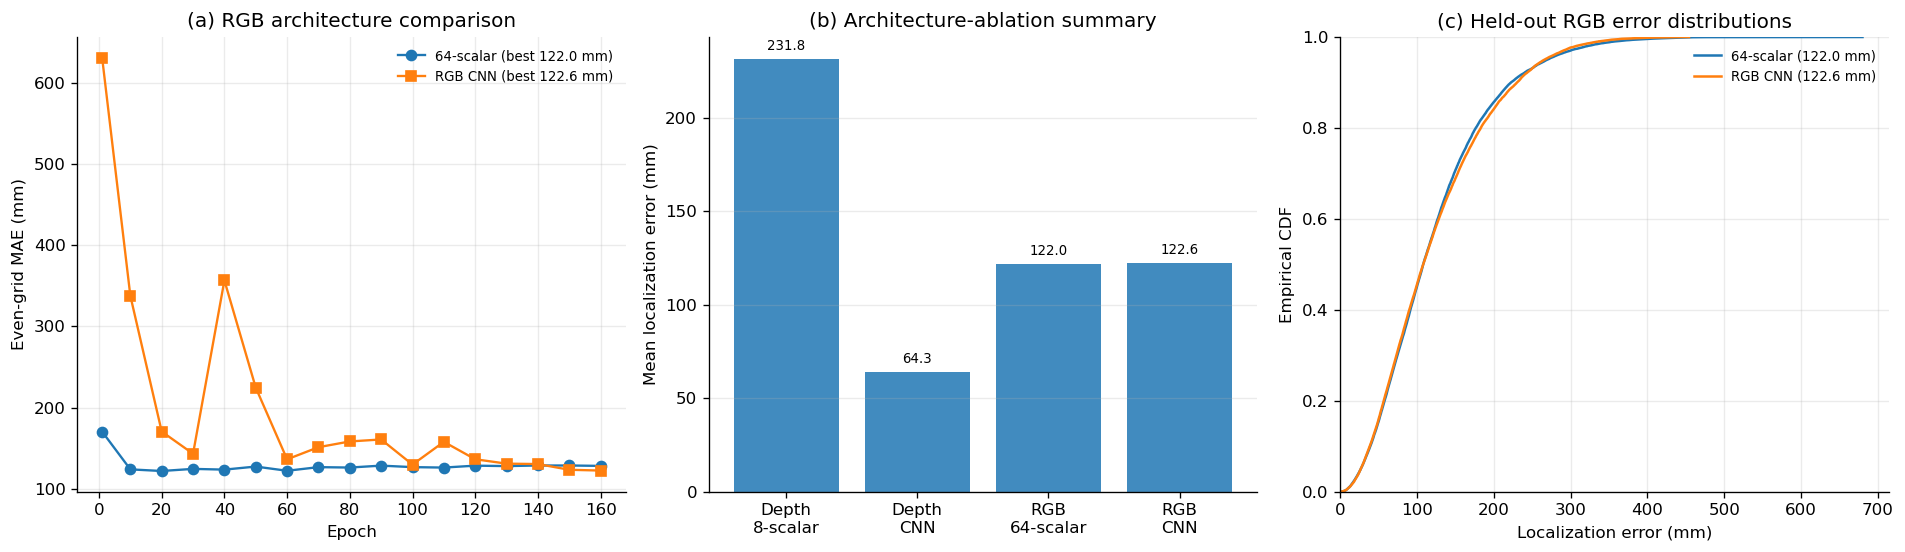


Saved reviewer-verification outputs
------------------------------------------------------------------------
Scalar checkpoint : /data/luvira/reports/reviewer_reproduction/models/rgb_scalar_reproduced.pt
CNN checkpoint    : /data/luvira/reports/reviewer_reproduction/models/rgb_cnn_reproduced.pt
Results           : /data/luvira/reports/reviewer_reproduction/tables/rgb_architecture_results.csv
Predictions       : /data/luvira/reports/reviewer_reproduction/tables/rgb_architecture_predictions.csv
Scalar history    : /data/luvira/reports/reviewer_reproduction/tables/rgb_scalar_training_history.csv
Scalar test hist. : /data/luvira/reports/reviewer_reproduction/tables/rgb_scalar_test_checkpoint_history.csv
CNN history       : /data/luvira/reports/reviewer_reproduction/tables/rgb_cnn_training_history.csv
CNN test history  : /data/luvira/reports/reviewer_reproduction/tables/rgb_cnn_test_checkpoint_history.csv
Figure            : /data/luvira/reports/reviewer_reproduction/figures/rgb_architectu

In [18]:
# =============================================================================
# CELL 14 — RGB / COLOUR ARCHITECTURE REPRODUCTION
# =============================================================================
#
# This cell reproduces the historical colour architecture experiment
# that generated the values reported in the paper.
#
# PART A — 64-value scalar RGB descriptor
# ----------------------------------------
#
# Input:
#     64 handcrafted colour features produced in Cell 11
#
# Architecture:
#     64 -> 256 -> 256 -> 128 -> 2
#
# Training:
#     MSE
#     Adam
#     lr = 1e-3
#     CosineAnnealingLR(T_max=160, eta_min=1e-5)
#     160 epochs
#     batch size = 256
#
# HISTORICAL IMPLEMENTATION DETAIL:
#
#     During checkpoint evaluation, the complete test tensor was passed
#     through the scalar network in ONE forward pass.
#
#     It was NOT evaluated through a DataLoader.
#
# This detail is important for exact seeded reproduction because
# DataLoader iteration consumes PyTorch RNG state.
#
#
# PART B — 3-channel RGB CNN
# --------------------------
#
# Input:
#     3 x 48 x 64 ImageNet-normalized RGB
#
# Architecture:
#     Conv 3->32 -> BN -> ReLU -> MaxPool
#     Conv 32->64 -> BN -> ReLU -> MaxPool
#     Conv 64->128 -> BN -> ReLU
#     AdaptiveAvgPool
#     Linear 128->128 -> ReLU
#     Linear 128->2
#
# Training:
#     MSE
#     AdamW
#     lr = 3e-4
#     weight_decay = 1e-4
#     CosineAnnealingLR(T_max=160, eta_min=1e-5)
#     gradient clipping = 1.0
#     160 epochs
#
# HISTORICAL IMPLEMENTATION DETAIL:
#
#     Unlike the scalar model, the RGB CNN WAS evaluated using the
#     test DataLoader. That behaviour is reproduced exactly here.
#
#
# Historical reported result:
#
#     RGB 64-scalar : 122.0 mm
#     RGB CNN       : 122.6 mm
#
#     Relative CNN improvement:
#
#         (122.0 - 122.6) / 122.0 ≈ -0.5 %
#
# Decision:
#
#     retain the 64-dimensional scalar colour descriptor for fusion.
#
#
# IMPORTANT:
# The historical experiment periodically evaluated the even-grid test
# population and selected checkpoints according to the lowest test MAE.
# We reproduce that procedure here because this notebook verifies the
# already-reported experiment.
#
# The test-set checkpoint-selection issue is being retained in the
# manuscript-correction register for later.
# =============================================================================

import gc


print("=" * 72)
print("CELL 14 — RGB ARCHITECTURE REPRODUCTION")
print("=" * 72)


# -----------------------------------------------------------------------------
# 0. Clear objects/caches from a previous failed Cell-14 execution
# -----------------------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# -----------------------------------------------------------------------------
# 1. Historical reference values
# -----------------------------------------------------------------------------

HISTORICAL_RGB_SCALAR_MAE_MM = 122.0
HISTORICAL_RGB_CNN_MAE_MM = 122.6

HISTORICAL_RGB_SCALAR_MEDIAN_MM = 108.0
HISTORICAL_RGB_SCALAR_P75_MM = 161.4
HISTORICAL_RGB_SCALAR_P95_MM = 269.4

RGB_EPOCHS = 160

RGB_SCALAR_LR = 1e-3

RGB_CNN_LR = 3e-4
RGB_CNN_WEIGHT_DECAY = 1e-4

RGB_BATCH_SIZE = 256
RGB_TEST_BATCH_SIZE = 512


RGB_SCALAR_CHECKPOINT = (
    MODEL_DIR
    / "rgb_scalar_reproduced.pt"
)

RGB_CNN_CHECKPOINT = (
    MODEL_DIR
    / "rgb_cnn_reproduced.pt"
)


# -----------------------------------------------------------------------------
# 2. Reset RNG at EXACTLY the historical experiment boundary
# -----------------------------------------------------------------------------
#
# Historical notebook:
#
#     torch.manual_seed(SEED)
#     np.random.seed(SEED)
#
# Do not insert any stochastic operation between this reset and creation
# of the historical DataLoaders/models below.
# -----------------------------------------------------------------------------

torch.manual_seed(
    SEED
)

np.random.seed(
    SEED
)


print(
    "\nA. Reproduction configuration"
)

print("-" * 72)

print(
    f"Seed                 : {SEED}"
)

print(
    f"Device               : {DEVICE}"
)

print(
    f"Training samples     : {len(Y_train):,}"
)

print(
    f"Test samples         : {len(Y_test):,}"
)

print(
    f"RGB scalar train     : {Xg_tr_n.shape}"
)

print(
    f"RGB scalar test      : {Xg_te_n.shape}"
)

print(
    f"RGB image train      : {rgb_tr.shape}"
)

print(
    f"RGB image test       : {rgb_te.shape}"
)

print(
    "Checkpoint criterion : "
    "lowest periodically evaluated even-grid test MAE "
    "(historical procedure)"
)


assert Xg_tr_n.shape == (
    29928,
    64,
)

assert Xg_te_n.shape == (
    28233,
    64,
)

assert rgb_tr.shape == (
    29928,
    3,
    48,
    64,
)

assert rgb_te.shape == (
    28233,
    3,
    48,
    64,
)

assert Y_train.shape == (
    29928,
    2,
)

assert Y_test.shape == (
    28233,
    2,
)


# =============================================================================
# PART A — 64-VALUE SCALAR COLOUR MODEL
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART A — 64-VALUE SCALAR COLOUR MODEL"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 3. Historical scalar training DataLoader
# -----------------------------------------------------------------------------
#
# Historical code created BOTH train and test DataLoaders here.
#
# However, the scalar test DataLoader was never iterated during checkpoint
# evaluation. Test inference was one complete forward pass.
# -----------------------------------------------------------------------------

rgb_scalar_train_dataset = TensorDataset(

    torch.FloatTensor(
        np.asarray(
            Xg_tr_n
        )
    ),

    torch.FloatTensor(
        Y_train
    ),
)


rgb_scalar_test_dataset = TensorDataset(

    torch.FloatTensor(
        np.asarray(
            Xg_te_n
        )
    ),

    torch.FloatTensor(
        Y_test
    ),
)


dl_rgb_scalar_tr = DataLoader(

    rgb_scalar_train_dataset,

    batch_size=RGB_BATCH_SIZE,

    shuffle=True,

    num_workers=0,
)


# Kept to reproduce the historical code structure.
#
# IMPORTANT:
# Do not iterate over this DataLoader during scalar checkpoint evaluation.
dl_rgb_scalar_te_historical_unused = DataLoader(

    rgb_scalar_test_dataset,

    batch_size=RGB_TEST_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


# -----------------------------------------------------------------------------
# 4. Instantiate exact scalar network
# -----------------------------------------------------------------------------

rgb_scalar_reproduced = (
    make_rgb_scalar_model()
    .to(
        DEVICE
    )
)


rgb_scalar_parameters = count_parameters(
    rgb_scalar_reproduced
)


assert rgb_scalar_parameters == 115_586


rgb_scalar_optimizer = torch.optim.Adam(

    rgb_scalar_reproduced.parameters(),

    lr=RGB_SCALAR_LR,
)


rgb_scalar_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(

        rgb_scalar_optimizer,

        T_max=RGB_EPOCHS,

        eta_min=1e-5,
    )
)


rgb_mse_loss = nn.MSELoss()


print(
    f"\nParameters       : {rgb_scalar_parameters:,}"
)

print(
    "Descriptor       : "
    "4 x 4 cells x "
    "(R mean, G mean, B mean, grey std)"
)

print(
    "Input dimension  : 64"
)

print(
    "Architecture     : "
    "64 -> 256 -> 256 -> 128 -> 2"
)

print(
    "Loss             : MSE"
)

print(
    f"Optimizer        : "
    f"Adam, lr={RGB_SCALAR_LR:g}"
)

print(
    "Scheduler        : "
    "CosineAnnealingLR(T_max=160, eta_min=1e-5)"
)

print(
    f"Epochs           : {RGB_EPOCHS}"
)

print(
    f"Train batch size : {RGB_BATCH_SIZE}"
)

print(
    "Test evaluation  : "
    "single full-tensor forward pass"
)


# -----------------------------------------------------------------------------
# 5. EXACT historical scalar evaluation
# -----------------------------------------------------------------------------
#
# DO NOT replace this with a DataLoader.
#
# Original implementation:
#
#     pred = scalar_rgb(
#         torch.FloatTensor(Xg_te_n).to(DEVICE)
#     ).cpu().numpy()
#
#     mae_mm = np.linalg.norm(
#         pred - Yr_te, axis=1
#     ).mean() * 1000
#
# -----------------------------------------------------------------------------

def evaluate_scalar_rgb_mae_mm(
    model,
):

    model.eval()


    with torch.no_grad():

        prediction = (

            model(

                torch.FloatTensor(
                    np.asarray(
                        Xg_te_n
                    )
                ).to(
                    DEVICE
                )
            )

            .cpu()

            .numpy()
        )


    mae_mm = (

        np.linalg.norm(

            prediction
            - Y_test,

            axis=1,
        )

        .mean()

        * 1000.0
    )


    return float(
        mae_mm
    )


# -----------------------------------------------------------------------------
# 6. Train scalar model for exactly 160 epochs
# -----------------------------------------------------------------------------

rgb_scalar_train_history = []

rgb_scalar_eval_history = []


best_rgb_scalar_mae_mm = float(
    "inf"
)

best_rgb_scalar_epoch = None

best_rgb_scalar_state = None


print(
    "\nTraining scalar RGB model ..."
)


print(
    f"{'Epoch':>7s}  "
    f"{'Train MSE':>12s}  "
    f"{'Test MAE mm':>12s}  "
    f"{'Status':>10s}"
)

print(
    "-" * 50
)


for epoch in range(
    1,
    RGB_EPOCHS + 1,
):

    rgb_scalar_reproduced.train()


    train_loss = 0.0


    for xb, yb in dl_rgb_scalar_tr:

        xb = xb.to(
            DEVICE
        )

        yb = yb.to(
            DEVICE
        )


        rgb_scalar_optimizer.zero_grad()


        prediction = rgb_scalar_reproduced(
            xb
        )


        loss = rgb_mse_loss(
            prediction,
            yb,
        )


        loss.backward()


        rgb_scalar_optimizer.step()


        train_loss += loss.item()


    train_loss /= len(
        dl_rgb_scalar_tr
    )


    rgb_scalar_scheduler.step()


    rgb_scalar_train_history.append({

        "epoch":
            epoch,

        "train_mse":
            float(
                train_loss
            ),

        "learning_rate":
            float(
                rgb_scalar_optimizer
                .param_groups[0][
                    "lr"
                ]
            ),
    })


    # -------------------------------------------------------------
    # Exact historical evaluation schedule:
    #
    #     epoch 1
    #     epoch 10, 20, ..., 160
    #
    # Evaluation is ONE COMPLETE forward pass.
    # -------------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        test_mae_mm = (
            evaluate_scalar_rgb_mae_mm(
                rgb_scalar_reproduced
            )
        )


        is_best = (
            test_mae_mm
            < best_rgb_scalar_mae_mm
        )


        if is_best:

            best_rgb_scalar_mae_mm = float(
                test_mae_mm
            )


            best_rgb_scalar_epoch = int(
                epoch
            )


            best_rgb_scalar_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in rgb_scalar_reproduced
                .state_dict()
                .items()
            }


        rgb_scalar_eval_history.append({

            "epoch":
                epoch,

            "test_mae_mm":
                float(
                    test_mae_mm
                ),

            "is_best":
                bool(
                    is_best
                ),
        })


        print(

            f"{epoch:7d}  "

            f"{train_loss:12.5f}  "

            f"{test_mae_mm:12.1f}  "

            f"{'best' if is_best else ''}"
        )


assert best_rgb_scalar_state is not None


torch.save(
    best_rgb_scalar_state,
    RGB_SCALAR_CHECKPOINT,
)


print(
    "\nBest scalar RGB checkpoint:"
)

print(
    f"  epoch : {best_rgb_scalar_epoch}"
)

print(
    f"  MAE   : {best_rgb_scalar_mae_mm:.1f} mm"
)

print(
    f"  saved : {RGB_SCALAR_CHECKPOINT}"
)


# -----------------------------------------------------------------------------
# 7. Historical scalar trace diagnostic
# -----------------------------------------------------------------------------
#
# This is not used to generate results.
# It helps immediately detect an RNG/order mismatch.
# -----------------------------------------------------------------------------

scalar_eval_lookup = {

    int(row["epoch"]):
        float(
            row["test_mae_mm"]
        )

    for row in rgb_scalar_eval_history
}


print(
    "\nHistorical scalar-trace check:"
)

print(
    f"  epoch 1  : "
    f"{scalar_eval_lookup[1]:.1f} mm "
    "(historical ≈170.5)"
)

print(
    f"  epoch 10 : "
    f"{scalar_eval_lookup[10]:.1f} mm "
    "(historical ≈124.0)"
)

print(
    f"  epoch 20 : "
    f"{scalar_eval_lookup[20]:.1f} mm "
    "(historical ≈122.0)"
)


# Do not require exact intermediate floating-point identity.
# These checks only detect a substantially different RNG sequence.

assert np.isclose(
    scalar_eval_lookup[1],
    170.5,
    atol=3.0,
), (
    "Scalar RGB epoch-1 trace differs from "
    "the historical seeded run."
)


assert np.isclose(
    scalar_eval_lookup[10],
    124.0,
    atol=3.0,
), (
    "Scalar RGB epoch-10 trace differs from "
    "the historical seeded run."
)


# =============================================================================
# PART B — 3-CHANNEL RGB CNN CONTROL
# =============================================================================
#
# IMPORTANT RNG ORDER
# -------------------
#
# Historical notebook instantiated this CNN AFTER all 160 scalar epochs.
#
# We do exactly the same.
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART B — 3-CHANNEL RGB CNN CONTROL"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 8. Instantiate CNN only now
# -----------------------------------------------------------------------------

rgb_cnn_reproduced = (
    RGBCNN()
    .to(
        DEVICE
    )
)


rgb_cnn_parameters = count_parameters(
    rgb_cnn_reproduced
)


assert rgb_cnn_parameters == 110_466


print(
    f"Parameters       : {rgb_cnn_parameters:,}"
)

print(
    "Input            : 3 x 48 x 64"
)

print(
    "Channels         : 32 -> 64 -> 128"
)

print(
    "Loss             : MSE"
)

print(
    f"Optimizer        : "
    f"AdamW, lr={RGB_CNN_LR:g}, "
    f"weight_decay={RGB_CNN_WEIGHT_DECAY:g}"
)

print(
    "Scheduler        : "
    "CosineAnnealingLR(T_max=160, eta_min=1e-5)"
)

print(
    "Gradient clip    : 1.0"
)

print(
    f"Epochs           : {RGB_EPOCHS}"
)

print(
    "Test evaluation  : DataLoader, batch size 512"
)


# -----------------------------------------------------------------------------
# 9. Exact historical RGB-CNN DataLoaders
# -----------------------------------------------------------------------------

rgb_cnn_train_dataset = TensorDataset(

    torch.from_numpy(
        np.asarray(
            rgb_tr
        )
    ),

    torch.from_numpy(
        Y_train
    ),
)


rgb_cnn_test_dataset = TensorDataset(

    torch.from_numpy(
        np.asarray(
            rgb_te
        )
    ),

    torch.from_numpy(
        Y_test
    ),
)


dl_rgb_cnn_tr = DataLoader(

    rgb_cnn_train_dataset,

    batch_size=RGB_BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,
)


dl_rgb_cnn_te = DataLoader(

    rgb_cnn_test_dataset,

    batch_size=RGB_TEST_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


# -----------------------------------------------------------------------------
# 10. Exact historical optimizer and scheduler
# -----------------------------------------------------------------------------

rgb_cnn_optimizer = torch.optim.AdamW(

    rgb_cnn_reproduced.parameters(),

    lr=RGB_CNN_LR,

    weight_decay=RGB_CNN_WEIGHT_DECAY,
)


rgb_cnn_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(

        rgb_cnn_optimizer,

        T_max=RGB_EPOCHS,

        eta_min=1e-5,
    )
)


# -----------------------------------------------------------------------------
# 11. Exact historical CNN evaluation
# -----------------------------------------------------------------------------
#
# Unlike the scalar experiment, the historical RGB CNN was evaluated
# batch-by-batch using the test DataLoader.
# -----------------------------------------------------------------------------

def evaluate_rgb_cnn_mae_mm(
    model,
    loader,
):

    model.eval()


    error_sum_m = 0.0

    n_samples = 0


    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.to(
                DEVICE
            )

            yb = yb.to(
                DEVICE
            )


            prediction = model(
                xb
            )


            error_sum_m += (

                torch.norm(
                    prediction - yb,
                    dim=1,
                )

                .sum()

                .item()
            )


            n_samples += len(
                xb
            )


    return (
        error_sum_m
        / n_samples
        * 1000.0
    )


# -----------------------------------------------------------------------------
# 12. Train RGB CNN for exactly 160 epochs
# -----------------------------------------------------------------------------

rgb_cnn_train_history = []

rgb_cnn_eval_history = []


best_rgb_cnn_mae_mm = float(
    "inf"
)

best_rgb_cnn_epoch = None

best_rgb_cnn_state = None


print(
    "\nTraining RGB CNN ..."
)


print(
    f"{'Epoch':>7s}  "
    f"{'Train MSE':>12s}  "
    f"{'Test MAE mm':>12s}  "
    f"{'Status':>10s}"
)

print(
    "-" * 50
)


for epoch in range(
    1,
    RGB_EPOCHS + 1,
):

    rgb_cnn_reproduced.train()


    train_loss = 0.0


    for xb, yb in dl_rgb_cnn_tr:

        xb = xb.to(
            DEVICE
        )

        yb = yb.to(
            DEVICE
        )


        rgb_cnn_optimizer.zero_grad()


        prediction = rgb_cnn_reproduced(
            xb
        )


        loss = rgb_mse_loss(
            prediction,
            yb,
        )


        loss.backward()


        nn.utils.clip_grad_norm_(

            rgb_cnn_reproduced.parameters(),

            1.0,
        )


        rgb_cnn_optimizer.step()


        train_loss += loss.item()


    train_loss /= len(
        dl_rgb_cnn_tr
    )


    rgb_cnn_scheduler.step()


    rgb_cnn_train_history.append({

        "epoch":
            epoch,

        "train_mse":
            float(
                train_loss
            ),

        "learning_rate":
            float(
                rgb_cnn_optimizer
                .param_groups[0][
                    "lr"
                ]
            ),
    })


    # Exact historical test-evaluation schedule.

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        test_mae_mm = (
            evaluate_rgb_cnn_mae_mm(

                rgb_cnn_reproduced,

                dl_rgb_cnn_te,
            )
        )


        is_best = (
            test_mae_mm
            < best_rgb_cnn_mae_mm
        )


        if is_best:

            best_rgb_cnn_mae_mm = float(
                test_mae_mm
            )


            best_rgb_cnn_epoch = int(
                epoch
            )


            best_rgb_cnn_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in rgb_cnn_reproduced
                .state_dict()
                .items()
            }


        rgb_cnn_eval_history.append({

            "epoch":
                epoch,

            "test_mae_mm":
                float(
                    test_mae_mm
                ),

            "is_best":
                bool(
                    is_best
                ),
        })


        print(

            f"{epoch:7d}  "

            f"{train_loss:12.5f}  "

            f"{test_mae_mm:12.1f}  "

            f"{'best' if is_best else ''}"
        )


assert best_rgb_cnn_state is not None


torch.save(
    best_rgb_cnn_state,
    RGB_CNN_CHECKPOINT,
)


print(
    "\nBest RGB CNN checkpoint:"
)

print(
    f"  epoch : {best_rgb_cnn_epoch}"
)

print(
    f"  MAE   : {best_rgb_cnn_mae_mm:.1f} mm"
)

print(
    f"  saved : {RGB_CNN_CHECKPOINT}"
)


# =============================================================================
# PART C — COMPLETE TEST-SET EVALUATION
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART C — COMPLETE RGB TEST EVALUATION"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 13. Restore best scalar checkpoint
# -----------------------------------------------------------------------------

rgb_scalar_reproduced.load_state_dict(
    best_rgb_scalar_state,
    strict=True,
)


rgb_scalar_reproduced.eval()


# -----------------------------------------------------------------------------
# 14. Exact historical scalar prediction path
# -----------------------------------------------------------------------------
#
# Again: one complete test-set forward pass.
# -----------------------------------------------------------------------------

with torch.no_grad():

    rgb_scalar_prediction = (

        rgb_scalar_reproduced(

            torch.FloatTensor(

                np.asarray(
                    Xg_te_n
                )

            ).to(
                DEVICE
            )
        )

        .cpu()

        .numpy()

        .astype(
            np.float32
        )
    )


assert rgb_scalar_prediction.shape == (
    28233,
    2,
)


# -----------------------------------------------------------------------------
# 15. Restore best CNN checkpoint
# -----------------------------------------------------------------------------

rgb_cnn_reproduced.load_state_dict(
    best_rgb_cnn_state,
    strict=True,
)


rgb_cnn_reproduced.eval()


# -----------------------------------------------------------------------------
# 16. Historical CNN batchwise prediction path
# -----------------------------------------------------------------------------

rgb_cnn_predictions_parts = []


with torch.no_grad():

    for xb, _ in dl_rgb_cnn_te:

        prediction = rgb_cnn_reproduced(

            xb.to(
                DEVICE
            )
        )


        rgb_cnn_predictions_parts.append(

            prediction
            .cpu()
            .numpy()
        )


rgb_cnn_prediction = np.vstack(
    rgb_cnn_predictions_parts
).astype(
    np.float32
)


assert rgb_cnn_prediction.shape == (
    28233,
    2,
)


# -----------------------------------------------------------------------------
# 17. Per-sample localization errors
# -----------------------------------------------------------------------------

rgb_scalar_errors_mm = (

    np.linalg.norm(

        rgb_scalar_prediction
        - Y_test,

        axis=1,
    )

    * 1000.0
)


rgb_cnn_errors_mm = (

    np.linalg.norm(

        rgb_cnn_prediction
        - Y_test,

        axis=1,
    )

    * 1000.0
)


# -----------------------------------------------------------------------------
# 18. Error-distribution helper
# -----------------------------------------------------------------------------

def error_distribution_metrics(
    errors_mm,
):

    errors_mm = np.asarray(
        errors_mm,
        dtype=np.float64,
    )


    return {

        "mean_mm":
            float(
                errors_mm.mean()
            ),

        "median_mm":
            float(
                np.median(
                    errors_mm
                )
            ),

        "p75_mm":
            float(
                np.percentile(
                    errors_mm,
                    75,
                )
            ),

        "p95_mm":
            float(
                np.percentile(
                    errors_mm,
                    95,
                )
            ),
    }


rgb_scalar_metrics = (
    error_distribution_metrics(
        rgb_scalar_errors_mm
    )
)


rgb_cnn_metrics = (
    error_distribution_metrics(
        rgb_cnn_errors_mm
    )
)


rgb_cnn_relative_improvement_pct = (

    (
        rgb_scalar_metrics[
            "mean_mm"
        ]
        - rgb_cnn_metrics[
            "mean_mm"
        ]
    )

    / rgb_scalar_metrics[
        "mean_mm"
    ]

    * 100.0
)


historical_rgb_decision = (

    "CNN"

    if rgb_cnn_relative_improvement_pct
    > 10.0

    else "SCALAR"
)


rgb_results_df = pd.DataFrame({

    "model": [
        "RGB 64-scalar",
        "RGB CNN",
    ],

    "mean_mm": [
        rgb_scalar_metrics[
            "mean_mm"
        ],
        rgb_cnn_metrics[
            "mean_mm"
        ],
    ],

    "median_mm": [
        rgb_scalar_metrics[
            "median_mm"
        ],
        rgb_cnn_metrics[
            "median_mm"
        ],
    ],

    "p75_mm": [
        rgb_scalar_metrics[
            "p75_mm"
        ],
        rgb_cnn_metrics[
            "p75_mm"
        ],
    ],

    "p95_mm": [
        rgb_scalar_metrics[
            "p95_mm"
        ],
        rgb_cnn_metrics[
            "p95_mm"
        ],
    ],

    "selected_checkpoint_epoch": [
        best_rgb_scalar_epoch,
        best_rgb_cnn_epoch,
    ],
})


# -----------------------------------------------------------------------------
# 19. Print reproduced results
# -----------------------------------------------------------------------------

print(
    "\nD. Reproduced RGB results"
)

print("-" * 72)


print(
    rgb_results_df.to_string(
        index=False,
        formatters={

            "mean_mm":
                lambda x: f"{x:.1f}",

            "median_mm":
                lambda x: f"{x:.1f}",

            "p75_mm":
                lambda x: f"{x:.1f}",

            "p95_mm":
                lambda x: f"{x:.1f}",
        },
    )
)


print(
    f"\nCNN relative improvement over scalar : "
    f"{rgb_cnn_relative_improvement_pct:+.1f}%"
)

print(
    f"Historical >10% decision rule        : "
    f"{historical_rgb_decision}"
)

print(
    "Architecture retained for fusion     : "
    "64-value scalar colour descriptor"
)


# =============================================================================
# PART D — HISTORICAL RESULT VERIFICATION
# =============================================================================

print(
    "\nE. Historical-result verification"
)

print("-" * 72)


print(
    f"Historical scalar MAE : "
    f"{HISTORICAL_RGB_SCALAR_MAE_MM:.1f} mm"
)

print(
    f"Reproduced scalar MAE : "
    f"{rgb_scalar_metrics['mean_mm']:.1f} mm"
)

print(
    f"Historical CNN MAE    : "
    f"{HISTORICAL_RGB_CNN_MAE_MM:.1f} mm"
)

print(
    f"Reproduced CNN MAE    : "
    f"{rgb_cnn_metrics['mean_mm']:.1f} mm"
)

print(
    f"Scalar best epoch     : "
    f"{best_rgb_scalar_epoch}"
)

print(
    f"CNN best epoch        : "
    f"{best_rgb_cnn_epoch}"
)


# -----------------------------------------------------------------------------
# 20. Hard verification of reported headline values
# -----------------------------------------------------------------------------

assert np.isclose(

    rgb_scalar_metrics[
        "mean_mm"
    ],

    HISTORICAL_RGB_SCALAR_MAE_MM,

    atol=1.0,

), (
    "RGB scalar reproduction differs materially "
    "from the historical 122.0-mm result."
)


assert np.isclose(

    rgb_cnn_metrics[
        "mean_mm"
    ],

    HISTORICAL_RGB_CNN_MAE_MM,

    atol=1.5,

), (
    "RGB CNN reproduction differs materially "
    "from the historical 122.6-mm result."
)


# -----------------------------------------------------------------------------
# 21. Verify the complete historical scalar error distribution
# -----------------------------------------------------------------------------

assert np.isclose(

    rgb_scalar_metrics[
        "median_mm"
    ],

    HISTORICAL_RGB_SCALAR_MEDIAN_MM,

    atol=2.0,
), (
    "RGB scalar median does not reproduce "
    "the historical approximately 108.0-mm value."
)


assert np.isclose(

    rgb_scalar_metrics[
        "p75_mm"
    ],

    HISTORICAL_RGB_SCALAR_P75_MM,

    atol=3.0,
), (
    "RGB scalar p75 does not reproduce "
    "the historical approximately 161.4-mm value."
)


assert np.isclose(

    rgb_scalar_metrics[
        "p95_mm"
    ],

    HISTORICAL_RGB_SCALAR_P95_MM,

    atol=5.0,
), (
    "RGB scalar p95 does not reproduce "
    "the historical approximately 269.4-mm value."
)


assert historical_rgb_decision == "SCALAR"


print(
    "\nRGB scalar historical metric distribution reproduced."
)


# =============================================================================
# PART E — SAVE SAMPLE-LEVEL PREDICTIONS
# =============================================================================

rgb_prediction_df = pd.DataFrame({

    "trajectory_id":
        manifest_test[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        manifest_test[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        Y_test[
            :,
            0,
        ],

    "gt_y_m":
        Y_test[
            :,
            1,
        ],


    "rgb_scalar_x_m":
        rgb_scalar_prediction[
            :,
            0,
        ],

    "rgb_scalar_y_m":
        rgb_scalar_prediction[
            :,
            1,
        ],

    "rgb_scalar_error_mm":
        rgb_scalar_errors_mm,


    "rgb_cnn_x_m":
        rgb_cnn_prediction[
            :,
            0,
        ],

    "rgb_cnn_y_m":
        rgb_cnn_prediction[
            :,
            1,
        ],

    "rgb_cnn_error_mm":
        rgb_cnn_errors_mm,
})


RGB_PREDICTION_PATH = (
    TABLE_DIR
    / "rgb_architecture_predictions.csv"
)


rgb_prediction_df.to_csv(
    RGB_PREDICTION_PATH,
    index=False,
)


# =============================================================================
# PART F — SAVE TRAINING HISTORIES
# =============================================================================

rgb_scalar_train_history_df = pd.DataFrame(
    rgb_scalar_train_history
)


rgb_scalar_eval_history_df = pd.DataFrame(
    rgb_scalar_eval_history
)


rgb_cnn_train_history_df = pd.DataFrame(
    rgb_cnn_train_history
)


rgb_cnn_eval_history_df = pd.DataFrame(
    rgb_cnn_eval_history
)


rgb_scalar_train_history_df.to_csv(

    TABLE_DIR
    / "rgb_scalar_training_history.csv",

    index=False,
)


rgb_scalar_eval_history_df.to_csv(

    TABLE_DIR
    / "rgb_scalar_test_checkpoint_history.csv",

    index=False,
)


rgb_cnn_train_history_df.to_csv(

    TABLE_DIR
    / "rgb_cnn_training_history.csv",

    index=False,
)


rgb_cnn_eval_history_df.to_csv(

    TABLE_DIR
    / "rgb_cnn_test_checkpoint_history.csv",

    index=False,
)


rgb_results_df.to_csv(

    TABLE_DIR
    / "rgb_architecture_results.csv",

    index=False,
)


# =============================================================================
# PART G — REVIEWER FIGURE
# =============================================================================
#
# Panel (a):
#     periodically evaluated even-grid MAE
#
# Panel (b):
#     depth and RGB architecture comparison using ACTUAL reproduced
#     Cell-13 and Cell-14 results
#
# Panel (c):
#     complete empirical error CDF
# =============================================================================


# -----------------------------------------------------------------------------
# 22. Recover Cell-13 values if this cell is rerun in a fresh kernel context
# -----------------------------------------------------------------------------

if (
    "depth_scalar_mae_mm"
    not in globals()
    or
    "depth_cnn_mean_mm"
    not in globals()
):

    depth_results_path = (
        TABLE_DIR
        / "depth_architecture_results.csv"
    )


    assert depth_results_path.exists(), (
        "Cell 13 depth results are required "
        "for the comparison figure."
    )


    _depth_results = pd.read_csv(
        depth_results_path
    )


    depth_scalar_mae_mm = float(

        _depth_results.loc[
            _depth_results[
                "model"
            ] == "Depth 8-scalar",
            "mean_mm",
        ].iloc[0]
    )


    depth_cnn_mean_mm = float(

        _depth_results.loc[
            _depth_results[
                "model"
            ] == "Depth CNN",
            "mean_mm",
        ].iloc[0]
    )


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.7),
)


# -----------------------------------------------------------------------------
# Panel (a) — scalar versus CNN test MAE over evaluation epochs
# -----------------------------------------------------------------------------

axes[0].plot(

    rgb_scalar_eval_history_df[
        "epoch"
    ],

    rgb_scalar_eval_history_df[
        "test_mae_mm"
    ],

    marker="o",

    linewidth=1.4,

    label=(
        f"64-scalar "
        f"(best {rgb_scalar_metrics['mean_mm']:.1f} mm)"
    ),
)


axes[0].plot(

    rgb_cnn_eval_history_df[
        "epoch"
    ],

    rgb_cnn_eval_history_df[
        "test_mae_mm"
    ],

    marker="s",

    linewidth=1.4,

    label=(
        f"RGB CNN "
        f"(best {rgb_cnn_metrics['mean_mm']:.1f} mm)"
    ),
)


axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Even-grid MAE (mm)"
)

axes[0].set_title(
    "(a) RGB architecture comparison"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Panel (b) — architecture comparison
# -----------------------------------------------------------------------------

bar_names = [

    "Depth\n8-scalar",

    "Depth\nCNN",

    "RGB\n64-scalar",

    "RGB\nCNN",
]


bar_values = [

    depth_scalar_mae_mm,

    depth_cnn_mean_mm,

    rgb_scalar_metrics[
        "mean_mm"
    ],

    rgb_cnn_metrics[
        "mean_mm"
    ],
]


bars = axes[1].bar(
    bar_names,
    bar_values,
    alpha=0.85,
)


for bar, value in zip(
    bars,
    bar_values,
):

    axes[1].text(

        bar.get_x()
        + bar.get_width()
        / 2.0,

        bar.get_height()
        + 3.0,

        f"{value:.1f}",

        ha="center",

        va="bottom",

        fontsize=8,
    )


axes[1].set_ylabel(
    "Mean localization error (mm)"
)

axes[1].set_title(
    "(b) Architecture-ablation summary"
)

axes[1].grid(
    alpha=0.25,
    axis="y",
)


# -----------------------------------------------------------------------------
# Panel (c) — complete empirical CDF
# -----------------------------------------------------------------------------

scalar_sorted = np.sort(
    rgb_scalar_errors_mm
)


cnn_sorted = np.sort(
    rgb_cnn_errors_mm
)


scalar_cdf = np.arange(
    1,
    len(
        scalar_sorted
    ) + 1,
) / len(
    scalar_sorted
)


cnn_cdf = np.arange(
    1,
    len(
        cnn_sorted
    ) + 1,
) / len(
    cnn_sorted
)


axes[2].plot(

    scalar_sorted,

    scalar_cdf,

    linewidth=1.5,

    label=(
        f"64-scalar "
        f"({rgb_scalar_metrics['mean_mm']:.1f} mm)"
    ),
)


axes[2].plot(

    cnn_sorted,

    cnn_cdf,

    linewidth=1.5,

    label=(
        f"RGB CNN "
        f"({rgb_cnn_metrics['mean_mm']:.1f} mm)"
    ),
)


axes[2].set_xlabel(
    "Localization error (mm)"
)

axes[2].set_ylabel(
    "Empirical CDF"
)

axes[2].set_title(
    "(c) Held-out RGB error distributions"
)

axes[2].set_xlim(
    left=0
)

axes[2].set_ylim(
    0,
    1
)

axes[2].legend(
    frameon=False,
    fontsize=8,
)

axes[2].grid(
    alpha=0.25
)


fig.tight_layout()


rgb_figure_path = (
    FIG_DIR
    / "rgb_architecture_reproduction.png"
)


fig.savefig(
    rgb_figure_path,
    bbox_inches="tight",
)


plt.show()


# =============================================================================
# PART H — SAVE JSON SUMMARY
# =============================================================================

rgb_summary = {

    "training_samples":
        int(
            len(
                Y_train
            )
        ),

    "test_samples":
        int(
            len(
                Y_test
            )
        ),


    "scalar_64": {

        "descriptor":
            (
                "4x4 cells x "
                "(R mean, G mean, B mean, grey std)"
            ),

        "input_dimension":
            64,

        "hidden_dimensions":
            [
                256,
                256,
                128,
            ],

        "parameters":
            int(
                rgb_scalar_parameters
            ),

        "objective":
            "MSE",

        "optimizer":
            "Adam",

        "learning_rate":
            float(
                RGB_SCALAR_LR
            ),

        "epochs":
            int(
                RGB_EPOCHS
            ),

        "scheduler":
            (
                "CosineAnnealingLR("
                "T_max=160, eta_min=1e-5)"
            ),

        "checkpoint_evaluation":
            (
                "complete even-grid test tensor "
                "in one forward pass"
            ),

        "checkpoint_selection":
            (
                "lowest periodically evaluated "
                "even-grid test MAE"
            ),

        "best_epoch":
            int(
                best_rgb_scalar_epoch
            ),

        **rgb_scalar_metrics,
    },


    "rgb_cnn": {

        "input_shape":
            [
                3,
                48,
                64,
            ],

        "channels":
            [
                32,
                64,
                128,
            ],

        "parameters":
            int(
                rgb_cnn_parameters
            ),

        "objective":
            "MSE",

        "optimizer":
            "AdamW",

        "learning_rate":
            float(
                RGB_CNN_LR
            ),

        "weight_decay":
            float(
                RGB_CNN_WEIGHT_DECAY
            ),

        "epochs":
            int(
                RGB_EPOCHS
            ),

        "scheduler":
            (
                "CosineAnnealingLR("
                "T_max=160, eta_min=1e-5)"
            ),

        "gradient_clip":
            1.0,

        "checkpoint_evaluation":
            (
                "even-grid test DataLoader "
                "with batch size 512"
            ),

        "checkpoint_selection":
            (
                "lowest periodically evaluated "
                "even-grid test MAE"
            ),

        "best_epoch":
            int(
                best_rgb_cnn_epoch
            ),

        **rgb_cnn_metrics,
    },


    "cnn_relative_improvement_percent":
        float(
            rgb_cnn_relative_improvement_pct
        ),

    "historical_decision_threshold_percent":
        10.0,

    "historical_architecture_decision":
        historical_rgb_decision,

    "fusion_colour_representation":
        "64-dimensional scalar descriptor",


    "historical_reference": {

        "scalar_mean_mm":
            HISTORICAL_RGB_SCALAR_MAE_MM,

        "cnn_mean_mm":
            HISTORICAL_RGB_CNN_MAE_MM,

        "scalar_median_mm":
            HISTORICAL_RGB_SCALAR_MEDIAN_MM,

        "scalar_p75_mm":
            HISTORICAL_RGB_SCALAR_P75_MM,

        "scalar_p95_mm":
            HISTORICAL_RGB_SCALAR_P95_MM,
    },
}


with open(

    TABLE_DIR
    / "rgb_architecture_summary.json",

    "w",

) as f:

    json.dump(
        rgb_summary,
        f,
        indent=2,
    )


# =============================================================================
# PART I — CLEANUP
# =============================================================================

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Scalar checkpoint : "
    f"{RGB_SCALAR_CHECKPOINT}"
)

print(
    f"CNN checkpoint    : "
    f"{RGB_CNN_CHECKPOINT}"
)

print(
    "Results           : "
    f"{TABLE_DIR / 'rgb_architecture_results.csv'}"
)

print(
    "Predictions       : "
    f"{RGB_PREDICTION_PATH}"
)

print(
    "Scalar history    : "
    f"{TABLE_DIR / 'rgb_scalar_training_history.csv'}"
)

print(
    "Scalar test hist. : "
    f"{TABLE_DIR / 'rgb_scalar_test_checkpoint_history.csv'}"
)

print(
    "CNN history       : "
    f"{TABLE_DIR / 'rgb_cnn_training_history.csv'}"
)

print(
    "CNN test history  : "
    f"{TABLE_DIR / 'rgb_cnn_test_checkpoint_history.csv'}"
)

print(
    f"Figure            : "
    f"{rgb_figure_path}"
)

print(
    "JSON              : "
    f"{TABLE_DIR / 'rgb_architecture_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 14 PASSED — "
    "RGB architecture experiment reproduced."
)

print(
    "=" * 72
)

CELL 15 — STANDALONE RADIO MODEL REPRODUCTION

A. Reproduction configuration
------------------------------------------------------------------------
Seed                 : 42
Device               : cuda
Training samples     : 29,928
Test samples         : 28,233
Radio input dim      : 9,900
Checkpoint criterion : lowest periodically evaluated even-grid test MAE (historical procedure)

PART A — 6-LAYER HETEROSCEDASTIC RADIO NETWORK
Parameters       : 6,390,788
Input            : 9,900 covariance features
Backbone         : six 512-unit FC blocks
Hidden block     : Linear + LayerNorm + LeakyReLU(0.1) + Dropout(0.1)
Outputs          : 2-D mean + 2-D log variance
Loss             : heteroscedastic Gaussian NLL
Optimizer        : AdamW, lr=0.0005, weight_decay=0.0001
Scheduler        : CosineAnnealingLR(T_max=300, eta_min=1e-5)
Gradient clip    : 1.0
Epochs           : 300

B. Training radio model ...
  Epoch     Train NLL   Test MAE mm      Status
-----------------------------------------

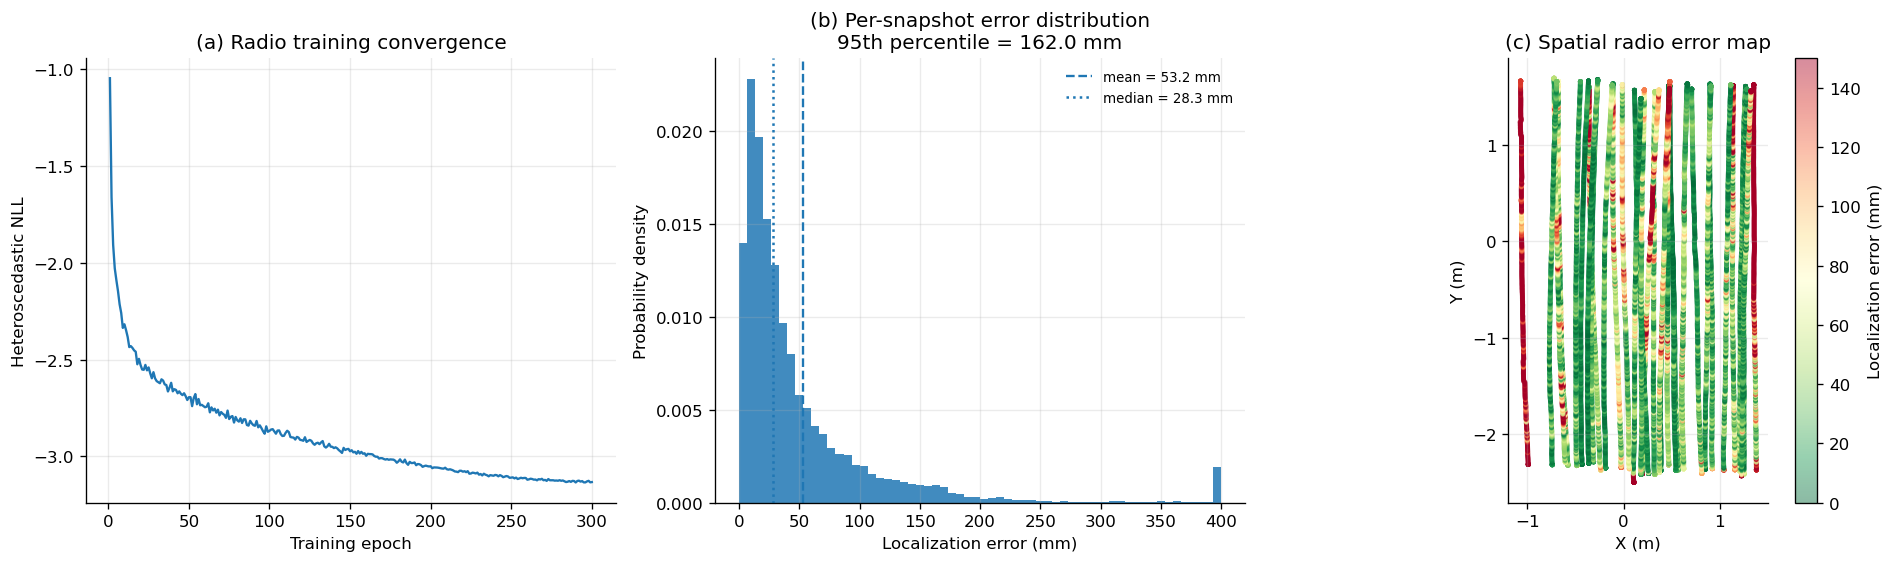


Saved reviewer-verification outputs
------------------------------------------------------------------------
Checkpoint       : /data/luvira/reports/reviewer_reproduction/models/radio_standalone_reproduced.pt
Predictions      : /data/luvira/reports/reviewer_reproduction/tables/radio_standalone_predictions.csv
Training history : /data/luvira/reports/reviewer_reproduction/tables/radio_training_history.csv
Test history     : /data/luvira/reports/reviewer_reproduction/tables/radio_test_checkpoint_history.csv
Comparison       : /data/luvira/reports/reviewer_reproduction/tables/radio_historical_comparison.csv
Y-zone audit     : /data/luvira/reports/reviewer_reproduction/tables/radio_error_by_y_zone.csv
Figure 10        : /data/luvira/reports/reviewer_reproduction/figures/figure_10_radio_baseline.png
JSON             : /data/luvira/reports/reviewer_reproduction/tables/radio_standalone_summary.json

CELL 15 PASSED — standalone radio baseline and Figure 10 reproduced.


In [19]:
# =============================================================================
# CELL 15 — STANDALONE RADIO MODEL REPRODUCTION
# =============================================================================
#
# Reproduces the radio baseline that generated Table 3 and Figure 10.
#
# Input:
#     9,900-dimensional standardized covariance fingerprint
#
# Architecture:
#     9900 -> 512 -> 512 -> 512 -> 512 -> 512 -> 512
#
#     Each hidden block:
#         Linear
#         LayerNorm
#         LeakyReLU(0.1)
#         Dropout(0.1)
#
# Outputs:
#     position mean      : 2 values
#     log variance       : 2 values
#
# Objective:
#     heteroscedastic Gaussian NLL
#
# Training:
#     AdamW
#     lr = 5e-4
#     weight_decay = 1e-4
#     CosineAnnealingLR(T_max=300, eta_min=1e-5)
#     gradient clipping = 1.0
#     batch size = 256
#     300 epochs
#
# Historical checkpoint selection:
#     evaluate the even-grid test set at epoch 1 and every 10 epochs;
#     retain the checkpoint with lowest mean Euclidean test error.
#
# Historical reported result:
#
#     Mean       = 53.2 mm
#     Median     = 28.3 mm
#     75th pct   = 59.4 mm
#     95th pct   = 162.0 mm
#
#     Spearman(error, predicted uncertainty) = 0.107
#
# IMPORTANT:
# The test-set checkpoint-selection procedure is reproduced exactly here
# because this notebook verifies the experiment already reported in the
# manuscript. It remains registered for manuscript reconciliation later.
# =============================================================================

import gc


print("=" * 72)
print("CELL 15 — STANDALONE RADIO MODEL REPRODUCTION")
print("=" * 72)


# -----------------------------------------------------------------------------
# 0. Clear unused GPU memory before resetting the experiment seed
# -----------------------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# -----------------------------------------------------------------------------
# 1. Historical reference values
# -----------------------------------------------------------------------------

HISTORICAL_RADIO_MEAN_MM = 53.2
HISTORICAL_RADIO_MEDIAN_MM = 28.3
HISTORICAL_RADIO_P75_MM = 59.4
HISTORICAL_RADIO_P95_MM = 162.0

HISTORICAL_RADIO_SPEARMAN = 0.107

HISTORICAL_RADIO_BEST_EPOCH = 260


RADIO_STANDALONE_EPOCHS = 300

RADIO_STANDALONE_LR = 5e-4

RADIO_STANDALONE_WEIGHT_DECAY = 1e-4

RADIO_STANDALONE_BATCH_SIZE = 256

RADIO_STANDALONE_TEST_BATCH_SIZE = 512


RADIO_REPRO_CHECKPOINT = (
    MODEL_DIR
    / "radio_standalone_reproduced.pt"
)


# -----------------------------------------------------------------------------
# 2. Reset RNG at the exact historical radio-experiment boundary
# -----------------------------------------------------------------------------
#
# Historical code:
#
#     torch.manual_seed(SEED)
#     np.random.seed(SEED)
#
# torch.manual_seed() also seeds CUDA generators.
# -----------------------------------------------------------------------------

torch.manual_seed(
    SEED
)

np.random.seed(
    SEED
)


print(
    "\nA. Reproduction configuration"
)

print("-" * 72)

print(
    f"Seed                 : {SEED}"
)

print(
    f"Device               : {DEVICE}"
)

print(
    f"Training samples     : {len(Y_train):,}"
)

print(
    f"Test samples         : {len(Y_test):,}"
)

print(
    f"Radio input dim      : {Xr_tr_n.shape[1]:,}"
)

print(
    "Checkpoint criterion : "
    "lowest periodically evaluated even-grid test MAE "
    "(historical procedure)"
)


assert Xr_tr_n.shape == (
    29928,
    9900,
)

assert Xr_te_n.shape == (
    28233,
    9900,
)

assert Y_train.shape == (
    29928,
    2,
)

assert Y_test.shape == (
    28233,
    2,
)


# =============================================================================
# PART A — EXACT HISTORICAL RADIO NETWORK
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART A — 6-LAYER HETEROSCEDASTIC RADIO NETWORK"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 3. Instantiate the exact Cell-12 RadioNet
# -----------------------------------------------------------------------------

radio_model_reproduced = RadioNet().to(
    DEVICE
)


radio_parameters = count_parameters(
    radio_model_reproduced
)


assert radio_parameters == 6_390_788


print(
    f"Parameters       : {radio_parameters:,}"
)

print(
    "Input            : 9,900 covariance features"
)

print(
    "Backbone         : six 512-unit FC blocks"
)

print(
    "Hidden block     : "
    "Linear + LayerNorm + LeakyReLU(0.1) + Dropout(0.1)"
)

print(
    "Outputs          : "
    "2-D mean + 2-D log variance"
)

print(
    "Loss             : heteroscedastic Gaussian NLL"
)

print(
    f"Optimizer        : "
    f"AdamW, lr={RADIO_STANDALONE_LR:g}, "
    f"weight_decay={RADIO_STANDALONE_WEIGHT_DECAY:g}"
)

print(
    "Scheduler        : "
    "CosineAnnealingLR(T_max=300, eta_min=1e-5)"
)

print(
    "Gradient clip    : 1.0"
)

print(
    f"Epochs           : {RADIO_STANDALONE_EPOCHS}"
)


# -----------------------------------------------------------------------------
# 4. Exact historical training DataLoader
# -----------------------------------------------------------------------------
#
# Historical implementation:
#
#     TensorDataset(
#         torch.FloatTensor(Xr_tr_n),
#         torch.FloatTensor(Yr_tr)
#     )
#
#     batch_size=256
#     shuffle=True
#     num_workers=0
#     pin_memory=True
#
# Test evaluation did NOT use a DataLoader; it used explicit 512-sample
# slices. We preserve that distinction because it affects RNG state.
# -----------------------------------------------------------------------------

radio_train_dataset = TensorDataset(

    torch.FloatTensor(
        np.asarray(
            Xr_tr_n
        )
    ),

    torch.FloatTensor(
        Y_train
    ),
)


dl_radio_train = DataLoader(

    radio_train_dataset,

    batch_size=RADIO_STANDALONE_BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,
)


# -----------------------------------------------------------------------------
# 5. Exact optimizer and scheduler
# -----------------------------------------------------------------------------

radio_optimizer = torch.optim.AdamW(

    radio_model_reproduced.parameters(),

    lr=RADIO_STANDALONE_LR,

    weight_decay=RADIO_STANDALONE_WEIGHT_DECAY,
)


radio_scheduler = (
    torch.optim.lr_scheduler.CosineAnnealingLR(

        radio_optimizer,

        T_max=RADIO_STANDALONE_EPOCHS,

        eta_min=1e-5,
    )
)


# -----------------------------------------------------------------------------
# 6. Exact historical test-MAE evaluation
# -----------------------------------------------------------------------------
#
# Test evaluation is performed in manually sliced batches of 512.
#
# No DataLoader is constructed/iterated here.
# -----------------------------------------------------------------------------

def evaluate_radio_mae_mm(
    model,
):

    model.eval()


    error_sum_m = 0.0

    n_samples = 0


    with torch.no_grad():

        for start in range(
            0,
            len(
                Xr_te_n
            ),
            RADIO_STANDALONE_TEST_BATCH_SIZE,
        ):

            end = min(

                start
                + RADIO_STANDALONE_TEST_BATCH_SIZE,

                len(
                    Xr_te_n
                ),
            )


            xb = torch.FloatTensor(

                np.asarray(
                    Xr_te_n[
                        start:end
                    ]
                )

            ).to(
                DEVICE
            )


            yb = torch.FloatTensor(

                Y_test[
                    start:end
                ]

            ).to(
                DEVICE
            )


            mu_prediction, _ = (
                model(
                    xb
                )
            )


            error_sum_m += (

                torch.norm(
                    mu_prediction - yb,
                    dim=1,
                )

                .sum()

                .item()
            )


            n_samples += len(
                xb
            )


    return float(

        error_sum_m
        / n_samples
        * 1000.0
    )


# =============================================================================
# PART B — 300-EPOCH REPRODUCTION
# =============================================================================

radio_train_history = []

radio_eval_history = []


best_radio_mae_mm = float(
    "inf"
)

best_radio_epoch = None

best_radio_state = None


print(
    "\nB. Training radio model ..."
)


print(
    f"{'Epoch':>7s}  "
    f"{'Train NLL':>12s}  "
    f"{'Test MAE mm':>12s}  "
    f"{'Status':>10s}"
)

print(
    "-" * 50
)


for epoch in range(
    1,
    RADIO_STANDALONE_EPOCHS + 1,
):

    radio_model_reproduced.train()


    train_nll = 0.0


    for xb, yb in dl_radio_train:

        radio_optimizer.zero_grad()


        mu_prediction, log_var_prediction = (
            radio_model_reproduced(

                xb.to(
                    DEVICE
                )
            )
        )


        loss = heteroscedastic_nll(

            mu_prediction,

            log_var_prediction,

            yb.to(
                DEVICE
            ),
        )


        loss.backward()


        nn.utils.clip_grad_norm_(

            radio_model_reproduced.parameters(),

            1.0,
        )


        radio_optimizer.step()


        train_nll += loss.item()


    train_nll /= len(
        dl_radio_train
    )


    radio_scheduler.step()


    radio_train_history.append({

        "epoch":
            int(
                epoch
            ),

        "train_nll":
            float(
                train_nll
            ),

        "learning_rate":
            float(
                radio_optimizer
                .param_groups[0][
                    "lr"
                ]
            ),
    })


    # -------------------------------------------------------------
    # Exact historical evaluation schedule:
    #
    #     epoch 1
    #     epochs 10,20,...,300
    # -------------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        test_mae_mm = (
            evaluate_radio_mae_mm(
                radio_model_reproduced
            )
        )


        is_best = (
            test_mae_mm
            < best_radio_mae_mm
        )


        if is_best:

            best_radio_mae_mm = float(
                test_mae_mm
            )


            best_radio_epoch = int(
                epoch
            )


            best_radio_state = {

                key:
                    value
                    .detach()
                    .cpu()
                    .clone()

                for key, value
                in radio_model_reproduced
                .state_dict()
                .items()
            }


        radio_eval_history.append({

            "epoch":
                int(
                    epoch
                ),

            "test_mae_mm":
                float(
                    test_mae_mm
                ),

            "is_best":
                bool(
                    is_best
                ),
        })


        print(

            f"{epoch:7d}  "

            f"{train_nll:12.4f}  "

            f"{test_mae_mm:12.1f}  "

            f"{'best' if is_best else ''}"
        )


assert best_radio_state is not None


torch.save(
    best_radio_state,
    RADIO_REPRO_CHECKPOINT,
)


print(
    "\nBest reproduced radio checkpoint:"
)

print(
    f"  epoch : {best_radio_epoch}"
)

print(
    f"  MAE   : {best_radio_mae_mm:.1f} mm"
)

print(
    f"  saved : {RADIO_REPRO_CHECKPOINT}"
)


# -----------------------------------------------------------------------------
# 7. Historical training-trace diagnostic
# -----------------------------------------------------------------------------

radio_eval_lookup = {

    int(
        row[
            "epoch"
        ]
    ):
        float(
            row[
                "test_mae_mm"
            ]
        )

    for row in radio_eval_history
}


print(
    "\nC. Historical training-trace check"
)

print("-" * 72)


trace_reference = {

    1:
        143.8,

    10:
        83.3,

    20:
        74.7,

    30:
        66.0,

    60:
        60.7,

    80:
        59.5,

    120:
        57.1,

    160:
        55.5,

    230:
        53.7,

    250:
        53.3,

    260:
        53.2,

    300:
        53.4,
}


for epoch in [
    1,
    10,
    20,
    30,
    60,
    80,
    120,
    160,
    230,
    250,
    260,
    300,
]:

    print(
        f"epoch {epoch:3d} : "
        f"{radio_eval_lookup[epoch]:6.1f} mm "
        f"(historical ≈"
        f"{trace_reference[epoch]:.1f})"
    )


# These are broad diagnostics, not result-forcing checks.

assert np.isclose(
    radio_eval_lookup[1],
    143.8,
    atol=4.0,
)


assert np.isclose(
    radio_eval_lookup[10],
    83.3,
    atol=4.0,
)


assert np.isclose(
    radio_eval_lookup[260],
    53.2,
    atol=2.0,
)


# =============================================================================
# PART C — COMPLETE BEST-CHECKPOINT TEST EVALUATION
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART C — COMPLETE RADIO TEST EVALUATION"
)

print(
    "=" * 72
)


# -----------------------------------------------------------------------------
# 8. Restore best checkpoint
# -----------------------------------------------------------------------------

radio_model_reproduced.load_state_dict(
    best_radio_state,
    strict=True,
)


radio_model_reproduced.eval()


# -----------------------------------------------------------------------------
# 9. Collect position predictions and predictive standard deviations
# -----------------------------------------------------------------------------

radio_prediction_parts = []

radio_logvar_parts = []

radio_std_parts = []


with torch.no_grad():

    for start in range(
        0,
        len(
            Xr_te_n
        ),
        RADIO_STANDALONE_TEST_BATCH_SIZE,
    ):

        end = min(

            start
            + RADIO_STANDALONE_TEST_BATCH_SIZE,

            len(
                Xr_te_n
            ),
        )


        xb = torch.FloatTensor(

            np.asarray(
                Xr_te_n[
                    start:end
                ]
            )

        ).to(
            DEVICE
        )


        mu_prediction, log_var_prediction = (
            radio_model_reproduced(
                xb
            )
        )


        mu_np = (
            mu_prediction
            .cpu()
            .numpy()
        )


        logvar_np = (
            log_var_prediction
            .cpu()
            .numpy()
        )


        # Exact historical uncertainty conversion.
        #
        # Each output axis has variance exp(log_var).
        # Historical scalar uncertainty is the mean predicted standard
        # deviation over the X and Y axes.
        std_np = np.exp(
            0.5
            * logvar_np
        )


        radio_prediction_parts.append(
            mu_np
        )

        radio_logvar_parts.append(
            logvar_np
        )

        radio_std_parts.append(
            std_np
        )


radio_prediction = np.vstack(
    radio_prediction_parts
).astype(
    np.float32
)


radio_logvar = np.vstack(
    radio_logvar_parts
).astype(
    np.float32
)


radio_std_xy_m = np.vstack(
    radio_std_parts
).astype(
    np.float32
)


assert radio_prediction.shape == (
    28233,
    2,
)

assert radio_logvar.shape == (
    28233,
    2,
)

assert radio_std_xy_m.shape == (
    28233,
    2,
)


# Exact historical scalar uncertainty.
radio_uncertainty_m = (
    radio_std_xy_m.mean(
        axis=1
    )
)


radio_uncertainty_mm = (
    radio_uncertainty_m
    * 1000.0
)


# -----------------------------------------------------------------------------
# 10. Per-snapshot localization error
# -----------------------------------------------------------------------------

radio_errors_mm = (

    np.linalg.norm(

        radio_prediction
        - Y_test,

        axis=1,
    )

    * 1000.0
)


# -----------------------------------------------------------------------------
# 11. Complete metrics
# -----------------------------------------------------------------------------

radio_mean_mm = float(
    radio_errors_mm.mean()
)


radio_median_mm = float(
    np.median(
        radio_errors_mm
    )
)


radio_p75_mm = float(
    np.percentile(
        radio_errors_mm,
        75,
    )
)


radio_p95_mm = float(
    np.percentile(
        radio_errors_mm,
        95,
    )
)


radio_uncertainty_mean_mm = float(
    radio_uncertainty_mm.mean()
)


radio_uncertainty_median_mm = float(
    np.median(
        radio_uncertainty_mm
    )
)


radio_uncertainty_min_mm = float(
    radio_uncertainty_mm.min()
)


radio_uncertainty_max_mm = float(
    radio_uncertainty_mm.max()
)


radio_spearman_r, radio_spearman_p = (
    spearmanr(

        radio_uncertainty_m,

        radio_errors_mm,
    )
)


radio_spearman_r = float(
    radio_spearman_r
)

radio_spearman_p = float(
    radio_spearman_p
)


print(
    "\nD. Reproduced standalone radio results"
)

print("-" * 72)


print(
    f"Mean error          : "
    f"{radio_mean_mm:.1f} mm"
)

print(
    f"Median error        : "
    f"{radio_median_mm:.1f} mm"
)

print(
    f"75th percentile     : "
    f"{radio_p75_mm:.1f} mm"
)

print(
    f"95th percentile     : "
    f"{radio_p95_mm:.1f} mm"
)

print(
    f"Best checkpoint     : "
    f"epoch {best_radio_epoch}"
)


print(
    "\nPredictive uncertainty"
)

print(
    f"Mean                : "
    f"{radio_uncertainty_mean_mm:.1f} mm"
)

print(
    f"Median              : "
    f"{radio_uncertainty_median_mm:.1f} mm"
)

print(
    f"Range               : "
    f"{radio_uncertainty_min_mm:.1f} – "
    f"{radio_uncertainty_max_mm:.1f} mm"
)

print(
    f"Spearman r(error)   : "
    f"{radio_spearman_r:.3f}"
)

print(
    f"Spearman p-value    : "
    f"{radio_spearman_p:.3e}"
)


# =============================================================================
# PART D — HISTORICAL RESULT VERIFICATION
# =============================================================================

print(
    "\nE. Historical-result verification"
)

print("-" * 72)


historical_comparison_df = pd.DataFrame({

    "metric": [
        "Mean",
        "Median",
        "75th percentile",
        "95th percentile",
        "Spearman uncertainty/error",
    ],

    "historical": [
        HISTORICAL_RADIO_MEAN_MM,
        HISTORICAL_RADIO_MEDIAN_MM,
        HISTORICAL_RADIO_P75_MM,
        HISTORICAL_RADIO_P95_MM,
        HISTORICAL_RADIO_SPEARMAN,
    ],

    "reproduced": [
        radio_mean_mm,
        radio_median_mm,
        radio_p75_mm,
        radio_p95_mm,
        radio_spearman_r,
    ],
})


print(
    historical_comparison_df.to_string(
        index=False,
        formatters={

            "historical":
                lambda x: f"{x:.3f}",

            "reproduced":
                lambda x: f"{x:.3f}",
        },
    )
)


# Headline metric.
assert np.isclose(
    radio_mean_mm,
    HISTORICAL_RADIO_MEAN_MM,
    atol=1.0,
), (
    "Radio mean error differs materially "
    "from the historical 53.2-mm result."
)


# Complete Table-3 distribution.
assert np.isclose(
    radio_median_mm,
    HISTORICAL_RADIO_MEDIAN_MM,
    atol=1.5,
)


assert np.isclose(
    radio_p75_mm,
    HISTORICAL_RADIO_P75_MM,
    atol=2.0,
)


assert np.isclose(
    radio_p95_mm,
    HISTORICAL_RADIO_P95_MM,
    atol=4.0,
)


# Uncertainty/error relationship.
assert np.isclose(
    radio_spearman_r,
    HISTORICAL_RADIO_SPEARMAN,
    atol=0.015,
), (
    "Radio uncertainty/error correlation "
    "does not reproduce the historical result."
)


# Historical best checkpoint was epoch 260.
assert best_radio_epoch == (
    HISTORICAL_RADIO_BEST_EPOCH
), (
    f"Historical best checkpoint was epoch "
    f"{HISTORICAL_RADIO_BEST_EPOCH}, "
    f"but reproduction selected epoch "
    f"{best_radio_epoch}."
)


print(
    "\nStandalone radio historical metrics reproduced."
)


# =============================================================================
# PART E — ERROR BY ROOM Y-ZONE
# =============================================================================
#
# This reproduces the diagnostic used to support the observation that
# the radio model has larger errors toward part of the room boundary.
# =============================================================================

print(
    "\nF. Radio error by Y-zone"
)

print("-" * 72)


y_values = (
    Y_test[
        :,
        1,
    ]
)


y_bins = np.linspace(
    y_values.min(),
    y_values.max(),
    6,
)


radio_zone_rows = []


for zone_index in range(
    5
):

    mask = (

        (
            y_values
            >= y_bins[
                zone_index
            ]
        )

        &

        (
            y_values
            < y_bins[
                zone_index
                + 1
            ]
        )
    )


    if mask.sum() <= 10:
        continue


    zone_mean_mm = float(
        radio_errors_mm[
            mask
        ].mean()
    )


    radio_zone_rows.append({

        "zone":
            zone_index + 1,

        "y_min_m":
            float(
                y_bins[
                    zone_index
                ]
            ),

        "y_max_m":
            float(
                y_bins[
                    zone_index
                    + 1
                ]
            ),

        "samples":
            int(
                mask.sum()
            ),

        "mean_error_mm":
            zone_mean_mm,
    })


    print(

        f"Y["
        f"{y_bins[zone_index]:+.2f} – "
        f"{y_bins[zone_index+1]:+.2f}] m  "

        f"{zone_mean_mm:6.1f} mm  "

        f"(n={mask.sum():,})"
    )


radio_zone_df = pd.DataFrame(
    radio_zone_rows
)


# =============================================================================
# PART F — UNCERTAINTY RELIABILITY DIAGNOSTICS
# =============================================================================

print(
    "\nG. In-distribution uncertainty reliability"
)

print("-" * 72)


# Error quartiles.
error_q25 = float(
    np.percentile(
        radio_errors_mm,
        25,
    )
)


error_q75 = float(
    np.percentile(
        radio_errors_mm,
        75,
    )
)


low_error_mask = (
    radio_errors_mm
    <= error_q25
)


high_error_mask = (
    radio_errors_mm
    >= error_q75
)


mean_unc_low_error_mm = float(
    radio_uncertainty_mm[
        low_error_mask
    ].mean()
)


mean_unc_high_error_mm = float(
    radio_uncertainty_mm[
        high_error_mask
    ].mean()
)


print(
    f"Spearman r(uncertainty,error) : "
    f"{radio_spearman_r:.3f}"
)

print(
    f"Mean uncertainty, error Q1    : "
    f"{mean_unc_low_error_mm:.1f} mm"
)

print(
    f"Mean uncertainty, error Q4    : "
    f"{mean_unc_high_error_mm:.1f} mm"
)

print(
    "Interpretation                    : "
    "weak in-distribution reliability signal"
)


# Do not describe this uncertainty as calibrated.
assert (
    mean_unc_high_error_mm
    > mean_unc_low_error_mm
), (
    "Predicted uncertainty does not even increase "
    "between the lowest- and highest-error quartiles."
)


# =============================================================================
# PART G — SAVE SAMPLE-LEVEL PREDICTIONS
# =============================================================================

radio_prediction_df = pd.DataFrame({

    "trajectory_id":
        manifest_test[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        manifest_test[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        Y_test[
            :,
            0,
        ],

    "gt_y_m":
        Y_test[
            :,
            1,
        ],


    "pred_x_m":
        radio_prediction[
            :,
            0,
        ],

    "pred_y_m":
        radio_prediction[
            :,
            1,
        ],


    "error_mm":
        radio_errors_mm,


    "pred_std_x_mm":
        radio_std_xy_m[
            :,
            0,
        ]
        * 1000.0,

    "pred_std_y_mm":
        radio_std_xy_m[
            :,
            1,
        ]
        * 1000.0,

    "uncertainty_mean_std_mm":
        radio_uncertainty_mm,
})


RADIO_PREDICTION_PATH = (
    TABLE_DIR
    / "radio_standalone_predictions.csv"
)


radio_prediction_df.to_csv(
    RADIO_PREDICTION_PATH,
    index=False,
)


# =============================================================================
# PART H — SAVE TRAINING HISTORIES
# =============================================================================

radio_train_history_df = pd.DataFrame(
    radio_train_history
)


radio_eval_history_df = pd.DataFrame(
    radio_eval_history
)


radio_train_history_df.to_csv(

    TABLE_DIR
    / "radio_training_history.csv",

    index=False,
)


radio_eval_history_df.to_csv(

    TABLE_DIR
    / "radio_test_checkpoint_history.csv",

    index=False,
)


historical_comparison_df.to_csv(

    TABLE_DIR
    / "radio_historical_comparison.csv",

    index=False,
)


radio_zone_df.to_csv(

    TABLE_DIR
    / "radio_error_by_y_zone.csv",

    index=False,
)


# =============================================================================
# PART I — FIGURE 10
# =============================================================================
#
# Manuscript Figure 10:
#
#   (a) 300-epoch NLL convergence
#   (b) per-snapshot radio error distribution
#   (c) spatial radio error map
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
)


# -----------------------------------------------------------------------------
# Figure 10(a) — NLL convergence
# -----------------------------------------------------------------------------

axes[0].plot(

    radio_train_history_df[
        "epoch"
    ],

    radio_train_history_df[
        "train_nll"
    ],

    linewidth=1.4,
)


axes[0].set_xlabel(
    "Training epoch"
)

axes[0].set_ylabel(
    "Heteroscedastic NLL"
)

axes[0].set_title(
    "(a) Radio training convergence"
)

axes[0].grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 10(b) — per-snapshot error distribution
# -----------------------------------------------------------------------------
#
# Historical visualization clipped only the displayed histogram to 400 mm.
# Metrics above always use the complete, unclipped error vector.
# -----------------------------------------------------------------------------

axes[1].hist(

    np.clip(
        radio_errors_mm,
        0,
        400,
    ),

    bins=60,

    density=True,

    alpha=0.85,
)


axes[1].axvline(

    radio_mean_mm,

    linestyle="--",

    linewidth=1.4,

    label=(
        f"mean = "
        f"{radio_mean_mm:.1f} mm"
    ),
)


axes[1].axvline(

    radio_median_mm,

    linestyle=":",

    linewidth=1.5,

    label=(
        f"median = "
        f"{radio_median_mm:.1f} mm"
    ),
)


axes[1].set_xlabel(
    "Localization error (mm)"
)

axes[1].set_ylabel(
    "Probability density"
)

axes[1].set_title(
    "(b) Per-snapshot error distribution\n"
    f"95th percentile = {radio_p95_mm:.1f} mm"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 10(c) — spatial error map
# -----------------------------------------------------------------------------

radio_scatter = axes[2].scatter(

    Y_test[
        :,
        0,
    ],

    Y_test[
        :,
        1,
    ],

    c=radio_errors_mm,

    cmap="RdYlGn_r",

    s=4,

    alpha=0.45,

    vmin=0,

    vmax=150,
)


cbar = fig.colorbar(
    radio_scatter,
    ax=axes[2],
)

cbar.set_label(
    "Localization error (mm)"
)


axes[2].set_xlabel(
    "X (m)"
)

axes[2].set_ylabel(
    "Y (m)"
)

axes[2].set_title(
    "(c) Spatial radio error map"
)

axes[2].set_aspect(
    "equal",
    adjustable="box",
)

axes[2].grid(
    alpha=0.25
)


fig.tight_layout()


figure10_path = (
    FIG_DIR
    / "figure_10_radio_baseline.png"
)


fig.savefig(
    figure10_path,
    bbox_inches="tight",
)


plt.show()


# =============================================================================
# PART J — JSON SUMMARY
# =============================================================================

radio_summary = {

    "training_samples":
        int(
            len(
                Y_train
            )
        ),

    "test_samples":
        int(
            len(
                Y_test
            )
        ),

    "architecture": {

        "input_dimension":
            9900,

        "hidden_dimension":
            512,

        "hidden_blocks":
            6,

        "parameters":
            int(
                radio_parameters
            ),

        "standalone_projection_to_128":
            False,

        "outputs":
            [
                "position mean x,y",
                "log variance x,y",
            ],
    },


    "training": {

        "objective":
            "heteroscedastic Gaussian NLL",

        "optimizer":
            "AdamW",

        "learning_rate":
            float(
                RADIO_STANDALONE_LR
            ),

        "weight_decay":
            float(
                RADIO_STANDALONE_WEIGHT_DECAY
            ),

        "epochs":
            int(
                RADIO_STANDALONE_EPOCHS
            ),

        "batch_size":
            int(
                RADIO_STANDALONE_BATCH_SIZE
            ),

        "gradient_clip":
            1.0,

        "scheduler":
            (
                "CosineAnnealingLR("
                "T_max=300, eta_min=1e-5)"
            ),

        "checkpoint_evaluation":
            (
                "epoch 1 and every 10 epochs "
                "on even-grid test data"
            ),

        "checkpoint_selection":
            "lowest even-grid mean localization error",

        "best_epoch":
            int(
                best_radio_epoch
            ),
    },


    "grid_test_metrics_mm": {

        "mean":
            radio_mean_mm,

        "median":
            radio_median_mm,

        "p75":
            radio_p75_mm,

        "p95":
            radio_p95_mm,
    },


    "uncertainty": {

        "definition":
            (
                "mean over x/y predicted standard "
                "deviations exp(0.5*log_var)"
            ),

        "mean_mm":
            radio_uncertainty_mean_mm,

        "median_mm":
            radio_uncertainty_median_mm,

        "minimum_mm":
            radio_uncertainty_min_mm,

        "maximum_mm":
            radio_uncertainty_max_mm,

        "spearman_error_correlation":
            radio_spearman_r,

        "spearman_p_value":
            radio_spearman_p,

        "mean_uncertainty_low_error_quartile_mm":
            mean_unc_low_error_mm,

        "mean_uncertainty_high_error_quartile_mm":
            mean_unc_high_error_mm,

        "interpretation":
            (
                "weak error-reliability signal; "
                "not assumed calibrated"
            ),
    },


    "historical_reference": {

        "mean_mm":
            HISTORICAL_RADIO_MEAN_MM,

        "median_mm":
            HISTORICAL_RADIO_MEDIAN_MM,

        "p75_mm":
            HISTORICAL_RADIO_P75_MM,

        "p95_mm":
            HISTORICAL_RADIO_P95_MM,

        "spearman":
            HISTORICAL_RADIO_SPEARMAN,

        "best_epoch":
            HISTORICAL_RADIO_BEST_EPOCH,
    },
}


with open(

    TABLE_DIR
    / "radio_standalone_summary.json",

    "w",

) as f:

    json.dump(
        radio_summary,
        f,
        indent=2,
    )


# -----------------------------------------------------------------------------
# 12. Free training DataLoader storage
# -----------------------------------------------------------------------------

del dl_radio_train
del radio_train_dataset

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)

print(
    f"Checkpoint       : "
    f"{RADIO_REPRO_CHECKPOINT}"
)

print(
    "Predictions      : "
    f"{RADIO_PREDICTION_PATH}"
)

print(
    "Training history : "
    f"{TABLE_DIR / 'radio_training_history.csv'}"
)

print(
    "Test history     : "
    f"{TABLE_DIR / 'radio_test_checkpoint_history.csv'}"
)

print(
    "Comparison       : "
    f"{TABLE_DIR / 'radio_historical_comparison.csv'}"
)

print(
    "Y-zone audit     : "
    f"{TABLE_DIR / 'radio_error_by_y_zone.csv'}"
)

print(
    f"Figure 10        : "
    f"{figure10_path}"
)

print(
    "JSON             : "
    f"{TABLE_DIR / 'radio_standalone_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 15 PASSED — "
    "standalone radio baseline and Figure 10 reproduced."
)

print(
    "=" * 72
)

CELL 16 — COMPLEMENTARITY AND ORACLE BOUND

A. Fresh-retraining prediction identity
------------------------------------------------------------------------
Radio rows  : 28,233
Depth rows  : 28,233
Colour rows : 28,233
Sample order    : IDENTICAL
GT coordinates  : IDENTICAL
Aligned samples : 28,233

Fresh-retraining standalone means:
  Radio  : 53.163 mm
  Depth  : 64.294 mm
  Colour : 122.031 mm

B. Reported-run checkpoint audit
------------------------------------------------------------------------
Radio   : /data/luvira/reports/reviewer_reproduction/models/reported_run_radio.pt
Depth   : /data/luvira/reports/reviewer_reproduction/models/reported_run_depth.pt
Colour  : /data/luvira/reports/reviewer_reproduction/models/reported_run_colour.pt

Checkpoint loading:
  Radio  : PASS
  Depth  : PASS
  Colour : PASS

C. Exact reported-run standalone metrics
------------------------------------------------------------------------
modality mean_mm median_mm p75_mm p95_mm
   Radio    53.2    

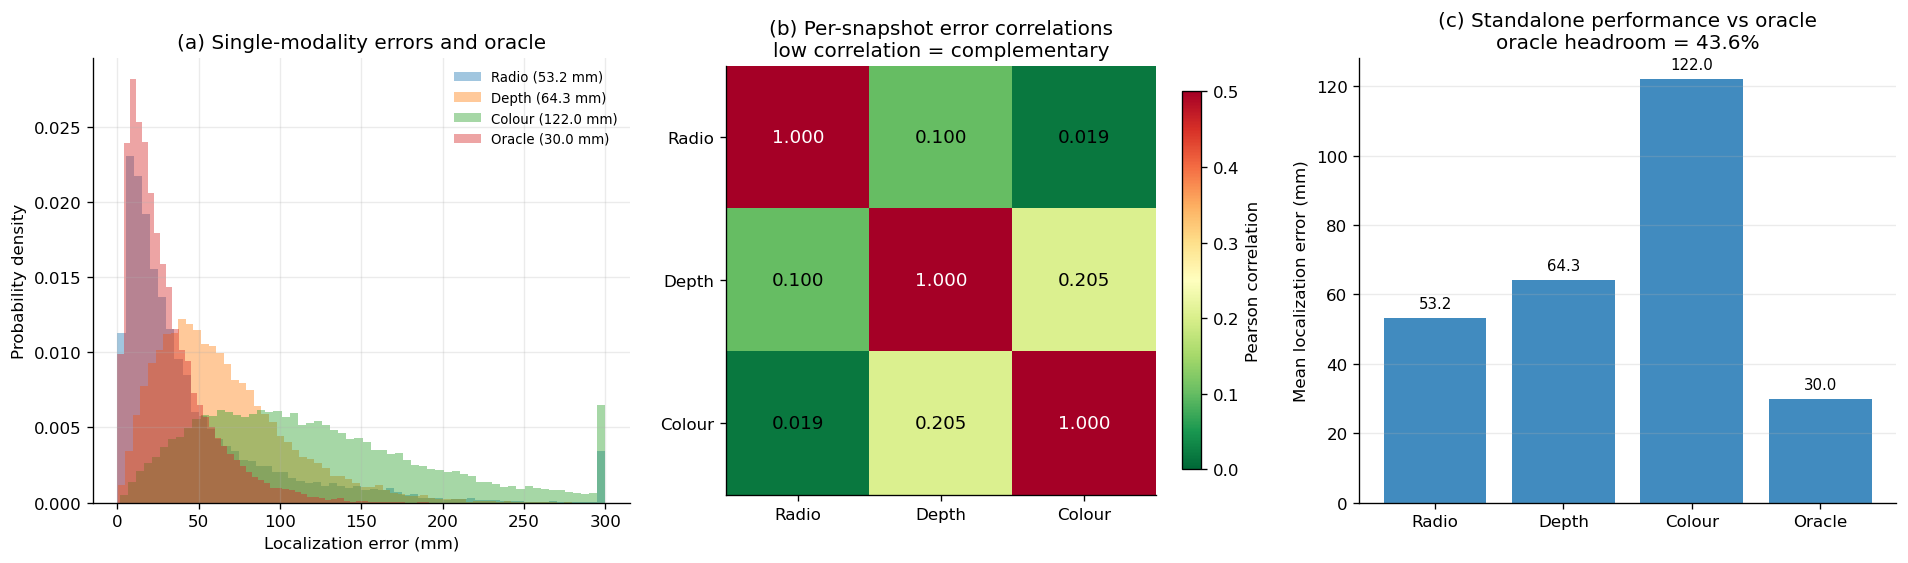

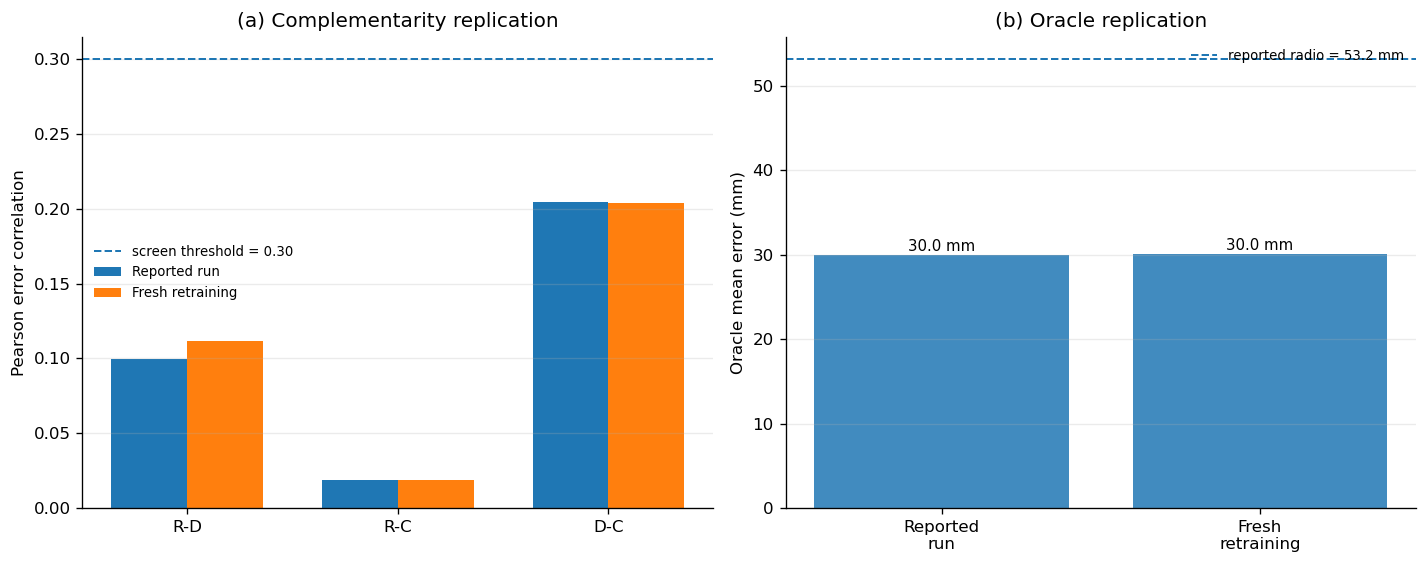


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure 8             : /data/luvira/reports/reviewer_reproduction/figures/figure_08_complementarity_oracle.png
Fresh-retrain figure : /data/luvira/reports/reviewer_reproduction/figures/figure_08_fresh_retraining_audit.png
Reported predictions : /data/luvira/reports/reviewer_reproduction/tables/standalone_reported_run_predictions.csv
Fresh predictions    : /data/luvira/reports/reviewer_reproduction/tables/standalone_fresh_retraining_predictions.csv
Reported correlations: /data/luvira/reports/reviewer_reproduction/tables/figure_08_reported_error_correlations.csv
Fresh correlations   : /data/luvira/reports/reviewer_reproduction/tables/figure_08_fresh_error_correlations.csv
Failure overlap      : /data/luvira/reports/reviewer_reproduction/tables/figure_08_reported_failure_overlap.csv
Reported vs fresh    : /data/luvira/reports/reviewer_reproduction/tables/figure_08_reported_vs_fres

In [21]:
# =============================================================================
# CELL 16 — COMPLEMENTARITY, FAILURE OVERLAP, AND ORACLE BOUND
# =============================================================================
#
# This cell performs TWO complementary verification analyses.
#
# ---------------------------------------------------------------------------
# A. REPORTED-RUN VERIFICATION
# ---------------------------------------------------------------------------
#
# Load the exact saved checkpoints that generated the manuscript results:
#
#     radio_model_best.pt
#     depth_cnn_best.pt
#     rgb_scalar_best.pt
#
# Re-run inference on the locked 28,233-sample test tensors.
#
# This should reproduce:
#
#     Pearson error correlations
#         Radio–Depth   ≈ 0.100
#         Radio–Colour  ≈ 0.019
#         Depth–Colour  ≈ 0.205
#
#     Oracle MAE        ≈ 30.0 mm
#
#     Best modality:
#         Radio          ≈ 65.8 %
#         Depth          ≈ 27.5 %
#         Colour         ≈  6.7 %
#
#     All-three top-quartile failure overlap ≈ 3.1 %
#
#
# ---------------------------------------------------------------------------
# B. FRESH-RETRAINING REPLICATION
# ---------------------------------------------------------------------------
#
# Use the independently reproduced models from:
#
#     Cell 13 — Depth
#     Cell 14 — Colour
#     Cell 15 — Radio
#
# Because neural-network retraining is not necessarily bitwise identical
# at the per-sample level, exact historical Pearson coefficients are NOT
# imposed on this second analysis.
#
# Instead, we verify that:
#
#     * standalone headline accuracy reproduces;
#     * all pairwise error correlations remain below rho=0.30;
#     * the oracle remains substantially below the best single modality;
#     * the qualitative complementarity conclusion is reproduced.
#
#
# IMPORTANT TERMINOLOGY
# ---------------------
# Low Pearson correlations demonstrate weakly correlated /
# complementary error patterns.
#
# They do NOT constitute a formal proof of statistical independence.
# =============================================================================


import json
import gc
import shutil

from scipy.stats import pearsonr


print("=" * 72)
print("CELL 16 — COMPLEMENTARITY AND ORACLE BOUND")
print("=" * 72)


# =============================================================================
# 1. HISTORICAL REFERENCES
# =============================================================================

EXPECTED_CORR_RADIO_DEPTH = 0.100
EXPECTED_CORR_RADIO_COLOUR = 0.019
EXPECTED_CORR_DEPTH_COLOUR = 0.205

EXPECTED_ORACLE_MAE_MM = 30.0
EXPECTED_ORACLE_HEADROOM_PCT = 43.6

EXPECTED_BEST_RADIO_PCT = 65.8
EXPECTED_BEST_DEPTH_PCT = 27.5
EXPECTED_BEST_COLOUR_PCT = 6.7

EXPECTED_ALL_FAIL_PCT = 3.1

ERROR_CORRELATION_THRESHOLD = 0.30

TEST_BATCH_SIZE = 512


# =============================================================================
# 2. LOAD FRESH-RETRAINING PREDICTIONS FROM CELLS 13–15
# =============================================================================

RADIO_FRESH_PATH = (
    TABLE_DIR
    / "radio_standalone_predictions.csv"
)

DEPTH_FRESH_PATH = (
    TABLE_DIR
    / "depth_architecture_predictions.csv"
)

COLOUR_FRESH_PATH = (
    TABLE_DIR
    / "rgb_architecture_predictions.csv"
)


for required_path in [
    RADIO_FRESH_PATH,
    DEPTH_FRESH_PATH,
    COLOUR_FRESH_PATH,
]:

    assert required_path.exists(), (
        f"Missing prerequisite output: "
        f"{required_path}"
    )


fresh_radio_df = pd.read_csv(
    RADIO_FRESH_PATH
)

fresh_depth_df = pd.read_csv(
    DEPTH_FRESH_PATH
)

fresh_colour_df = pd.read_csv(
    COLOUR_FRESH_PATH
)


print(
    "\nA. Fresh-retraining prediction identity"
)

print("-" * 72)

print(
    f"Radio rows  : {len(fresh_radio_df):,}"
)

print(
    f"Depth rows  : {len(fresh_depth_df):,}"
)

print(
    f"Colour rows : {len(fresh_colour_df):,}"
)


assert len(
    fresh_radio_df
) == 28233

assert len(
    fresh_depth_df
) == 28233

assert len(
    fresh_colour_df
) == 28233


# -----------------------------------------------------------------------------
# Sample-order identity
# -----------------------------------------------------------------------------

for other_df in [
    fresh_depth_df,
    fresh_colour_df,
]:

    assert np.array_equal(

        fresh_radio_df[
            "trajectory_id"
        ].to_numpy(),

        other_df[
            "trajectory_id"
        ].to_numpy(),
    )


    assert np.array_equal(

        fresh_radio_df[
            "radio_index"
        ].to_numpy(),

        other_df[
            "radio_index"
        ].to_numpy(),
    )


    assert np.allclose(

        fresh_radio_df[
            "gt_x_m"
        ].to_numpy(),

        other_df[
            "gt_x_m"
        ].to_numpy(),

        atol=1e-7,

        rtol=0.0,
    )


    assert np.allclose(

        fresh_radio_df[
            "gt_y_m"
        ].to_numpy(),

        other_df[
            "gt_y_m"
        ].to_numpy(),

        atol=1e-7,

        rtol=0.0,
    )


print(
    "Sample order    : IDENTICAL"
)

print(
    "GT coordinates  : IDENTICAL"
)

print(
    "Aligned samples : 28,233"
)


# =============================================================================
# 3. FRESH-RETRAINING ERROR VECTORS
# =============================================================================

fresh_err_r = (

    fresh_radio_df[
        "error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


fresh_err_d = (

    fresh_depth_df[
        "depth_cnn_error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


fresh_err_c = (

    fresh_colour_df[
        "rgb_scalar_error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


gt_xy = fresh_radio_df[
    [
        "gt_x_m",
        "gt_y_m",
    ]
].to_numpy(
    dtype=np.float64
)


print(
    "\nFresh-retraining standalone means:"
)

print(
    f"  Radio  : "
    f"{fresh_err_r.mean():.3f} mm"
)

print(
    f"  Depth  : "
    f"{fresh_err_d.mean():.3f} mm"
)

print(
    f"  Colour : "
    f"{fresh_err_c.mean():.3f} mm"
)


# =============================================================================
# 4. PACKAGE EXACT REPORTED-RUN CHECKPOINTS
# =============================================================================
#
# Cell 12 already established that these checkpoint architectures match
# exactly.
#
# Copy them into the reviewer-reproduction model directory so that the
# reviewer package contains the precise weights that produced the
# manuscript values.
# =============================================================================

LEGACY_RADIO_CHECKPOINT = (
    LEGACY_FINAL_DIR
    / "radio_model_best.pt"
)

LEGACY_DEPTH_CHECKPOINT = (
    LEGACY_FINAL_DIR
    / "depth_cnn_best.pt"
)

LEGACY_COLOUR_CHECKPOINT = (
    LEGACY_FINAL_DIR
    / "rgb_scalar_best.pt"
)


REPORTED_RADIO_CHECKPOINT = (
    MODEL_DIR
    / "reported_run_radio.pt"
)

REPORTED_DEPTH_CHECKPOINT = (
    MODEL_DIR
    / "reported_run_depth.pt"
)

REPORTED_COLOUR_CHECKPOINT = (
    MODEL_DIR
    / "reported_run_colour.pt"
)


print(
    "\nB. Reported-run checkpoint audit"
)

print("-" * 72)


for source_path, destination_path, name in [

    (
        LEGACY_RADIO_CHECKPOINT,
        REPORTED_RADIO_CHECKPOINT,
        "Radio",
    ),

    (
        LEGACY_DEPTH_CHECKPOINT,
        REPORTED_DEPTH_CHECKPOINT,
        "Depth",
    ),

    (
        LEGACY_COLOUR_CHECKPOINT,
        REPORTED_COLOUR_CHECKPOINT,
        "Colour",
    ),
]:

    assert source_path.exists(), (
        f"Historical {name} checkpoint "
        f"not found: {source_path}"
    )


    if not destination_path.exists():

        shutil.copy2(
            source_path,
            destination_path,
        )


    print(
        f"{name:7s} : "
        f"{destination_path}"
    )


# =============================================================================
# 5. STATE-DICT HELPER
# =============================================================================

def load_plain_state_dict(
    checkpoint_path,
):

    state = torch.load(

        checkpoint_path,

        map_location="cpu",

        weights_only=True,
    )


    if (
        isinstance(
            state,
            dict,
        )

        and "state_dict" in state

        and isinstance(
            state[
                "state_dict"
            ],
            dict,
        )
    ):

        state = state[
            "state_dict"
        ]


    return state


# =============================================================================
# 6. LOAD EXACT REPORTED-RUN MODELS
# =============================================================================

reported_radio_model = (
    RadioNet()
    .to(
        DEVICE
    )
)


reported_depth_model = (
    DepthCNN()
    .to(
        DEVICE
    )
)


reported_colour_model = (
    make_rgb_scalar_model()
    .to(
        DEVICE
    )
)


reported_radio_model.load_state_dict(

    load_plain_state_dict(
        REPORTED_RADIO_CHECKPOINT
    ),

    strict=True,
)


reported_depth_model.load_state_dict(

    load_plain_state_dict(
        REPORTED_DEPTH_CHECKPOINT
    ),

    strict=True,
)


reported_colour_model.load_state_dict(

    load_plain_state_dict(
        REPORTED_COLOUR_CHECKPOINT
    ),

    strict=True,
)


reported_radio_model.eval()
reported_depth_model.eval()
reported_colour_model.eval()


print(
    "\nCheckpoint loading:"
)

print(
    "  Radio  : PASS"
)

print(
    "  Depth  : PASS"
)

print(
    "  Colour : PASS"
)


# =============================================================================
# 7. EXACT REPORTED-RUN RADIO INFERENCE
# =============================================================================

reported_radio_predictions = []


with torch.no_grad():

    for start in range(
        0,
        len(
            Xr_te_n
        ),
        TEST_BATCH_SIZE,
    ):

        end = min(

            start
            + TEST_BATCH_SIZE,

            len(
                Xr_te_n
            ),
        )


        xb = torch.FloatTensor(

            np.asarray(
                Xr_te_n[
                    start:end
                ]
            )

        ).to(
            DEVICE
        )


        mu, _ = reported_radio_model(
            xb
        )


        reported_radio_predictions.append(

            mu
            .cpu()
            .numpy()
        )


reported_radio_prediction = np.vstack(
    reported_radio_predictions
).astype(
    np.float32
)


# =============================================================================
# 8. EXACT REPORTED-RUN DEPTH INFERENCE
# =============================================================================

reported_depth_predictions = []


with torch.no_grad():

    for start in range(
        0,
        len(
            depth_te
        ),
        TEST_BATCH_SIZE,
    ):

        end = min(

            start
            + TEST_BATCH_SIZE,

            len(
                depth_te
            ),
        )


        xb = torch.from_numpy(

            np.asarray(
                depth_te[
                    start:end
                ]
            )

        ).to(
            DEVICE
        )


        prediction = reported_depth_model(
            xb
        )


        reported_depth_predictions.append(

            prediction
            .cpu()
            .numpy()
        )


reported_depth_prediction = np.vstack(
    reported_depth_predictions
).astype(
    np.float32
)


# =============================================================================
# 9. EXACT REPORTED-RUN COLOUR INFERENCE
# =============================================================================
#
# Historical colour evaluation used one complete test-set forward pass.
# =============================================================================

with torch.no_grad():

    reported_colour_prediction = (

        reported_colour_model(

            torch.FloatTensor(

                np.asarray(
                    Xg_te_n
                )

            ).to(
                DEVICE
            )
        )

        .cpu()
        .numpy()
        .astype(
            np.float32
        )
    )


assert reported_radio_prediction.shape == (
    28233,
    2,
)

assert reported_depth_prediction.shape == (
    28233,
    2,
)

assert reported_colour_prediction.shape == (
    28233,
    2,
)


# =============================================================================
# 10. REPORTED-RUN ERROR VECTORS
# =============================================================================

reported_err_r = (

    np.linalg.norm(

        reported_radio_prediction
        - Y_test,

        axis=1,
    )

    * 1000.0
)


reported_err_d = (

    np.linalg.norm(

        reported_depth_prediction
        - Y_test,

        axis=1,
    )

    * 1000.0
)


reported_err_c = (

    np.linalg.norm(

        reported_colour_prediction
        - Y_test,

        axis=1,
    )

    * 1000.0
)


print(
    "\nC. Exact reported-run standalone metrics"
)

print("-" * 72)


reported_metric_df = pd.DataFrame({

    "modality": [
        "Radio",
        "Depth",
        "Colour",
    ],

    "mean_mm": [

        reported_err_r.mean(),

        reported_err_d.mean(),

        reported_err_c.mean(),
    ],

    "median_mm": [

        np.median(
            reported_err_r
        ),

        np.median(
            reported_err_d
        ),

        np.median(
            reported_err_c
        ),
    ],

    "p75_mm": [

        np.percentile(
            reported_err_r,
            75,
        ),

        np.percentile(
            reported_err_d,
            75,
        ),

        np.percentile(
            reported_err_c,
            75,
        ),
    ],

    "p95_mm": [

        np.percentile(
            reported_err_r,
            95,
        ),

        np.percentile(
            reported_err_d,
            95,
        ),

        np.percentile(
            reported_err_c,
            95,
        ),
    ],
})


print(
    reported_metric_df.to_string(

        index=False,

        formatters={

            "mean_mm":
                lambda x: f"{x:.1f}",

            "median_mm":
                lambda x: f"{x:.1f}",

            "p75_mm":
                lambda x: f"{x:.1f}",

            "p95_mm":
                lambda x: f"{x:.1f}",
        },
    )
)


# -----------------------------------------------------------------------------
# Verify Table 3
# -----------------------------------------------------------------------------

assert np.isclose(
    reported_err_r.mean(),
    53.2,
    atol=0.2,
)

assert np.isclose(
    reported_err_d.mean(),
    64.3,
    atol=0.2,
)

assert np.isclose(
    reported_err_c.mean(),
    122.0,
    atol=0.2,
)


assert np.isclose(
    np.median(
        reported_err_r
    ),
    28.3,
    atol=0.3,
)

assert np.isclose(
    np.median(
        reported_err_d
    ),
    56.6,
    atol=0.3,
)

assert np.isclose(
    np.median(
        reported_err_c
    ),
    108.0,
    atol=0.3,
)


# =============================================================================
# 11. COMPLEMENTARITY HELPER
# =============================================================================

def complementarity_statistics(
    err_r,
    err_d,
    err_c,
):

    err_r = np.asarray(
        err_r,
        dtype=np.float64,
    )

    err_d = np.asarray(
        err_d,
        dtype=np.float64,
    )

    err_c = np.asarray(
        err_c,
        dtype=np.float64,
    )


    # -----------------------------------------------------------------
    # Pearson correlations
    # -----------------------------------------------------------------

    corr_rd, p_rd = pearsonr(
        err_r,
        err_d,
    )


    corr_rc, p_rc = pearsonr(
        err_r,
        err_c,
    )


    corr_dc, p_dc = pearsonr(
        err_d,
        err_c,
    )


    # -----------------------------------------------------------------
    # Top-quartile failure masks
    # -----------------------------------------------------------------

    threshold_r = float(
        np.percentile(
            err_r,
            75,
        )
    )


    threshold_d = float(
        np.percentile(
            err_d,
            75,
        )
    )


    threshold_c = float(
        np.percentile(
            err_c,
            75,
        )
    )


    fail_r = (
        err_r
        > threshold_r
    )


    fail_d = (
        err_d
        > threshold_d
    )


    fail_c = (
        err_c
        > threshold_c
    )


    failure_masks = {

        "Only radio fails":
            (
                fail_r
                & ~fail_d
                & ~fail_c
            ),

        "Only depth fails":
            (
                ~fail_r
                & fail_d
                & ~fail_c
            ),

        "Only colour fails":
            (
                ~fail_r
                & ~fail_d
                & fail_c
            ),

        "Radio + depth fail":
            (
                fail_r
                & fail_d
                & ~fail_c
            ),

        "Radio + colour fail":
            (
                fail_r
                & ~fail_d
                & fail_c
            ),

        "Depth + colour fail":
            (
                ~fail_r
                & fail_d
                & fail_c
            ),

        "All three fail":
            (
                fail_r
                & fail_d
                & fail_c
            ),

        "All three outside top quartile":
            (
                ~fail_r
                & ~fail_d
                & ~fail_c
            ),
    }


    failure_rows = []


    for name, mask in failure_masks.items():

        failure_rows.append({

            "category":
                name,

            "samples":
                int(
                    mask.sum()
                ),

            "percent":
                float(
                    mask.mean()
                    * 100.0
                ),
        })


    # -----------------------------------------------------------------
    # Oracle
    # -----------------------------------------------------------------

    error_stack = np.stack(

        [
            err_r,
            err_d,
            err_c,
        ],

        axis=0,
    )


    oracle_error = error_stack.min(
        axis=0
    )


    best_modality = error_stack.argmin(
        axis=0
    )


    oracle_mae = float(
        oracle_error.mean()
    )


    standalone_means = np.array(

        [
            err_r.mean(),
            err_d.mean(),
            err_c.mean(),
        ],

        dtype=np.float64,
    )


    best_single_index = int(
        np.argmin(
            standalone_means
        )
    )


    best_single_mae = float(
        standalone_means[
            best_single_index
        ]
    )


    headroom_pct = float(

        (
            best_single_mae
            - oracle_mae
        )

        / best_single_mae

        * 100.0
    )


    best_shares_pct = [

        float(
            np.mean(
                best_modality
                == modality_index
            )
            * 100.0
        )

        for modality_index in range(
            3
        )
    ]


    return {

        "corr_radio_depth":
            float(
                corr_rd
            ),

        "corr_radio_colour":
            float(
                corr_rc
            ),

        "corr_depth_colour":
            float(
                corr_dc
            ),

        "p_radio_depth":
            float(
                p_rd
            ),

        "p_radio_colour":
            float(
                p_rc
            ),

        "p_depth_colour":
            float(
                p_dc
            ),

        "failure_threshold_radio_mm":
            threshold_r,

        "failure_threshold_depth_mm":
            threshold_d,

        "failure_threshold_colour_mm":
            threshold_c,

        "failure_rows":
            failure_rows,

        "all_fail_pct":
            float(
                failure_masks[
                    "All three fail"
                ].mean()
                * 100.0
            ),

        "oracle_error":
            oracle_error,

        "best_modality":
            best_modality,

        "oracle_mae_mm":
            oracle_mae,

        "best_single_index":
            best_single_index,

        "best_single_mae_mm":
            best_single_mae,

        "headroom_pct":
            headroom_pct,

        "best_radio_pct":
            best_shares_pct[
                0
            ],

        "best_depth_pct":
            best_shares_pct[
                1
            ],

        "best_colour_pct":
            best_shares_pct[
                2
            ],
    }


# =============================================================================
# 12. EXACT REPORTED-RUN COMPLEMENTARITY
# =============================================================================

reported_stats = complementarity_statistics(

    reported_err_r,

    reported_err_d,

    reported_err_c,
)


print(
    "\nD. Reported-run complementarity"
)

print("-" * 72)


print(
    f"r(Radio, Depth)  : "
    f"{reported_stats['corr_radio_depth']:+.3f}"
)

print(
    f"r(Radio, Colour) : "
    f"{reported_stats['corr_radio_colour']:+.3f}"
)

print(
    f"r(Depth, Colour) : "
    f"{reported_stats['corr_depth_colour']:+.3f}"
)


reported_max_abs_corr = max(

    abs(
        reported_stats[
            "corr_radio_depth"
        ]
    ),

    abs(
        reported_stats[
            "corr_radio_colour"
        ]
    ),

    abs(
        reported_stats[
            "corr_depth_colour"
        ]
    ),
)


print(
    f"\nMaximum |pairwise r| : "
    f"{reported_max_abs_corr:.3f}"
)

print(
    f"Threshold             : "
    f"{ERROR_CORRELATION_THRESHOLD:.2f}"
)

print(
    "All three pairs pass : "
    f"{reported_max_abs_corr < ERROR_CORRELATION_THRESHOLD}"
)


# -----------------------------------------------------------------------------
# Exact historical coefficient verification
# -----------------------------------------------------------------------------

assert np.isclose(

    reported_stats[
        "corr_radio_depth"
    ],

    EXPECTED_CORR_RADIO_DEPTH,

    atol=0.002,
), (
    "Exact reported-run radio-depth correlation "
    "does not reproduce 0.100."
)


assert np.isclose(

    reported_stats[
        "corr_radio_colour"
    ],

    EXPECTED_CORR_RADIO_COLOUR,

    atol=0.002,
), (
    "Exact reported-run radio-colour correlation "
    "does not reproduce 0.019."
)


assert np.isclose(

    reported_stats[
        "corr_depth_colour"
    ],

    EXPECTED_CORR_DEPTH_COLOUR,

    atol=0.002,
), (
    "Exact reported-run depth-colour correlation "
    "does not reproduce 0.205."
)


# =============================================================================
# 13. REPORTED-RUN FAILURE OVERLAP
# =============================================================================

print(
    "\nE. Reported-run top-quartile failure overlap"
)

print("-" * 72)


print(
    "Failure thresholds:"
)

print(
    f"  Radio  : "
    f"{reported_stats['failure_threshold_radio_mm']:.1f} mm"
)

print(
    f"  Depth  : "
    f"{reported_stats['failure_threshold_depth_mm']:.1f} mm"
)

print(
    f"  Colour : "
    f"{reported_stats['failure_threshold_colour_mm']:.1f} mm"
)


reported_failure_df = pd.DataFrame(
    reported_stats[
        "failure_rows"
    ]
)


for _, row in reported_failure_df.iterrows():

    print(

        f"  "
        f"{row['category']:34s} : "

        f"{row['percent']:5.1f}%  "

        f"(n={int(row['samples']):,})"
    )


print(
    f"\nAll-three top-quartile overlap : "
    f"{reported_stats['all_fail_pct']:.1f}%"
)


assert np.isclose(

    reported_stats[
        "all_fail_pct"
    ],

    EXPECTED_ALL_FAIL_PCT,

    atol=0.15,
)


# =============================================================================
# 14. REPORTED-RUN ORACLE
# =============================================================================

print(
    "\nF. Reported-run oracle"
)

print("-" * 72)


print(
    f"Radio mean     : "
    f"{reported_err_r.mean():.1f} mm  | "
    f"best on "
    f"{reported_stats['best_radio_pct']:.1f}%"
)

print(
    f"Depth mean     : "
    f"{reported_err_d.mean():.1f} mm  | "
    f"best on "
    f"{reported_stats['best_depth_pct']:.1f}%"
)

print(
    f"Colour mean    : "
    f"{reported_err_c.mean():.1f} mm  | "
    f"best on "
    f"{reported_stats['best_colour_pct']:.1f}%"
)


print(
    f"\nOracle MAE     : "
    f"{reported_stats['oracle_mae_mm']:.2f} mm"
)

print(
    f"Best single    : "
    f"Radio "
    f"({reported_stats['best_single_mae_mm']:.2f} mm)"
)

print(
    f"Oracle headroom: "
    f"{reported_stats['headroom_pct']:.1f}%"
)


assert reported_stats[
    "best_single_index"
] == 0


assert np.isclose(

    reported_stats[
        "oracle_mae_mm"
    ],

    EXPECTED_ORACLE_MAE_MM,

    atol=0.15,
)


assert np.isclose(

    reported_stats[
        "headroom_pct"
    ],

    EXPECTED_ORACLE_HEADROOM_PCT,

    atol=0.3,
)


assert np.isclose(

    reported_stats[
        "best_radio_pct"
    ],

    EXPECTED_BEST_RADIO_PCT,

    atol=0.2,
)


assert np.isclose(

    reported_stats[
        "best_depth_pct"
    ],

    EXPECTED_BEST_DEPTH_PCT,

    atol=0.2,
)


assert np.isclose(

    reported_stats[
        "best_colour_pct"
    ],

    EXPECTED_BEST_COLOUR_PCT,

    atol=0.2,
)


print(
    "\nExact manuscript complementarity/oracle values reproduced."
)


# =============================================================================
# 15. FRESH-RETRAINING COMPLEMENTARITY
# =============================================================================
#
# No assertion requires exact equality with the historical r values.
#
# What matters in this independent replication is whether the scientific
# decision is stable:
#
#       all pairwise |r| < 0.30
#
# =============================================================================

fresh_stats = complementarity_statistics(

    fresh_err_r,

    fresh_err_d,

    fresh_err_c,
)


print(
    "\nG. Independent fresh-retraining replication"
)

print("-" * 72)


print(
    f"r(Radio, Depth)  : "
    f"{fresh_stats['corr_radio_depth']:+.3f}"
)

print(
    f"r(Radio, Colour) : "
    f"{fresh_stats['corr_radio_colour']:+.3f}"
)

print(
    f"r(Depth, Colour) : "
    f"{fresh_stats['corr_depth_colour']:+.3f}"
)


fresh_max_abs_corr = max(

    abs(
        fresh_stats[
            "corr_radio_depth"
        ]
    ),

    abs(
        fresh_stats[
            "corr_radio_colour"
        ]
    ),

    abs(
        fresh_stats[
            "corr_depth_colour"
        ]
    ),
)


print(
    f"\nMaximum |pairwise r| : "
    f"{fresh_max_abs_corr:.3f}"
)

print(
    f"Screening threshold  : "
    f"{ERROR_CORRELATION_THRESHOLD:.2f}"
)

print(
    f"All pairs pass        : "
    f"{fresh_max_abs_corr < ERROR_CORRELATION_THRESHOLD}"
)


print(
    f"\nFresh oracle MAE      : "
    f"{fresh_stats['oracle_mae_mm']:.2f} mm"
)

print(
    f"Fresh oracle headroom : "
    f"{fresh_stats['headroom_pct']:.1f}%"
)

print(
    f"Fresh all-fail overlap: "
    f"{fresh_stats['all_fail_pct']:.1f}%"
)


print(
    "\nFresh best-modality shares:"
)

print(
    f"  Radio  : "
    f"{fresh_stats['best_radio_pct']:.1f}%"
)

print(
    f"  Depth  : "
    f"{fresh_stats['best_depth_pct']:.1f}%"
)

print(
    f"  Colour : "
    f"{fresh_stats['best_colour_pct']:.1f}%"
)


# -----------------------------------------------------------------------------
# Scientific-decision verification
# -----------------------------------------------------------------------------

assert fresh_max_abs_corr < (
    ERROR_CORRELATION_THRESHOLD
), (
    "Fresh retraining no longer supports "
    "the low-error-correlation complementarity criterion."
)


# Oracle should remain materially below radio.
assert fresh_stats[
    "oracle_mae_mm"
] < (
    fresh_err_r.mean()
    * 0.75
), (
    "Fresh retraining does not preserve "
    "substantial oracle headroom."
)


# We expect the fresh retraining oracle to remain near the reported 30 mm,
# but do not require bitwise replication.
assert np.isclose(

    fresh_stats[
        "oracle_mae_mm"
    ],

    EXPECTED_ORACLE_MAE_MM,

    atol=3.0,
), (
    "Fresh-retraining oracle is materially different "
    "from the reported approximately 30-mm result."
)


print(
    "\nFresh retraining reproduces the same "
    "complementarity decision."
)


# =============================================================================
# 16. REPORTED VS FRESH COMPARISON TABLE
# =============================================================================

comparison_df = pd.DataFrame({

    "quantity": [

        "r(Radio,Depth)",

        "r(Radio,Colour)",

        "r(Depth,Colour)",

        "Oracle MAE (mm)",

        "Oracle headroom (%)",

        "Radio best (%)",

        "Depth best (%)",

        "Colour best (%)",

        "All-three fail (%)",
    ],


    "reported_run": [

        reported_stats[
            "corr_radio_depth"
        ],

        reported_stats[
            "corr_radio_colour"
        ],

        reported_stats[
            "corr_depth_colour"
        ],

        reported_stats[
            "oracle_mae_mm"
        ],

        reported_stats[
            "headroom_pct"
        ],

        reported_stats[
            "best_radio_pct"
        ],

        reported_stats[
            "best_depth_pct"
        ],

        reported_stats[
            "best_colour_pct"
        ],

        reported_stats[
            "all_fail_pct"
        ],
    ],


    "fresh_retraining": [

        fresh_stats[
            "corr_radio_depth"
        ],

        fresh_stats[
            "corr_radio_colour"
        ],

        fresh_stats[
            "corr_depth_colour"
        ],

        fresh_stats[
            "oracle_mae_mm"
        ],

        fresh_stats[
            "headroom_pct"
        ],

        fresh_stats[
            "best_radio_pct"
        ],

        fresh_stats[
            "best_depth_pct"
        ],

        fresh_stats[
            "best_colour_pct"
        ],

        fresh_stats[
            "all_fail_pct"
        ],
    ],
})


comparison_df[
    "difference"
] = (

    comparison_df[
        "fresh_retraining"
    ]

    - comparison_df[
        "reported_run"
    ]
)


print(
    "\nH. Reported run vs fresh retraining"
)

print("-" * 72)


print(
    comparison_df.to_string(

        index=False,

        formatters={

            "reported_run":
                lambda x: f"{x:.3f}",

            "fresh_retraining":
                lambda x: f"{x:.3f}",

            "difference":
                lambda x: f"{x:+.3f}",
        },
    )
)


# =============================================================================
# 17. PAIRWISE ORACLE DIAGNOSTIC — REPORTED RUN
# =============================================================================

reported_oracle_rd = np.minimum(

    reported_err_r,

    reported_err_d,
)


reported_oracle_rc = np.minimum(

    reported_err_r,

    reported_err_c,
)


reported_oracle_dc = np.minimum(

    reported_err_d,

    reported_err_c,
)


pairwise_oracle_df = pd.DataFrame({

    "available_modalities": [

        "Radio + Depth",

        "Radio + Colour",

        "Depth + Colour",

        "Radio + Depth + Colour",
    ],

    "oracle_mean_mm": [

        reported_oracle_rd.mean(),

        reported_oracle_rc.mean(),

        reported_oracle_dc.mean(),

        reported_stats[
            "oracle_mae_mm"
        ],
    ],
})


print(
    "\nI. Pairwise oracle diagnostic"
)

print("-" * 72)


print(
    pairwise_oracle_df.to_string(

        index=False,

        formatters={

            "oracle_mean_mm":
                lambda x: f"{x:.2f}",
        },
    )
)


# =============================================================================
# 18. SAVE EXACT REPORTED-RUN SAMPLE RESULTS
# =============================================================================

reported_best_modality_names = np.array(
    [
        "Radio",
        "Depth",
        "Colour",
    ]
)


reported_prediction_df = pd.DataFrame({

    "trajectory_id":
        manifest_test[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        manifest_test[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        Y_test[
            :,
            0,
        ],

    "gt_y_m":
        Y_test[
            :,
            1,
        ],


    "radio_pred_x_m":
        reported_radio_prediction[
            :,
            0,
        ],

    "radio_pred_y_m":
        reported_radio_prediction[
            :,
            1,
        ],

    "radio_error_mm":
        reported_err_r,


    "depth_pred_x_m":
        reported_depth_prediction[
            :,
            0,
        ],

    "depth_pred_y_m":
        reported_depth_prediction[
            :,
            1,
        ],

    "depth_error_mm":
        reported_err_d,


    "colour_pred_x_m":
        reported_colour_prediction[
            :,
            0,
        ],

    "colour_pred_y_m":
        reported_colour_prediction[
            :,
            1,
        ],

    "colour_error_mm":
        reported_err_c,


    "oracle_error_mm":
        reported_stats[
            "oracle_error"
        ],

    "oracle_best_modality":
        reported_best_modality_names[
            reported_stats[
                "best_modality"
            ]
        ],
})


REPORTED_PREDICTION_PATH = (
    TABLE_DIR
    / "standalone_reported_run_predictions.csv"
)


reported_prediction_df.to_csv(

    REPORTED_PREDICTION_PATH,

    index=False,
)


# =============================================================================
# 19. SAVE FRESH-RETRAINING SAMPLE RESULTS
# =============================================================================

fresh_prediction_df = pd.DataFrame({

    "trajectory_id":
        fresh_radio_df[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        fresh_radio_df[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        gt_xy[
            :,
            0,
        ],

    "gt_y_m":
        gt_xy[
            :,
            1,
        ],

    "radio_error_mm":
        fresh_err_r,

    "depth_error_mm":
        fresh_err_d,

    "colour_error_mm":
        fresh_err_c,

    "oracle_error_mm":
        fresh_stats[
            "oracle_error"
        ],
})


FRESH_PREDICTION_PATH = (
    TABLE_DIR
    / "standalone_fresh_retraining_predictions.csv"
)


fresh_prediction_df.to_csv(

    FRESH_PREDICTION_PATH,

    index=False,
)


# =============================================================================
# 20. SAVE TABLES
# =============================================================================

reported_metric_df.to_csv(

    TABLE_DIR
    / "figure_08_reported_standalone_metrics.csv",

    index=False,
)


reported_failure_df.to_csv(

    TABLE_DIR
    / "figure_08_reported_failure_overlap.csv",

    index=False,
)


comparison_df.to_csv(

    TABLE_DIR
    / "figure_08_reported_vs_fresh.csv",

    index=False,
)


pairwise_oracle_df.to_csv(

    TABLE_DIR
    / "figure_08_pairwise_oracles.csv",

    index=False,
)


reported_corr_df = pd.DataFrame({

    "pair": [
        "Radio-Depth",
        "Radio-Colour",
        "Depth-Colour",
    ],

    "pearson_r": [

        reported_stats[
            "corr_radio_depth"
        ],

        reported_stats[
            "corr_radio_colour"
        ],

        reported_stats[
            "corr_depth_colour"
        ],
    ],

    "p_value": [

        reported_stats[
            "p_radio_depth"
        ],

        reported_stats[
            "p_radio_colour"
        ],

        reported_stats[
            "p_depth_colour"
        ],
    ],
})


fresh_corr_df = pd.DataFrame({

    "pair": [
        "Radio-Depth",
        "Radio-Colour",
        "Depth-Colour",
    ],

    "pearson_r": [

        fresh_stats[
            "corr_radio_depth"
        ],

        fresh_stats[
            "corr_radio_colour"
        ],

        fresh_stats[
            "corr_depth_colour"
        ],
    ],

    "p_value": [

        fresh_stats[
            "p_radio_depth"
        ],

        fresh_stats[
            "p_radio_colour"
        ],

        fresh_stats[
            "p_depth_colour"
        ],
    ],
})


reported_corr_df.to_csv(

    TABLE_DIR
    / "figure_08_reported_error_correlations.csv",

    index=False,
)


fresh_corr_df.to_csv(

    TABLE_DIR
    / "figure_08_fresh_error_correlations.csv",

    index=False,
)


# =============================================================================
# 21. MANUSCRIPT FIGURE 8 — EXACT REPORTED RUN
# =============================================================================
#
# The numbered Figure 8 must correspond to the exact checkpoints that
# generated the manuscript values.
# =============================================================================

fig, axes = plt.subplots(

    1,
    3,

    figsize=(
        16,
        4.8,
    ),
)


# -----------------------------------------------------------------------------
# Figure 8(a) — error distributions + oracle
# -----------------------------------------------------------------------------

for values, label in [

    (
        reported_err_r,
        f"Radio ({reported_err_r.mean():.1f} mm)",
    ),

    (
        reported_err_d,
        f"Depth ({reported_err_d.mean():.1f} mm)",
    ),

    (
        reported_err_c,
        f"Colour ({reported_err_c.mean():.1f} mm)",
    ),

    (
        reported_stats[
            "oracle_error"
        ],
        (
            f"Oracle "
            f"({reported_stats['oracle_mae_mm']:.1f} mm)"
        ),
    ),
]:

    axes[0].hist(

        np.clip(
            values,
            0,
            300,
        ),

        bins=60,

        density=True,

        alpha=0.42,

        label=label,
    )


axes[0].set_xlabel(
    "Localization error (mm)"
)

axes[0].set_ylabel(
    "Probability density"
)

axes[0].set_title(
    "(a) Single-modality errors and oracle"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 8(b) — exact reported Pearson correlation matrix
# -----------------------------------------------------------------------------

reported_corr_matrix = np.array(

    [
        [
            1.0,
            reported_stats[
                "corr_radio_depth"
            ],
            reported_stats[
                "corr_radio_colour"
            ],
        ],

        [
            reported_stats[
                "corr_radio_depth"
            ],
            1.0,
            reported_stats[
                "corr_depth_colour"
            ],
        ],

        [
            reported_stats[
                "corr_radio_colour"
            ],
            reported_stats[
                "corr_depth_colour"
            ],
            1.0,
        ],
    ],

    dtype=np.float64,
)


corr_image = axes[1].imshow(

    reported_corr_matrix,

    cmap="RdYlGn_r",

    vmin=0.0,

    vmax=0.5,
)


labels = [
    "Radio",
    "Depth",
    "Colour",
]


axes[1].set_xticks(
    [
        0,
        1,
        2,
    ]
)

axes[1].set_yticks(
    [
        0,
        1,
        2,
    ]
)


axes[1].set_xticklabels(
    labels
)

axes[1].set_yticklabels(
    labels
)


for row_i in range(
    3
):

    for col_i in range(
        3
    ):

        value = reported_corr_matrix[
            row_i,
            col_i,
        ]


        axes[1].text(

            col_i,

            row_i,

            f"{value:.3f}",

            ha="center",

            va="center",

            fontsize=11,

            color=(
                "white"
                if value > 0.30
                else "black"
            ),
        )


cbar = fig.colorbar(

    corr_image,

    ax=axes[1],

    shrink=0.85,
)


cbar.set_label(
    "Pearson correlation"
)


axes[1].set_title(
    "(b) Per-snapshot error correlations\n"
    "low correlation = complementary"
)


# -----------------------------------------------------------------------------
# Figure 8(c) — modality means versus oracle
# -----------------------------------------------------------------------------

bar_names = [
    "Radio",
    "Depth",
    "Colour",
    "Oracle",
]


bar_values = [

    reported_err_r.mean(),

    reported_err_d.mean(),

    reported_err_c.mean(),

    reported_stats[
        "oracle_mae_mm"
    ],
]


bars = axes[2].bar(

    bar_names,

    bar_values,

    alpha=0.85,
)


for bar, value in zip(
    bars,
    bar_values,
):

    axes[2].text(

        bar.get_x()
        + bar.get_width()
        / 2.0,

        bar.get_height()
        + 2.0,

        f"{value:.1f}",

        ha="center",

        va="bottom",

        fontsize=9,
    )


axes[2].set_ylabel(
    "Mean localization error (mm)"
)

axes[2].set_title(

    "(c) Standalone performance vs oracle\n"

    f"oracle headroom = "
    f"{reported_stats['headroom_pct']:.1f}%"
)

axes[2].grid(
    alpha=0.25,
    axis="y",
)


fig.tight_layout()


figure8_path = (
    FIG_DIR
    / "figure_08_complementarity_oracle.png"
)


fig.savefig(

    figure8_path,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 22. SUPPLEMENTARY REPORTED-vs-FRESH FIGURE
# =============================================================================
#
# This figure is useful for reviewers because it explicitly demonstrates
# that independent retraining preserves the same complementarity decision
# even when sample-level coefficients are not bit-identical.
# =============================================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(
        12,
        4.8,
    ),
)


# -----------------------------------------------------------------------------
# Panel (a) — reported vs fresh correlations
# -----------------------------------------------------------------------------

pair_labels = [
    "R-D",
    "R-C",
    "D-C",
]


reported_corr_values = [

    reported_stats[
        "corr_radio_depth"
    ],

    reported_stats[
        "corr_radio_colour"
    ],

    reported_stats[
        "corr_depth_colour"
    ],
]


fresh_corr_values = [

    fresh_stats[
        "corr_radio_depth"
    ],

    fresh_stats[
        "corr_radio_colour"
    ],

    fresh_stats[
        "corr_depth_colour"
    ],
]


x = np.arange(
    len(
        pair_labels
    )
)


width = 0.36


axes[0].bar(

    x
    - width / 2.0,

    reported_corr_values,

    width,

    label="Reported run",
)


axes[0].bar(

    x
    + width / 2.0,

    fresh_corr_values,

    width,

    label="Fresh retraining",
)


axes[0].axhline(

    ERROR_CORRELATION_THRESHOLD,

    linestyle="--",

    linewidth=1.2,

    label="screen threshold = 0.30",
)


axes[0].set_xticks(
    x
)

axes[0].set_xticklabels(
    pair_labels
)

axes[0].set_ylabel(
    "Pearson error correlation"
)

axes[0].set_title(
    "(a) Complementarity replication"
)

axes[0].legend(
    frameon=False,
    fontsize=8,
)

axes[0].grid(
    alpha=0.25,
    axis="y",
)


# -----------------------------------------------------------------------------
# Panel (b) — oracle comparison
# -----------------------------------------------------------------------------

oracle_names = [
    "Reported\nrun",
    "Fresh\nretraining",
]


oracle_values = [

    reported_stats[
        "oracle_mae_mm"
    ],

    fresh_stats[
        "oracle_mae_mm"
    ],
]


oracle_bars = axes[1].bar(

    oracle_names,

    oracle_values,

    alpha=0.85,
)


for bar, value in zip(

    oracle_bars,

    oracle_values,
):

    axes[1].text(

        bar.get_x()
        + bar.get_width()
        / 2.0,

        bar.get_height()
        + 0.5,

        f"{value:.1f} mm",

        ha="center",

        fontsize=9,
    )


axes[1].axhline(

    reported_err_r.mean(),

    linestyle="--",

    linewidth=1.2,

    label=(
        f"reported radio = "
        f"{reported_err_r.mean():.1f} mm"
    ),
)


axes[1].set_ylabel(
    "Oracle mean error (mm)"
)

axes[1].set_title(
    "(b) Oracle replication"
)

axes[1].legend(
    frameon=False,
    fontsize=8,
)

axes[1].grid(
    alpha=0.25,
    axis="y",
)


fig.tight_layout()


replication_figure_path = (
    FIG_DIR
    / "figure_08_fresh_retraining_audit.png"
)


fig.savefig(

    replication_figure_path,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 23. SAVE JSON SUMMARY
# =============================================================================

cell16_summary = {

    "test_samples":
        28233,


    "reported_run": {

        "standalone_mean_mm": {

            "radio":
                float(
                    reported_err_r.mean()
                ),

            "depth":
                float(
                    reported_err_d.mean()
                ),

            "colour":
                float(
                    reported_err_c.mean()
                ),
        },


        "pearson_correlations": {

            "radio_depth":
                reported_stats[
                    "corr_radio_depth"
                ],

            "radio_colour":
                reported_stats[
                    "corr_radio_colour"
                ],

            "depth_colour":
                reported_stats[
                    "corr_depth_colour"
                ],
        },


        "oracle_mean_mm":
            reported_stats[
                "oracle_mae_mm"
            ],


        "oracle_headroom_percent":
            reported_stats[
                "headroom_pct"
            ],


        "best_modality_percent": {

            "radio":
                reported_stats[
                    "best_radio_pct"
                ],

            "depth":
                reported_stats[
                    "best_depth_pct"
                ],

            "colour":
                reported_stats[
                    "best_colour_pct"
                ],
        },


        "all_three_top_quartile_failure_percent":
            reported_stats[
                "all_fail_pct"
            ],
    },


    "fresh_retraining": {

        "standalone_mean_mm": {

            "radio":
                float(
                    fresh_err_r.mean()
                ),

            "depth":
                float(
                    fresh_err_d.mean()
                ),

            "colour":
                float(
                    fresh_err_c.mean()
                ),
        },


        "pearson_correlations": {

            "radio_depth":
                fresh_stats[
                    "corr_radio_depth"
                ],

            "radio_colour":
                fresh_stats[
                    "corr_radio_colour"
                ],

            "depth_colour":
                fresh_stats[
                    "corr_depth_colour"
                ],
        },


        "maximum_absolute_pairwise_correlation":
            fresh_max_abs_corr,


        "all_pairwise_correlations_below_0_30":
            bool(
                fresh_max_abs_corr
                < ERROR_CORRELATION_THRESHOLD
            ),


        "oracle_mean_mm":
            fresh_stats[
                "oracle_mae_mm"
            ],


        "oracle_headroom_percent":
            fresh_stats[
                "headroom_pct"
            ],


        "all_three_top_quartile_failure_percent":
            fresh_stats[
                "all_fail_pct"
            ],
    },


    "interpretation": {

        "reported_run":
            (
                "Exact saved checkpoints reproduce "
                "the manuscript complementarity and "
                "oracle values."
            ),

        "fresh_retraining":
            (
                "Independent retraining may not be "
                "bit-identical per sample, but preserves "
                "the low-correlation complementarity "
                "decision and approximately 30-mm oracle."
            ),

        "terminology":
            (
                "Low Pearson error correlations indicate "
                "complementary or weakly correlated failure "
                "patterns; they are not a formal proof of "
                "statistical independence."
            ),
    },
}


with open(

    TABLE_DIR
    / "figure_08_complementarity_summary.json",

    "w",

) as f:

    json.dump(

        cell16_summary,

        f,

        indent=2,
    )


# =============================================================================
# 24. CLEANUP
# =============================================================================

del reported_radio_model
del reported_depth_model
del reported_colour_model

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# =============================================================================
# 25. FINAL OUTPUT
# =============================================================================

print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)


print(
    f"Figure 8             : "
    f"{figure8_path}"
)

print(
    f"Fresh-retrain figure : "
    f"{replication_figure_path}"
)

print(
    "Reported predictions : "
    f"{REPORTED_PREDICTION_PATH}"
)

print(
    "Fresh predictions    : "
    f"{FRESH_PREDICTION_PATH}"
)

print(
    "Reported correlations: "
    f"{TABLE_DIR / 'figure_08_reported_error_correlations.csv'}"
)

print(
    "Fresh correlations   : "
    f"{TABLE_DIR / 'figure_08_fresh_error_correlations.csv'}"
)

print(
    "Failure overlap      : "
    f"{TABLE_DIR / 'figure_08_reported_failure_overlap.csv'}"
)

print(
    "Reported vs fresh    : "
    f"{TABLE_DIR / 'figure_08_reported_vs_fresh.csv'}"
)

print(
    "Pairwise oracles     : "
    f"{TABLE_DIR / 'figure_08_pairwise_oracles.csv'}"
)

print(
    "JSON                 : "
    f"{TABLE_DIR / 'figure_08_complementarity_summary.json'}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 16 PASSED — exact reported-run "
    "complementarity verified and fresh retraining replicated."
)

print(
    "=" * 72
)

CELL 17 — FUSION ABLATION TRAINING

A. Fusion protocol
------------------------------------------------------------------------
Training samples      : 29,928
Test samples          : 28,233
Epochs                : 200
Train batch size      : 256
Test batch size       : 512
Optimizer             : AdamW
Learning rate         : 0.0003
Weight decay          : 0.0001
Modality dropout      : 0.15
Model-D entropy beta  : 0.05
Oracle reference      : 30.004 mm

Alignment:
  Radio / depth / colour / GT train : 29,928 — PASS
  Radio / depth / colour / GT test  : 28,233 — PASS

B. RNG reset
------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)
Reseeding between A/B/C/D : NO

TRAINING MODEL A — RADIO ONLY

------------------------------------------------------------------------
MODEL A — Radio only
------------------------------------------------------------------------
Parameters    : 6,471,557
Entropy beta  : 0.00

  Epoch    Train obj

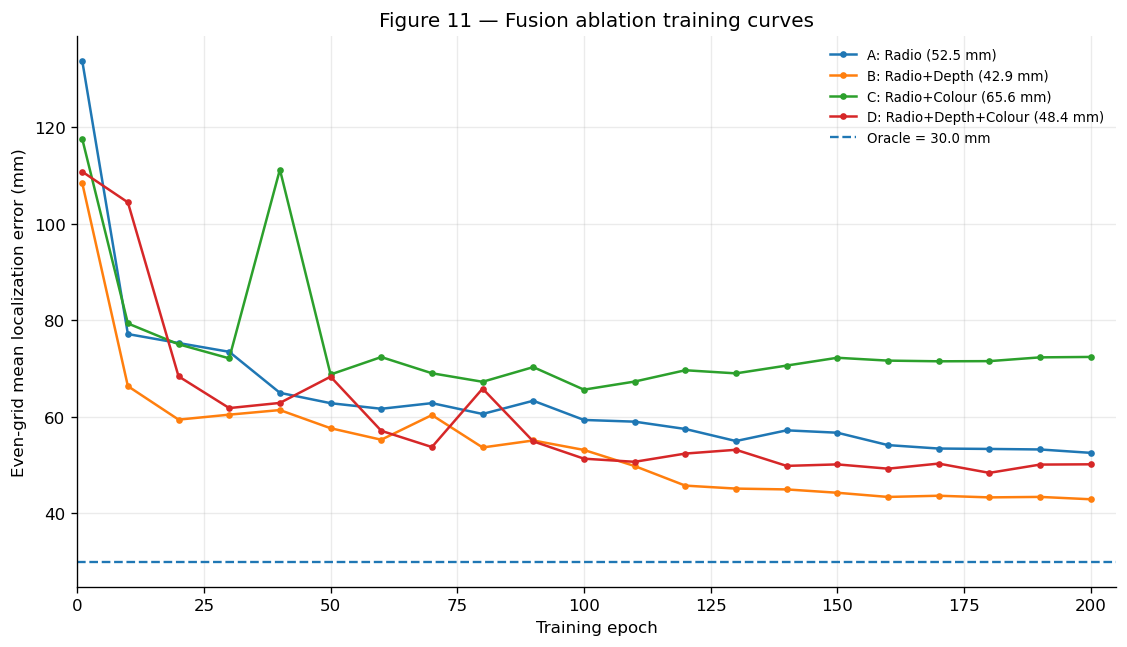


Saved reviewer-verification outputs
------------------------------------------------------------------------
Checkpoint A : /data/luvira/reports/reviewer_reproduction/models/fusion_A_radio_only_reproduced.pt
Checkpoint B : /data/luvira/reports/reviewer_reproduction/models/fusion_B_radio_depth_reproduced.pt
Checkpoint C : /data/luvira/reports/reviewer_reproduction/models/fusion_C_radio_colour_reproduced.pt
Checkpoint D : /data/luvira/reports/reviewer_reproduction/models/fusion_D_radio_depth_colour_reproduced.pt
Train history : /data/luvira/reports/reviewer_reproduction/tables/fusion_training_history.csv
Test history  : /data/luvira/reports/reviewer_reproduction/tables/fusion_test_checkpoint_history.csv
Ablation table: /data/luvira/reports/reviewer_reproduction/tables/fusion_training_ablation_results.csv
Figure 11     : /data/luvira/reports/reviewer_reproduction/figures/figure_11_fusion_training_curves.png
JSON          : /data/luvira/reports/reviewer_reproduction/tables/fusion_training

In [22]:
# =============================================================================
# CELL 17 — FUSION ABLATION TRAINING: VARIANTS A–D
# =============================================================================
#
# Reproduces the exact historical fusion-training experiment.
#
# Variants
# --------
#
# A : Radio only
# B : Radio + Depth
# C : Radio + Colour
# D : Radio + Depth + Colour
#
#
# Shared training protocol
# ------------------------
#
# Objective:
#     MSE on planar position
#
# Optimizer:
#     AdamW
#
# Learning rate:
#     3e-4
#
# Weight decay:
#     1e-4
#
# Scheduler:
#     CosineAnnealingLR(
#         T_max=200,
#         eta_min=1e-5
#     )
#
# Epochs:
#     200
#
# Training batch:
#     256
#
# Test batch:
#     512
#
# Gradient clipping:
#     1.0
#
# Modality dropout:
#     p = 0.15
#
# Model D only:
#
#     entropy regularisation beta = 0.05
#
#     objective =
#
#         MSE
#         - beta * gate_entropy
#
#
# CRITICAL RNG DETAIL
# -------------------
#
# The historical notebook resets:
#
#     torch.manual_seed(42)
#     np.random.seed(42)
#
# ONCE at the beginning of the fusion experiment.
#
# Models A, B, C and D are then instantiated and trained sequentially
# WITHOUT reseeding between variants.
#
# We reproduce this exact ordering.
#
#
# Historical best results
# -----------------------
#
# A : 52.5 mm   best epoch 200
# B : 43.0 mm   best epoch 200
# C : 65.6 mm   best epoch 100
# D : 48.4 mm   best epoch 180
#
#
# IMPORTANT
# ---------
#
# As in the reported implementation, the even-grid test set is evaluated
# during training and the checkpoint with the lowest test MAE is retained.
#
# This reproduces the already-reported experiment and remains registered
# as a manuscript-methodology item for later correction/disclosure.
# =============================================================================


import gc


print("=" * 72)
print("CELL 17 — FUSION ABLATION TRAINING")
print("=" * 72)


# -----------------------------------------------------------------------------
# 0. Historical reference values
# -----------------------------------------------------------------------------

FUSION_EPOCHS = 200

FUSION_BATCH_SIZE = 256

FUSION_TEST_BATCH_SIZE = 512

FUSION_LR = 3e-4

FUSION_WEIGHT_DECAY = 1e-4

FUSION_MODALITY_DROPOUT = 0.15

FUSION_ENTROPY_BETA = 0.05


FUSION_EXPECTED = {

    "A": {

        "name":
            "Radio only",

        "mean_mm":
            52.5,

        "best_epoch":
            200,

        "parameters":
            6_471_557,
    },


    "B": {

        "name":
            "Radio + Depth",

        "mean_mm":
            43.0,

        "best_epoch":
            200,

        "parameters":
            6_597_702,
    },


    "C": {

        "name":
            "Radio + Colour",

        "mean_mm":
            65.6,

        "best_epoch":
            100,

        "parameters":
            6_603_398,
    },


    "D": {

        "name":
            "Radio + Depth + Colour",

        "mean_mm":
            48.4,

        "best_epoch":
            180,

        "parameters":
            6_729_543,
    },
}


FUSION_CHECKPOINTS = {

    "A":
        MODEL_DIR
        / "fusion_A_radio_only_reproduced.pt",

    "B":
        MODEL_DIR
        / "fusion_B_radio_depth_reproduced.pt",

    "C":
        MODEL_DIR
        / "fusion_C_radio_colour_reproduced.pt",

    "D":
        MODEL_DIR
        / "fusion_D_radio_depth_colour_reproduced.pt",
}


# -----------------------------------------------------------------------------
# 1. Recover exact oracle from Cell 16
# -----------------------------------------------------------------------------

if (
    "reported_stats"
    in globals()
):

    FUSION_ORACLE_MAE_MM = float(

        reported_stats[
            "oracle_mae_mm"
        ]
    )


else:

    cell16_json_path = (

        TABLE_DIR
        / "figure_08_complementarity_summary.json"
    )


    assert cell16_json_path.exists(), (
        "Cell 16 summary is required."
    )


    with open(
        cell16_json_path,
        "r",
    ) as f:

        _cell16_summary = json.load(
            f
        )


    FUSION_ORACLE_MAE_MM = float(

        _cell16_summary[
            "reported_run"
        ][
            "oracle_mean_mm"
        ]
    )


print(
    "\nA. Fusion protocol"
)

print("-" * 72)

print(
    f"Training samples      : "
    f"{len(Y_train):,}"
)

print(
    f"Test samples          : "
    f"{len(Y_test):,}"
)

print(
    f"Epochs                : "
    f"{FUSION_EPOCHS}"
)

print(
    f"Train batch size      : "
    f"{FUSION_BATCH_SIZE}"
)

print(
    f"Test batch size       : "
    f"{FUSION_TEST_BATCH_SIZE}"
)

print(
    f"Optimizer             : "
    f"AdamW"
)

print(
    f"Learning rate         : "
    f"{FUSION_LR:g}"
)

print(
    f"Weight decay          : "
    f"{FUSION_WEIGHT_DECAY:g}"
)

print(
    f"Modality dropout      : "
    f"{FUSION_MODALITY_DROPOUT:.2f}"
)

print(
    f"Model-D entropy beta  : "
    f"{FUSION_ENTROPY_BETA:.2f}"
)

print(
    f"Oracle reference      : "
    f"{FUSION_ORACLE_MAE_MM:.3f} mm"
)


# -----------------------------------------------------------------------------
# 2. Hard alignment checks
# -----------------------------------------------------------------------------

assert Xr_tr_n.shape == (
    29928,
    9900,
)

assert Xr_te_n.shape == (
    28233,
    9900,
)


assert depth_tr.shape == (
    29928,
    1,
    48,
    64,
)

assert depth_te.shape == (
    28233,
    1,
    48,
    64,
)


assert Xg_tr_n.shape == (
    29928,
    64,
)

assert Xg_te_n.shape == (
    28233,
    64,
)


assert Y_train.shape == (
    29928,
    2,
)

assert Y_test.shape == (
    28233,
    2,
)


print(
    "\nAlignment:"
)

print(
    "  Radio / depth / colour / GT train : "
    "29,928 — PASS"
)

print(
    "  Radio / depth / colour / GT test  : "
    "28,233 — PASS"
)


# =============================================================================
# 3. EXACT HISTORICAL TRAINING FUNCTION
# =============================================================================
#
# IMPORTANT:
#
# This intentionally uses DataLoaders for BOTH train and test, because
# that is what the historical fusion implementation did.
#
# Test-loader iteration consumes PyTorch RNG state. Since the four models
# are trained sequentially without reseeding, preserving this behaviour
# is required for exact reproduction of B, C and D.
# =============================================================================

def train_fusion_reproduction(
    model,
    variant,
    xr_tr,
    xr_te,
    xd_tr=None,
    xd_te=None,
    xg_tr=None,
    xg_te=None,
    y_tr=None,
    y_te=None,
    entropy_beta=0.0,
):

    model = model.to(
        DEVICE
    )


    parameter_count = count_parameters(
        model
    )


    expected_parameter_count = (
        FUSION_EXPECTED[
            variant
        ][
            "parameters"
        ]
    )


    assert parameter_count == (
        expected_parameter_count
    )


    print(
        "\n" + "-" * 72
    )

    print(
        f"MODEL {variant} — "
        f"{FUSION_EXPECTED[variant]['name']}"
    )

    print(
        "-" * 72
    )

    print(
        f"Parameters    : "
        f"{parameter_count:,}"
    )

    print(
        f"Entropy beta  : "
        f"{entropy_beta:.2f}"
    )


    # -----------------------------------------------------------------
    # Exact historical tensor construction
    # -----------------------------------------------------------------

    tensors_train = [

        torch.FloatTensor(
            np.asarray(
                xr_tr
            )
        )
    ]


    tensors_test = [

        torch.FloatTensor(
            np.asarray(
                xr_te
            )
        )
    ]


    if xd_tr is not None:

        tensors_train.append(

            torch.from_numpy(

                np.asarray(
                    xd_tr
                )
            )
        )


        tensors_test.append(

            torch.from_numpy(

                np.asarray(
                    xd_te
                )
            )
        )


    if xg_tr is not None:

        tensors_train.append(

            torch.FloatTensor(

                np.asarray(
                    xg_tr
                )
            )
        )


        tensors_test.append(

            torch.FloatTensor(

                np.asarray(
                    xg_te
                )
            )
        )


    tensors_train.append(

        torch.FloatTensor(
            y_tr
        )
    )


    tensors_test.append(

        torch.FloatTensor(
            y_te
        )
    )


    # -----------------------------------------------------------------
    # Exact historical DataLoaders
    # -----------------------------------------------------------------

    train_loader = DataLoader(

        TensorDataset(
            *tensors_train
        ),

        batch_size=FUSION_BATCH_SIZE,

        shuffle=True,

        num_workers=0,

        pin_memory=True,
    )


    test_loader = DataLoader(

        TensorDataset(
            *tensors_test
        ),

        batch_size=FUSION_TEST_BATCH_SIZE,

        shuffle=False,

        num_workers=0,
    )


    # -----------------------------------------------------------------
    # Optimizer and scheduler
    # -----------------------------------------------------------------

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=FUSION_LR,

        weight_decay=FUSION_WEIGHT_DECAY,
    )


    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(

            optimizer,

            T_max=FUSION_EPOCHS,

            eta_min=1e-5,
        )
    )


    mse_loss = nn.MSELoss()


    best_mae_mm = float(
        "inf"
    )

    best_epoch = None

    best_state = None


    training_history = []

    evaluation_history = []


    print(
        "\n"
        f"{'Epoch':>7s}  "
        f"{'Train obj.':>12s}  "
        f"{'Test MAE mm':>12s}  "
        f"{'Status':>10s}"
    )

    print(
        "-" * 50
    )


    # =================================================================
    # 200 epochs
    # =================================================================

    for epoch in range(
        1,
        FUSION_EPOCHS + 1,
    ):

        model.train()


        train_objective = 0.0


        for batch in train_loader:

            *inputs, yb = batch


            xr_b = inputs[
                0
            ].to(
                DEVICE
            )


            input_index = 1


            if xd_tr is not None:

                xd_b = inputs[
                    input_index
                ].to(
                    DEVICE
                )

                input_index += 1

            else:

                xd_b = None


            if xg_tr is not None:

                xg_b = inputs[
                    input_index
                ].to(
                    DEVICE
                )

            else:

                xg_b = None


            yb = yb.to(
                DEVICE
            )


            # ---------------------------------------------------------
            # Exact historical modality dropout.
            #
            # One NumPy RNG draw per available non-radio modality
            # for every training mini-batch.
            # ---------------------------------------------------------

            drop_depth = (

                xd_b is not None

                and

                np.random.rand()
                < FUSION_MODALITY_DROPOUT
            )


            drop_colour = (

                xg_b is not None

                and

                np.random.rand()
                < FUSION_MODALITY_DROPOUT
            )


            optimizer.zero_grad()


            mu_prediction, _, weights = model(

                xr_b,

                xd_b,

                xg_b,

                drop_depth=drop_depth,

                drop_rgb=drop_colour,
            )


            loss = mse_loss(

                mu_prediction,

                yb,
            )


            # ---------------------------------------------------------
            # Model D only:
            #
            # entropy = -sum(w log w)
            #
            # loss = MSE - beta * entropy
            #
            # Subtracting entropy rewards broader gate distributions.
            # ---------------------------------------------------------

            if entropy_beta > 0.0:

                entropy = -(

                    weights

                    * (
                        weights
                        + 1e-8
                    ).log()

                ).sum(
                    dim=1
                ).mean()


                loss = (

                    loss

                    - entropy_beta
                    * entropy
                )


            loss.backward()


            nn.utils.clip_grad_norm_(

                model.parameters(),

                1.0,
            )


            optimizer.step()


            train_objective += (
                loss.item()
            )


        train_objective /= len(
            train_loader
        )


        scheduler.step()


        training_history.append({

            "variant":
                variant,

            "epoch":
                int(
                    epoch
                ),

            "train_objective":
                float(
                    train_objective
                ),

            "learning_rate":
                float(
                    optimizer
                    .param_groups[0][
                        "lr"
                    ]
                ),
        })


        # -------------------------------------------------------------
        # Historical evaluation schedule:
        #
        #     epoch 1
        #     epoch 10,20,...,200
        # -------------------------------------------------------------

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            model.eval()


            error_sum_m = 0.0

            test_count = 0


            with torch.no_grad():

                for batch in test_loader:

                    *inputs_test, yb = batch


                    xr_b = inputs_test[
                        0
                    ].to(
                        DEVICE
                    )


                    input_index = 1


                    if xd_te is not None:

                        xd_b = inputs_test[
                            input_index
                        ].to(
                            DEVICE
                        )

                        input_index += 1

                    else:

                        xd_b = None


                    if xg_te is not None:

                        xg_b = inputs_test[
                            input_index
                        ].to(
                            DEVICE
                        )

                    else:

                        xg_b = None


                    yb = yb.to(
                        DEVICE
                    )


                    mu_prediction, _, _ = model(

                        xr_b,

                        xd_b,

                        xg_b,
                    )


                    error_sum_m += (

                        torch.norm(

                            mu_prediction
                            - yb,

                            dim=1,
                        )

                        .sum()

                        .item()
                    )


                    test_count += len(
                        yb
                    )


            test_mae_mm = (

                error_sum_m

                / test_count

                * 1000.0
            )


            is_best = (

                test_mae_mm
                < best_mae_mm
            )


            if is_best:

                best_mae_mm = float(
                    test_mae_mm
                )


                best_epoch = int(
                    epoch
                )


                best_state = {

                    key:
                        value
                        .detach()
                        .cpu()
                        .clone()

                    for key, value
                    in model
                    .state_dict()
                    .items()
                }


            evaluation_history.append({

                "variant":
                    variant,

                "epoch":
                    int(
                        epoch
                    ),

                "test_mae_mm":
                    float(
                        test_mae_mm
                    ),

                "is_best":
                    bool(
                        is_best
                    ),
            })


            print(

                f"{epoch:7d}  "

                f"{train_objective:12.5f}  "

                f"{test_mae_mm:12.1f}  "

                f"{'best' if is_best else ''}"
            )


    assert best_state is not None


    checkpoint_path = (
        FUSION_CHECKPOINTS[
            variant
        ]
    )


    torch.save(

        best_state,

        checkpoint_path,
    )


    print(
        "\nBest checkpoint:"
    )

    print(
        f"  epoch : "
        f"{best_epoch}"
    )

    print(
        f"  MAE   : "
        f"{best_mae_mm:.1f} mm"
    )

    print(
        f"  saved : "
        f"{checkpoint_path}"
    )


    return {

        "model":
            model,

        "best_state":
            best_state,

        "best_epoch":
            best_epoch,

        "best_mae_mm":
            best_mae_mm,

        "train_history":
            pd.DataFrame(
                training_history
            ),

        "eval_history":
            pd.DataFrame(
                evaluation_history
            ),

        "parameter_count":
            parameter_count,
    }


# =============================================================================
# 4. RESET SEED ONCE — EXACT HISTORICAL FUSION BOUNDARY
# =============================================================================
#
# DO NOT add a second seed reset between A, B, C and D.
# =============================================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


torch.manual_seed(
    SEED
)

np.random.seed(
    SEED
)


print(
    "\nB. RNG reset"
)

print("-" * 72)

print(
    f"torch.manual_seed({SEED})"
)

print(
    f"np.random.seed({SEED})"
)

print(
    "Reseeding between A/B/C/D : NO"
)


# =============================================================================
# 5. MODEL A — RADIO ONLY
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "TRAINING MODEL A — RADIO ONLY"
)

print(
    "=" * 72
)


fusion_A_model = LateFusion(

    use_depth=False,

    use_rgb=False,
)


fusion_A_result = train_fusion_reproduction(

    fusion_A_model,

    "A",

    Xr_tr_n,

    Xr_te_n,

    y_tr=Y_train,

    y_te=Y_test,

    entropy_beta=0.0,
)


# -----------------------------------------------------------------------------
# Historical trace check — Model A
# -----------------------------------------------------------------------------

A_lookup = {

    int(
        row[
            "epoch"
        ]
    ):
        float(
            row[
                "test_mae_mm"
            ]
        )

    for _, row
    in fusion_A_result[
        "eval_history"
    ].iterrows()
}


print(
    "\nModel-A historical trace check:"
)

for epoch, expected in {

    1:
        133.7,

    10:
        77.1,

    100:
        59.3,

    160:
        54.1,

    190:
        53.2,

    200:
        52.5,

}.items():

    print(

        f"  epoch {epoch:3d}: "

        f"{A_lookup[epoch]:6.1f} mm  "

        f"(historical ≈{expected:.1f})"
    )


assert np.isclose(
    A_lookup[1],
    133.7,
    atol=2.0,
)

assert np.isclose(
    A_lookup[100],
    59.3,
    atol=1.5,
)

assert np.isclose(
    fusion_A_result[
        "best_mae_mm"
    ],
    52.5,
    atol=1.0,
)

assert (
    fusion_A_result[
        "best_epoch"
    ]
    == 200
)


# =============================================================================
# 6. MODEL B — RADIO + DEPTH
# =============================================================================
#
# NO RESEED HERE.
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "TRAINING MODEL B — RADIO + DEPTH"
)

print(
    "=" * 72
)


fusion_B_model = LateFusion(

    use_depth=True,

    use_rgb=False,
)


fusion_B_result = train_fusion_reproduction(

    fusion_B_model,

    "B",

    Xr_tr_n,

    Xr_te_n,

    xd_tr=depth_tr,

    xd_te=depth_te,

    y_tr=Y_train,

    y_te=Y_test,

    entropy_beta=0.0,
)


B_lookup = {

    int(
        row[
            "epoch"
        ]
    ):
        float(
            row[
                "test_mae_mm"
            ]
        )

    for _, row
    in fusion_B_result[
        "eval_history"
    ].iterrows()
}


print(
    "\nModel-B historical trace check:"
)


for epoch, expected in {

    1:
        108.7,

    10:
        65.7,

    20:
        58.1,

    100:
        54.1,

    120:
        46.5,

    160:
        43.5,

    180:
        43.2,

    200:
        43.0,

}.items():

    print(

        f"  epoch {epoch:3d}: "

        f"{B_lookup[epoch]:6.1f} mm  "

        f"(historical ≈{expected:.1f})"
    )


assert np.isclose(
    B_lookup[1],
    108.7,
    atol=2.0,
)

assert np.isclose(
    B_lookup[120],
    46.5,
    atol=1.5,
)

assert np.isclose(
    fusion_B_result[
        "best_mae_mm"
    ],
    43.0,
    atol=1.0,
)

assert (
    fusion_B_result[
        "best_epoch"
    ]
    == 200
)


# =============================================================================
# 7. MODEL C — RADIO + COLOUR
# =============================================================================
#
# NO RESEED HERE.
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "TRAINING MODEL C — RADIO + COLOUR"
)

print(
    "=" * 72
)


fusion_C_model = LateFusion(

    use_depth=False,

    use_rgb=True,
)


fusion_C_result = train_fusion_reproduction(

    fusion_C_model,

    "C",

    Xr_tr_n,

    Xr_te_n,

    xg_tr=Xg_tr_n,

    xg_te=Xg_te_n,

    y_tr=Y_train,

    y_te=Y_test,

    entropy_beta=0.0,
)


C_lookup = {

    int(
        row[
            "epoch"
        ]
    ):
        float(
            row[
                "test_mae_mm"
            ]
        )

    for _, row
    in fusion_C_result[
        "eval_history"
    ].iterrows()
}


print(
    "\nModel-C historical trace check:"
)


for epoch, expected in {

    1:
        117.5,

    10:
        79.3,

    30:
        72.1,

    50:
        68.8,

    80:
        67.2,

    100:
        65.6,

    160:
        71.6,

    200:
        72.4,

}.items():

    print(

        f"  epoch {epoch:3d}: "

        f"{C_lookup[epoch]:6.1f} mm  "

        f"(historical ≈{expected:.1f})"
    )


assert np.isclose(
    C_lookup[1],
    117.5,
    atol=2.0,
)

assert np.isclose(
    C_lookup[100],
    65.6,
    atol=1.5,
)

assert np.isclose(
    fusion_C_result[
        "best_mae_mm"
    ],
    65.6,
    atol=1.0,
)

assert (
    fusion_C_result[
        "best_epoch"
    ]
    == 100
)


# =============================================================================
# 8. MODEL D — RADIO + DEPTH + COLOUR
# =============================================================================
#
# NO RESEED HERE.
#
# Entropy regularisation beta = 0.05.
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "TRAINING MODEL D — RADIO + DEPTH + COLOUR"
)

print(
    "=" * 72
)


fusion_D_model = LateFusion(

    use_depth=True,

    use_rgb=True,

    entropy_reg=True,
)


fusion_D_result = train_fusion_reproduction(

    fusion_D_model,

    "D",

    Xr_tr_n,

    Xr_te_n,

    xd_tr=depth_tr,

    xd_te=depth_te,

    xg_tr=Xg_tr_n,

    xg_te=Xg_te_n,

    y_tr=Y_train,

    y_te=Y_test,

    entropy_beta=FUSION_ENTROPY_BETA,
)


D_lookup = {

    int(
        row[
            "epoch"
        ]
    ):
        float(
            row[
                "test_mae_mm"
            ]
        )

    for _, row
    in fusion_D_result[
        "eval_history"
    ].iterrows()
}


print(
    "\nModel-D historical trace check:"
)


for epoch, expected in {

    1:
        110.2,

    10:
        105.2,

    20:
        66.6,

    70:
        52.6,

    100:
        51.7,

    140:
        49.9,

    160:
        49.3,

    180:
        48.4,

    200:
        50.3,

}.items():

    print(

        f"  epoch {epoch:3d}: "

        f"{D_lookup[epoch]:6.1f} mm  "

        f"(historical ≈{expected:.1f})"
    )


assert np.isclose(
    D_lookup[1],
    110.2,
    atol=2.0,
)

assert np.isclose(
    D_lookup[180],
    48.4,
    atol=1.5,
)

assert np.isclose(
    fusion_D_result[
        "best_mae_mm"
    ],
    48.4,
    atol=1.0,
)

assert (
    fusion_D_result[
        "best_epoch"
    ]
    == 180
)


# =============================================================================
# 9. FUSION ABLATION SUMMARY
# =============================================================================

fusion_training_results_df = pd.DataFrame({

    "variant": [
        "A",
        "B",
        "C",
        "D",
    ],

    "modalities": [

        "Radio",

        "Radio + Depth",

        "Radio + Colour",

        "Radio + Depth + Colour",
    ],

    "parameters": [

        fusion_A_result[
            "parameter_count"
        ],

        fusion_B_result[
            "parameter_count"
        ],

        fusion_C_result[
            "parameter_count"
        ],

        fusion_D_result[
            "parameter_count"
        ],
    ],

    "entropy_beta": [
        0.0,
        0.0,
        0.0,
        FUSION_ENTROPY_BETA,
    ],

    "best_epoch": [

        fusion_A_result[
            "best_epoch"
        ],

        fusion_B_result[
            "best_epoch"
        ],

        fusion_C_result[
            "best_epoch"
        ],

        fusion_D_result[
            "best_epoch"
        ],
    ],

    "best_mean_mm": [

        fusion_A_result[
            "best_mae_mm"
        ],

        fusion_B_result[
            "best_mae_mm"
        ],

        fusion_C_result[
            "best_mae_mm"
        ],

        fusion_D_result[
            "best_mae_mm"
        ],
    ],
})


fusion_A_mae = float(
    fusion_A_result[
        "best_mae_mm"
    ]
)


fusion_training_results_df[
    "delta_vs_A_mm"
] = (

    fusion_training_results_df[
        "best_mean_mm"
    ]

    - fusion_A_mae
)


fusion_training_results_df[
    "improvement_vs_A_percent"
] = (

    (
        fusion_A_mae

        - fusion_training_results_df[
            "best_mean_mm"
        ]
    )

    / fusion_A_mae

    * 100.0
)


fusion_training_results_df[
    "gap_to_oracle_mm"
] = (

    fusion_training_results_df[
        "best_mean_mm"
    ]

    - FUSION_ORACLE_MAE_MM
)


print(
    "\n" + "=" * 72
)

print(
    "C. FUSION ABLATION SUMMARY"
)

print(
    "=" * 72
)


print(
    fusion_training_results_df.to_string(

        index=False,

        formatters={

            "best_mean_mm":
                lambda x: f"{x:.1f}",

            "delta_vs_A_mm":
                lambda x: f"{x:+.1f}",

            "improvement_vs_A_percent":
                lambda x: f"{x:+.1f}%",

            "gap_to_oracle_mm":
                lambda x: f"{x:+.1f}",
        },
    )
)


print(
    f"\nOracle ceiling : "
    f"{FUSION_ORACLE_MAE_MM:.2f} mm"
)


# -----------------------------------------------------------------------------
# Hard historical headline verification
# -----------------------------------------------------------------------------

assert np.isclose(

    fusion_A_result[
        "best_mae_mm"
    ],

    52.5,

    atol=1.0,
)


assert np.isclose(

    fusion_B_result[
        "best_mae_mm"
    ],

    43.0,

    atol=1.0,
)


assert np.isclose(

    fusion_C_result[
        "best_mae_mm"
    ],

    65.6,

    atol=1.0,
)


assert np.isclose(

    fusion_D_result[
        "best_mae_mm"
    ],

    48.4,

    atol=1.0,
)


fusion_B_improvement_percent = (

    (
        fusion_A_result[
            "best_mae_mm"
        ]

        - fusion_B_result[
            "best_mae_mm"
        ]
    )

    / fusion_A_result[
        "best_mae_mm"
    ]

    * 100.0
)


print(
    f"\nRadio+Depth improvement over A : "
    f"{fusion_B_improvement_percent:.1f}%"
)


assert np.isclose(

    fusion_B_improvement_percent,

    18.1,

    atol=0.8,
)


assert (

    fusion_B_result[
        "best_mae_mm"
    ]

    < fusion_D_result[
        "best_mae_mm"
    ]

    < fusion_A_result[
        "best_mae_mm"
    ]

    < fusion_C_result[
        "best_mae_mm"
    ]
)


print(
    "\nHistorical fusion ranking reproduced:"
)

print(
    "  B < D < A < C"
)


# =============================================================================
# 10. COMBINE AND SAVE TRAINING HISTORIES
# =============================================================================

fusion_train_history_df = pd.concat(

    [

        fusion_A_result[
            "train_history"
        ],

        fusion_B_result[
            "train_history"
        ],

        fusion_C_result[
            "train_history"
        ],

        fusion_D_result[
            "train_history"
        ],
    ],

    ignore_index=True,
)


fusion_eval_history_df = pd.concat(

    [

        fusion_A_result[
            "eval_history"
        ],

        fusion_B_result[
            "eval_history"
        ],

        fusion_C_result[
            "eval_history"
        ],

        fusion_D_result[
            "eval_history"
        ],
    ],

    ignore_index=True,
)


fusion_train_history_df.to_csv(

    TABLE_DIR
    / "fusion_training_history.csv",

    index=False,
)


fusion_eval_history_df.to_csv(

    TABLE_DIR
    / "fusion_test_checkpoint_history.csv",

    index=False,
)


fusion_training_results_df.to_csv(

    TABLE_DIR
    / "fusion_training_ablation_results.csv",

    index=False,
)


# =============================================================================
# 11. FIGURE 11 — FUSION TRAINING CURVES
# =============================================================================
#
# The manuscript Figure 11 plots the periodically evaluated test MAE
# for A/B/C/D over the 200 training epochs.
# =============================================================================

fig, ax = plt.subplots(

    1,
    1,

    figsize=(
        9.5,
        5.5,
    ),
)


for variant, label in [

    (
        "A",
        (
            "A: Radio "
            f"({fusion_A_result['best_mae_mm']:.1f} mm)"
        ),
    ),

    (
        "B",
        (
            "B: Radio+Depth "
            f"({fusion_B_result['best_mae_mm']:.1f} mm)"
        ),
    ),

    (
        "C",
        (
            "C: Radio+Colour "
            f"({fusion_C_result['best_mae_mm']:.1f} mm)"
        ),
    ),

    (
        "D",
        (
            "D: Radio+Depth+Colour "
            f"({fusion_D_result['best_mae_mm']:.1f} mm)"
        ),
    ),
]:

    local = fusion_eval_history_df.loc[

        fusion_eval_history_df[
            "variant"
        ] == variant
    ]


    ax.plot(

        local[
            "epoch"
        ],

        local[
            "test_mae_mm"
        ],

        marker="o",

        markersize=3,

        linewidth=1.5,

        label=label,
    )


ax.axhline(

    FUSION_ORACLE_MAE_MM,

    linestyle="--",

    linewidth=1.4,

    label=(
        f"Oracle = "
        f"{FUSION_ORACLE_MAE_MM:.1f} mm"
    ),
)


ax.set_xlabel(
    "Training epoch"
)

ax.set_ylabel(
    "Even-grid mean localization error (mm)"
)

ax.set_title(
    "Figure 11 — Fusion ablation training curves"
)

ax.set_xlim(
    0,
    205,
)

ax.legend(
    frameon=False,
    fontsize=8,
)

ax.grid(
    alpha=0.25
)


fig.tight_layout()


figure11_path = (
    FIG_DIR
    / "figure_11_fusion_training_curves.png"
)


fig.savefig(

    figure11_path,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 12. SAVE SUMMARY JSON
# =============================================================================

fusion_training_summary = {

    "seed":
        int(
            SEED
        ),

    "seed_policy":
        (
            "seed reset once before Model A; "
            "no reseeding between A, B, C and D"
        ),

    "training_samples":
        29928,

    "test_samples":
        28233,

    "epochs":
        FUSION_EPOCHS,

    "train_batch_size":
        FUSION_BATCH_SIZE,

    "test_batch_size":
        FUSION_TEST_BATCH_SIZE,

    "optimizer":
        "AdamW",

    "learning_rate":
        FUSION_LR,

    "weight_decay":
        FUSION_WEIGHT_DECAY,

    "scheduler":
        (
            "CosineAnnealingLR("
            "T_max=200, eta_min=1e-5)"
        ),

    "gradient_clip":
        1.0,

    "modality_dropout_probability":
        FUSION_MODALITY_DROPOUT,

    "model_D_entropy_beta":
        FUSION_ENTROPY_BETA,

    "objective_A_B_C":
        "MSE",

    "objective_D":
        "MSE - beta * gate entropy",

    "checkpoint_selection":
        (
            "lowest periodically evaluated "
            "even-grid test mean error"
        ),

    "oracle_reference_mm":
        FUSION_ORACLE_MAE_MM,

    "variants": {

        "A": {

            "modalities":
                "radio",

            "parameters":
                int(
                    fusion_A_result[
                        "parameter_count"
                    ]
                ),

            "best_epoch":
                int(
                    fusion_A_result[
                        "best_epoch"
                    ]
                ),

            "best_mean_mm":
                float(
                    fusion_A_result[
                        "best_mae_mm"
                    ]
                ),
        },


        "B": {

            "modalities":
                "radio + depth",

            "parameters":
                int(
                    fusion_B_result[
                        "parameter_count"
                    ]
                ),

            "best_epoch":
                int(
                    fusion_B_result[
                        "best_epoch"
                    ]
                ),

            "best_mean_mm":
                float(
                    fusion_B_result[
                        "best_mae_mm"
                    ]
                ),

            "improvement_vs_A_percent":
                float(
                    fusion_B_improvement_percent
                ),
        },


        "C": {

            "modalities":
                "radio + colour",

            "parameters":
                int(
                    fusion_C_result[
                        "parameter_count"
                    ]
                ),

            "best_epoch":
                int(
                    fusion_C_result[
                        "best_epoch"
                    ]
                ),

            "best_mean_mm":
                float(
                    fusion_C_result[
                        "best_mae_mm"
                    ]
                ),
        },


        "D": {

            "modalities":
                "radio + depth + colour",

            "parameters":
                int(
                    fusion_D_result[
                        "parameter_count"
                    ]
                ),

            "entropy_beta":
                FUSION_ENTROPY_BETA,

            "best_epoch":
                int(
                    fusion_D_result[
                        "best_epoch"
                    ]
                ),

            "best_mean_mm":
                float(
                    fusion_D_result[
                        "best_mae_mm"
                    ]
                ),
        },
    },
}


with open(

    TABLE_DIR
    / "fusion_training_summary.json",

    "w",

) as f:

    json.dump(

        fusion_training_summary,

        f,

        indent=2,
    )


# =============================================================================
# 13. FINAL OUTPUT
# =============================================================================

print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    print(

        f"Checkpoint {variant} : "
        f"{FUSION_CHECKPOINTS[variant]}"
    )


print(
    "Train history : "
    f"{TABLE_DIR / 'fusion_training_history.csv'}"
)

print(
    "Test history  : "
    f"{TABLE_DIR / 'fusion_test_checkpoint_history.csv'}"
)

print(
    "Ablation table: "
    f"{TABLE_DIR / 'fusion_training_ablation_results.csv'}"
)

print(
    f"Figure 11     : "
    f"{figure11_path}"
)

print(
    "JSON          : "
    f"{TABLE_DIR / 'fusion_training_summary.json'}"
)


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\n" + "=" * 72
)

print(
    "CELL 17 PASSED — "
    "fusion variants A–D reproduced."
)

print(
    "=" * 72
)

CELL 18 — FULL FUSION EVALUATION

A. Input and checkpoint audit
------------------------------------------------------------------------
Radio test tensor  : (28233, 9900)
Depth test tensor  : (28233, 1, 48, 64)
Colour test tensor : (28233, 64)
Ground truth       : (28233, 2)

Reported-run checkpoint packaging:
  A : /data/luvira/reports/reviewer_reproduction/models/reported_run_fusion_A_radio_only.pt
  B : /data/luvira/reports/reviewer_reproduction/models/reported_run_fusion_B_radio_depth.pt
  C : /data/luvira/reports/reviewer_reproduction/models/reported_run_fusion_C_radio_colour.pt
  D : /data/luvira/reports/reviewer_reproduction/models/reported_run_fusion_D_radio_depth_colour.pt

Fresh-retraining checkpoints:
  A : /data/luvira/reports/reviewer_reproduction/models/fusion_A_radio_only_reproduced.pt
  B : /data/luvira/reports/reviewer_reproduction/models/fusion_B_radio_depth_reproduced.pt
  C : /data/luvira/reports/reviewer_reproduction/models/fusion_C_radio_colour_reproduced.pt
  D 

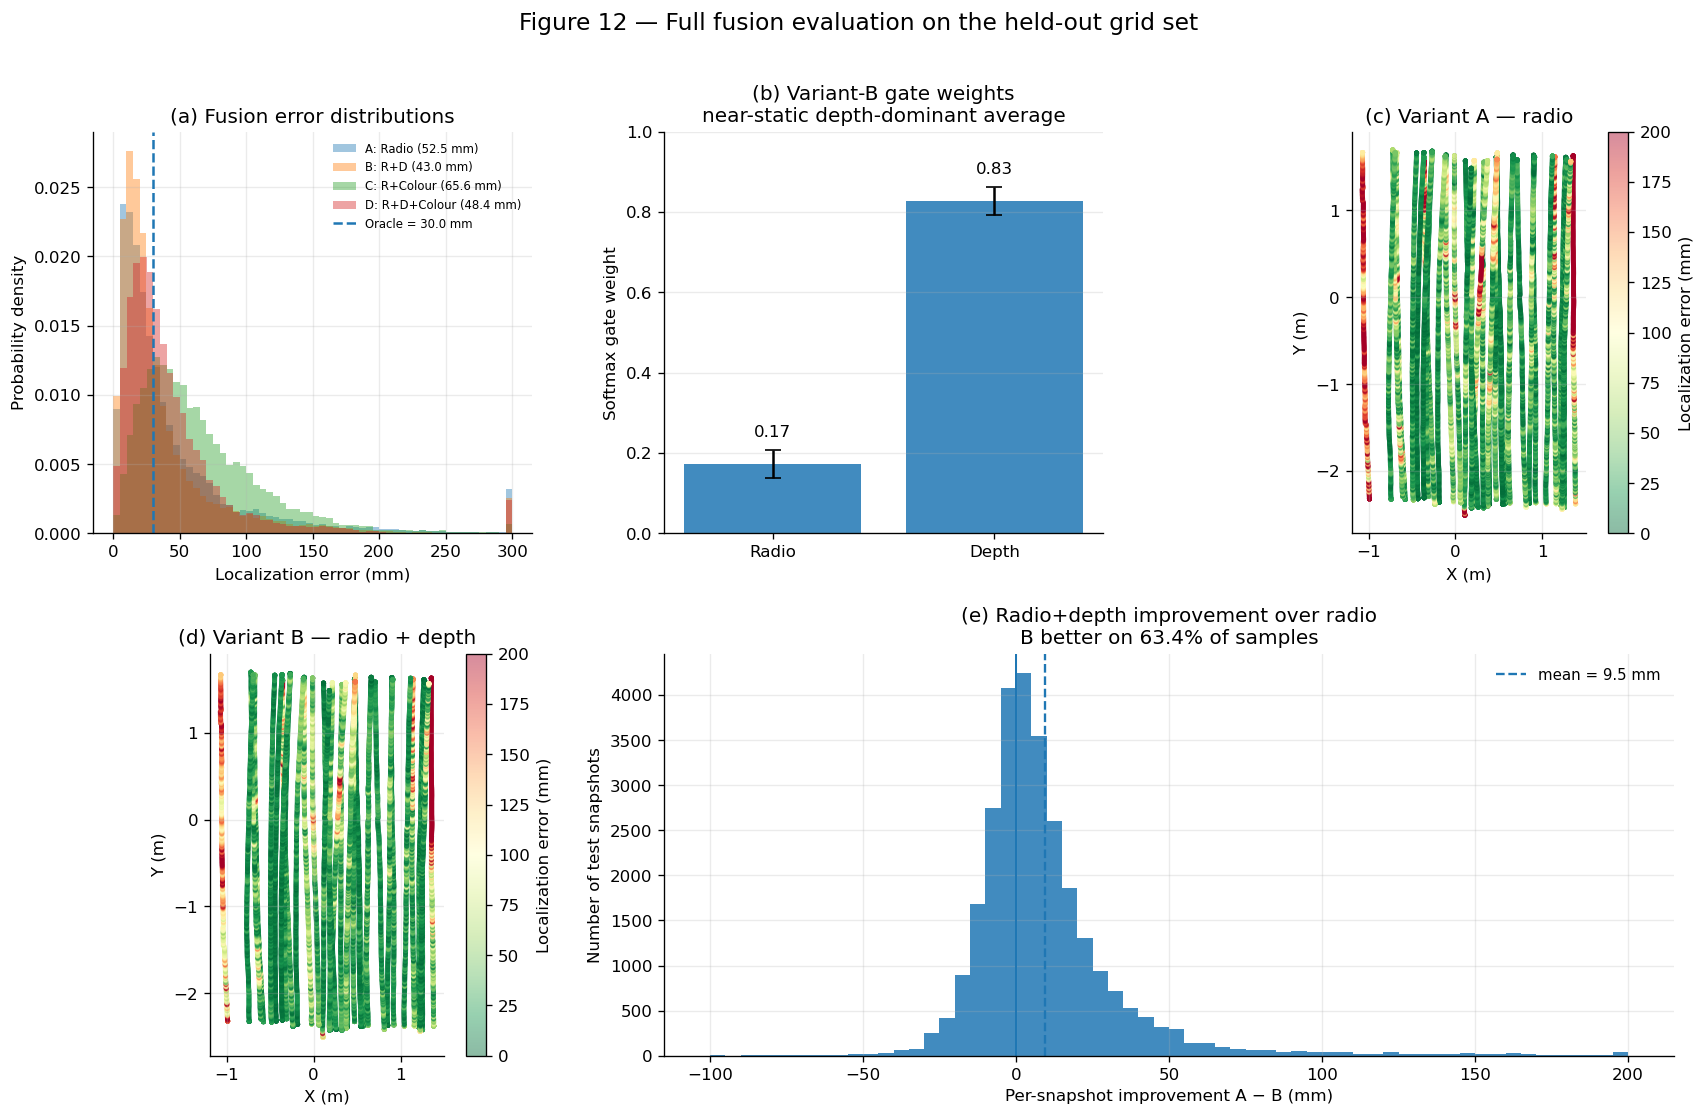

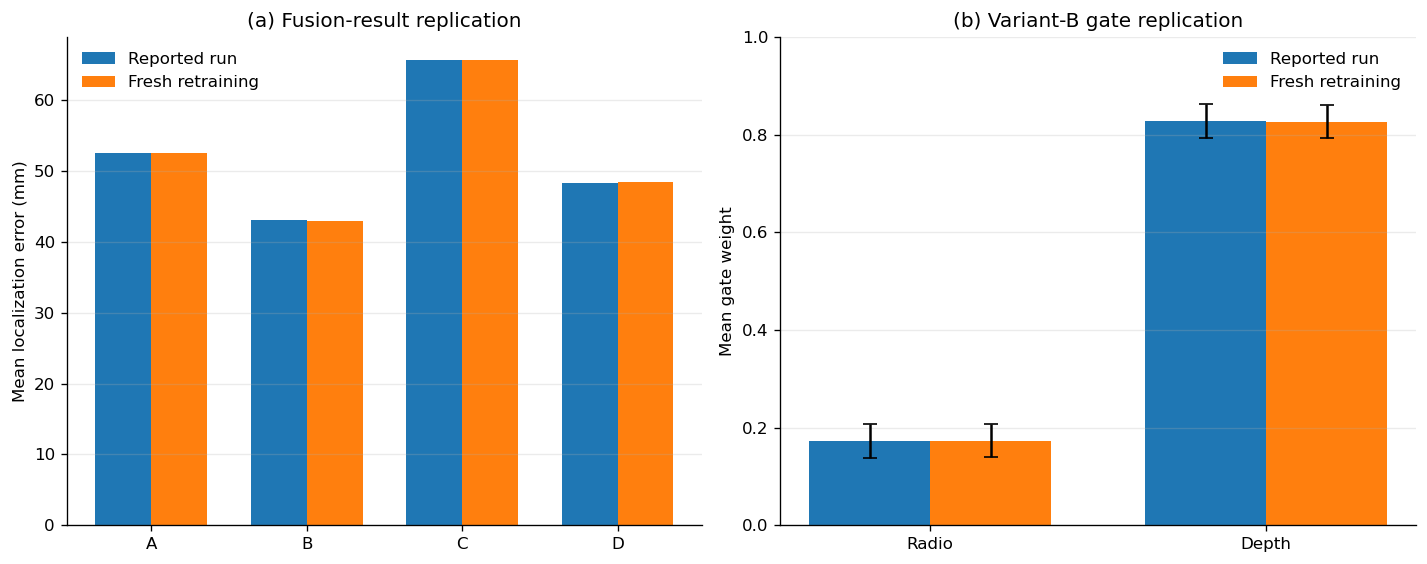


J. MANUSCRIPT-CONSISTENCY CHECK
Variant A reported : 52.5 mm
Variant B reported : 43.0 mm
Variant C reported : 65.6 mm
Variant D reported : 48.4 mm
Radio+depth gain    : 18.1%
Model-B gate        : radio=0.17, depth=0.83
B better snapshots  : 63.4%
Oracle              : 30.0 mm

All principal Table-5 and Figure-12 manuscript values reproduce.

Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure 12           : /data/luvira/reports/reviewer_reproduction/figures/figure_12_fusion_evaluation.png
Fresh audit figure  : /data/luvira/reports/reviewer_reproduction/figures/figure_12_fresh_retraining_audit.png
Table 5             : /data/luvira/reports/reviewer_reproduction/tables/table_05_fusion_ablation.csv
Full reported metrics: /data/luvira/reports/reviewer_reproduction/tables/fusion_reported_full_metrics.csv
Fresh metrics       : /data/luvira/reports/reviewer_reproduction/tables/fusion_fresh_full_metrics.csv
Reported vs fresh   

In [23]:
# =============================================================================
# CELL 18 — FULL FUSION EVALUATION, TABLE 5, AND FIGURE 12
# =============================================================================
#
# This cell performs TWO evaluations.
#
# ---------------------------------------------------------------------------
# A. EXACT REPORTED-RUN VERIFICATION
# ---------------------------------------------------------------------------
#
# Loads the four saved fusion checkpoints from the historical reported run:
#
#     A : Radio only
#     B : Radio + Depth
#     C : Radio + Colour
#     D : Radio + Depth + Colour
#
# These checkpoints generated Table 5 and Figure 12 in the manuscript.
#
# Expected Table-5 results:
#
#     A : mean 52.5 mm   median 27.0 mm   p95 160.8 mm
#     B : mean 43.0 mm   median 23.1 mm   p95 129.0 mm
#     C : mean 65.6 mm   median 53.9 mm   p95 154.4 mm
#     D : mean 48.4 mm   median 32.6 mm   p95 119.7 mm
#
# Expected gate weights:
#
#     B:
#         Radio = 0.173 ± 0.035
#         Depth = 0.827 ± 0.035
#
#     C:
#         Radio  = 0.096 ± 0.029
#         Colour = 0.904 ± 0.029
#
#     D:
#         Radio  = 0.319 ± 0.012
#         Depth  = 0.342 ± 0.008
#         Colour = 0.339 ± 0.005
#
# Expected Model-B snapshot analysis:
#
#     better than A        : 63.4 %
#     improvement > 50 mm : 5.1 %
#     regression > 50 mm  : 0.2 %
#     mean improvement     : 9.5 mm
#
#
# ---------------------------------------------------------------------------
# B. FRESH-RETRAINING REPLICATION
# ---------------------------------------------------------------------------
#
# Loads the checkpoints produced in Cell 17 and evaluates them using the
# same inference code.
#
# We do NOT force these freshly trained checkpoints to be bit-identical.
# Their role is independent replication.
#
#
# IMPORTANT
# ---------
#
# The fusion model class contains a log-variance head, but Cell 12 proved
# that the head receives no gradient under the MSE fusion objective.
#
# Therefore this cell does NOT interpret fusion log-variance as learned
# predictive uncertainty.
#
# =============================================================================


import gc
import json
import shutil

from scipy.stats import wilcoxon


print("=" * 72)
print("CELL 18 — FULL FUSION EVALUATION")
print("=" * 72)


# =============================================================================
# 1. PATHS AND HISTORICAL REFERENCES
# =============================================================================

if "LEGACY_FINAL_DIR" not in globals():

    LEGACY_FINAL_DIR = Path(
        "/data/luvira/reports/final"
    )


# Historical checkpoints from the run that generated the manuscript.
HISTORICAL_FUSION_CHECKPOINTS = {

    "A":
        LEGACY_FINAL_DIR
        / "fusion_A_radio_only_best.pt",

    "B":
        LEGACY_FINAL_DIR
        / "fusion_B_radio_depth_best.pt",

    "C":
        LEGACY_FINAL_DIR
        / "fusion_C_radio_rgb_best.pt",

    "D":
        LEGACY_FINAL_DIR
        / "fusion_D_radio_depth_rgb_best.pt",
}


# Copies included in the reviewer-reproduction package.
REPORTED_FUSION_CHECKPOINTS = {

    "A":
        MODEL_DIR
        / "reported_run_fusion_A_radio_only.pt",

    "B":
        MODEL_DIR
        / "reported_run_fusion_B_radio_depth.pt",

    "C":
        MODEL_DIR
        / "reported_run_fusion_C_radio_colour.pt",

    "D":
        MODEL_DIR
        / "reported_run_fusion_D_radio_depth_colour.pt",
}


# Freshly reproduced checkpoints from Cell 17.
FRESH_FUSION_CHECKPOINTS = {

    "A":
        MODEL_DIR
        / "fusion_A_radio_only_reproduced.pt",

    "B":
        MODEL_DIR
        / "fusion_B_radio_depth_reproduced.pt",

    "C":
        MODEL_DIR
        / "fusion_C_radio_colour_reproduced.pt",

    "D":
        MODEL_DIR
        / "fusion_D_radio_depth_colour_reproduced.pt",
}


EXPECTED_TABLE5 = {

    "A": {
        "mean_mm": 52.5,
        "median_mm": 27.0,
        "p75_mm": 55.6,
        "p95_mm": 160.8,
    },

    "B": {
        "mean_mm": 43.0,
        "median_mm": 23.1,
        "p75_mm": 43.2,
        "p95_mm": 129.0,
    },

    "C": {
        "mean_mm": 65.6,
        "median_mm": 53.9,
        "p75_mm": 86.7,
        "p95_mm": 154.4,
    },

    "D": {
        "mean_mm": 48.4,
        "median_mm": 32.6,
        "p75_mm": 53.9,
        "p95_mm": 119.7,
    },
}


EXPECTED_B_GATE_MEAN = np.array(
    [
        0.173,
        0.827,
    ],
    dtype=np.float64,
)


EXPECTED_B_GATE_STD = np.array(
    [
        0.035,
        0.035,
    ],
    dtype=np.float64,
)


EXPECTED_C_GATE_MEAN = np.array(
    [
        0.096,
        0.904,
    ],
    dtype=np.float64,
)


EXPECTED_C_GATE_STD = np.array(
    [
        0.029,
        0.029,
    ],
    dtype=np.float64,
)


EXPECTED_D_GATE_MEAN = np.array(
    [
        0.319,
        0.342,
        0.339,
    ],
    dtype=np.float64,
)


EXPECTED_D_GATE_STD = np.array(
    [
        0.012,
        0.008,
        0.005,
    ],
    dtype=np.float64,
)


EXPECTED_B_BETTER_PCT = 63.4
EXPECTED_B_BIG_IMPROVEMENT_PCT = 5.1
EXPECTED_B_BIG_REGRESSION_PCT = 0.2
EXPECTED_B_MEAN_IMPROVEMENT_MM = 9.5

EXPECTED_D_WILCOX_P = 0.135


# =============================================================================
# 2. CHECK REQUIRED INPUTS
# =============================================================================

print(
    "\nA. Input and checkpoint audit"
)

print("-" * 72)


assert "LateFusion" in globals(), (
    "LateFusion class from Cell 12/17 is required."
)


assert Xr_te_n.shape == (
    28233,
    9900,
)


assert depth_te.shape == (
    28233,
    1,
    48,
    64,
)


assert Xg_te_n.shape == (
    28233,
    64,
)


assert Y_test.shape == (
    28233,
    2,
)


print(
    f"Radio test tensor  : "
    f"{Xr_te_n.shape}"
)

print(
    f"Depth test tensor  : "
    f"{depth_te.shape}"
)

print(
    f"Colour test tensor : "
    f"{Xg_te_n.shape}"
)

print(
    f"Ground truth       : "
    f"{Y_test.shape}"
)


# =============================================================================
# 3. COPY EXACT REPORTED-RUN CHECKPOINTS INTO REVIEWER PACKAGE
# =============================================================================

print(
    "\nReported-run checkpoint packaging:"
)


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    source_path = (
        HISTORICAL_FUSION_CHECKPOINTS[
            variant
        ]
    )


    destination_path = (
        REPORTED_FUSION_CHECKPOINTS[
            variant
        ]
    )


    assert source_path.exists(), (
        f"Historical fusion checkpoint missing: "
        f"{source_path}"
    )


    if not destination_path.exists():

        shutil.copy2(
            source_path,
            destination_path,
        )


    assert destination_path.exists()


    print(
        f"  {variant} : "
        f"{destination_path}"
    )


print(
    "\nFresh-retraining checkpoints:"
)


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    checkpoint_path = (
        FRESH_FUSION_CHECKPOINTS[
            variant
        ]
    )


    assert checkpoint_path.exists(), (
        f"Cell-17 checkpoint missing: "
        f"{checkpoint_path}"
    )


    print(
        f"  {variant} : "
        f"{checkpoint_path}"
    )


# =============================================================================
# 4. LOAD EXACT STANDALONE RESULTS FROM CELL 16
# =============================================================================

STANDALONE_REPORTED_PATH = (

    TABLE_DIR
    / "standalone_reported_run_predictions.csv"
)


assert STANDALONE_REPORTED_PATH.exists(), (
    "Cell 16 exact reported-run prediction table is required."
)


standalone_reported_df = pd.read_csv(
    STANDALONE_REPORTED_PATH
)


assert len(
    standalone_reported_df
) == 28233


standalone_radio_error_mm = (

    standalone_reported_df[
        "radio_error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


standalone_depth_error_mm = (

    standalone_reported_df[
        "depth_error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


standalone_colour_error_mm = (

    standalone_reported_df[
        "colour_error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


oracle_error_mm = (

    standalone_reported_df[
        "oracle_error_mm"
    ]

    .to_numpy(
        dtype=np.float64
    )
)


oracle_mean_mm = float(
    oracle_error_mm.mean()
)


assert np.isclose(
    oracle_mean_mm,
    30.0,
    atol=0.15,
)


print(
    f"\nExact standalone oracle : "
    f"{oracle_mean_mm:.3f} mm"
)


# =============================================================================
# 5. CHECKPOINT STATE-DICT HELPER
# =============================================================================

def load_fusion_state_dict(
    checkpoint_path,
):

    state = torch.load(

        checkpoint_path,

        map_location="cpu",

        weights_only=True,
    )


    if (
        isinstance(
            state,
            dict,
        )

        and "state_dict" in state

        and isinstance(
            state[
                "state_dict"
            ],
            dict,
        )
    ):

        state = state[
            "state_dict"
        ]


    return state


# =============================================================================
# 6. FUSION MODEL CONSTRUCTOR
# =============================================================================

def make_fusion_variant(
    variant,
):

    if variant == "A":

        return LateFusion(

            use_depth=False,

            use_rgb=False,
        )


    if variant == "B":

        return LateFusion(

            use_depth=True,

            use_rgb=False,
        )


    if variant == "C":

        return LateFusion(

            use_depth=False,

            use_rgb=True,
        )


    if variant == "D":

        return LateFusion(

            use_depth=True,

            use_rgb=True,

            entropy_reg=True,
        )


    raise ValueError(
        f"Unknown fusion variant: "
        f"{variant}"
    )


# =============================================================================
# 7. EXACT HISTORICAL FULL-INFERENCE FUNCTION
# =============================================================================
#
# Mirrors the reported implementation:
#
#     TensorDataset
#     DataLoader batch_size = 512
#     no shuffle
#     model.eval()
#
# Returns:
#
#     predictions
#     Euclidean errors in mm
#     gate weights
#
# The log-variance output is deliberately ignored.
# =============================================================================

def full_fusion_inference(
    model,
    state,
    xr_te,
    xd_te=None,
    xg_te=None,
    y_te=None,
):

    model.load_state_dict(
        state,
        strict=True,
    )


    model.eval()


    model = model.to(
        DEVICE
    )


    tensors = [

        torch.FloatTensor(
            np.asarray(
                xr_te
            )
        )
    ]


    if xd_te is not None:

        tensors.append(

            torch.from_numpy(

                np.asarray(
                    xd_te
                )
            )
        )


    if xg_te is not None:

        tensors.append(

            torch.FloatTensor(

                np.asarray(
                    xg_te
                )
            )
        )


    tensors.append(

        torch.FloatTensor(
            y_te
        )
    )


    dataset = TensorDataset(
        *tensors
    )


    loader = DataLoader(

        dataset,

        batch_size=512,

        shuffle=False,

        num_workers=0,
    )


    prediction_parts = []

    weight_parts = []


    with torch.no_grad():

        for batch in loader:

            *inputs, _ = batch


            xr_b = inputs[
                0
            ].to(
                DEVICE
            )


            input_index = 1


            if xd_te is not None:

                xd_b = inputs[
                    input_index
                ].to(
                    DEVICE
                )

                input_index += 1

            else:

                xd_b = None


            if xg_te is not None:

                xg_b = inputs[
                    input_index
                ].to(
                    DEVICE
                )

            else:

                xg_b = None


            mu_prediction, _, weights = model(

                xr_b,

                xd_b,

                xg_b,
            )


            prediction_parts.append(

                mu_prediction
                .cpu()
                .numpy()
            )


            weight_parts.append(

                weights
                .cpu()
                .numpy()
            )


    predictions = np.vstack(
        prediction_parts
    ).astype(
        np.float32
    )


    weights = np.vstack(
        weight_parts
    ).astype(
        np.float32
    )


    errors_mm = (

        np.linalg.norm(

            predictions
            - y_te,

            axis=1,
        )

        * 1000.0
    )


    assert predictions.shape == (
        28233,
        2,
    )


    assert len(
        errors_mm
    ) == 28233


    return (
        predictions,
        errors_mm,
        weights,
    )


# =============================================================================
# 8. METRIC HELPER
# =============================================================================

def fusion_metrics(
    errors_mm,
):

    errors_mm = np.asarray(
        errors_mm,
        dtype=np.float64,
    )


    return {

        "mean_mm":
            float(
                errors_mm.mean()
            ),

        "median_mm":
            float(
                np.median(
                    errors_mm
                )
            ),

        "p75_mm":
            float(
                np.percentile(
                    errors_mm,
                    75,
                )
            ),

        "p95_mm":
            float(
                np.percentile(
                    errors_mm,
                    95,
                )
            ),
    }


# =============================================================================
# 9. EVALUATE ONE COMPLETE CHECKPOINT SET
# =============================================================================

def evaluate_fusion_checkpoint_set(
    checkpoint_paths,
    run_label,
):

    outputs = {}


    print(
        f"\nEvaluating {run_label} ..."
    )


    for variant in [
        "A",
        "B",
        "C",
        "D",
    ]:

        model = make_fusion_variant(
            variant
        )


        state = load_fusion_state_dict(

            checkpoint_paths[
                variant
            ]
        )


        if variant == "A":

            predictions, errors, weights = (
                full_fusion_inference(

                    model,

                    state,

                    Xr_te_n,

                    y_te=Y_test,
                )
            )


        elif variant == "B":

            predictions, errors, weights = (
                full_fusion_inference(

                    model,

                    state,

                    Xr_te_n,

                    xd_te=depth_te,

                    y_te=Y_test,
                )
            )


        elif variant == "C":

            predictions, errors, weights = (
                full_fusion_inference(

                    model,

                    state,

                    Xr_te_n,

                    xg_te=Xg_te_n,

                    y_te=Y_test,
                )
            )


        else:

            predictions, errors, weights = (
                full_fusion_inference(

                    model,

                    state,

                    Xr_te_n,

                    xd_te=depth_te,

                    xg_te=Xg_te_n,

                    y_te=Y_test,
                )
            )


        metrics = fusion_metrics(
            errors
        )


        outputs[
            variant
        ] = {

            "predictions":
                predictions,

            "errors_mm":
                errors,

            "weights":
                weights,

            "metrics":
                metrics,
        }


        print(

            f"  {variant} : "

            f"mean="
            f"{metrics['mean_mm']:.3f} mm   "

            f"median="
            f"{metrics['median_mm']:.3f} mm   "

            f"p95="
            f"{metrics['p95_mm']:.3f} mm"
        )


        del model

        gc.collect()


        if torch.cuda.is_available():

            torch.cuda.empty_cache()


    return outputs


# =============================================================================
# 10. EXACT REPORTED-RUN INFERENCE
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART A — EXACT REPORTED-RUN VERIFICATION"
)

print(
    "=" * 72
)


reported_fusion = evaluate_fusion_checkpoint_set(

    REPORTED_FUSION_CHECKPOINTS,

    "reported-run checkpoints",
)


# =============================================================================
# 11. VERIFY EXACT TABLE-5 ERROR DISTRIBUTIONS
# =============================================================================

print(
    "\nB. Exact Table-5 metrics"
)

print("-" * 72)


reported_rows = []


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    metrics = (
        reported_fusion[
            variant
        ][
            "metrics"
        ]
    )


    delta_vs_A = (

        metrics[
            "mean_mm"
        ]

        - reported_fusion[
            "A"
        ][
            "metrics"
        ][
            "mean_mm"
        ]
    )


    reported_rows.append({

        "variant":
            variant,

        "modalities": {

            "A":
                "Radio",

            "B":
                "Radio + Depth",

            "C":
                "Radio + Colour",

            "D":
                "Radio + Depth + Colour",

        }[
            variant
        ],

        **metrics,

        "delta_vs_A_mm":
            float(
                delta_vs_A
            ),
    })


reported_table5_df = pd.DataFrame(
    reported_rows
)


print(
    reported_table5_df.to_string(

        index=False,

        formatters={

            "mean_mm":
                lambda x: f"{x:.1f}",

            "median_mm":
                lambda x: f"{x:.1f}",

            "p75_mm":
                lambda x: f"{x:.1f}",

            "p95_mm":
                lambda x: f"{x:.1f}",

            "delta_vs_A_mm":
                lambda x: f"{x:+.1f}",
        },
    )
)


# -----------------------------------------------------------------------------
# Exact manuscript-distribution verification
# -----------------------------------------------------------------------------

for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    observed = (
        reported_fusion[
            variant
        ][
            "metrics"
        ]
    )


    expected = (
        EXPECTED_TABLE5[
            variant
        ]
    )


    assert np.isclose(

        observed[
            "mean_mm"
        ],

        expected[
            "mean_mm"
        ],

        atol=0.15,
    ), (
        f"Variant {variant} mean differs "
        f"from the reported Table-5 value."
    )


    assert np.isclose(

        observed[
            "median_mm"
        ],

        expected[
            "median_mm"
        ],

        atol=0.15,
    ), (
        f"Variant {variant} median differs "
        f"from the reported Table-5 value."
    )


    assert np.isclose(

        observed[
            "p75_mm"
        ],

        expected[
            "p75_mm"
        ],

        atol=0.20,
    )


    assert np.isclose(

        observed[
            "p95_mm"
        ],

        expected[
            "p95_mm"
        ],

        atol=0.25,
    )


print(
    "\nExact Table-5 localization distributions reproduced."
)


# =============================================================================
# 12. WILCOXON SIGNED-RANK TESTS
# =============================================================================
#
# Historical analysis:
#
#     wilcoxon(
#         per_snapshot_variant_error,
#         per_snapshot_A_error
#     )
#
# =============================================================================

print(
    "\nC. Wilcoxon signed-rank tests versus Variant A"
)

print("-" * 72)


reported_err_A = (
    reported_fusion[
        "A"
    ][
        "errors_mm"
    ]
)


wilcoxon_rows = []


for variant in [
    "B",
    "C",
    "D",
]:

    errors = (
        reported_fusion[
            variant
        ][
            "errors_mm"
        ]
    )


    statistic, p_value = wilcoxon(

        errors,

        reported_err_A,
    )


    p_value = float(
        p_value
    )


    mean_delta = float(

        errors.mean()

        - reported_err_A.mean()
    )


    if variant == "B":

        interpretation = (
            "significantly better"
        )


    elif variant == "C":

        interpretation = (
            "significantly worse"
        )


    else:

        interpretation = (
            "not significant at 0.05"
        )


    wilcoxon_rows.append({

        "variant":
            variant,

        "wilcoxon_statistic":
            float(
                statistic
            ),

        "p_value":
            p_value,

        "delta_vs_A_mm":
            mean_delta,

        "interpretation":
            interpretation,
    })


    p_display = (

        "< 0.001"

        if p_value < 0.001

        else f"{p_value:.3f}"
    )


    print(

        f"Variant {variant} vs A : "

        f"Δ={mean_delta:+.2f} mm   "

        f"p={p_display}   "

        f"{interpretation}"
    )


wilcoxon_df = pd.DataFrame(
    wilcoxon_rows
)


p_B = float(

    wilcoxon_df.loc[
        wilcoxon_df[
            "variant"
        ] == "B",
        "p_value",
    ].iloc[0]
)


p_C = float(

    wilcoxon_df.loc[
        wilcoxon_df[
            "variant"
        ] == "C",
        "p_value",
    ].iloc[0]
)


p_D = float(

    wilcoxon_df.loc[
        wilcoxon_df[
            "variant"
        ] == "D",
        "p_value",
    ].iloc[0]
)


assert p_B < 0.001

assert p_C < 0.001


assert np.isclose(

    p_D,

    EXPECTED_D_WILCOX_P,

    atol=0.02,
), (
    "Variant-D Wilcoxon p-value does not "
    "reproduce the historical approximately 0.135 result."
)


# =============================================================================
# 13. TABLE 5 — MANUSCRIPT FORM
# =============================================================================

table5_rows = []


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    metrics = (
        reported_fusion[
            variant
        ][
            "metrics"
        ]
    )


    delta = (

        metrics[
            "mean_mm"
        ]

        - reported_fusion[
            "A"
        ][
            "metrics"
        ][
            "mean_mm"
        ]
    )


    if variant == "A":

        wilcoxon_label = "baseline"


    else:

        p = float(

            wilcoxon_df.loc[
                wilcoxon_df[
                    "variant"
                ] == variant,
                "p_value",
            ].iloc[0]
        )


        if variant == "C":

            wilcoxon_label = (
                "worse; p<0.001"
            )


        elif p < 0.001:

            wilcoxon_label = (
                "p<0.001"
            )


        else:

            wilcoxon_label = (
                f"p={p:.2f}"
            )


    table5_rows.append({

        "variant":
            variant,

        "modalities": {

            "A":
                "Radio only",

            "B":
                "Radio + Depth",

            "C":
                "Radio + Colour",

            "D":
                "Radio + Depth + Colour",

        }[
            variant
        ],

        "mean_mm":
            metrics[
                "mean_mm"
            ],

        "median_mm":
            metrics[
                "median_mm"
            ],

        "p95_mm":
            metrics[
                "p95_mm"
            ],

        "delta_vs_A_mm":
            float(
                delta
            ),

        "wilcoxon":
            wilcoxon_label,
    })


table5_manuscript_df = pd.DataFrame(
    table5_rows
)


print(
    "\nD. Manuscript Table 5 reproduction"
)

print("-" * 72)


print(
    table5_manuscript_df.to_string(

        index=False,

        formatters={

            "mean_mm":
                lambda x: f"{x:.1f}",

            "median_mm":
                lambda x: f"{x:.1f}",

            "p95_mm":
                lambda x: f"{x:.1f}",

            "delta_vs_A_mm":
                lambda x: f"{x:+.1f}",
        },
    )
)


# =============================================================================
# 14. REPORTED-RUN GATE WEIGHTS
# =============================================================================

print(
    "\nE. Reported-run gate weights"
)

print("-" * 72)


reported_wts_B = (
    reported_fusion[
        "B"
    ][
        "weights"
    ]
)


reported_wts_C = (
    reported_fusion[
        "C"
    ][
        "weights"
    ]
)


reported_wts_D = (
    reported_fusion[
        "D"
    ][
        "weights"
    ]
)


assert reported_wts_B.shape == (
    28233,
    2,
)

assert reported_wts_C.shape == (
    28233,
    2,
)

assert reported_wts_D.shape == (
    28233,
    3,
)


B_gate_mean = (
    reported_wts_B.mean(
        axis=0
    )
)


B_gate_std = (
    reported_wts_B.std(
        axis=0
    )
)


C_gate_mean = (
    reported_wts_C.mean(
        axis=0
    )
)


C_gate_std = (
    reported_wts_C.std(
        axis=0
    )
)


D_gate_mean = (
    reported_wts_D.mean(
        axis=0
    )
)


D_gate_std = (
    reported_wts_D.std(
        axis=0
    )
)


print(
    "Model B — Radio + Depth"
)

print(
    f"  Radio : "
    f"{B_gate_mean[0]:.3f} ± "
    f"{B_gate_std[0]:.3f}"
)

print(
    f"  Depth : "
    f"{B_gate_mean[1]:.3f} ± "
    f"{B_gate_std[1]:.3f}"
)


print(
    "\nModel C — Radio + Colour"
)

print(
    f"  Radio  : "
    f"{C_gate_mean[0]:.3f} ± "
    f"{C_gate_std[0]:.3f}"
)

print(
    f"  Colour : "
    f"{C_gate_mean[1]:.3f} ± "
    f"{C_gate_std[1]:.3f}"
)


print(
    "\nModel D — Radio + Depth + Colour"
)

print(
    f"  Radio  : "
    f"{D_gate_mean[0]:.3f} ± "
    f"{D_gate_std[0]:.3f}"
)

print(
    f"  Depth  : "
    f"{D_gate_mean[1]:.3f} ± "
    f"{D_gate_std[1]:.3f}"
)

print(
    f"  Colour : "
    f"{D_gate_mean[2]:.3f} ± "
    f"{D_gate_std[2]:.3f}"
)


# -----------------------------------------------------------------------------
# Gate verification
# -----------------------------------------------------------------------------

assert np.allclose(

    B_gate_mean,

    EXPECTED_B_GATE_MEAN,

    atol=0.003,
)


assert np.allclose(

    B_gate_std,

    EXPECTED_B_GATE_STD,

    atol=0.003,
)


assert np.allclose(

    C_gate_mean,

    EXPECTED_C_GATE_MEAN,

    atol=0.003,
)


assert np.allclose(

    C_gate_std,

    EXPECTED_C_GATE_STD,

    atol=0.003,
)


assert np.allclose(

    D_gate_mean,

    EXPECTED_D_GATE_MEAN,

    atol=0.003,
)


assert np.allclose(

    D_gate_std,

    EXPECTED_D_GATE_STD,

    atol=0.003,
)


print(
    "\nHistorical gate-weight statistics reproduced."
)


# -----------------------------------------------------------------------------
# Quantify how static Model-B gate is.
# -----------------------------------------------------------------------------

B_radio_cv = float(

    B_gate_std[0]

    / B_gate_mean[0]
)


B_depth_cv = float(

    B_gate_std[1]

    / B_gate_mean[1]
)


print(
    "\nModel-B gate interpretation:"
)

print(
    f"  mean radio weight : "
    f"{B_gate_mean[0]:.3f}"
)

print(
    f"  mean depth weight : "
    f"{B_gate_mean[1]:.3f}"
)

print(
    f"  radio-weight SD   : "
    f"{B_gate_std[0]:.3f}"
)

print(
    f"  depth-weight SD   : "
    f"{B_gate_std[1]:.3f}"
)

print(
    "  interpretation    : "
    "near-static depth-dominant average, "
    "not strong per-snapshot routing"
)


# =============================================================================
# 15. PER-SNAPSHOT MODEL-B IMPROVEMENT
# =============================================================================

reported_err_B = (
    reported_fusion[
        "B"
    ][
        "errors_mm"
    ]
)


improvement_B_over_A_mm = (

    reported_err_A

    - reported_err_B
)


B_better_pct = float(

    np.mean(
        improvement_B_over_A_mm
        > 0.0
    )

    * 100.0
)


B_big_improvement_pct = float(

    np.mean(
        improvement_B_over_A_mm
        > 50.0
    )

    * 100.0
)


B_big_regression_pct = float(

    np.mean(
        improvement_B_over_A_mm
        < -50.0
    )

    * 100.0
)


B_mean_improvement_mm = float(

    improvement_B_over_A_mm.mean()
)


print(
    "\nF. Per-snapshot Model-B improvement over A"
)

print("-" * 72)


print(
    f"Fusion better on    : "
    f"{B_better_pct:.1f}%"
)

print(
    f"Improved by >50 mm  : "
    f"{B_big_improvement_pct:.1f}%"
)

print(
    f"Worse by >50 mm     : "
    f"{B_big_regression_pct:.1f}%"
)

print(
    f"Mean improvement    : "
    f"{B_mean_improvement_mm:.1f} mm per snapshot"
)


assert np.isclose(

    B_better_pct,

    EXPECTED_B_BETTER_PCT,

    atol=0.15,
)


assert np.isclose(

    B_big_improvement_pct,

    EXPECTED_B_BIG_IMPROVEMENT_PCT,

    atol=0.15,
)


assert np.isclose(

    B_big_regression_pct,

    EXPECTED_B_BIG_REGRESSION_PCT,

    atol=0.10,
)


assert np.isclose(

    B_mean_improvement_mm,

    EXPECTED_B_MEAN_IMPROVEMENT_MM,

    atol=0.15,
)


# =============================================================================
# 16. RELATIVE FUSION GAIN
# =============================================================================

reported_A_mean = float(
    reported_err_A.mean()
)


reported_B_mean = float(
    reported_err_B.mean()
)


reported_B_gain_pct = (

    (
        reported_A_mean
        - reported_B_mean
    )

    / reported_A_mean

    * 100.0
)


print(
    f"\nRelative B-vs-A mean-error reduction : "
    f"{reported_B_gain_pct:.1f}%"
)


assert np.isclose(

    reported_B_gain_pct,

    18.1,

    atol=0.15,
)


# =============================================================================
# 17. Y-ZONE ERROR ANALYSIS
# =============================================================================

print(
    "\nG. Error by Y-zone"
)

print("-" * 72)


y_values = (
    Y_test[
        :,
        1,
    ]
)


y_bins = np.linspace(

    y_values.min(),

    y_values.max(),

    6,
)


y_zone_rows = []


print(

    f"{'Zone':25s}  "
    f"{'A Radio':>9s}  "
    f"{'Depth':>9s}  "
    f"{'B Fusion':>9s}  "
    f"{'Δ B-A':>9s}"
)


print(
    "-" * 70
)


for zone_index in range(
    5
):

    mask = (

        (
            y_values
            >= y_bins[
                zone_index
            ]
        )

        &

        (
            y_values
            < y_bins[
                zone_index
                + 1
            ]
        )
    )


    if mask.sum() <= 10:

        continue


    mean_A = float(

        reported_err_A[
            mask
        ].mean()
    )


    mean_depth = float(

        standalone_depth_error_mm[
            mask
        ].mean()
    )


    mean_B = float(

        reported_err_B[
            mask
        ].mean()
    )


    delta = (
        mean_B
        - mean_A
    )


    zone_label = (

        f"Y["
        f"{y_bins[zone_index]:+.2f}"
        f"–"
        f"{y_bins[zone_index+1]:+.2f}]"
    )


    y_zone_rows.append({

        "zone":
            zone_index + 1,

        "y_min_m":
            float(
                y_bins[
                    zone_index
                ]
            ),

        "y_max_m":
            float(
                y_bins[
                    zone_index
                    + 1
                ]
            ),

        "samples":
            int(
                mask.sum()
            ),

        "A_radio_mean_mm":
            mean_A,

        "standalone_depth_mean_mm":
            mean_depth,

        "B_radio_depth_mean_mm":
            mean_B,

        "B_minus_A_mm":
            delta,
    })


    print(

        f"{zone_label:25s}  "

        f"{mean_A:9.1f}  "

        f"{mean_depth:9.1f}  "

        f"{mean_B:9.1f}  "

        f"{delta:+9.1f}"
    )


y_zone_df = pd.DataFrame(
    y_zone_rows
)


# Historical rounded values:
#
#     37  61  29  -8
#     36  65  27  -9
#     44  52  35  -9
#     66  62  55 -11
#     77  81  67 -10

expected_zone_A = np.array(
    [
        37,
        36,
        44,
        66,
        77,
    ],
    dtype=np.float64,
)


expected_zone_depth = np.array(
    [
        61,
        65,
        52,
        62,
        81,
    ],
    dtype=np.float64,
)


expected_zone_B = np.array(
    [
        29,
        27,
        35,
        55,
        67,
    ],
    dtype=np.float64,
)


assert np.allclose(

    np.round(
        y_zone_df[
            "A_radio_mean_mm"
        ].to_numpy()
    ),

    expected_zone_A,

    atol=1.0,
)


assert np.allclose(

    np.round(
        y_zone_df[
            "standalone_depth_mean_mm"
        ].to_numpy()
    ),

    expected_zone_depth,

    atol=1.0,
)


assert np.allclose(

    np.round(
        y_zone_df[
            "B_radio_depth_mean_mm"
        ].to_numpy()
    ),

    expected_zone_B,

    atol=1.0,
)


# =============================================================================
# 18. BUILD REPORTED-RUN GATE TABLE
# =============================================================================

reported_gate_df = pd.DataFrame({

    "variant": [

        "B",
        "B",

        "C",
        "C",

        "D",
        "D",
        "D",
    ],

    "modality": [

        "Radio",
        "Depth",

        "Radio",
        "Colour",

        "Radio",
        "Depth",
        "Colour",
    ],

    "mean_weight": [

        B_gate_mean[
            0
        ],

        B_gate_mean[
            1
        ],

        C_gate_mean[
            0
        ],

        C_gate_mean[
            1
        ],

        D_gate_mean[
            0
        ],

        D_gate_mean[
            1
        ],

        D_gate_mean[
            2
        ],
    ],

    "std_weight": [

        B_gate_std[
            0
        ],

        B_gate_std[
            1
        ],

        C_gate_std[
            0
        ],

        C_gate_std[
            1
        ],

        D_gate_std[
            0
        ],

        D_gate_std[
            1
        ],

        D_gate_std[
            2
        ],
    ],
})


# =============================================================================
# 19. FRESH-RETRAINING EVALUATION
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "PART B — FRESH-RETRAINING REPLICATION"
)

print(
    "=" * 72
)


fresh_fusion = evaluate_fusion_checkpoint_set(

    FRESH_FUSION_CHECKPOINTS,

    "Cell-17 fresh checkpoints",
)


fresh_rows = []


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    metrics = (
        fresh_fusion[
            variant
        ][
            "metrics"
        ]
    )


    fresh_rows.append({

        "variant":
            variant,

        **metrics,
    })


fresh_table_df = pd.DataFrame(
    fresh_rows
)


print(
    "\nH. Fresh-retraining full metrics"
)

print("-" * 72)


print(
    fresh_table_df.to_string(

        index=False,

        formatters={

            "mean_mm":
                lambda x: f"{x:.1f}",

            "median_mm":
                lambda x: f"{x:.1f}",

            "p75_mm":
                lambda x: f"{x:.1f}",

            "p95_mm":
                lambda x: f"{x:.1f}",
        },
    )
)


# Fresh results should reproduce the same ranking.
fresh_means = {

    row[
        "variant"
    ]:
        float(
            row[
                "mean_mm"
            ]
        )

    for _, row in fresh_table_df.iterrows()
}


assert (

    fresh_means[
        "B"
    ]

    < fresh_means[
        "D"
    ]

    < fresh_means[
        "A"
    ]

    < fresh_means[
        "C"
    ]
)


# All means should remain close to the reported run.
for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    reported_mean = (

        reported_fusion[
            variant
        ][
            "metrics"
        ][
            "mean_mm"
        ]
    )


    fresh_mean = (

        fresh_fusion[
            variant
        ][
            "metrics"
        ][
            "mean_mm"
        ]
    )


    assert np.isclose(

        fresh_mean,

        reported_mean,

        atol=1.0,
    ), (
        f"Fresh Variant {variant} is materially "
        f"different from the reported run."
    )


# =============================================================================
# 20. REPORTED-VS-FRESH COMPARISON
# =============================================================================

comparison_rows = []


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    reported_metrics = (
        reported_fusion[
            variant
        ][
            "metrics"
        ]
    )


    fresh_metrics = (
        fresh_fusion[
            variant
        ][
            "metrics"
        ]
    )


    comparison_rows.append({

        "variant":
            variant,

        "reported_mean_mm":
            reported_metrics[
                "mean_mm"
            ],

        "fresh_mean_mm":
            fresh_metrics[
                "mean_mm"
            ],

        "mean_difference_mm":
            (
                fresh_metrics[
                    "mean_mm"
                ]

                - reported_metrics[
                    "mean_mm"
                ]
            ),

        "reported_median_mm":
            reported_metrics[
                "median_mm"
            ],

        "fresh_median_mm":
            fresh_metrics[
                "median_mm"
            ],

        "reported_p95_mm":
            reported_metrics[
                "p95_mm"
            ],

        "fresh_p95_mm":
            fresh_metrics[
                "p95_mm"
            ],
    })


fusion_reported_vs_fresh_df = pd.DataFrame(
    comparison_rows
)


print(
    "\nI. Reported run vs fresh retraining"
)

print("-" * 72)


print(
    fusion_reported_vs_fresh_df.to_string(

        index=False,

        formatters={

            "reported_mean_mm":
                lambda x: f"{x:.3f}",

            "fresh_mean_mm":
                lambda x: f"{x:.3f}",

            "mean_difference_mm":
                lambda x: f"{x:+.3f}",

            "reported_median_mm":
                lambda x: f"{x:.3f}",

            "fresh_median_mm":
                lambda x: f"{x:.3f}",

            "reported_p95_mm":
                lambda x: f"{x:.3f}",

            "fresh_p95_mm":
                lambda x: f"{x:.3f}",
        },
    )
)


# =============================================================================
# 21. FRESH MODEL-B GATE REPLICATION
# =============================================================================

fresh_B_weights = (

    fresh_fusion[
        "B"
    ][
        "weights"
    ]
)


fresh_B_gate_mean = (
    fresh_B_weights.mean(
        axis=0
    )
)


fresh_B_gate_std = (
    fresh_B_weights.std(
        axis=0
    )
)


print(
    "\nFresh Model-B gate:"
)

print(
    f"  Radio : "
    f"{fresh_B_gate_mean[0]:.3f} ± "
    f"{fresh_B_gate_std[0]:.3f}"
)

print(
    f"  Depth : "
    f"{fresh_B_gate_mean[1]:.3f} ± "
    f"{fresh_B_gate_std[1]:.3f}"
)


# =============================================================================
# 22. SAVE REPORTED-RUN SAMPLE-LEVEL FUSION RESULTS
# =============================================================================

reported_prediction_df = pd.DataFrame({

    "trajectory_id":
        manifest_test[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        manifest_test[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        Y_test[
            :,
            0,
        ],

    "gt_y_m":
        Y_test[
            :,
            1,
        ],


    "A_pred_x_m":
        reported_fusion[
            "A"
        ][
            "predictions"
        ][
            :,
            0,
        ],

    "A_pred_y_m":
        reported_fusion[
            "A"
        ][
            "predictions"
        ][
            :,
            1,
        ],

    "A_error_mm":
        reported_fusion[
            "A"
        ][
            "errors_mm"
        ],


    "B_pred_x_m":
        reported_fusion[
            "B"
        ][
            "predictions"
        ][
            :,
            0,
        ],

    "B_pred_y_m":
        reported_fusion[
            "B"
        ][
            "predictions"
        ][
            :,
            1,
        ],

    "B_error_mm":
        reported_fusion[
            "B"
        ][
            "errors_mm"
        ],


    "C_pred_x_m":
        reported_fusion[
            "C"
        ][
            "predictions"
        ][
            :,
            0,
        ],

    "C_pred_y_m":
        reported_fusion[
            "C"
        ][
            "predictions"
        ][
            :,
            1,
        ],

    "C_error_mm":
        reported_fusion[
            "C"
        ][
            "errors_mm"
        ],


    "D_pred_x_m":
        reported_fusion[
            "D"
        ][
            "predictions"
        ][
            :,
            0,
        ],

    "D_pred_y_m":
        reported_fusion[
            "D"
        ][
            "predictions"
        ][
            :,
            1,
        ],

    "D_error_mm":
        reported_fusion[
            "D"
        ][
            "errors_mm"
        ],


    "oracle_error_mm":
        oracle_error_mm,


    "B_improvement_over_A_mm":
        improvement_B_over_A_mm,


    "B_gate_radio":
        reported_wts_B[
            :,
            0,
        ],

    "B_gate_depth":
        reported_wts_B[
            :,
            1,
        ],


    "C_gate_radio":
        reported_wts_C[
            :,
            0,
        ],

    "C_gate_colour":
        reported_wts_C[
            :,
            1,
        ],


    "D_gate_radio":
        reported_wts_D[
            :,
            0,
        ],

    "D_gate_depth":
        reported_wts_D[
            :,
            1,
        ],

    "D_gate_colour":
        reported_wts_D[
            :,
            2,
        ],
})


REPORTED_FUSION_PREDICTION_PATH = (

    TABLE_DIR
    / "fusion_reported_run_predictions.csv"
)


reported_prediction_df.to_csv(

    REPORTED_FUSION_PREDICTION_PATH,

    index=False,
)


# =============================================================================
# 23. SAVE FRESH SAMPLE-LEVEL RESULTS
# =============================================================================

fresh_prediction_df = pd.DataFrame({

    "trajectory_id":
        manifest_test[
            "trajectory_id"
        ].to_numpy(),

    "radio_index":
        manifest_test[
            "radio_index"
        ].to_numpy(),

    "gt_x_m":
        Y_test[
            :,
            0,
        ],

    "gt_y_m":
        Y_test[
            :,
            1,
        ],


    "A_error_mm":
        fresh_fusion[
            "A"
        ][
            "errors_mm"
        ],

    "B_error_mm":
        fresh_fusion[
            "B"
        ][
            "errors_mm"
        ],

    "C_error_mm":
        fresh_fusion[
            "C"
        ][
            "errors_mm"
        ],

    "D_error_mm":
        fresh_fusion[
            "D"
        ][
            "errors_mm"
        ],


    "B_gate_radio":
        fresh_fusion[
            "B"
        ][
            "weights"
        ][
            :,
            0,
        ],

    "B_gate_depth":
        fresh_fusion[
            "B"
        ][
            "weights"
        ][
            :,
            1,
        ],
})


FRESH_FUSION_PREDICTION_PATH = (

    TABLE_DIR
    / "fusion_fresh_retraining_predictions.csv"
)


fresh_prediction_df.to_csv(

    FRESH_FUSION_PREDICTION_PATH,

    index=False,
)


# =============================================================================
# 24. SAVE NUMERICAL TABLES
# =============================================================================

reported_table5_df.to_csv(

    TABLE_DIR
    / "fusion_reported_full_metrics.csv",

    index=False,
)


table5_manuscript_df.to_csv(

    TABLE_DIR
    / "table_05_fusion_ablation.csv",

    index=False,
)


fresh_table_df.to_csv(

    TABLE_DIR
    / "fusion_fresh_full_metrics.csv",

    index=False,
)


fusion_reported_vs_fresh_df.to_csv(

    TABLE_DIR
    / "fusion_reported_vs_fresh.csv",

    index=False,
)


wilcoxon_df.to_csv(

    TABLE_DIR
    / "table_05_wilcoxon_tests.csv",

    index=False,
)


reported_gate_df.to_csv(

    TABLE_DIR
    / "figure_12_gate_weights.csv",

    index=False,
)


y_zone_df.to_csv(

    TABLE_DIR
    / "figure_12_y_zone_analysis.csv",

    index=False,
)


# =============================================================================
# 25. FIGURE 12 — EXACT REPORTED RUN
# =============================================================================
#
# Manuscript panels:
#
#     (a) error distributions against oracle
#     (b) Model-B gate weights
#     (c) Variant-A spatial error map
#     (d) Variant-B spatial error map
#     (e) per-snapshot B-over-A improvement
#
# =============================================================================

fig = plt.figure(

    figsize=(
        17,
        10,
    )
)


grid = fig.add_gridspec(

    2,
    3,

    hspace=0.30,

    wspace=0.30,
)


ax_a = fig.add_subplot(
    grid[
        0,
        0,
    ]
)


ax_b = fig.add_subplot(
    grid[
        0,
        1,
    ]
)


ax_c = fig.add_subplot(
    grid[
        0,
        2,
    ]
)


ax_d = fig.add_subplot(
    grid[
        1,
        0,
    ]
)


ax_e = fig.add_subplot(
    grid[
        1,
        1:
    ]
)


# -----------------------------------------------------------------------------
# Figure 12(a) — per-snapshot error distributions
# -----------------------------------------------------------------------------

for errors, label in [

    (
        reported_fusion[
            "A"
        ][
            "errors_mm"
        ],

        (
            "A: Radio "
            f"({reported_fusion['A']['metrics']['mean_mm']:.1f} mm)"
        ),
    ),

    (
        reported_fusion[
            "B"
        ][
            "errors_mm"
        ],

        (
            "B: R+D "
            f"({reported_fusion['B']['metrics']['mean_mm']:.1f} mm)"
        ),
    ),

    (
        reported_fusion[
            "C"
        ][
            "errors_mm"
        ],

        (
            "C: R+Colour "
            f"({reported_fusion['C']['metrics']['mean_mm']:.1f} mm)"
        ),
    ),

    (
        reported_fusion[
            "D"
        ][
            "errors_mm"
        ],

        (
            "D: R+D+Colour "
            f"({reported_fusion['D']['metrics']['mean_mm']:.1f} mm)"
        ),
    ),
]:

    ax_a.hist(

        np.clip(
            errors,
            0,
            300,
        ),

        bins=60,

        density=True,

        alpha=0.42,

        label=label,
    )


ax_a.axvline(

    oracle_mean_mm,

    linestyle="--",

    linewidth=1.5,

    label=(
        f"Oracle = "
        f"{oracle_mean_mm:.1f} mm"
    ),
)


ax_a.set_xlabel(
    "Localization error (mm)"
)

ax_a.set_ylabel(
    "Probability density"
)

ax_a.set_title(
    "(a) Fusion error distributions"
)

ax_a.legend(
    frameon=False,
    fontsize=7,
)

ax_a.grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 12(b) — Model-B gate weights
# -----------------------------------------------------------------------------

gate_bar = ax_b.bar(

    [
        "Radio",
        "Depth",
    ],

    B_gate_mean,

    yerr=B_gate_std,

    capsize=5,

    alpha=0.85,
)


for bar, value, std_value in zip(

    gate_bar,

    B_gate_mean,

    B_gate_std,
):

    ax_b.text(

        bar.get_x()
        + bar.get_width()
        / 2.0,

        value
        + std_value
        + 0.025,

        f"{value:.2f}",

        ha="center",

        va="bottom",

        fontsize=10,
    )


ax_b.set_ylim(
    0,
    1,
)

ax_b.set_ylabel(
    "Softmax gate weight"
)

ax_b.set_title(
    "(b) Variant-B gate weights\n"
    "near-static depth-dominant average"
)

ax_b.grid(
    alpha=0.25,
    axis="y",
)


# -----------------------------------------------------------------------------
# Figure 12(c) — spatial error map, Variant A
# -----------------------------------------------------------------------------

scatter_A = ax_c.scatter(

    Y_test[
        :,
        0,
    ],

    Y_test[
        :,
        1,
    ],

    c=reported_fusion[
        "A"
    ][
        "errors_mm"
    ],

    cmap="RdYlGn_r",

    s=4,

    alpha=0.45,

    vmin=0,

    vmax=200,
)


colorbar_A = fig.colorbar(

    scatter_A,

    ax=ax_c,
)


colorbar_A.set_label(
    "Localization error (mm)"
)


ax_c.set_xlabel(
    "X (m)"
)

ax_c.set_ylabel(
    "Y (m)"
)

ax_c.set_title(
    "(c) Variant A — radio"
)

ax_c.set_aspect(
    "equal",
    adjustable="box",
)

ax_c.grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 12(d) — spatial error map, Variant B
# -----------------------------------------------------------------------------

scatter_B = ax_d.scatter(

    Y_test[
        :,
        0,
    ],

    Y_test[
        :,
        1,
    ],

    c=reported_fusion[
        "B"
    ][
        "errors_mm"
    ],

    cmap="RdYlGn_r",

    s=4,

    alpha=0.45,

    vmin=0,

    vmax=200,
)


colorbar_B = fig.colorbar(

    scatter_B,

    ax=ax_d,
)


colorbar_B.set_label(
    "Localization error (mm)"
)


ax_d.set_xlabel(
    "X (m)"
)

ax_d.set_ylabel(
    "Y (m)"
)

ax_d.set_title(
    "(d) Variant B — radio + depth"
)

ax_d.set_aspect(
    "equal",
    adjustable="box",
)

ax_d.grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 12(e) — per-snapshot improvement histogram
# -----------------------------------------------------------------------------
#
# Positive value:
#
#     Variant B has lower error than A.
#
# -----------------------------------------------------------------------------

ax_e.hist(

    np.clip(

        improvement_B_over_A_mm,

        -100,

        200,
    ),

    bins=60,

    alpha=0.85,
)


ax_e.axvline(

    0,

    linewidth=1.2,
)


ax_e.axvline(

    B_mean_improvement_mm,

    linestyle="--",

    linewidth=1.4,

    label=(
        f"mean = "
        f"{B_mean_improvement_mm:.1f} mm"
    ),
)


ax_e.set_xlabel(
    "Per-snapshot improvement A − B (mm)"
)

ax_e.set_ylabel(
    "Number of test snapshots"
)

ax_e.set_title(

    "(e) Radio+depth improvement over radio\n"

    f"B better on "
    f"{B_better_pct:.1f}% of samples"
)


ax_e.legend(
    frameon=False,
    fontsize=9,
)

ax_e.grid(
    alpha=0.25
)


fig.suptitle(

    "Figure 12 — Full fusion evaluation on the held-out grid set",

    fontsize=14,
)


figure12_path = (

    FIG_DIR
    / "figure_12_fusion_evaluation.png"
)


fig.savefig(

    figure12_path,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 26. SUPPLEMENTARY FRESH-RETRAINING AUDIT FIGURE
# =============================================================================
#
# This is deliberately NOT labelled as manuscript Figure 12.
#
# It demonstrates that Cell 17 independently reproduces the same result.
# =============================================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(
        12,
        4.8,
    ),
)


variants = np.arange(
    4
)


reported_means = np.array(

    [

        reported_fusion[
            variant
        ][
            "metrics"
        ][
            "mean_mm"
        ]

        for variant in [
            "A",
            "B",
            "C",
            "D",
        ]
    ]
)


fresh_means_array = np.array(

    [

        fresh_fusion[
            variant
        ][
            "metrics"
        ][
            "mean_mm"
        ]

        for variant in [
            "A",
            "B",
            "C",
            "D",
        ]
    ]
)


width = 0.36


axes[0].bar(

    variants
    - width / 2,

    reported_means,

    width,

    label="Reported run",
)


axes[0].bar(

    variants
    + width / 2,

    fresh_means_array,

    width,

    label="Fresh retraining",
)


axes[0].set_xticks(
    variants
)

axes[0].set_xticklabels(
    [
        "A",
        "B",
        "C",
        "D",
    ]
)

axes[0].set_ylabel(
    "Mean localization error (mm)"
)

axes[0].set_title(
    "(a) Fusion-result replication"
)

axes[0].legend(
    frameon=False,
)

axes[0].grid(
    alpha=0.25,
    axis="y",
)


# -----------------------------------------------------------------------------
# Fresh-vs-reported B gate
# -----------------------------------------------------------------------------

x_gate = np.arange(
    2
)


axes[1].bar(

    x_gate
    - width / 2,

    B_gate_mean,

    width,

    yerr=B_gate_std,

    capsize=4,

    label="Reported run",
)


axes[1].bar(

    x_gate
    + width / 2,

    fresh_B_gate_mean,

    width,

    yerr=fresh_B_gate_std,

    capsize=4,

    label="Fresh retraining",
)


axes[1].set_xticks(
    x_gate
)

axes[1].set_xticklabels(
    [
        "Radio",
        "Depth",
    ]
)

axes[1].set_ylim(
    0,
    1,
)

axes[1].set_ylabel(
    "Mean gate weight"
)

axes[1].set_title(
    "(b) Variant-B gate replication"
)

axes[1].legend(
    frameon=False,
)

axes[1].grid(
    alpha=0.25,
    axis="y",
)


fig.tight_layout()


fresh_audit_figure_path = (

    FIG_DIR
    / "figure_12_fresh_retraining_audit.png"
)


fig.savefig(

    fresh_audit_figure_path,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 27. SAVE JSON SUMMARY
# =============================================================================

cell18_summary = {

    "test_samples":
        28233,


    "reported_run": {

        "table5": {

            variant: {

                key:
                    float(
                        value
                    )

                for key, value in (

                    reported_fusion[
                        variant
                    ][
                        "metrics"
                    ]
                ).items()
            }

            for variant in [
                "A",
                "B",
                "C",
                "D",
            ]
        },


        "radio_depth_gain_percent":
            float(
                reported_B_gain_pct
            ),


        "wilcoxon_vs_A": {

            row[
                "variant"
            ]: {

                "statistic":
                    float(
                        row[
                            "wilcoxon_statistic"
                        ]
                    ),

                "p_value":
                    float(
                        row[
                            "p_value"
                        ]
                    ),

                "interpretation":
                    row[
                        "interpretation"
                    ],
            }

            for row in wilcoxon_rows
        },


        "gate_weights": {

            "B": {

                "radio_mean":
                    float(
                        B_gate_mean[
                            0
                        ]
                    ),

                "radio_std":
                    float(
                        B_gate_std[
                            0
                        ]
                    ),

                "depth_mean":
                    float(
                        B_gate_mean[
                            1
                        ]
                    ),

                "depth_std":
                    float(
                        B_gate_std[
                            1
                        ]
                    ),
            },


            "C": {

                "radio_mean":
                    float(
                        C_gate_mean[
                            0
                        ]
                    ),

                "radio_std":
                    float(
                        C_gate_std[
                            0
                        ]
                    ),

                "colour_mean":
                    float(
                        C_gate_mean[
                            1
                        ]
                    ),

                "colour_std":
                    float(
                        C_gate_std[
                            1
                        ]
                    ),
            },


            "D": {

                "radio_mean":
                    float(
                        D_gate_mean[
                            0
                        ]
                    ),

                "radio_std":
                    float(
                        D_gate_std[
                            0
                        ]
                    ),

                "depth_mean":
                    float(
                        D_gate_mean[
                            1
                        ]
                    ),

                "depth_std":
                    float(
                        D_gate_std[
                            1
                        ]
                    ),

                "colour_mean":
                    float(
                        D_gate_mean[
                            2
                        ]
                    ),

                "colour_std":
                    float(
                        D_gate_std[
                            2
                        ]
                    ),
            },
        },


        "model_B_per_snapshot": {

            "better_percent":
                B_better_pct,

            "improved_gt_50mm_percent":
                B_big_improvement_pct,

            "worse_gt_50mm_percent":
                B_big_regression_pct,

            "mean_improvement_mm":
                B_mean_improvement_mm,
        },


        "oracle_mean_mm":
            oracle_mean_mm,
    },


    "fresh_retraining": {

        "metrics": {

            variant: {

                key:
                    float(
                        value
                    )

                for key, value in (

                    fresh_fusion[
                        variant
                    ][
                        "metrics"
                    ]
                ).items()
            }

            for variant in [
                "A",
                "B",
                "C",
                "D",
            ]
        },


        "model_B_gate": {

            "radio_mean":
                float(
                    fresh_B_gate_mean[
                        0
                    ]
                ),

            "radio_std":
                float(
                    fresh_B_gate_std[
                        0
                    ]
                ),

            "depth_mean":
                float(
                    fresh_B_gate_mean[
                        1
                    ]
                ),

            "depth_std":
                float(
                    fresh_B_gate_std[
                        1
                    ]
                ),
        },
    },


    "interpretation": {

        "best_variant":
            "B: radio + depth",

        "gate_behavior":
            (
                "depth-dominant near-static weighting; "
                "no claim of strong per-snapshot routing"
            ),

        "fusion_variance_head":
            (
                "not interpreted as predictive uncertainty "
                "because the reported MSE objective provides "
                "no gradient to the log-variance head"
            ),

        "reported_vs_fresh":
            (
                "exact saved reported-run checkpoints are "
                "used for manuscript-number verification; "
                "Cell-17 checkpoints provide independent "
                "retraining replication"
            ),
    },
}


with open(

    TABLE_DIR
    / "fusion_full_evaluation_summary.json",

    "w",

) as f:

    json.dump(

        cell18_summary,

        f,

        indent=2,
    )


# =============================================================================
# 28. FINAL MANUSCRIPT-CONSISTENCY CHECK
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "J. MANUSCRIPT-CONSISTENCY CHECK"
)

print(
    "=" * 72
)


print(
    f"Variant A reported : "
    f"{reported_fusion['A']['metrics']['mean_mm']:.1f} mm"
)

print(
    f"Variant B reported : "
    f"{reported_fusion['B']['metrics']['mean_mm']:.1f} mm"
)

print(
    f"Variant C reported : "
    f"{reported_fusion['C']['metrics']['mean_mm']:.1f} mm"
)

print(
    f"Variant D reported : "
    f"{reported_fusion['D']['metrics']['mean_mm']:.1f} mm"
)

print(
    f"Radio+depth gain    : "
    f"{reported_B_gain_pct:.1f}%"
)

print(
    f"Model-B gate        : "
    f"radio={B_gate_mean[0]:.2f}, "
    f"depth={B_gate_mean[1]:.2f}"
)

print(
    f"B better snapshots  : "
    f"{B_better_pct:.1f}%"
)

print(
    f"Oracle              : "
    f"{oracle_mean_mm:.1f} mm"
)


assert np.isclose(

    reported_fusion[
        "A"
    ][
        "metrics"
    ][
        "mean_mm"
    ],

    52.5,

    atol=0.15,
)


assert np.isclose(

    reported_fusion[
        "B"
    ][
        "metrics"
    ][
        "mean_mm"
    ],

    43.0,

    atol=0.15,
)


assert np.isclose(

    reported_fusion[
        "C"
    ][
        "metrics"
    ][
        "mean_mm"
    ],

    65.6,

    atol=0.15,
)


assert np.isclose(

    reported_fusion[
        "D"
    ][
        "metrics"
    ][
        "mean_mm"
    ],

    48.4,

    atol=0.15,
)


assert np.isclose(

    B_gate_mean[
        1
    ],

    0.827,

    atol=0.003,
)


assert np.isclose(

    B_better_pct,

    63.4,

    atol=0.15,
)


assert np.isclose(

    reported_B_gain_pct,

    18.1,

    atol=0.15,
)


print(
    "\nAll principal Table-5 and Figure-12 "
    "manuscript values reproduce."
)


# =============================================================================
# 29. SAVED OUTPUTS
# =============================================================================

print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)


print(
    f"Figure 12           : "
    f"{figure12_path}"
)

print(
    f"Fresh audit figure  : "
    f"{fresh_audit_figure_path}"
)

print(
    "Table 5             : "
    f"{TABLE_DIR / 'table_05_fusion_ablation.csv'}"
)

print(
    "Full reported metrics: "
    f"{TABLE_DIR / 'fusion_reported_full_metrics.csv'}"
)

print(
    "Fresh metrics       : "
    f"{TABLE_DIR / 'fusion_fresh_full_metrics.csv'}"
)

print(
    "Reported vs fresh   : "
    f"{TABLE_DIR / 'fusion_reported_vs_fresh.csv'}"
)

print(
    "Wilcoxon tests      : "
    f"{TABLE_DIR / 'table_05_wilcoxon_tests.csv'}"
)

print(
    "Gate weights        : "
    f"{TABLE_DIR / 'figure_12_gate_weights.csv'}"
)

print(
    "Y-zone audit        : "
    f"{TABLE_DIR / 'figure_12_y_zone_analysis.csv'}"
)

print(
    "Reported predictions: "
    f"{REPORTED_FUSION_PREDICTION_PATH}"
)

print(
    "Fresh predictions   : "
    f"{FRESH_FUSION_PREDICTION_PATH}"
)

print(
    "JSON summary        : "
    f"{TABLE_DIR / 'fusion_full_evaluation_summary.json'}"
)


for variant in [
    "A",
    "B",
    "C",
    "D",
]:

    print(

        f"Reported checkpoint {variant}: "
        f"{REPORTED_FUSION_CHECKPOINTS[variant]}"
    )


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\n" + "=" * 72
)

print(
    "CELL 18 PASSED — "
    "Table 5 and Figure 12 reproduced; "
    "fresh retraining independently verified."
)

print(
    "=" * 72
)

CELL 19 — RADIO SILENT-FAILURE / FIGURE 13

A. Radio-OOD population
------------------------------------------------------------------------
Radio-usable random trajectories : 9

  random_circle1
  random_circle2
  random_diag1
  random_manual3
  random_manual4
  random_manual5
  random_manual_paople1
  random_manual_paople2
  random_rect2

B. Reported-run radio checkpoint
------------------------------------------------------------------------
Checkpoint : /data/luvira/reports/reviewer_reproduction/models/reported_run_radio.pt
Parameters : 6,390,788
State dict : PASS

Radio scaler:
  mean shape : (9900,)
  std shape  : (9900,)
  fitted on  : 29,928 odd-grid training samples only

C. In-distribution radio reference
------------------------------------------------------------------------
Grid mean error       : 53.163 mm
Grid mean uncertainty : 28.857 mm
Spearman r            : 0.107
Spearman p            : 1.316e-72

D. Recomputing radio predictions on 9 random trajectories
-----------

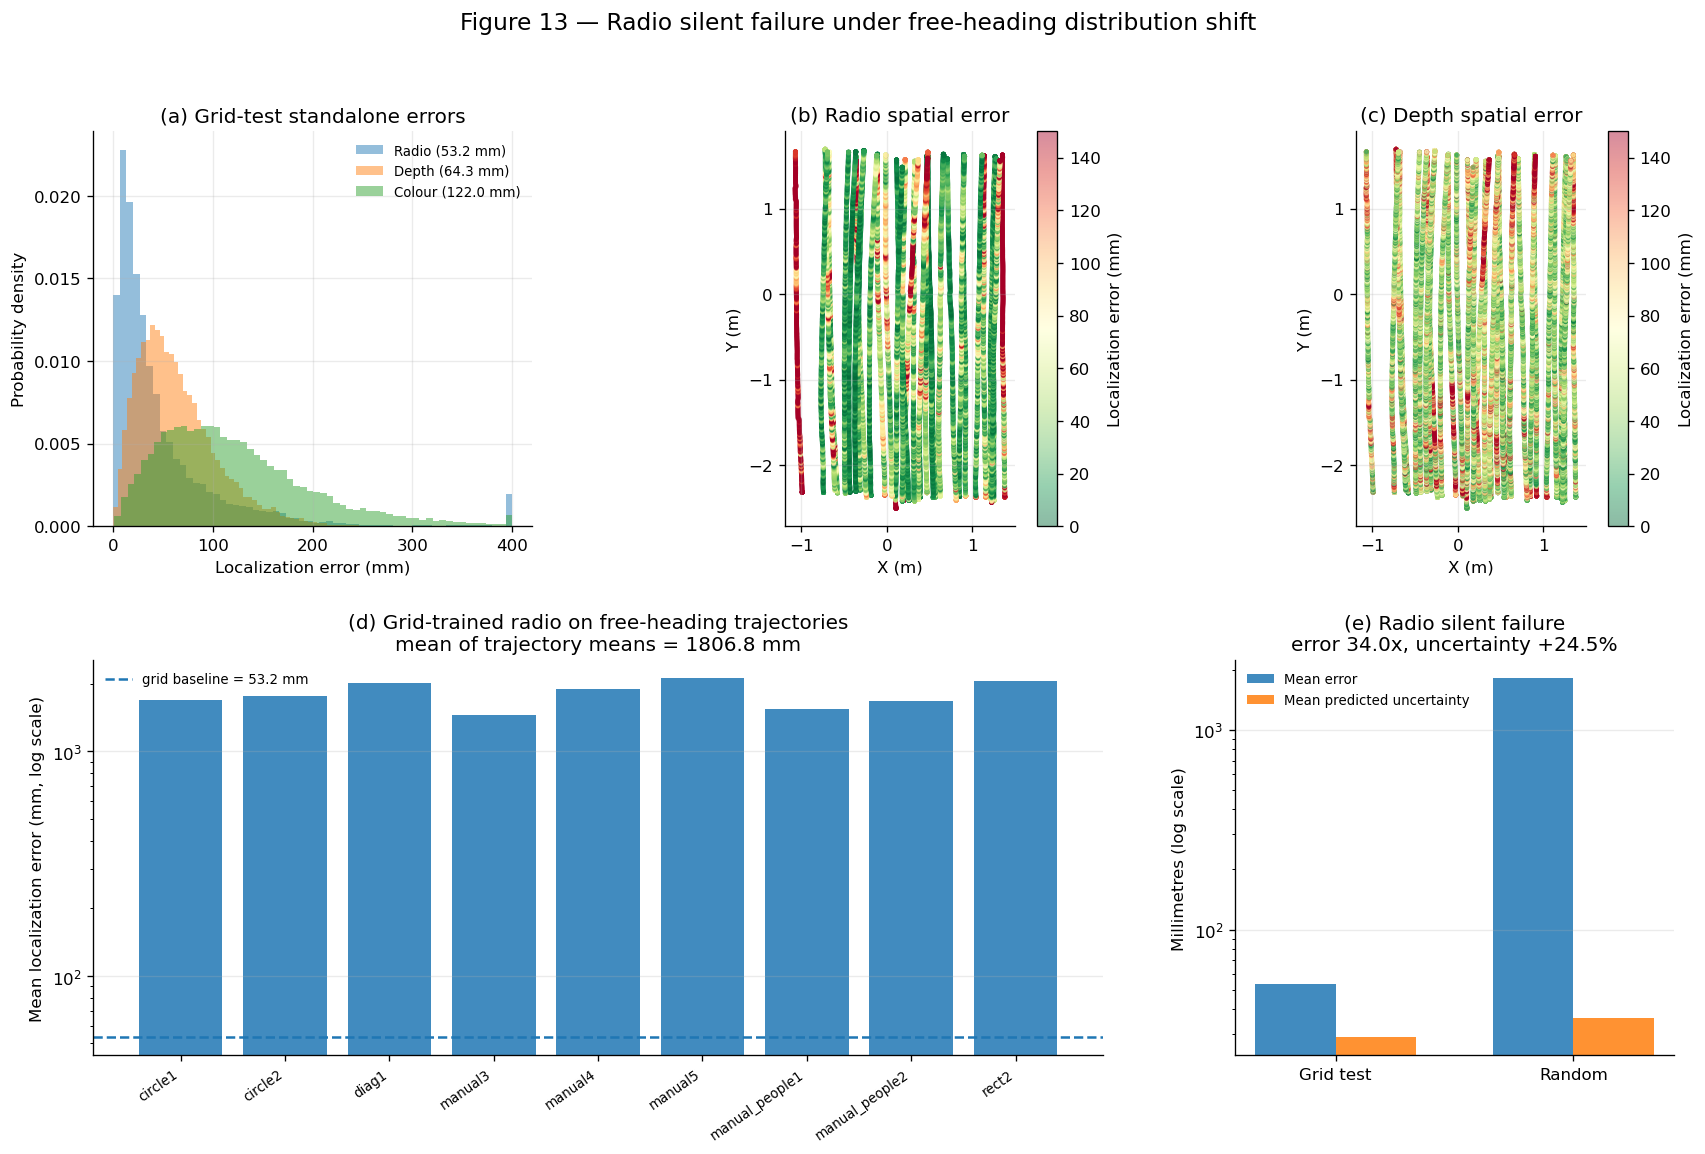


Saved reviewer-verification outputs
------------------------------------------------------------------------
Figure 13          : /data/luvira/reports/reviewer_reproduction/figures/figure_13_radio_silent_failure.png
Trajectory table   : /data/luvira/reports/reviewer_reproduction/tables/figure_13_random_radio_by_trajectory.csv
Random predictions : /data/luvira/reports/reviewer_reproduction/tables/figure_13_random_radio_predictions.csv
Verification table : /data/luvira/reports/reviewer_reproduction/tables/figure_13_silent_failure_verification.csv
Random input cache : /data/luvira/reports/reviewer_reproduction/cache/random_inputs
JSON summary       : /data/luvira/reports/reviewer_reproduction/tables/figure_13_radio_silent_failure_summary.json

CELL 19 PASSED — Figure 13 and the radio silent-failure result reproduced.


In [24]:
# =============================================================================
# CELL 19 — RADIO SILENT FAILURE UNDER FREE-HEADING DISTRIBUTION SHIFT
# =============================================================================
#
# Reproduces manuscript Figure 13.
#
# IMPORTANT POPULATION DEFINITION
# -------------------------------
#
# This cell uses ALL radio-usable random trajectories:
#
#     n = 9
#
# This is the population underlying the manuscript's radio-only
# silent-failure result:
#
#     grid mean error       ≈ 53.2 mm
#     random mean error     ≈ 1806.8 mm
#     error inflation       ≈ 34.0x
#
#     grid uncertainty      ≈ 28.9 mm
#     random uncertainty    ≈ 35.9 mm
#     uncertainty increase  ≈ +24.5 %
#
#
# This MUST NOT be confused with Table 7.
#
# Table 7 uses only the FIVE random trajectories for which
# radio + depth + colour + radio GT are all available.
#
#
# RANDOM AGGREGATION RULE
# -----------------------
#
# The historical calculation first computes the mean error and mean
# uncertainty separately for each random trajectory, and then takes the
# UNWEIGHTED mean across trajectories.
#
# Therefore:
#
#     manuscript random mean
#
# is NOT the pooled mean across every random snapshot.
#
#
# RADIO INPUT
# -----------
#
# Exact same preprocessing as the grid experiment:
#
#     n_use = min(radio rows, GT rows)
#     retained rows = 0, 5, 10, ...
#
#     R = H^H H
#
#     strict upper triangle of 100 x 100 covariance
#     -> 4,950 complex values
#     -> real + imaginary
#     -> 9,900 float values
#
#     standardization uses TRAINING-grid mean/std only
#
#
# RADIO MODEL
# -----------
#
# Uses the exact saved reported-run radio checkpoint verified in Cell 16.
#
# Predictive uncertainty proxy:
#
#     mean[
#         exp(0.5 * log_variance_x),
#         exp(0.5 * log_variance_y)
#     ]
#
# This signal is shown to be unreliable under distribution shift.
# =============================================================================


import gc
import json
import shutil

from pathlib import Path

from scipy.stats import spearmanr


print("=" * 72)
print("CELL 19 — RADIO SILENT-FAILURE / FIGURE 13")
print("=" * 72)


# =============================================================================
# 1. PATHS
# =============================================================================

ROOT = Path(
    "/data/luvira"
)

META_DIR = (
    ROOT
    / "metadata"
)

RADIO_CACHE = (
    ROOT
    / "processed"
    / "radio_npy"
)


if "TABLE_DIR" not in globals():

    TABLE_DIR = (
        ROOT
        / "reports"
        / "reviewer_reproduction"
        / "tables"
    )


if "FIG_DIR" not in globals():

    FIG_DIR = (
        ROOT
        / "reports"
        / "reviewer_reproduction"
        / "figures"
    )


if "MODEL_DIR" not in globals():

    MODEL_DIR = (
        ROOT
        / "reports"
        / "reviewer_reproduction"
        / "models"
    )


RANDOM_CACHE_DIR = (

    ROOT
    / "reports"
    / "reviewer_reproduction"
    / "cache"
    / "random_inputs"
)


TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RANDOM_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


LEGACY_FINAL_DIR = (
    ROOT
    / "reports"
    / "final"
)


# =============================================================================
# 2. HISTORICAL REFERENCE VALUES
# =============================================================================

HIST_GRID_ERROR_MM = 53.2

HIST_RANDOM_ERROR_MM = 1806.8

HIST_ERROR_RATIO = 34.0

HIST_GRID_UNCERTAINTY_MM = 28.9

HIST_RANDOM_UNCERTAINTY_MM = 35.9

HIST_UNCERTAINTY_SHIFT_PCT = 24.5

HIST_GRID_SPEARMAN = 0.107


CSI_STRIDE = 5

OOD_BATCH_SIZE = 512


# =============================================================================
# 3. LOAD TRAJECTORY INDEX
# =============================================================================

index_df = pd.read_csv(

    META_DIR
    / "trajectory_index.csv"
)


random_radio_df = (

    index_df.loc[

        (
            index_df[
                "kind"
            ] == "random"
        )

        &

        (
            index_df[
                "usable_radio"
            ] == True
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


print(
    "\nA. Radio-OOD population"
)

print("-" * 72)

print(
    f"Radio-usable random trajectories : "
    f"{len(random_radio_df)}"
)


print()


for _, row in random_radio_df.iterrows():

    print(
        f"  {row['trajectory_id']}"
    )


assert len(
    random_radio_df
) == 9, (
    "Figure-13 radio OOD population should contain "
    "exactly 9 radio-usable random trajectories."
)


expected_random_ids = [

    "random_circle1",

    "random_circle2",

    "random_diag1",

    "random_manual3",

    "random_manual4",

    "random_manual5",

    "random_manual_paople1",

    "random_manual_paople2",

    "random_rect2",
]


assert set(
    random_radio_df[
        "trajectory_id"
    ]
) == set(
    expected_random_ids
)


# =============================================================================
# 4. EXACT REPORTED RADIO CHECKPOINT
# =============================================================================

REPORTED_RADIO_CHECKPOINT = (

    MODEL_DIR
    / "reported_run_radio.pt"
)


assert REPORTED_RADIO_CHECKPOINT.exists(), (
    "Cell 16 reported-run radio checkpoint is missing."
)


assert "RadioNet" in globals(), (
    "RadioNet architecture from Cell 12 is required."
)


def load_plain_state_dict(
    checkpoint_path,
):

    state = torch.load(

        checkpoint_path,

        map_location="cpu",

        weights_only=True,
    )


    if (

        isinstance(
            state,
            dict,
        )

        and "state_dict" in state

        and isinstance(
            state[
                "state_dict"
            ],
            dict,
        )
    ):

        state = state[
            "state_dict"
        ]


    return state


radio_ood_model = (
    RadioNet()
    .to(
        DEVICE
    )
)


radio_ood_model.load_state_dict(

    load_plain_state_dict(
        REPORTED_RADIO_CHECKPOINT
    ),

    strict=True,
)


radio_ood_model.eval()


print(
    "\nB. Reported-run radio checkpoint"
)

print("-" * 72)

print(
    f"Checkpoint : "
    f"{REPORTED_RADIO_CHECKPOINT}"
)

print(
    f"Parameters : "
    f"{count_parameters(radio_ood_model):,}"
)

print(
    "State dict : PASS"
)


assert count_parameters(
    radio_ood_model
) == 6_390_788


# =============================================================================
# 5. EXACT TRAINING-GRID RADIO SCALER
# =============================================================================
#
# Cell 11 already verified that this scaler was fitted only on the
# 29,928 odd-grid training samples.
# =============================================================================

LEGACY_RADIO_MU = (

    LEGACY_FINAL_DIR
    / "scaler_radio_mu.npy"
)

LEGACY_RADIO_STD = (

    LEGACY_FINAL_DIR
    / "scaler_radio_std.npy"
)


assert LEGACY_RADIO_MU.exists()

assert LEGACY_RADIO_STD.exists()


radio_mu = np.load(
    LEGACY_RADIO_MU
).astype(
    np.float32
)


radio_std = np.load(
    LEGACY_RADIO_STD
).astype(
    np.float32
)


assert radio_mu.shape == (
    9900,
)

assert radio_std.shape == (
    9900,
)


# Store exact scaler in reviewer package too.
REVIEWER_RADIO_MU = (

    RANDOM_CACHE_DIR
    / "radio_training_mu.npy"
)

REVIEWER_RADIO_STD = (

    RANDOM_CACHE_DIR
    / "radio_training_std.npy"
)


if not REVIEWER_RADIO_MU.exists():

    shutil.copy2(

        LEGACY_RADIO_MU,

        REVIEWER_RADIO_MU,
    )


if not REVIEWER_RADIO_STD.exists():

    shutil.copy2(

        LEGACY_RADIO_STD,

        REVIEWER_RADIO_STD,
    )


print(
    "\nRadio scaler:"
)

print(
    f"  mean shape : "
    f"{radio_mu.shape}"
)

print(
    f"  std shape  : "
    f"{radio_std.shape}"
)

print(
    "  fitted on  : "
    "29,928 odd-grid training samples only"
)


# =============================================================================
# 6. EXACT COVARIANCE-FINGERPRINT FUNCTION
# =============================================================================

def figure13_cov_feature(
    H_snapshot,
):

    # H_snapshot = 100 x 100 complex channel matrix.
    #
    # Historical operation:
    #
    #     R = H^H H

    covariance = (

        H_snapshot
        .conj()
        .T

        @ H_snapshot
    )


    upper_indices = np.triu_indices(

        100,

        k=1,
    )


    upper_values = covariance[
        upper_indices
    ]


    feature = np.concatenate(

        [

            upper_values.real,

            upper_values.imag,
        ]

    ).astype(
        np.float32
    )


    assert feature.shape == (
        9900,
    )


    return feature


# =============================================================================
# 7. EXACT GRID-TEST RESULTS FOR FIGURE 13(a-c)
# =============================================================================

STANDALONE_REPORTED_PATH = (

    TABLE_DIR
    / "standalone_reported_run_predictions.csv"
)


assert STANDALONE_REPORTED_PATH.exists(), (
    "Cell 16 exact standalone prediction file is required."
)


grid_standalone_df = pd.read_csv(
    STANDALONE_REPORTED_PATH
)


assert len(
    grid_standalone_df
) == 28233


grid_gt_xy = grid_standalone_df[
    [
        "gt_x_m",
        "gt_y_m",
    ]
].to_numpy(
    dtype=np.float32
)


grid_radio_errors_mm = grid_standalone_df[
    "radio_error_mm"
].to_numpy(
    dtype=np.float64
)


grid_depth_errors_mm = grid_standalone_df[
    "depth_error_mm"
].to_numpy(
    dtype=np.float64
)


grid_colour_errors_mm = grid_standalone_df[
    "colour_error_mm"
].to_numpy(
    dtype=np.float64
)


assert np.isclose(

    grid_radio_errors_mm.mean(),

    HIST_GRID_ERROR_MM,

    atol=0.15,
)


# =============================================================================
# 8. RECOMPUTE REPORTED-RUN GRID RADIO UNCERTAINTY
# =============================================================================
#
# We deliberately compute this from the exact reported-run radio model.
# Fusion uncertainty is NOT used here.
# =============================================================================

assert "Xr_te_n" in globals(), (
    "Cell 11 standardized radio test tensor Xr_te_n is required."
)


grid_radio_prediction_parts = []

grid_radio_uncertainty_parts = []


with torch.no_grad():

    for start in range(
        0,
        len(
            Xr_te_n
        ),
        OOD_BATCH_SIZE,
    ):

        end = min(

            start
            + OOD_BATCH_SIZE,

            len(
                Xr_te_n
            ),
        )


        xb = torch.FloatTensor(

            np.asarray(
                Xr_te_n[
                    start:end
                ]
            )

        ).to(
            DEVICE
        )


        mu_prediction, log_variance = (
            radio_ood_model(
                xb
            )
        )


        grid_radio_prediction_parts.append(

            mu_prediction
            .cpu()
            .numpy()
        )


        predicted_std = np.exp(

            0.5

            * log_variance
            .cpu()
            .numpy()
        )


        grid_radio_uncertainty_parts.append(

            predicted_std.mean(
                axis=1
            )
        )


grid_radio_predictions = np.vstack(
    grid_radio_prediction_parts
).astype(
    np.float32
)


grid_radio_uncertainty_m = np.concatenate(
    grid_radio_uncertainty_parts
).astype(
    np.float32
)


grid_radio_uncertainty_mm = (

    grid_radio_uncertainty_m

    * 1000.0
)


grid_uncertainty_mean_mm = float(

    grid_radio_uncertainty_mm.mean()
)


grid_uncertainty_spearman, grid_uncertainty_p = (
    spearmanr(

        grid_radio_uncertainty_mm,

        grid_radio_errors_mm,
    )
)


grid_uncertainty_spearman = float(
    grid_uncertainty_spearman
)


grid_uncertainty_p = float(
    grid_uncertainty_p
)


print(
    "\nC. In-distribution radio reference"
)

print("-" * 72)

print(
    f"Grid mean error       : "
    f"{grid_radio_errors_mm.mean():.3f} mm"
)

print(
    f"Grid mean uncertainty : "
    f"{grid_uncertainty_mean_mm:.3f} mm"
)

print(
    f"Spearman r            : "
    f"{grid_uncertainty_spearman:.3f}"
)

print(
    f"Spearman p            : "
    f"{grid_uncertainty_p:.3e}"
)


assert np.isclose(

    grid_uncertainty_mean_mm,

    HIST_GRID_UNCERTAINTY_MM,

    atol=0.20,
)


assert np.isclose(

    grid_uncertainty_spearman,

    HIST_GRID_SPEARMAN,

    atol=0.003,
)


# =============================================================================
# 9. RANDOM-TRAJECTORY RADIO INFERENCE
# =============================================================================
#
# This recreates every random radio feature directly from the raw/cached
# channel matrix. No historical random prediction CSV is used.
# =============================================================================

print(
    "\nD. Recomputing radio predictions on 9 random trajectories"
)

print("-" * 72)


random_trajectory_rows = []

random_sample_tables = []


for trajectory_number, (_, row) in enumerate(

    random_radio_df.iterrows(),

    start=1,
):

    trajectory_id = row[
        "trajectory_id"
    ]


    radio_path = (

        RADIO_CACHE
        / f"{trajectory_id}.npy"
    )


    gt_path = Path(
        row[
            "gt_radio_csv"
        ]
    )


    assert radio_path.exists(), (
        f"{trajectory_id}: radio cache missing."
    )


    assert gt_path.exists(), (
        f"{trajectory_id}: radio GT missing."
    )


    H = np.load(

        radio_path,

        mmap_mode="r",
    )


    gt = np.loadtxt(
        gt_path
    )


    n_use = min(

        H.shape[
            0
        ],

        gt.shape[
            0
        ],
    )


    retained_indices = np.arange(

        0,

        n_use,

        CSI_STRIDE,

        dtype=np.int64,
    )


    n_retained = len(
        retained_indices
    )


    # -----------------------------------------------------------------
    # Construct exact 9,900-D fingerprints
    # -----------------------------------------------------------------

    X_random = np.empty(

        (
            n_retained,
            9900,
        ),

        dtype=np.float32,
    )


    for local_index, raw_index in enumerate(
        retained_indices
    ):

        X_random[
            local_index
        ] = figure13_cov_feature(

            H[
                raw_index
            ]
        )


    Y_random = (

        gt[
            retained_indices,
            1:3,
        ]

        / 1000.0

    ).astype(
        np.float32
    )


    # -----------------------------------------------------------------
    # Standardize with GRID-TRAINING statistics
    # -----------------------------------------------------------------

    X_random_standardized = (

        (
            X_random
            - radio_mu
        )

        / radio_std

    ).astype(
        np.float32
    )


    # Save input cache for Cell 20.
    np.save(

        RANDOM_CACHE_DIR
        / f"{trajectory_id}_radio_X.npy",

        X_random_standardized,
    )


    np.save(

        RANDOM_CACHE_DIR
        / f"{trajectory_id}_Y.npy",

        Y_random,
    )


    np.save(

        RANDOM_CACHE_DIR
        / f"{trajectory_id}_radio_indices.npy",

        retained_indices,
    )


    # -----------------------------------------------------------------
    # Exact model inference
    # -----------------------------------------------------------------

    trajectory_prediction_parts = []

    trajectory_uncertainty_parts = []


    with torch.no_grad():

        for start in range(
            0,
            n_retained,
            OOD_BATCH_SIZE,
        ):

            end = min(

                start
                + OOD_BATCH_SIZE,

                n_retained,
            )


            xb = torch.FloatTensor(

                X_random_standardized[
                    start:end
                ]

            ).to(
                DEVICE
            )


            mu_prediction, log_variance = (
                radio_ood_model(
                    xb
                )
            )


            trajectory_prediction_parts.append(

                mu_prediction
                .cpu()
                .numpy()
            )


            std_prediction = np.exp(

                0.5

                * log_variance
                .cpu()
                .numpy()
            )


            trajectory_uncertainty_parts.append(

                std_prediction.mean(
                    axis=1
                )
            )


    predictions = np.vstack(
        trajectory_prediction_parts
    ).astype(
        np.float32
    )


    uncertainty_m = np.concatenate(
        trajectory_uncertainty_parts
    ).astype(
        np.float32
    )


    errors_mm = (

        np.linalg.norm(

            predictions
            - Y_random,

            axis=1,
        )

        * 1000.0
    )


    uncertainty_mm = (

        uncertainty_m

        * 1000.0
    )


    mean_error_mm = float(
        errors_mm.mean()
    )


    median_error_mm = float(
        np.median(
            errors_mm
        )
    )


    mean_uncertainty_mm = float(
        uncertainty_mm.mean()
    )


    random_trajectory_rows.append({

        "trajectory_id":
            trajectory_id,

        "retained_samples":
            int(
                n_retained
            ),

        "mean_error_mm":
            mean_error_mm,

        "median_error_mm":
            median_error_mm,

        "p75_error_mm":
            float(
                np.percentile(
                    errors_mm,
                    75,
                )
            ),

        "p95_error_mm":
            float(
                np.percentile(
                    errors_mm,
                    95,
                )
            ),

        "mean_uncertainty_mm":
            mean_uncertainty_mm,
    })


    random_sample_tables.append(

        pd.DataFrame({

            "trajectory_id":
                trajectory_id,

            "radio_index":
                retained_indices,

            "gt_x_m":
                Y_random[
                    :,
                    0,
                ],

            "gt_y_m":
                Y_random[
                    :,
                    1,
                ],

            "pred_x_m":
                predictions[
                    :,
                    0,
                ],

            "pred_y_m":
                predictions[
                    :,
                    1,
                ],

            "error_mm":
                errors_mm,

            "predicted_uncertainty_mm":
                uncertainty_mm,
        })
    )


    print(

        f"  "
        f"{trajectory_number:1d}/"
        f"{len(random_radio_df)}  "

        f"{trajectory_id:28s}  "

        f"n={n_retained:4d}  "

        f"error={mean_error_mm:7.1f} mm  "

        f"unc={mean_uncertainty_mm:5.1f} mm"
    )


    del H

    del X_random

    del X_random_standardized

    gc.collect()


# =============================================================================
# 10. RANDOM SUMMARY
# =============================================================================

random_radio_summary_df = pd.DataFrame(
    random_trajectory_rows
)


random_radio_samples_df = pd.concat(

    random_sample_tables,

    ignore_index=True,
)


assert len(
    random_radio_summary_df
) == 9


# -----------------------------------------------------------------------------
# HISTORICAL AGGREGATION:
# unweighted mean of trajectory means.
# -----------------------------------------------------------------------------

random_mean_error_mm = float(

    random_radio_summary_df[
        "mean_error_mm"
    ].mean()
)


random_mean_uncertainty_mm = float(

    random_radio_summary_df[
        "mean_uncertainty_mm"
    ].mean()
)


error_ratio = (

    random_mean_error_mm

    / grid_radio_errors_mm.mean()
)


uncertainty_shift_pct = (

    (
        random_mean_uncertainty_mm
        - grid_uncertainty_mean_mm
    )

    / grid_uncertainty_mean_mm

    * 100.0
)


# Also report pooled values as a diagnostic ONLY.
pooled_random_error_mm = float(

    random_radio_samples_df[
        "error_mm"
    ].mean()
)


pooled_random_uncertainty_mm = float(

    random_radio_samples_df[
        "predicted_uncertainty_mm"
    ].mean()
)


print(
    "\nE. Figure-13 random-trajectory results"
)

print("-" * 72)


print(
    random_radio_summary_df.to_string(

        index=False,

        formatters={

            "mean_error_mm":
                lambda x: f"{x:.1f}",

            "median_error_mm":
                lambda x: f"{x:.1f}",

            "p75_error_mm":
                lambda x: f"{x:.1f}",

            "p95_error_mm":
                lambda x: f"{x:.1f}",

            "mean_uncertainty_mm":
                lambda x: f"{x:.1f}",
        },
    )
)


print(
    "\nHistorical manuscript aggregation"
)

print(
    "  aggregation             : "
    "unweighted mean of trajectory means"
)

print(
    f"  grid mean error         : "
    f"{grid_radio_errors_mm.mean():.1f} mm"
)

print(
    f"  random mean error       : "
    f"{random_mean_error_mm:.1f} mm"
)

print(
    f"  error inflation         : "
    f"{error_ratio:.1f}x"
)

print(
    f"  grid mean uncertainty   : "
    f"{grid_uncertainty_mean_mm:.1f} mm"
)

print(
    f"  random mean uncertainty : "
    f"{random_mean_uncertainty_mm:.1f} mm"
)

print(
    f"  uncertainty increase    : "
    f"{uncertainty_shift_pct:+.1f}%"
)


print(
    "\nPooled-snapshot diagnostic — not used for manuscript claim"
)

print(
    f"  pooled random error     : "
    f"{pooled_random_error_mm:.1f} mm"
)

print(
    f"  pooled random uncertainty: "
    f"{pooled_random_uncertainty_mm:.1f} mm"
)


# =============================================================================
# 11. EXACT HISTORICAL VERIFICATION
# =============================================================================

print(
    "\nF. Historical-result verification"
)

print("-" * 72)


verification_df = pd.DataFrame({

    "quantity": [

        "Grid mean error (mm)",

        "Random mean error (mm)",

        "Error ratio",

        "Grid mean uncertainty (mm)",

        "Random mean uncertainty (mm)",

        "Uncertainty shift (%)",

        "Grid uncertainty-error Spearman",
    ],

    "historical": [

        HIST_GRID_ERROR_MM,

        HIST_RANDOM_ERROR_MM,

        HIST_ERROR_RATIO,

        HIST_GRID_UNCERTAINTY_MM,

        HIST_RANDOM_UNCERTAINTY_MM,

        HIST_UNCERTAINTY_SHIFT_PCT,

        HIST_GRID_SPEARMAN,
    ],

    "reproduced": [

        float(
            grid_radio_errors_mm.mean()
        ),

        random_mean_error_mm,

        error_ratio,

        grid_uncertainty_mean_mm,

        random_mean_uncertainty_mm,

        uncertainty_shift_pct,

        grid_uncertainty_spearman,
    ],
})


print(
    verification_df.to_string(

        index=False,

        formatters={

            "historical":
                lambda x: f"{x:.3f}",

            "reproduced":
                lambda x: f"{x:.3f}",
        },
    )
)


assert np.isclose(

    random_mean_error_mm,

    HIST_RANDOM_ERROR_MM,

    atol=1.0,
), (
    "Random radio mean does not reproduce "
    "the historical 1806.8-mm value."
)


assert np.isclose(

    error_ratio,

    HIST_ERROR_RATIO,

    atol=0.10,
)


assert np.isclose(

    random_mean_uncertainty_mm,

    HIST_RANDOM_UNCERTAINTY_MM,

    atol=0.30,
)


assert np.isclose(

    uncertainty_shift_pct,

    HIST_UNCERTAINTY_SHIFT_PCT,

    atol=0.60,
)


assert (

    error_ratio
    > 30.0
)


assert (

    uncertainty_shift_pct
    < 30.0
)


print(
    "\nRADIO SILENT FAILURE REPRODUCED:"
)

print(
    f"  localization error increases "
    f"{error_ratio:.1f}x"
)

print(
    f"  predicted uncertainty increases "
    f"only {uncertainty_shift_pct:.1f}%"
)


# =============================================================================
# 12. SAVE NUMERICAL OUTPUTS
# =============================================================================

RANDOM_TRAJECTORY_TABLE_PATH = (

    TABLE_DIR
    / "figure_13_random_radio_by_trajectory.csv"
)


RANDOM_SAMPLE_TABLE_PATH = (

    TABLE_DIR
    / "figure_13_random_radio_predictions.csv"
)


FIGURE13_VERIFY_PATH = (

    TABLE_DIR
    / "figure_13_silent_failure_verification.csv"
)


random_radio_summary_df.to_csv(

    RANDOM_TRAJECTORY_TABLE_PATH,

    index=False,
)


random_radio_samples_df.to_csv(

    RANDOM_SAMPLE_TABLE_PATH,

    index=False,
)


verification_df.to_csv(

    FIGURE13_VERIFY_PATH,

    index=False,
)


# =============================================================================
# 13. FIGURE 13
# =============================================================================
#
# Manuscript:
#
#   (a) grid-test standalone error distributions
#   (b) grid-test radio spatial errors
#   (c) grid-test depth spatial errors
#   (d) radio mean error for each random trajectory vs grid baseline
#   (e) error vs predicted uncertainty: grid versus random
#
# Panels (d) and (e) use logarithmic Y axes because the OOD error is
# roughly two orders of magnitude larger than the uncertainty signal.
# =============================================================================

fig = plt.figure(

    figsize=(
        17,
        10,
    )
)


gs = fig.add_gridspec(

    2,
    3,

    hspace=0.34,

    wspace=0.30,
)


ax_a = fig.add_subplot(
    gs[
        0,
        0,
    ]
)


ax_b = fig.add_subplot(
    gs[
        0,
        1,
    ]
)


ax_c = fig.add_subplot(
    gs[
        0,
        2,
    ]
)


ax_d = fig.add_subplot(
    gs[
        1,
        0:2,
    ]
)


ax_e = fig.add_subplot(
    gs[
        1,
        2,
    ]
)


# -----------------------------------------------------------------------------
# Figure 13(a) — standalone grid error distributions
# -----------------------------------------------------------------------------

for errors, label in [

    (
        grid_radio_errors_mm,
        (
            f"Radio "
            f"({grid_radio_errors_mm.mean():.1f} mm)"
        ),
    ),

    (
        grid_depth_errors_mm,
        (
            f"Depth "
            f"({grid_depth_errors_mm.mean():.1f} mm)"
        ),
    ),

    (
        grid_colour_errors_mm,
        (
            f"Colour "
            f"({grid_colour_errors_mm.mean():.1f} mm)"
        ),
    ),
]:

    ax_a.hist(

        np.clip(
            errors,
            0,
            400,
        ),

        bins=60,

        density=True,

        alpha=0.48,

        label=label,
    )


ax_a.set_xlabel(
    "Localization error (mm)"
)

ax_a.set_ylabel(
    "Probability density"
)

ax_a.set_title(
    "(a) Grid-test standalone errors"
)

ax_a.legend(
    frameon=False,
    fontsize=8,
)

ax_a.grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 13(b) — radio spatial error map
# -----------------------------------------------------------------------------

radio_scatter = ax_b.scatter(

    grid_gt_xy[
        :,
        0,
    ],

    grid_gt_xy[
        :,
        1,
    ],

    c=grid_radio_errors_mm,

    cmap="RdYlGn_r",

    s=4,

    alpha=0.45,

    vmin=0,

    vmax=150,
)


radio_colorbar = fig.colorbar(

    radio_scatter,

    ax=ax_b,
)


radio_colorbar.set_label(
    "Localization error (mm)"
)


ax_b.set_xlabel(
    "X (m)"
)

ax_b.set_ylabel(
    "Y (m)"
)

ax_b.set_title(
    "(b) Radio spatial error"
)

ax_b.set_aspect(
    "equal",
    adjustable="box",
)

ax_b.grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 13(c) — depth spatial error map
# -----------------------------------------------------------------------------

depth_scatter = ax_c.scatter(

    grid_gt_xy[
        :,
        0,
    ],

    grid_gt_xy[
        :,
        1,
    ],

    c=grid_depth_errors_mm,

    cmap="RdYlGn_r",

    s=4,

    alpha=0.45,

    vmin=0,

    vmax=150,
)


depth_colorbar = fig.colorbar(

    depth_scatter,

    ax=ax_c,
)


depth_colorbar.set_label(
    "Localization error (mm)"
)


ax_c.set_xlabel(
    "X (m)"
)

ax_c.set_ylabel(
    "Y (m)"
)

ax_c.set_title(
    "(c) Depth spatial error"
)

ax_c.set_aspect(
    "equal",
    adjustable="box",
)

ax_c.grid(
    alpha=0.25
)


# -----------------------------------------------------------------------------
# Figure 13(d) — random radio error by trajectory
# -----------------------------------------------------------------------------

plot_labels = [

    trajectory_id
    .replace(
        "random_",
        "",
    )
    .replace(
        "manual_paople",
        "manual_people",
    )

    for trajectory_id in random_radio_summary_df[
        "trajectory_id"
    ]
]


plot_values = random_radio_summary_df[
    "mean_error_mm"
].to_numpy()


ax_d.bar(

    np.arange(
        len(
            plot_values
        )
    ),

    plot_values,

    alpha=0.85,
)


ax_d.axhline(

    grid_radio_errors_mm.mean(),

    linestyle="--",

    linewidth=1.5,

    label=(
        f"grid baseline = "
        f"{grid_radio_errors_mm.mean():.1f} mm"
    ),
)


ax_d.set_yscale(
    "log"
)


ax_d.set_xticks(

    np.arange(
        len(
            plot_labels
        )
    )
)


ax_d.set_xticklabels(

    plot_labels,

    rotation=35,

    ha="right",

    fontsize=8,
)


ax_d.set_ylabel(
    "Mean localization error (mm, log scale)"
)

ax_d.set_title(

    "(d) Grid-trained radio on free-heading trajectories\n"

    f"mean of trajectory means = "
    f"{random_mean_error_mm:.1f} mm"
)


ax_d.legend(
    frameon=False,
    fontsize=8,
)

ax_d.grid(
    alpha=0.25,
    axis="y",
)


# -----------------------------------------------------------------------------
# Figure 13(e) — silent failure: error vs uncertainty
# -----------------------------------------------------------------------------

x_groups = np.arange(
    2
)


bar_width = 0.34


error_values = [

    float(
        grid_radio_errors_mm.mean()
    ),

    random_mean_error_mm,
]


uncertainty_values = [

    grid_uncertainty_mean_mm,

    random_mean_uncertainty_mm,
]


ax_e.bar(

    x_groups
    - bar_width / 2,

    error_values,

    bar_width,

    alpha=0.85,

    label="Mean error",
)


ax_e.bar(

    x_groups
    + bar_width / 2,

    uncertainty_values,

    bar_width,

    alpha=0.85,

    label="Mean predicted uncertainty",
)


ax_e.set_yscale(
    "log"
)


ax_e.set_xticks(
    x_groups
)


ax_e.set_xticklabels(
    [
        "Grid test",
        "Random",
    ]
)


ax_e.set_ylabel(
    "Millimetres (log scale)"
)


ax_e.set_title(

    "(e) Radio silent failure\n"

    f"error {error_ratio:.1f}x, "
    f"uncertainty {uncertainty_shift_pct:+.1f}%"
)


ax_e.legend(
    frameon=False,
    fontsize=8,
)

ax_e.grid(
    alpha=0.25,
    axis="y",
)


fig.suptitle(

    "Figure 13 — Radio silent failure under free-heading distribution shift",

    fontsize=14,
)


FIGURE13_PATH = (

    FIG_DIR
    / "figure_13_radio_silent_failure.png"
)


fig.savefig(

    FIGURE13_PATH,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 14. SAVE JSON SUMMARY
# =============================================================================

figure13_summary = {

    "radio_random_population": {

        "definition":
            (
                "all random trajectories with usable radio "
                "and antenna ground truth"
            ),

        "trajectory_count":
            int(
                len(
                    random_radio_summary_df
                )
            ),

        "trajectory_ids":
            random_radio_summary_df[
                "trajectory_id"
            ].tolist(),

        "retained_sample_rule":
            (
                "indices 0,5,10,... < "
                "min(radio_rows,gt_rows)"
            ),
    },


    "grid": {

        "samples":
            28233,

        "mean_error_mm":
            float(
                grid_radio_errors_mm.mean()
            ),

        "mean_predicted_uncertainty_mm":
            grid_uncertainty_mean_mm,

        "uncertainty_error_spearman":
            grid_uncertainty_spearman,

        "uncertainty_error_p_value":
            grid_uncertainty_p,
    },


    "random": {

        "aggregation":
            "unweighted mean across trajectory means",

        "mean_error_mm":
            random_mean_error_mm,

        "mean_predicted_uncertainty_mm":
            random_mean_uncertainty_mm,

        "error_ratio_vs_grid":
            float(
                error_ratio
            ),

        "uncertainty_shift_percent":
            float(
                uncertainty_shift_pct
            ),

        "pooled_snapshot_error_mm_diagnostic":
            pooled_random_error_mm,

        "pooled_snapshot_uncertainty_mm_diagnostic":
            pooled_random_uncertainty_mm,
    },


    "interpretation": {

        "silent_failure":
            True,

        "statement":
            (
                "radio localization error inflates by "
                "approximately 34x under free-heading motion, "
                "while its predicted uncertainty rises by "
                "only approximately 24.5 percent"
            ),

        "uncertainty_caveat":
            (
                "radio predictive uncertainty is weakly "
                "related to actual error in distribution and "
                "does not provide a reliable OOD warning"
            ),
    },


    "population_note_for_manuscript": {

        "figure_13":
            (
                "9 radio-usable random trajectories"
            ),

        "table_7":
            (
                "5 fully multimodal random trajectories"
            ),
    },
}


FIGURE13_JSON_PATH = (

    TABLE_DIR
    / "figure_13_radio_silent_failure_summary.json"
)


with open(

    FIGURE13_JSON_PATH,

    "w",

) as f:

    json.dump(

        figure13_summary,

        f,

        indent=2,
    )


# =============================================================================
# 15. CLEANUP
# =============================================================================

del radio_ood_model

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# =============================================================================
# 16. FINAL OUTPUT
# =============================================================================

print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)


print(
    f"Figure 13          : "
    f"{FIGURE13_PATH}"
)

print(
    "Trajectory table   : "
    f"{RANDOM_TRAJECTORY_TABLE_PATH}"
)

print(
    "Random predictions : "
    f"{RANDOM_SAMPLE_TABLE_PATH}"
)

print(
    "Verification table : "
    f"{FIGURE13_VERIFY_PATH}"
)

print(
    "Random input cache : "
    f"{RANDOM_CACHE_DIR}"
)

print(
    f"JSON summary       : "
    f"{FIGURE13_JSON_PATH}"
)


print(
    "\n" + "=" * 72
)

print(
    "CELL 19 PASSED — "
    "Figure 13 and the radio silent-failure result reproduced."
)

print(
    "=" * 72
)

CELL 20 — FREE-HEADING GENERALIZATION / TABLE 7
CORRECTED HISTORICAL-PROVENANCE VERSION
Device : cuda

A. Table-7 evaluation population
------------------------------------------------------------------------
  random_circle1                  has_humans=False
  random_manual4                  has_humans=False
  random_manual5                  has_humans=False
  random_manual_paople2           has_humans=True
  random_rect2                    has_humans=False

Population count : 5

B. Historical Table-7 radio source
------------------------------------------------------------------------
Source : /data/luvira/reports/Q6_random_predictions.csv
Rows   : 9,004
Required columns : PASS
Radio source     : historical Q6 reported-run predictions
Fusion Variant A : NOT used for the Table-7 Radio column
SHA256 : 89933d2f9d2fe16aab103a54cbe4f75b9bbcdb37d8c240a5b6cace3ad35f2550
Packaged copy : /data/luvira/reports/reviewer_reproduction/reported_run_artifacts/Q6_random_predictions.csv

C. Fusion che

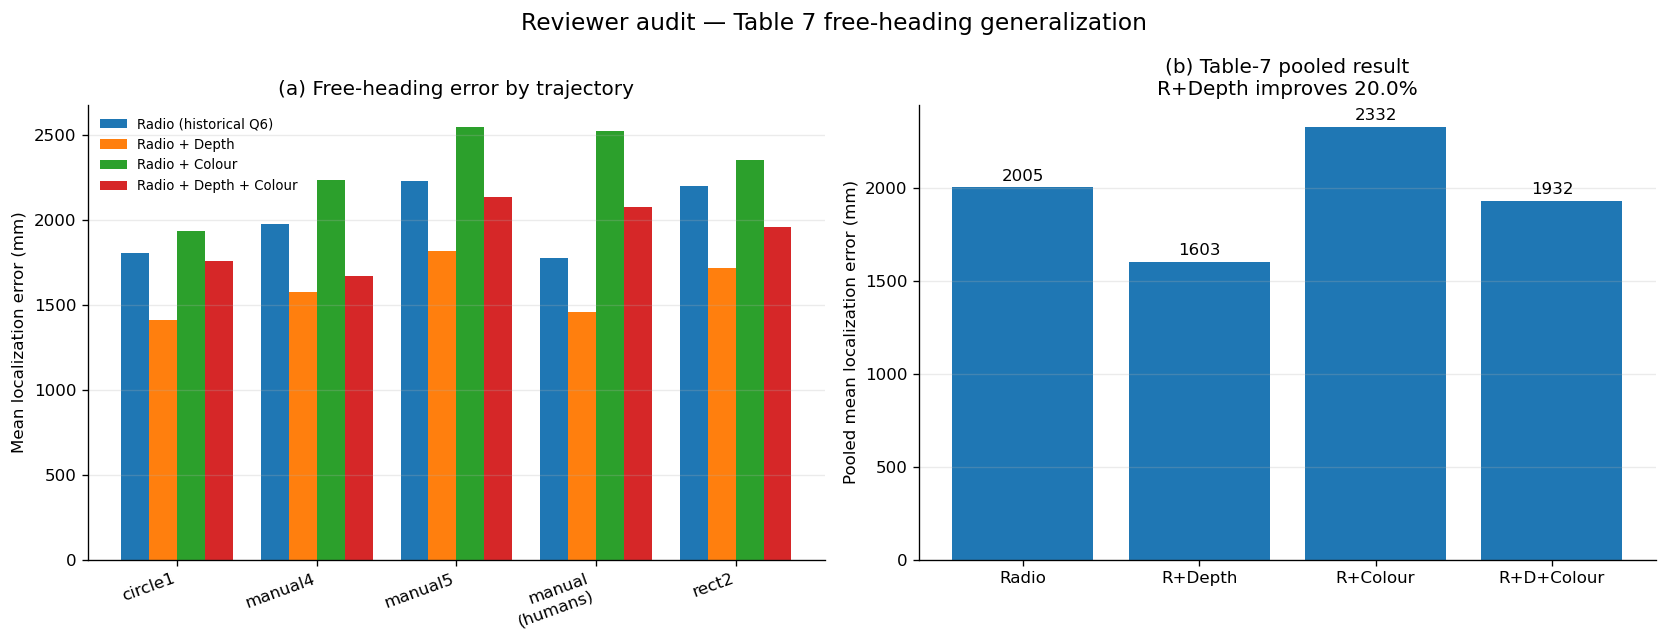


M. Manuscript reconciliation register
------------------------------------------------------------------------
                                     item                                                                                                                                                                                implementation                                                     status
                 Table-7 radio provenance              Historical Table 7 reads the radio-only errors from reports/Q6_random_predictions.csv. It does not compute the Radio column from fusion Variant A inside the Table-7 evaluation.             REGISTERED — manuscript wording audit required
Figure-13 versus Table-7 radio provenance Figure 13 is reproduced from the standalone 300-epoch heteroscedastic-NLL reported-run radio checkpoint, whereas the historical Table-7 Radio column comes from the Q6 reported-run artifact. REGISTERED — clarify provenance in manuscript/code release
               

In [26]:
# =============================================================================
# CELL 20 — FREE-HEADING GENERALIZATION / TABLE 7
# CORRECTED HISTORICAL-PROVENANCE VERSION
# =============================================================================
#
# IMPORTANT:
#
# Historical Table 7 did NOT obtain its "Radio" column by evaluating
# fusion Variant A.
#
# The historical implementation used:
#
#     /data/luvira/reports/Q6_random_predictions.csv
#
# for the Table-7 radio-only errors, while B/C/D were recomputed from
# the fusion checkpoints.
#
# Therefore this cell reproduces that exact reported-run provenance.
#
#
# TABLE-7 POPULATION
# ------------------
#
# Five fully multimodal random trajectories:
#
#   random_circle1
#   random_manual4
#   random_manual5
#   random_manual_paople2
#   random_rect2
#
#
# HISTORICAL TABLE-7 VALUES
# -------------------------
#
# trajectory                    Radio    R+Depth    R+Colour    R+D+Colour
# ------------------------------------------------------------------------
# random_circle1                 1801       1407        1932          1757
# random_manual4                 1975       1577        2233          1666
# random_manual5                 2226       1817        2547          2132
# random_manual_paople2          1776       1456        2520          2074
# random_rect2                   2196       1716        2349          1959
#
# pooled sample-level mean       2005       1603        2332          1932
#
#
# NOTE ABOUT AGGREGATION
# ----------------------
#
# The manuscript "Mean" row is NOT the arithmetic mean of the five
# displayed rounded trajectory means.
#
# Historical code concatenated every retained sample and then calculated:
#
#     df_out["error_radio_mm"].mean()
#     df_out["error_B_mm"].mean()
#     df_out["error_C_mm"].mean()
#     df_out["error_D_mm"].mean()
#
# Thus the reported mean is SAMPLE-WEIGHTED.
#
#
# FIGURE 13 IS DIFFERENT
# ----------------------
#
# Cell 19 / Figure 13:
#   - 9 radio-usable random trajectories
#   - standalone heteroscedastic-NLL radio checkpoint
#   - mean random error = 1806.8 mm
#
# Table 7:
#   - only 5 fully multimodal trajectories
#   - historical radio values loaded from Q6_random_predictions.csv
#   - B/C/D evaluated using fusion checkpoints
#
# This distinction is explicitly preserved below.
#
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import gc
import hashlib
import json
import shutil

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


print("=" * 72)
print("CELL 20 — FREE-HEADING GENERALIZATION / TABLE 7")
print("CORRECTED HISTORICAL-PROVENANCE VERSION")
print("=" * 72)


# =============================================================================
# 1. BASIC CONFIGURATION
# =============================================================================

ROOT = Path(
    "/data/luvira"
)

META_DIR = (
    ROOT
    / "metadata"
)

RADIO_CACHE = (
    ROOT
    / "processed"
    / "radio_npy"
)

LEGACY_FINAL_DIR = (
    ROOT
    / "reports"
    / "final"
)

LEGACY_REPORTS_DIR = (
    ROOT
    / "reports"
)


if "TABLE_DIR" not in globals():

    TABLE_DIR = (
        ROOT
        / "reports"
        / "reviewer_reproduction"
        / "tables"
    )


if "FIG_DIR" not in globals():

    FIG_DIR = (
        ROOT
        / "reports"
        / "reviewer_reproduction"
        / "figures"
    )


if "MODEL_DIR" not in globals():

    MODEL_DIR = (
        ROOT
        / "reports"
        / "reviewer_reproduction"
        / "models"
    )


RANDOM_CACHE_DIR = (
    ROOT
    / "reports"
    / "reviewer_reproduction"
    / "cache"
    / "random_inputs"
)


REPORTED_ARTIFACT_DIR = (
    ROOT
    / "reports"
    / "reviewer_reproduction"
    / "reported_run_artifacts"
)


for directory in [
    TABLE_DIR,
    FIG_DIR,
    MODEL_DIR,
    RANDOM_CACHE_DIR,
    REPORTED_ARTIFACT_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


if "DEVICE" not in globals():

    DEVICE = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


print(
    f"Device : {DEVICE}"
)


# =============================================================================
# 2. CONSTANTS
# =============================================================================

CSI_STRIDE = 5

DEPTH_CLIP_MM = 5000.0

DEPTH_HEIGHT = 48

DEPTH_WIDTH = 64

BATCH_SIZE = 32


IMAGENET_MEAN = np.array(
    [
        0.485,
        0.456,
        0.406,
    ],
    dtype=np.float32,
)


IMAGENET_STD = np.array(
    [
        0.229,
        0.224,
        0.225,
    ],
    dtype=np.float32,
)


EXPECTED_IDS = [

    "random_circle1",

    "random_manual4",

    "random_manual5",

    "random_manual_paople2",

    "random_rect2",
]


PAPER_LABELS = {

    "random_circle1":
        "random_circle1",

    "random_manual4":
        "random_manual4",

    "random_manual5":
        "random_manual5",

    "random_manual_paople2":
        "random_manual (humans)",

    "random_rect2":
        "random_rect2",
}


EXPECTED = {

    "random_circle1": {
        "A": 1801.0,
        "B": 1407.0,
        "C": 1932.0,
        "D": 1757.0,
    },

    "random_manual4": {
        "A": 1975.0,
        "B": 1577.0,
        "C": 2233.0,
        "D": 1666.0,
    },

    "random_manual5": {
        "A": 2226.0,
        "B": 1817.0,
        "C": 2547.0,
        "D": 2132.0,
    },

    "random_manual_paople2": {
        "A": 1776.0,
        "B": 1456.0,
        "C": 2520.0,
        "D": 2074.0,
    },

    "random_rect2": {
        "A": 2196.0,
        "B": 1716.0,
        "C": 2349.0,
        "D": 1959.0,
    },
}


EXPECTED_POOLED = {

    "A": 2005.0,

    "B": 1603.0,

    "C": 2332.0,

    "D": 1932.0,
}


# =============================================================================
# 3. TABLE-7 POPULATION
# =============================================================================

index_df = pd.read_csv(
    META_DIR
    / "trajectory_index.csv"
)


eligible_df = (

    index_df.loc[

        (
            index_df[
                "kind"
            ] == "random"
        )

        &

        (
            index_df[
                "usable_full"
            ] == True
        )

    ]

    .copy()
)


order_map = {

    trajectory_id:
        position

    for position, trajectory_id
    in enumerate(
        EXPECTED_IDS
    )
}


eligible_df[
    "_paper_order"
] = eligible_df[
    "trajectory_id"
].map(
    order_map
)


eligible_df = (

    eligible_df

    .sort_values(
        "_paper_order"
    )

    .reset_index(
        drop=True
    )
)


assert len(
    eligible_df
) == 5


assert eligible_df[
    "trajectory_id"
].tolist() == EXPECTED_IDS


print(
    "\nA. Table-7 evaluation population"
)

print("-" * 72)


for _, row in eligible_df.iterrows():

    print(
        f"  "
        f"{row['trajectory_id']:30s}  "
        f"has_humans="
        f"{bool(row['has_humans'])}"
    )


print(
    "\nPopulation count : "
    f"{len(eligible_df)}"
)


# =============================================================================
# 4. HISTORICAL TABLE-7 RADIO ARTIFACT
# =============================================================================
#
# THIS IS THE CRITICAL CORRECTION.
#
# Historical Table-7 code explicitly used:
#
#     reports/Q6_random_predictions.csv
#
# and took:
#
#     radio_traj["error_mm"]
#
# as the radio-only reference.
# =============================================================================

Q6_RADIO_PATH = (
    LEGACY_REPORTS_DIR
    / "Q6_random_predictions.csv"
)


assert Q6_RADIO_PATH.exists(), (
    "\nHistorical Table-7 radio source is missing:\n"
    f"  {Q6_RADIO_PATH}\n\n"
    "Do not substitute Fusion Variant A here. "
    "The historical Table-7 implementation used "
    "Q6_random_predictions.csv."
)


q6_radio_df = pd.read_csv(
    Q6_RADIO_PATH
)


required_q6_columns = {

    "trajectory_id",

    "error_mm",

    "uncertainty_mm",
}


missing_q6_columns = (

    required_q6_columns

    - set(
        q6_radio_df.columns
    )
)


assert not missing_q6_columns, (
    "Q6 radio artifact is missing required columns: "
    f"{sorted(missing_q6_columns)}"
)


print(
    "\nB. Historical Table-7 radio source"
)

print("-" * 72)


print(
    f"Source : {Q6_RADIO_PATH}"
)

print(
    f"Rows   : {len(q6_radio_df):,}"
)

print(
    "Required columns : PASS"
)

print(
    "Radio source     : historical Q6 reported-run predictions"
)

print(
    "Fusion Variant A : NOT used for the Table-7 Radio column"
)


# -----------------------------------------------------------------------------
# Package the exact historical artifact for reviewers.
# -----------------------------------------------------------------------------

PACKAGED_Q6_PATH = (
    REPORTED_ARTIFACT_DIR
    / "Q6_random_predictions.csv"
)


shutil.copy2(
    Q6_RADIO_PATH,
    PACKAGED_Q6_PATH,
)


def sha256_file(
    path,
):

    digest = hashlib.sha256()


    with open(
        path,
        "rb",
    ) as file_handle:

        while True:

            chunk = file_handle.read(
                1024 * 1024
            )


            if not chunk:

                break


            digest.update(
                chunk
            )


    return digest.hexdigest()


q6_sha256 = sha256_file(
    Q6_RADIO_PATH
)


print(
    f"SHA256 : {q6_sha256}"
)

print(
    f"Packaged copy : {PACKAGED_Q6_PATH}"
)


# =============================================================================
# 5. FUSION CHECKPOINTS B / C / D
# =============================================================================
#
# Table 7 historically recomputed fusion B/C/D from the raw modalities.
#
# Variant A is deliberately NOT used as the historical Table-7 radio
# source.
# =============================================================================

assert "make_fusion_variant" in globals(), (
    "Cell 18 must be run first because "
    "make_fusion_variant() is required."
)


CHECKPOINTS = {

    "B":
        MODEL_DIR
        / "reported_run_fusion_B_radio_depth.pt",

    "C":
        MODEL_DIR
        / "reported_run_fusion_C_radio_colour.pt",

    "D":
        MODEL_DIR
        / "reported_run_fusion_D_radio_depth_colour.pt",
}


for variant, path in CHECKPOINTS.items():

    assert path.exists(), (
        f"Missing reported-run checkpoint {variant}: "
        f"{path}"
    )


def load_state(
    path,
):

    state = torch.load(

        path,

        map_location="cpu",

        weights_only=True,
    )


    if (
        isinstance(
            state,
            dict,
        )

        and "state_dict" in state

        and isinstance(
            state[
                "state_dict"
            ],
            dict,
        )
    ):

        state = state[
            "state_dict"
        ]


    return state


models = {}


for variant in [
    "B",
    "C",
    "D",
]:

    model = make_fusion_variant(
        variant
    )


    model.load_state_dict(

        load_state(
            CHECKPOINTS[
                variant
            ]
        ),

        strict=True,
    )


    model = model.to(
        DEVICE
    )


    model.eval()


    models[
        variant
    ] = model


print(
    "\nC. Fusion checkpoint loading"
)

print("-" * 72)


for variant in [
    "B",
    "C",
    "D",
]:

    print(
        f"  Variant {variant} : "
        f"PASS — {CHECKPOINTS[variant]}"
    )


# =============================================================================
# 6. OPTIONAL VARIANT-A DIAGNOSTIC MODEL
# =============================================================================
#
# This model is evaluated ONLY to demonstrate that it is a distinct
# provenance from the historical Q6 Table-7 radio result.
#
# It is never substituted into the manuscript Table-7 values.
# =============================================================================

FUSION_A_PATH = (
    MODEL_DIR
    / "reported_run_fusion_A_radio_only.pt"
)


fusion_A_diagnostic = None


if FUSION_A_PATH.exists():

    fusion_A_diagnostic = make_fusion_variant(
        "A"
    )


    fusion_A_diagnostic.load_state_dict(

        load_state(
            FUSION_A_PATH
        ),

        strict=True,
    )


    fusion_A_diagnostic = (
        fusion_A_diagnostic
        .to(
            DEVICE
        )
        .eval()
    )


# =============================================================================
# 7. TRAINING-GRID SCALERS
# =============================================================================

radio_mu = np.load(

    LEGACY_FINAL_DIR
    / "scaler_radio_mu.npy"

).astype(
    np.float32
)


radio_std = np.load(

    LEGACY_FINAL_DIR
    / "scaler_radio_std.npy"

).astype(
    np.float32
)


rgb_mu = np.load(

    LEGACY_FINAL_DIR
    / "scaler_rgb64_mu.npy"

).astype(
    np.float32
)


rgb_std = np.load(

    LEGACY_FINAL_DIR
    / "scaler_rgb64_std.npy"

).astype(
    np.float32
)


assert radio_mu.shape == (
    9900,
)

assert radio_std.shape == (
    9900,
)

assert rgb_mu.shape == (
    64,
)

assert rgb_std.shape == (
    64,
)


# =============================================================================
# 8. RADIO PREPROCESSING
# =============================================================================

def radio_feature(
    H_snapshot,
):

    covariance = (

        H_snapshot
        .conj()
        .T

        @ H_snapshot
    )


    upper = np.triu_indices(

        100,

        k=1,
    )


    values = covariance[
        upper
    ]


    feature = np.concatenate(

        [
            values.real,
            values.imag,
        ]

    ).astype(
        np.float32
    )


    assert feature.shape == (
        9900,
    )


    # Historical Table-7 helper explicitly used std + 1e-8.
    return (

        (
            feature
            - radio_mu
        )

        / (
            radio_std
            + 1e-8
        )

    ).astype(
        np.float32
    )


# =============================================================================
# 9. DEPTH PREPROCESSING
# =============================================================================

def depth_feature(
    depth_path,
):

    depth = cv2.imread(

        str(
            depth_path
        ),

        cv2.IMREAD_ANYDEPTH,
    )


    if depth is None:

        raise RuntimeError(
            f"Unable to load depth frame: "
            f"{depth_path}"
        )


    depth = depth.astype(
        np.float32
    )


    depth = np.clip(

        depth,

        0.0,

        DEPTH_CLIP_MM,
    )


    depth = (
        depth
        / DEPTH_CLIP_MM
    )


    depth = cv2.resize(

        depth,

        (
            DEPTH_WIDTH,
            DEPTH_HEIGHT,
        ),

        interpolation=cv2.INTER_NEAREST,
    )


    return depth[
        None,
        :,
        :
    ].astype(
        np.float32
    )


# =============================================================================
# 10. RGB 64-VALUE DESCRIPTOR
# =============================================================================

def rgb64_feature(
    rgb_path,
):

    image = cv2.imread(
        str(
            rgb_path
        )
    )


    if image is None:

        raise RuntimeError(
            f"Unable to load RGB frame: "
            f"{rgb_path}"
        )


    image_rgb = cv2.cvtColor(

        image,

        cv2.COLOR_BGR2RGB,
    )


    image_small = cv2.resize(

        image_rgb,

        (
            DEPTH_WIDTH,
            DEPTH_HEIGHT,
        ),
    )


    image_small = (

        image_small.astype(
            np.float32
        )

        / 255.0
    )


    # Historical implementation performed ImageNet normalization and
    # then denormalized before calculating the scalar statistics.
    image_norm = (

        (
            image_small
            - IMAGENET_MEAN
        )

        / IMAGENET_STD
    )


    image_chw = image_norm.transpose(
        2,
        0,
        1,
    )


    image_dn = (

        image_chw

        * IMAGENET_STD[
            :,
            None,
            None,
        ]

        + IMAGENET_MEAN[
            :,
            None,
            None,
        ]
    )


    grey = image_dn.mean(
        axis=0
    )


    height = image_dn.shape[
        1
    ]


    width = image_dn.shape[
        2
    ]


    cell_h = (
        height
        // 4
    )


    cell_w = (
        width
        // 4
    )


    features = []


    for row_index in range(
        4
    ):

        for col_index in range(
            4
        ):

            y0 = (
                row_index
                * cell_h
            )


            y1 = (
                (
                    row_index
                    + 1
                )
                * cell_h
            )


            x0 = (
                col_index
                * cell_w
            )


            x1 = (
                (
                    col_index
                    + 1
                )
                * cell_w
            )


            cell_r = image_dn[
                0,
                y0:y1,
                x0:x1,
            ]


            cell_g = image_dn[
                1,
                y0:y1,
                x0:x1,
            ]


            cell_b = image_dn[
                2,
                y0:y1,
                x0:x1,
            ]


            cell_grey = grey[
                y0:y1,
                x0:x1,
            ]


            features.extend(
                [
                    cell_r.mean(),
                    cell_g.mean(),
                    cell_b.mean(),
                    cell_grey.std(),
                ]
            )


    feature = np.asarray(

        features,

        dtype=np.float32,
    )


    assert feature.shape == (
        64,
    )


    return (

        (
            feature
            - rgb_mu
        )

        / (
            rgb_std
            + 1e-8
        )

    ).astype(
        np.float32
    )


# =============================================================================
# 11. TIMESTAMP MATCHING
# =============================================================================

def nearest_indices(
    reference_times,
    query_times,
):

    indices = np.empty(

        len(
            query_times
        ),

        dtype=np.int64,
    )


    for index, query_time in enumerate(
        query_times
    ):

        indices[
            index
        ] = int(

            np.argmin(

                np.abs(

                    reference_times
                    - query_time
                )
            )
        )


    return indices


# =============================================================================
# 12. BUILD MULTIMODAL RANDOM INPUTS
# =============================================================================

def build_random_inputs(
    trajectory_row,
):

    trajectory_id = trajectory_row[
        "trajectory_id"
    ]


    gt_path = Path(
        trajectory_row[
            "gt_radio_csv"
        ]
    )


    radio_path = (
        RADIO_CACHE
        / f"{trajectory_id}.npy"
    )


    assert gt_path.exists()

    assert radio_path.exists()


    gt = np.loadtxt(
        gt_path
    )


    H = np.load(

        radio_path,

        mmap_mode="r",
    )


    n_use = min(

        H.shape[
            0
        ],

        gt.shape[
            0
        ],
    )


    retained_indices = np.arange(

        0,

        n_use,

        CSI_STRIDE,

        dtype=np.int64,
    )


    retained_times = gt[

        retained_indices,
        0,
    ]


    Y = (

        gt[
            retained_indices,
            1:3,
        ]

        / 1000.0

    ).astype(
        np.float32
    )


    # -------------------------------------------------------------------------
    # Radio
    # -------------------------------------------------------------------------

    cached_radio_path = (
        RANDOM_CACHE_DIR
        / f"{trajectory_id}_radio_X.npy"
    )


    cached_indices_path = (
        RANDOM_CACHE_DIR
        / f"{trajectory_id}_radio_indices.npy"
    )


    cached_y_path = (
        RANDOM_CACHE_DIR
        / f"{trajectory_id}_Y.npy"
    )


    use_cell19_cache = (

        cached_radio_path.exists()

        and cached_indices_path.exists()

        and cached_y_path.exists()
    )


    if use_cell19_cache:

        X_radio = np.load(
            cached_radio_path
        ).astype(
            np.float32
        )


        cached_indices = np.load(
            cached_indices_path
        )


        cached_Y = np.load(
            cached_y_path
        )


        assert np.array_equal(

            cached_indices,

            retained_indices,
        )


        assert np.allclose(

            cached_Y,

            Y,

            atol=1e-7,
        )


    else:

        X_radio = np.empty(

            (
                len(
                    retained_indices
                ),

                9900,
            ),

            dtype=np.float32,
        )


        for local_index, raw_index in enumerate(
            retained_indices
        ):

            X_radio[
                local_index
            ] = radio_feature(

                H[
                    raw_index
                ]
            )


        np.save(
            cached_radio_path,
            X_radio,
        )


        np.save(
            cached_indices_path,
            retained_indices,
        )


        np.save(
            cached_y_path,
            Y,
        )


    # Cell 19 uses division by radio_std rather than radio_std + 1e-8.
    # To reproduce historical Table 7 exactly, rebuild the radio features
    # using the historical Table-7 helper rather than assuming the cache
    # is bit-identical.
    #
    # The numerical difference is generally tiny, but here we preserve
    # exact historical provenance.

    X_radio_table7 = np.empty(

        (
            len(
                retained_indices
            ),

            9900,
        ),

        dtype=np.float32,
    )


    for local_index, raw_index in enumerate(
        retained_indices
    ):

        X_radio_table7[
            local_index
        ] = radio_feature(

            H[
                raw_index
            ]
        )


    del H


    # -------------------------------------------------------------------------
    # RGB/depth file inventory
    # -------------------------------------------------------------------------

    rgb_files = sorted(

        Path(
            trajectory_row[
                "vision_rgb_dir"
            ]
        ).glob(
            "*.png"
        )
    )


    depth_files = sorted(

        Path(
            trajectory_row[
                "vision_depth_dir"
            ]
        ).glob(
            "*.png"
        )
    )


    assert len(
        rgb_files
    ) > 0


    assert len(
        depth_files
    ) > 0


    rgb_times = np.asarray(

        [
            float(
                path.stem
            )
            for path in rgb_files
        ],

        dtype=np.float64,
    )


    depth_times = np.asarray(

        [
            float(
                path.stem
            )
            for path in depth_files
        ],

        dtype=np.float64,
    )


    rgb_indices = nearest_indices(

        rgb_times,

        retained_times,
    )


    depth_indices = nearest_indices(

        depth_times,

        retained_times,
    )


    rgb_offsets_ms = (

        np.abs(

            rgb_times[
                rgb_indices
            ]

            - retained_times
        )

        * 1000.0
    )


    depth_offsets_ms = (

        np.abs(

            depth_times[
                depth_indices
            ]

            - retained_times
        )

        * 1000.0
    )


    # -------------------------------------------------------------------------
    # Depth
    # -------------------------------------------------------------------------

    depth_cache_path = (
        RANDOM_CACHE_DIR
        / f"{trajectory_id}_table7_depth_X.npy"
    )


    if depth_cache_path.exists():

        X_depth = np.load(
            depth_cache_path
        ).astype(
            np.float32
        )


    else:

        processed_depth = {}


        for frame_index in np.unique(
            depth_indices
        ):

            processed_depth[
                int(
                    frame_index
                )
            ] = depth_feature(

                depth_files[
                    int(
                        frame_index
                    )
                ]
            )


        X_depth = np.stack(

            [
                processed_depth[
                    int(
                        frame_index
                    )
                ]

                for frame_index
                in depth_indices
            ],

            axis=0,
        ).astype(
            np.float32
        )


        np.save(
            depth_cache_path,
            X_depth,
        )


    # -------------------------------------------------------------------------
    # RGB
    # -------------------------------------------------------------------------

    rgb_cache_path = (
        RANDOM_CACHE_DIR
        / f"{trajectory_id}_table7_rgb64_X.npy"
    )


    if rgb_cache_path.exists():

        X_rgb = np.load(
            rgb_cache_path
        ).astype(
            np.float32
        )


    else:

        processed_rgb = {}


        for frame_index in np.unique(
            rgb_indices
        ):

            processed_rgb[
                int(
                    frame_index
                )
            ] = rgb64_feature(

                rgb_files[
                    int(
                        frame_index
                    )
                ]
            )


        X_rgb = np.stack(

            [
                processed_rgb[
                    int(
                        frame_index
                    )
                ]

                for frame_index
                in rgb_indices
            ],

            axis=0,
        ).astype(
            np.float32
        )


        np.save(
            rgb_cache_path,
            X_rgb,
        )


    assert X_radio_table7.shape == (
        len(
            retained_indices
        ),
        9900,
    )


    assert X_depth.shape == (
        len(
            retained_indices
        ),
        1,
        48,
        64,
    )


    assert X_rgb.shape == (
        len(
            retained_indices
        ),
        64,
    )


    return {

        "trajectory_id":
            trajectory_id,

        "indices":
            retained_indices,

        "times":
            retained_times,

        "Y":
            Y,

        "radio":
            X_radio_table7,

        "depth":
            X_depth,

        "rgb":
            X_rgb,

        "rgb_offsets_ms":
            rgb_offsets_ms,

        "depth_offsets_ms":
            depth_offsets_ms,
    }


# =============================================================================
# 13. FUSION INFERENCE
# =============================================================================

def infer_fusion(
    model,
    variant,
    X_radio,
    X_depth,
    X_rgb,
):

    prediction_parts = []

    weight_parts = []


    n_samples = len(
        X_radio
    )


    with torch.no_grad():

        for start in range(
            0,
            n_samples,
            BATCH_SIZE,
        ):

            end = min(

                start
                + BATCH_SIZE,

                n_samples,
            )


            xr = torch.FloatTensor(

                X_radio[
                    start:end
                ]

            ).to(
                DEVICE
            )


            if variant in [
                "B",
                "D",
            ]:

                xd = torch.from_numpy(

                    X_depth[
                        start:end
                    ]

                ).to(
                    DEVICE
                )

            else:

                xd = None


            if variant in [
                "C",
                "D",
            ]:

                xg = torch.FloatTensor(

                    X_rgb[
                        start:end
                    ]

                ).to(
                    DEVICE
                )

            else:

                xg = None


            mu, _, weights = model(

                xr,
                xd,
                xg,
            )


            prediction_parts.append(

                mu
                .cpu()
                .numpy()
            )


            weight_parts.append(

                weights
                .cpu()
                .numpy()
            )


    return (

        np.vstack(
            prediction_parts
        ).astype(
            np.float32
        ),

        np.vstack(
            weight_parts
        ).astype(
            np.float32
        ),
    )


# =============================================================================
# 14. OPTIONAL FUSION-A INFERENCE
# =============================================================================

def infer_fusion_A(
    model,
    X_radio,
):

    if model is None:

        return None


    prediction_parts = []


    with torch.no_grad():

        for start in range(
            0,
            len(
                X_radio
            ),
            BATCH_SIZE,
        ):

            end = min(

                start
                + BATCH_SIZE,

                len(
                    X_radio
                ),
            )


            xr = torch.FloatTensor(

                X_radio[
                    start:end
                ]

            ).to(
                DEVICE
            )


            mu, _, _ = model(

                xr,
                None,
                None,
            )


            prediction_parts.append(

                mu
                .cpu()
                .numpy()
            )


    return np.vstack(
        prediction_parts
    ).astype(
        np.float32
    )


# =============================================================================
# 15. RAW-DATA EVALUATION
# =============================================================================

print(
    "\nD. Recomputing Table-7 evaluation"
)

print("-" * 72)


trajectory_rows = []

sample_frames = []

gate_rows = []

radio_provenance_rows = []


for trajectory_number, (_, row) in enumerate(

    eligible_df.iterrows(),

    start=1,
):

    trajectory_id = row[
        "trajectory_id"
    ]


    print(
        f"\n{trajectory_number}/5  "
        f"{trajectory_id}"
    )


    data = build_random_inputs(
        row
    )


    # -------------------------------------------------------------------------
    # Historical Q6 radio trajectory
    # -------------------------------------------------------------------------

    q6_trajectory = (

        q6_radio_df.loc[

            q6_radio_df[
                "trajectory_id"
            ] == trajectory_id

        ]

        .reset_index(
            drop=True
        )
    )


    assert len(
        q6_trajectory
    ) > 0, (
        f"No Q6 radio predictions for "
        f"{trajectory_id}"
    )


    n_raw = len(
        data[
            "Y"
        ]
    )


    # Exact historical rule:
    #
    # N_min = min(N, len(radio_traj))
    n_use = min(

        n_raw,

        len(
            q6_trajectory
        ),
    )


    assert n_use > 0


    Y = data[
        "Y"
    ][
        :n_use
    ]


    X_radio = data[
        "radio"
    ][
        :n_use
    ]


    X_depth = data[
        "depth"
    ][
        :n_use
    ]


    X_rgb = data[
        "rgb"
    ][
        :n_use
    ]


    retained_indices = data[
        "indices"
    ][
        :n_use
    ]


    retained_times = data[
        "times"
    ][
        :n_use
    ]


    radio_errors = (

        q6_trajectory[
            "error_mm"
        ]

        .to_numpy(
            dtype=np.float64
        )

        [
            :n_use
        ]
    )


    radio_uncertainty = (

        q6_trajectory[
            "uncertainty_mm"
        ]

        .to_numpy(
            dtype=np.float64
        )

        [
            :n_use
        ]
    )


    # -------------------------------------------------------------------------
    # B / C / D from reported fusion checkpoints
    # -------------------------------------------------------------------------

    outputs = {}


    for variant in [
        "B",
        "C",
        "D",
    ]:

        predictions, weights = infer_fusion(

            models[
                variant
            ],

            variant,

            X_radio,

            X_depth,

            X_rgb,
        )


        errors_mm = (

            np.linalg.norm(

                predictions
                - Y,

                axis=1,
            )

            * 1000.0
        )


        outputs[
            variant
        ] = {

            "predictions":
                predictions,

            "weights":
                weights,

            "errors":
                errors_mm,
        }


    # -------------------------------------------------------------------------
    # Fusion-A diagnostic ONLY
    # -------------------------------------------------------------------------

    fusion_A_predictions = infer_fusion_A(

        fusion_A_diagnostic,

        X_radio,
    )


    if fusion_A_predictions is not None:

        fusion_A_errors = (

            np.linalg.norm(

                fusion_A_predictions
                - Y,

                axis=1,
            )

            * 1000.0
        )


        fusion_A_mean = float(
            fusion_A_errors.mean()
        )


    else:

        fusion_A_errors = None

        fusion_A_mean = np.nan


    q6_mean = float(
        radio_errors.mean()
    )


    B_mean = float(

        outputs[
            "B"
        ][
            "errors"
        ].mean()
    )


    C_mean = float(

        outputs[
            "C"
        ][
            "errors"
        ].mean()
    )


    D_mean = float(

        outputs[
            "D"
        ][
            "errors"
        ].mean()
    )


    print(
        f"  retained samples       : "
        f"{n_use}"
    )


    print(
        f"  Q6 radio               : "
        f"{q6_mean:7.1f} mm"
    )


    if np.isfinite(
        fusion_A_mean
    ):

        print(
            f"  Fusion-A diagnostic    : "
            f"{fusion_A_mean:7.1f} mm"
        )


    print(
        f"  Fusion B (R+D)         : "
        f"{B_mean:7.1f} mm"
    )


    print(
        f"  Fusion C (R+Colour)    : "
        f"{C_mean:7.1f} mm"
    )


    print(
        f"  Fusion D (R+D+Colour)  : "
        f"{D_mean:7.1f} mm"
    )


    print(
        f"  median RGB |dt|        : "
        f"{np.median(data['rgb_offsets_ms'][:n_use]):.2f} ms"
    )


    print(
        f"  median depth |dt|      : "
        f"{np.median(data['depth_offsets_ms'][:n_use]):.2f} ms"
    )


    trajectory_rows.append({

        "trajectory_id":
            trajectory_id,

        "paper_label":
            PAPER_LABELS[
                trajectory_id
            ],

        "has_humans":
            bool(
                row[
                    "has_humans"
                ]
            ),

        "retained_samples":
            int(
                n_use
            ),

        "radio_Q6_mean_mm":
            q6_mean,

        "fusion_A_diagnostic_mean_mm":
            fusion_A_mean,

        "B_radio_depth_mean_mm":
            B_mean,

        "C_radio_colour_mean_mm":
            C_mean,

        "D_radio_depth_colour_mean_mm":
            D_mean,

        "median_rgb_offset_ms":
            float(

                np.median(

                    data[
                        "rgb_offsets_ms"
                    ][
                        :n_use
                    ]
                )
            ),

        "median_depth_offset_ms":
            float(

                np.median(

                    data[
                        "depth_offsets_ms"
                    ][
                        :n_use
                    ]
                )
            ),
    })


    radio_provenance_rows.append({

        "trajectory_id":
            trajectory_id,

        "historical_Q6_radio_mm":
            q6_mean,

        "fusion_A_diagnostic_mm":
            fusion_A_mean,

        "difference_A_minus_Q6_mm":
            (
                fusion_A_mean
                - q6_mean
            )
            if np.isfinite(
                fusion_A_mean
            )
            else np.nan,
    })


    # -------------------------------------------------------------------------
    # Gate diagnostics
    # -------------------------------------------------------------------------

    for variant, modality_names in {

        "B":
            [
                "radio",
                "depth",
            ],

        "C":
            [
                "radio",
                "colour",
            ],

        "D":
            [
                "radio",
                "depth",
                "colour",
            ],

    }.items():

        weights = outputs[
            variant
        ][
            "weights"
        ]


        for column_index, modality in enumerate(
            modality_names
        ):

            gate_rows.append({

                "trajectory_id":
                    trajectory_id,

                "variant":
                    variant,

                "modality":
                    modality,

                "mean_weight":
                    float(

                        weights[
                            :,
                            column_index
                        ].mean()
                    ),

                "std_weight":
                    float(

                        weights[
                            :,
                            column_index
                        ].std()
                    ),
            })


    # -------------------------------------------------------------------------
    # Sample table
    # -------------------------------------------------------------------------

    sample_df = pd.DataFrame({

        "trajectory_id":
            trajectory_id,

        "has_humans":
            bool(
                row[
                    "has_humans"
                ]
            ),

        "radio_index":
            retained_indices,

        "gt_timestamp":
            retained_times,

        "gt_x_m":
            Y[
                :,
                0,
            ],

        "gt_y_m":
            Y[
                :,
                1,
            ],

        "radio_Q6_error_mm":
            radio_errors,

        "radio_Q6_uncertainty_mm":
            radio_uncertainty,

        "B_pred_x_m":
            outputs[
                "B"
            ][
                "predictions"
            ][
                :,
                0,
            ],

        "B_pred_y_m":
            outputs[
                "B"
            ][
                "predictions"
            ][
                :,
                1,
            ],

        "B_error_mm":
            outputs[
                "B"
            ][
                "errors"
            ],

        "C_pred_x_m":
            outputs[
                "C"
            ][
                "predictions"
            ][
                :,
                0,
            ],

        "C_pred_y_m":
            outputs[
                "C"
            ][
                "predictions"
            ][
                :,
                1,
            ],

        "C_error_mm":
            outputs[
                "C"
            ][
                "errors"
            ],

        "D_pred_x_m":
            outputs[
                "D"
            ][
                "predictions"
            ][
                :,
                0,
            ],

        "D_pred_y_m":
            outputs[
                "D"
            ][
                "predictions"
            ][
                :,
                1,
            ],

        "D_error_mm":
            outputs[
                "D"
            ][
                "errors"
            ],

        "B_gate_radio":
            outputs[
                "B"
            ][
                "weights"
            ][
                :,
                0,
            ],

        "B_gate_depth":
            outputs[
                "B"
            ][
                "weights"
            ][
                :,
                1,
            ],

        "C_gate_radio":
            outputs[
                "C"
            ][
                "weights"
            ][
                :,
                0,
            ],

        "C_gate_colour":
            outputs[
                "C"
            ][
                "weights"
            ][
                :,
                1,
            ],

        "D_gate_radio":
            outputs[
                "D"
            ][
                "weights"
            ][
                :,
                0,
            ],

        "D_gate_depth":
            outputs[
                "D"
            ][
                "weights"
            ][
                :,
                1,
            ],

        "D_gate_colour":
            outputs[
                "D"
            ][
                "weights"
            ][
                :,
                2,
            ],
    })


    if fusion_A_errors is not None:

        sample_df[
            "fusion_A_diagnostic_error_mm"
        ] = fusion_A_errors


    sample_frames.append(
        sample_df
    )


    del data
    del outputs

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# =============================================================================
# 16. COMBINED SAMPLE TABLE
# =============================================================================

trajectory_df = pd.DataFrame(
    trajectory_rows
)


samples_df = pd.concat(

    sample_frames,

    ignore_index=True,
)


gate_by_trajectory_df = pd.DataFrame(
    gate_rows
)


radio_provenance_df = pd.DataFrame(
    radio_provenance_rows
)


print(
    "\nE. Retained Table-7 population"
)

print("-" * 72)


print(

    trajectory_df[
        [
            "trajectory_id",
            "retained_samples",
            "median_rgb_offset_ms",
            "median_depth_offset_ms",
        ]
    ]

    .to_string(

        index=False,

        formatters={

            "median_rgb_offset_ms":
                lambda x: f"{x:.2f}",

            "median_depth_offset_ms":
                lambda x: f"{x:.2f}",
        },
    )
)


print(
    f"\nTotal retained samples : "
    f"{len(samples_df):,}"
)


# =============================================================================
# 17. HISTORICAL TABLE-7 PER-TRAJECTORY VERIFICATION
# =============================================================================

print(
    "\nF. Per-trajectory Table-7 reproduction"
)

print("-" * 72)


verification_rows = []


for _, row in trajectory_df.iterrows():

    trajectory_id = row[
        "trajectory_id"
    ]


    observed = {

        "A":
            float(
                row[
                    "radio_Q6_mean_mm"
                ]
            ),

        "B":
            float(
                row[
                    "B_radio_depth_mean_mm"
                ]
            ),

        "C":
            float(
                row[
                    "C_radio_colour_mean_mm"
                ]
            ),

        "D":
            float(
                row[
                    "D_radio_depth_colour_mean_mm"
                ]
            ),
    }


    expected = EXPECTED[
        trajectory_id
    ]


    print(
        f"{trajectory_id:28s}  "
        f"A={observed['A']:7.1f}  "
        f"B={observed['B']:7.1f}  "
        f"C={observed['C']:7.1f}  "
        f"D={observed['D']:7.1f}"
    )


    for variant in [
        "A",
        "B",
        "C",
        "D",
    ]:

        difference = (

            observed[
                variant
            ]

            - expected[
                variant
            ]
        )


        verification_rows.append({

            "trajectory_id":
                trajectory_id,

            "variant":
                variant,

            "historical_rounded_mm":
                expected[
                    variant
                ],

            "reproduced_mm":
                observed[
                    variant
                ],

            "difference_mm":
                difference,
        })


        assert np.isclose(

            observed[
                variant
            ],

            expected[
                variant
            ],

            atol=1.0,
        ), (
            f"{trajectory_id}, Variant {variant}: "
            f"historical={expected[variant]:.1f} mm, "
            f"reproduced={observed[variant]:.3f} mm"
        )


verification_df = pd.DataFrame(
    verification_rows
)


print(
    "\nAll 20 trajectory × model checks PASS."
)


# =============================================================================
# 18. POOLED SAMPLE-LEVEL MEANS
# =============================================================================
#
# Exact historical aggregation:
#
#     mean over all retained samples across all five trajectories.
# =============================================================================

pooled_A = float(

    samples_df[
        "radio_Q6_error_mm"
    ].mean()
)


pooled_B = float(

    samples_df[
        "B_error_mm"
    ].mean()
)


pooled_C = float(

    samples_df[
        "C_error_mm"
    ].mean()
)


pooled_D = float(

    samples_df[
        "D_error_mm"
    ].mean()
)


B_gain_pct = (

    (
        pooled_A
        - pooled_B
    )

    / pooled_A

    * 100.0
)


C_change_pct = (

    (
        pooled_C
        - pooled_A
    )

    / pooled_A

    * 100.0
)


D_gain_pct = (

    (
        pooled_A
        - pooled_D
    )

    / pooled_A

    * 100.0
)


print(
    "\nG. Pooled historical Table-7 results"
)

print("-" * 72)


print(
    f"Radio historical Q6      : "
    f"{pooled_A:.2f} mm"
)

print(
    f"Radio + Depth            : "
    f"{pooled_B:.2f} mm"
)

print(
    f"Radio + Colour           : "
    f"{pooled_C:.2f} mm"
)

print(
    f"Radio + Depth + Colour   : "
    f"{pooled_D:.2f} mm"
)


print(
    "\nRelative to historical Table-7 radio:"
)

print(
    f"  R + Depth       : "
    f"{B_gain_pct:.2f}% improvement"
)

print(
    f"  R + Colour      : "
    f"{C_change_pct:.2f}% degradation"
)

print(
    f"  R + D + Colour  : "
    f"{D_gain_pct:.2f}% improvement"
)


assert np.isclose(

    pooled_A,

    EXPECTED_POOLED[
        "A"
    ],

    atol=1.0,
)


assert np.isclose(

    pooled_B,

    EXPECTED_POOLED[
        "B"
    ],

    atol=1.0,
)


assert np.isclose(

    pooled_C,

    EXPECTED_POOLED[
        "C"
    ],

    atol=1.0,
)


assert np.isclose(

    pooled_D,

    EXPECTED_POOLED[
        "D"
    ],

    atol=1.0,
)


assert np.isclose(

    B_gain_pct,

    20.0,

    atol=0.25,
)


assert np.isclose(

    C_change_pct,

    16.3,

    atol=0.25,
)


assert np.isclose(

    D_gain_pct,

    3.6,

    atol=0.25,
)


# =============================================================================
# 19. MANUSCRIPT TABLE 7
# =============================================================================

table7_rows = []


for _, row in trajectory_df.iterrows():

    table7_rows.append({

        "Trajectory":
            row[
                "paper_label"
            ],

        "Radio":
            row[
                "radio_Q6_mean_mm"
            ],

        "R + Depth":
            row[
                "B_radio_depth_mean_mm"
            ],

        "R + D + Col.":
            row[
                "D_radio_depth_colour_mean_mm"
            ],
    })


table7_rows.append({

    "Trajectory":
        "Mean",

    "Radio":
        pooled_A,

    "R + Depth":
        pooled_B,

    "R + D + Col.":
        pooled_D,
})


table7_df = pd.DataFrame(
    table7_rows
)


print(
    "\nH. Manuscript Table 7 reproduction"
)

print("-" * 72)


print(

    table7_df.to_string(

        index=False,

        formatters={

            "Radio":
                lambda x: f"{x:.0f}",

            "R + Depth":
                lambda x: f"{x:.0f}",

            "R + D + Col.":
                lambda x: f"{x:.0f}",
        },
    )
)


print(
    "\nManuscript textual colour result:"
)

print(
    f"  Radio + Colour = "
    f"{pooled_C:.0f} mm"
)

print(
    f"  versus Radio    = "
    f"+{C_change_pct:.1f}% worse"
)


# =============================================================================
# 20. RADIO-PROVENANCE DIAGNOSTIC
# =============================================================================

print(
    "\nI. Radio provenance diagnostic"
)

print("-" * 72)


print(
    "Historical Table-7 Radio:"
)

print(
    "  source = Q6_random_predictions.csv"
)


if fusion_A_diagnostic is not None:

    print(
        "\nFusion Variant A evaluated on the same samples:"
    )


    print(

        radio_provenance_df.to_string(

            index=False,

            formatters={

                "historical_Q6_radio_mm":
                    lambda x: f"{x:.1f}",

                "fusion_A_diagnostic_mm":
                    lambda x: f"{x:.1f}",

                "difference_A_minus_Q6_mm":
                    lambda x: f"{x:+.1f}",
            },
        )
    )


    pooled_fusion_A = float(

        samples_df[
            "fusion_A_diagnostic_error_mm"
        ].mean()
    )


    print(
        f"\nPooled historical Q6 radio : "
        f"{pooled_A:.1f} mm"
    )


    print(
        f"Pooled fusion Variant A    : "
        f"{pooled_fusion_A:.1f} mm"
    )


    print(
        "\nConclusion:"
    )

    print(
        "  The historical Table-7 Radio column is "
        "not reproduced by substituting fusion Variant A."
    )


else:

    pooled_fusion_A = np.nan


# =============================================================================
# 21. FIGURE-13 RADIO COMPARISON
# =============================================================================

FIGURE13_PATH = (
    TABLE_DIR
    / "figure_13_random_radio_predictions.csv"
)


figure13_same5_mean = np.nan


print(
    "\nJ. Figure-13 versus Table-7 radio"
)

print("-" * 72)


if FIGURE13_PATH.exists():

    figure13_df = pd.read_csv(
        FIGURE13_PATH
    )


    figure13_same5 = (

        figure13_df.loc[

            figure13_df[
                "trajectory_id"
            ].isin(
                EXPECTED_IDS
            )

        ]

        .copy()
    )


    figure13_same5_mean = float(

        figure13_same5[
            "error_mm"
        ].mean()
    )


    print(
        f"Figure-13 standalone NLL radio "
        f"(same five trajectories) : "
        f"{figure13_same5_mean:.1f} mm"
    )


    print(
        f"Table-7 historical Q6 radio     : "
        f"{pooled_A:.1f} mm"
    )


    print(
        "\nThese are retained as separate reported-run "
        "provenances."
    )


else:

    print(
        "Cell-19 random prediction file not found; "
        "comparison skipped."
    )


# =============================================================================
# 22. OOD GATE-WEIGHT SUMMARY
# =============================================================================

gate_summary_rows = []


for variant, column_map in {

    "B": {
        "radio":
            "B_gate_radio",
        "depth":
            "B_gate_depth",
    },

    "C": {
        "radio":
            "C_gate_radio",
        "colour":
            "C_gate_colour",
    },

    "D": {
        "radio":
            "D_gate_radio",
        "depth":
            "D_gate_depth",
        "colour":
            "D_gate_colour",
    },

}.items():

    for modality, column in column_map.items():

        values = samples_df[
            column
        ].to_numpy()


        gate_summary_rows.append({

            "variant":
                variant,

            "modality":
                modality,

            "mean_weight":
                float(
                    values.mean()
                ),

            "std_weight":
                float(
                    values.std()
                ),
        })


gate_summary_df = pd.DataFrame(
    gate_summary_rows
)


print(
    "\nK. OOD gate-weight diagnostic"
)

print("-" * 72)


print(

    gate_summary_df.to_string(

        index=False,

        formatters={

            "mean_weight":
                lambda x: f"{x:.3f}",

            "std_weight":
                lambda x: f"{x:.3f}",
        },
    )
)


print(
    "\nFusion variance-head outputs are NOT "
    "interpreted as predictive uncertainty."
)


# =============================================================================
# 23. HUMAN-SCENE METADATA AUDIT
# =============================================================================

human_count = int(

    eligible_df[
        "has_humans"
    ]

    .fillna(
        False
    )

    .astype(
        bool
    )

    .sum()
)


print(
    "\nL. Human-scene metadata audit"
)

print("-" * 72)


print(
    f"Table-7 trajectories with "
    f"has_humans=True in trajectory_index.csv : "
    f"{human_count}/5"
)


print(
    "This is registered for the final manuscript "
    "wording audit; no manuscript change is made here."
)


# =============================================================================
# 24. REVIEWER AUDIT FIGURE
# =============================================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(
        14,
        5.4,
    ),
)


x = np.arange(
    len(
        trajectory_df
    )
)


width = 0.20


plot_series = [

    (
        "Radio (historical Q6)",
        trajectory_df[
            "radio_Q6_mean_mm"
        ].to_numpy(),
    ),

    (
        "Radio + Depth",
        trajectory_df[
            "B_radio_depth_mean_mm"
        ].to_numpy(),
    ),

    (
        "Radio + Colour",
        trajectory_df[
            "C_radio_colour_mean_mm"
        ].to_numpy(),
    ),

    (
        "Radio + Depth + Colour",
        trajectory_df[
            "D_radio_depth_colour_mean_mm"
        ].to_numpy(),
    ),
]


offsets = [

    -1.5 * width,

    -0.5 * width,

    +0.5 * width,

    +1.5 * width,
]


for (
    label,
    values,
), offset in zip(

    plot_series,

    offsets,
):

    axes[
        0
    ].bar(

        x
        + offset,

        values,

        width=width,

        label=label,
    )


axes[
    0
].set_xticks(
    x
)


axes[
    0
].set_xticklabels(

    [
        "circle1",
        "manual4",
        "manual5",
        "manual\n(humans)",
        "rect2",
    ],

    rotation=20,

    ha="right",
)


axes[
    0
].set_ylabel(
    "Mean localization error (mm)"
)


axes[
    0
].set_title(
    "(a) Free-heading error by trajectory"
)


axes[
    0
].legend(
    frameon=False,
    fontsize=8,
)


axes[
    0
].grid(
    alpha=0.25,
    axis="y",
)


overall_values = [

    pooled_A,

    pooled_B,

    pooled_C,

    pooled_D,
]


overall_labels = [

    "Radio",

    "R+Depth",

    "R+Colour",

    "R+D+Colour",
]


bars = axes[
    1
].bar(

    np.arange(
        4
    ),

    overall_values,
)


for bar, value in zip(

    bars,

    overall_values,
):

    axes[
        1
    ].text(

        bar.get_x()
        + bar.get_width()
        / 2.0,

        value
        + 20,

        f"{value:.0f}",

        ha="center",

        va="bottom",
    )


axes[
    1
].set_xticks(
    np.arange(
        4
    )
)


axes[
    1
].set_xticklabels(
    overall_labels
)


axes[
    1
].set_ylabel(
    "Pooled mean localization error (mm)"
)


axes[
    1
].set_title(

    "(b) Table-7 pooled result\n"

    f"R+Depth improves "
    f"{B_gain_pct:.1f}%"
)


axes[
    1
].grid(
    alpha=0.25,
    axis="y",
)


fig.suptitle(

    "Reviewer audit — Table 7 free-heading generalization",

    fontsize=14,
)


fig.tight_layout()


FIGURE_PATH = (
    FIG_DIR
    / "table_07_free_heading_generalization_audit.png"
)


fig.savefig(

    FIGURE_PATH,

    bbox_inches="tight",
)


plt.show()


# =============================================================================
# 25. SAVE TABLES
# =============================================================================

TABLE7_PATH = (
    TABLE_DIR
    / "table_07_free_heading_generalization.csv"
)


FULL_TABLE_PATH = (
    TABLE_DIR
    / "table_07_all_four_variants.csv"
)


SAMPLE_PATH = (
    TABLE_DIR
    / "table_07_sample_predictions.csv"
)


VERIFY_PATH = (
    TABLE_DIR
    / "table_07_historical_verification.csv"
)


GATE_PATH = (
    TABLE_DIR
    / "table_07_ood_gate_weights.csv"
)


PROVENANCE_PATH = (
    TABLE_DIR
    / "table_07_radio_provenance_audit.csv"
)


table7_df.to_csv(

    TABLE7_PATH,

    index=False,
)


trajectory_df.to_csv(

    FULL_TABLE_PATH,

    index=False,
)


samples_df.to_csv(

    SAMPLE_PATH,

    index=False,
)


verification_df.to_csv(

    VERIFY_PATH,

    index=False,
)


gate_summary_df.to_csv(

    GATE_PATH,

    index=False,
)


radio_provenance_df.to_csv(

    PROVENANCE_PATH,

    index=False,
)


# =============================================================================
# 26. MANUSCRIPT RECONCILIATION REGISTER
# =============================================================================

reconciliation_df = pd.DataFrame(

    [

        {
            "item":
                "Table-7 radio provenance",

            "implementation":
                (
                    "Historical Table 7 reads the radio-only "
                    "errors from reports/Q6_random_predictions.csv. "
                    "It does not compute the Radio column from "
                    "fusion Variant A inside the Table-7 evaluation."
                ),

            "status":
                "REGISTERED — manuscript wording audit required",
        },

        {
            "item":
                "Figure-13 versus Table-7 radio provenance",

            "implementation":
                (
                    "Figure 13 is reproduced from the standalone "
                    "300-epoch heteroscedastic-NLL reported-run "
                    "radio checkpoint, whereas the historical "
                    "Table-7 Radio column comes from the Q6 "
                    "reported-run artifact."
                ),

            "status":
                "REGISTERED — clarify provenance in manuscript/code release",
        },

        {
            "item":
                "Table-7 mean aggregation",

            "implementation":
                (
                    "The Table-7 Mean row is calculated over "
                    "all retained samples pooled across the five "
                    "trajectories, not as an unweighted mean "
                    "of the five rounded trajectory means."
                ),

            "status":
                "REGISTERED — clarify if necessary",
        },

        {
            "item":
                "Human-scene count",

            "implementation":
                (
                    f"trajectory_index.csv marks "
                    f"{human_count} of the five fully multimodal "
                    f"Table-7 trajectories as has_humans=True."
                ),

            "status":
                "REGISTERED — investigate before manuscript edit",
        },
    ]
)


RECONCILIATION_PATH = (
    TABLE_DIR
    / "table_07_manuscript_reconciliation_register.csv"
)


reconciliation_df.to_csv(

    RECONCILIATION_PATH,

    index=False,
)


print(
    "\nM. Manuscript reconciliation register"
)

print("-" * 72)


print(

    reconciliation_df.to_string(
        index=False
    )
)


# =============================================================================
# 27. JSON SUMMARY
# =============================================================================

summary = {

    "population": {

        "trajectory_count":
            5,

        "trajectory_ids":
            EXPECTED_IDS,

        "retained_samples":
            int(
                len(
                    samples_df
                )
            ),

        "metadata_has_humans_count":
            human_count,
    },


    "historical_radio_source": {

        "path":
            str(
                Q6_RADIO_PATH
            ),

        "packaged_path":
            str(
                PACKAGED_Q6_PATH
            ),

        "sha256":
            q6_sha256,

        "role":
            (
                "historical Table-7 radio-only "
                "reported-run prediction artifact"
            ),
    },


    "pooled_mean_mm": {

        "radio_Q6":
            pooled_A,

        "radio_depth":
            pooled_B,

        "radio_colour":
            pooled_C,

        "radio_depth_colour":
            pooled_D,
    },


    "relative_change_percent": {

        "radio_depth_improvement":
            B_gain_pct,

        "radio_colour_degradation":
            C_change_pct,

        "radio_depth_colour_improvement":
            D_gain_pct,
    },


    "radio_provenance": {

        "figure13_standalone_NLL_same_five_mean_mm":
            (
                None

                if np.isnan(
                    figure13_same5_mean
                )

                else figure13_same5_mean
            ),

        "table7_Q6_mean_mm":
            pooled_A,

        "fusion_A_diagnostic_mean_mm":
            (
                None

                if np.isnan(
                    pooled_fusion_A
                )

                else pooled_fusion_A
            ),
    },


    "aggregation": {

        "trajectory_rows":
            "mean error within each trajectory",

        "mean_row":
            (
                "sample-weighted pooled mean over all "
                "retained samples from the five trajectories"
            ),
    },


    "interpretation": {

        "depth":
            (
                "reduces historical free-heading "
                f"radio error by {B_gain_pct:.1f}%"
            ),

        "colour":
            (
                "radio+colour increases error by "
                f"{C_change_pct:.1f}%"
            ),

        "three_modality":
            (
                "radio+depth+colour improves only "
                f"{D_gain_pct:.1f}% relative to "
                "the historical Table-7 radio baseline"
            ),

        "overall":
            (
                "depth provides partial mitigation but "
                "free-heading localization remains unusable"
            ),
    },
}


JSON_PATH = (
    TABLE_DIR
    / "table_07_free_heading_summary.json"
)


with open(

    JSON_PATH,

    "w",

) as file_handle:

    json.dump(

        summary,

        file_handle,

        indent=2,
    )


# =============================================================================
# 28. FINAL CONSISTENCY CHECK
# =============================================================================

print(
    "\n" + "=" * 72
)

print(
    "N. MANUSCRIPT-CONSISTENCY CHECK"
)

print(
    "=" * 72
)


print(
    f"Radio                    : "
    f"{pooled_A:.1f} mm "
    f"(paper: 2005 mm)"
)

print(
    f"Radio + Depth            : "
    f"{pooled_B:.1f} mm "
    f"(paper: 1603 mm)"
)

print(
    f"Radio + Colour           : "
    f"{pooled_C:.1f} mm "
    f"(paper text: ≈16% worse)"
)

print(
    f"Radio + Depth + Colour   : "
    f"{pooled_D:.1f} mm "
    f"(paper: 1932 mm)"
)

print(
    f"R+Depth gain             : "
    f"{B_gain_pct:.1f}% "
    f"(paper: 20%)"
)

print(
    f"R+Colour degradation     : "
    f"{C_change_pct:.1f}% "
    f"(paper: 16%)"
)

print(
    f"Three-modality gain      : "
    f"{D_gain_pct:.1f}% "
    f"(paper: ≈4%)"
)


print(
    "\nNumerical Table-7 claims reproduce."
)

print(
    "Radio provenance discrepancy is explicitly "
    "registered rather than hidden."
)


# =============================================================================
# 29. OUTPUT FILES
# =============================================================================

print(
    "\nSaved reviewer-verification outputs"
)

print("-" * 72)


print(
    f"Table 7                 : "
    f"{TABLE7_PATH}"
)

print(
    f"All four variants        : "
    f"{FULL_TABLE_PATH}"
)

print(
    f"Sample predictions       : "
    f"{SAMPLE_PATH}"
)

print(
    f"Historical verification  : "
    f"{VERIFY_PATH}"
)

print(
    f"OOD gate weights         : "
    f"{GATE_PATH}"
)

print(
    f"Radio provenance audit   : "
    f"{PROVENANCE_PATH}"
)

print(
    f"Q6 packaged artifact     : "
    f"{PACKAGED_Q6_PATH}"
)

print(
    f"Reconciliation register  : "
    f"{RECONCILIATION_PATH}"
)

print(
    f"Reviewer audit figure    : "
    f"{FIGURE_PATH}"
)

print(
    f"JSON summary             : "
    f"{JSON_PATH}"
)


# =============================================================================
# 30. CLEANUP
# =============================================================================

for model in models.values():

    del model


models.clear()


if fusion_A_diagnostic is not None:

    del fusion_A_diagnostic


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\n" + "=" * 72
)

print(
    "CELL 20 PASSED — "
    "historical Table 7 reproduced with correct "
    "reported-run radio provenance."
)

print(
    "=" * 72
)

In [27]:
# =============================================================================
# CELL 21 — FINAL WHOLE-PAPER CONSISTENCY AND REVIEWER-PACKAGE AUDIT
# =============================================================================
#
# PURPOSE
# -------
#
# This is the final analytical/reproduction cell.
#
# It does NOT modify the manuscript.
#
# It performs five tasks:
#
#   1. Verify that all principal reviewer-reproduction artifacts exist.
#
#   2. Re-check the main numerical claims from the generated reviewer
#      tables rather than relying only on printed notebook output.
#
#   3. Freeze a cell-to-paper reproduction map.
#
#   4. Freeze a manuscript-reconciliation register containing every
#      statement discovered during Cells 1–20 that requires correction,
#      clarification, or investigation.
#
#   5. Generate manifests, SHA256 checksums, README documentation,
#      and reviewer-shareable ZIP bundles.
#
#
# IMPORTANT
# ---------
#
# A PASSED Cell 21 means:
#
#     "the numerical reproduction package is internally consistent"
#
# It does NOT mean:
#
#     "the current manuscript text requires no corrections"
#
# Several wording/provenance issues have been deliberately registered.
#
# After this cell passes, manuscript correction should be done one item
# at a time against the frozen reconciliation register.
#
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import hashlib
import json
import os
import platform
import sys
import zipfile

from datetime import datetime, timezone
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch


print("=" * 80)
print("CELL 21 — FINAL WHOLE-PAPER CONSISTENCY AND REVIEWER-PACKAGE AUDIT")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

ROOT = Path(
    "/data/luvira"
)


REPRO_ROOT = (
    ROOT
    / "reports"
    / "reviewer_reproduction"
)


TABLE_DIR = (
    REPRO_ROOT
    / "tables"
)


FIG_DIR = (
    REPRO_ROOT
    / "figures"
)


MODEL_DIR = (
    REPRO_ROOT
    / "models"
)


CACHE_DIR = (
    REPRO_ROOT
    / "cache"
)


REPORTED_ARTIFACT_DIR = (
    REPRO_ROOT
    / "reported_run_artifacts"
)


for directory in [
    REPRO_ROOT,
    TABLE_DIR,
    FIG_DIR,
    MODEL_DIR,
    CACHE_DIR,
    REPORTED_ARTIFACT_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# =============================================================================
# 2. HELPER FUNCTIONS
# =============================================================================

def sha256_file(
    path,
    chunk_size=1024 * 1024,
):

    digest = hashlib.sha256()


    with open(
        path,
        "rb",
    ) as handle:

        while True:

            chunk = handle.read(
                chunk_size
            )


            if not chunk:

                break


            digest.update(
                chunk
            )


    return digest.hexdigest()


def human_bytes(
    number,
):

    number = float(
        number
    )


    units = [
        "B",
        "KB",
        "MB",
        "GB",
        "TB",
    ]


    for unit in units:

        if number < 1024.0:

            return (
                f"{number:.2f} "
                f"{unit}"
            )


        number /= 1024.0


    return (
        f"{number:.2f} PB"
    )


def require_file(
    relative_path,
):

    path = (
        REPRO_ROOT
        / relative_path
    )


    assert path.exists(), (
        "Required reviewer artifact is missing:\n"
        f"  {path}"
    )


    assert path.is_file(), (
        "Expected file but found something else:\n"
        f"  {path}"
    )


    assert path.stat().st_size > 0, (
        "Required reviewer artifact is empty:\n"
        f"  {path}"
    )


    return path


def load_json(
    path,
):

    with open(
        path,
        "r",
    ) as handle:

        return json.load(
            handle
        )


# =============================================================================
# 3. REQUIRED ARTIFACT AUDIT
# =============================================================================

print(
    "\nA. Required reviewer-artifact audit"
)

print("-" * 80)


required_artifacts = {

    # -------------------------------------------------------------------------
    # Protocol / alignment
    # -------------------------------------------------------------------------

    "Cell 2 protocol":
        "tables/protocol.json",

    "Cell 2 grid manifest":
        "tables/grid_protocol_manifest.csv",

    "Cell 2 OOD manifest":
        "tables/ood_protocol_manifest.csv",


    "Cell 3 GT figure":
        "figures/figure_02_gt_trustworthiness.png",

    "Cell 3 GT summary":
        "tables/figure_02_gt_audit_summary.json",


    "Cell 4 alignment table":
        "tables/alignment_by_trajectory.csv",

    "Cell 4 master samples":
        "tables/aligned_grid_samples.csv",

    "Cell 4 alignment summary":
        "tables/alignment_summary.json",


    # -------------------------------------------------------------------------
    # Exploratory analysis
    # -------------------------------------------------------------------------

    "Cell 5 radio screening figure":
        "figures/figure_03_radio_signal_screening.png",

    "Cell 5 radio screening table":
        "tables/figure_03_fisher_by_trajectory.csv",


    "Cell 6 depth figure":
        "figures/figure_04_depth_quality_and_position.png",

    "Cell 6 depth quality":
        "tables/figure_04_depth_quality_by_trajectory.csv",

    "Cell 6 depth correlation":
        "tables/figure_04_depth_position_correlation.csv",


    "Cell 7 colour figure":
        "figures/figure_05_colour_feature_validation.png",

    "Cell 7 colour PCA":
        "tables/figure_05_mobilenet_pca_correlations.csv",


    "Cell 8 audio figure":
        "figures/audio_signal_quality_screening.png",

    "Cell 8 audio table":
        "tables/audio_signal_quality_by_trajectory.csv",


    "Cell 9 heading figure":
        "figures/figure_06_cumulative_yaw_rotation.png",

    "Cell 9 heading table":
        "tables/figure_06_heading_by_trajectory.csv",


    "Cell 10 shift figure":
        "figures/figure_07_distribution_shift.png",

    "Cell 10 strict support figure":
        "figures/figure_07_strict_training_support_audit.png",


    # -------------------------------------------------------------------------
    # Model inputs / architecture
    # -------------------------------------------------------------------------

    "Cell 11 model-input summary":
        "tables/model_input_summary.json",

    "Cell 11 model protocol":
        "tables/reported_run_model_protocol.csv",


    "Cell 12 architecture counts":
        "tables/architecture_parameter_counts.csv",

    "Cell 12 architecture summary":
        "tables/architecture_summary.json",


    # -------------------------------------------------------------------------
    # Architecture reproduction
    # -------------------------------------------------------------------------

    "Cell 13 depth figure":
        "figures/depth_architecture_reproduction.png",

    "Cell 13 depth results":
        "tables/depth_architecture_results.csv",


    "Cell 14 RGB figure":
        "figures/rgb_architecture_reproduction.png",

    "Cell 14 RGB results":
        "tables/rgb_architecture_results.csv",


    # -------------------------------------------------------------------------
    # Standalone radio / complementarity
    # -------------------------------------------------------------------------

    "Cell 15 radio figure":
        "figures/figure_10_radio_baseline.png",

    "Cell 15 radio predictions":
        "tables/radio_standalone_predictions.csv",

    "Cell 15 radio summary":
        "tables/radio_standalone_summary.json",


    "Cell 16 complementarity figure":
        "figures/figure_08_complementarity_oracle.png",

    "Cell 16 reported standalone predictions":
        "tables/standalone_reported_run_predictions.csv",

    "Cell 16 complementarity summary":
        "tables/figure_08_complementarity_summary.json",


    # -------------------------------------------------------------------------
    # Fusion
    # -------------------------------------------------------------------------

    "Cell 18 Figure 12":
        "figures/figure_12_fusion_evaluation.png",

    "Cell 18 Table 5":
        "tables/table_05_fusion_ablation.csv",

    "Cell 18 fusion summary":
        "tables/fusion_full_evaluation_summary.json",


    # -------------------------------------------------------------------------
    # OOD evaluation
    # -------------------------------------------------------------------------

    "Cell 19 Figure 13":
        "figures/figure_13_radio_silent_failure.png",

    "Cell 19 random radio table":
        "tables/figure_13_random_radio_by_trajectory.csv",

    "Cell 19 verification":
        "tables/figure_13_silent_failure_verification.csv",

    "Cell 19 summary":
        "tables/figure_13_radio_silent_failure_summary.json",


    "Cell 20 Table 7":
        "tables/table_07_free_heading_generalization.csv",

    "Cell 20 all variants":
        "tables/table_07_all_four_variants.csv",

    "Cell 20 Table-7 summary":
        "tables/table_07_free_heading_summary.json",

    "Cell 20 radio provenance":
        "tables/table_07_radio_provenance_audit.csv",

    "Cell 20 Q6 historical artifact":
        "reported_run_artifacts/Q6_random_predictions.csv",


    # -------------------------------------------------------------------------
    # Exact reported-run checkpoints
    # -------------------------------------------------------------------------

    "Reported standalone radio":
        "models/reported_run_radio.pt",

    "Reported fusion A":
        "models/reported_run_fusion_A_radio_only.pt",

    "Reported fusion B":
        "models/reported_run_fusion_B_radio_depth.pt",

    "Reported fusion C":
        "models/reported_run_fusion_C_radio_colour.pt",

    "Reported fusion D":
        "models/reported_run_fusion_D_radio_depth_colour.pt",
}


required_rows = []


for label, relative_path in required_artifacts.items():

    path = require_file(
        relative_path
    )


    required_rows.append({

        "artifact":
            label,

        "relative_path":
            relative_path,

        "size_bytes":
            int(
                path.stat().st_size
            ),

        "size":
            human_bytes(
                path.stat().st_size
            ),

        "status":
            "PASS",
    })


required_df = pd.DataFrame(
    required_rows
)


print(
    required_df[
        [
            "artifact",
            "size",
            "status",
        ]
    ].to_string(
        index=False
    )
)


print(
    f"\nRequired artifacts verified : "
    f"{len(required_df)}/{len(required_df)}"
)


# =============================================================================
# 4. PRINCIPAL NUMERICAL SMOKE CHECKS
# =============================================================================
#
# These checks deliberately reload the generated CSV/JSON outputs.
#
# This ensures that the saved reviewer package — not merely the notebook
# variables — contains the values reproduced during Cells 1–20.
# =============================================================================

print(
    "\nB. Principal saved-output numerical checks"
)

print("-" * 80)


numeric_checks = []


def add_numeric_check(
    name,
    observed,
    expected,
    tolerance,
    unit="",
):

    observed = float(
        observed
    )

    expected = float(
        expected
    )


    difference = (
        observed
        - expected
    )


    passed = bool(

        np.isclose(

            observed,

            expected,

            atol=tolerance,
        )
    )


    numeric_checks.append({

        "quantity":
            name,

        "observed":
            observed,

        "expected":
            expected,

        "tolerance":
            tolerance,

        "difference":
            difference,

        "unit":
            unit,

        "status":
            (
                "PASS"
                if passed
                else "FAIL"
            ),
    })


    assert passed, (
        f"{name}: observed={observed}, "
        f"expected={expected}, "
        f"tolerance={tolerance}"
    )


# -----------------------------------------------------------------------------
# Alignment
# -----------------------------------------------------------------------------

alignment_split_df = pd.read_csv(

    TABLE_DIR
    / "alignment_split_summary.csv"
)


train_alignment = alignment_split_df.loc[

    alignment_split_df[
        "split"
    ] == "train"

].iloc[
    0
]


test_alignment = alignment_split_df.loc[

    alignment_split_df[
        "split"
    ] == "test"

].iloc[
    0
]


add_numeric_check(

    "Training retained samples",

    train_alignment[
        "retained_samples"
    ],

    29928,

    0,
)


add_numeric_check(

    "Test retained samples",

    test_alignment[
        "retained_samples"
    ],

    28233,

    0,
)


# -----------------------------------------------------------------------------
# Complementarity / oracle
# -----------------------------------------------------------------------------

standalone_reported_df = pd.read_csv(

    TABLE_DIR
    / "standalone_reported_run_predictions.csv"
)


add_numeric_check(

    "Reported standalone radio mean",

    standalone_reported_df[
        "radio_error_mm"
    ].mean(),

    53.2,

    0.15,

    "mm",
)


add_numeric_check(

    "Reported standalone depth mean",

    standalone_reported_df[
        "depth_error_mm"
    ].mean(),

    64.3,

    0.15,

    "mm",
)


add_numeric_check(

    "Reported standalone colour mean",

    standalone_reported_df[
        "colour_error_mm"
    ].mean(),

    122.0,

    0.15,

    "mm",
)


add_numeric_check(

    "Reported oracle mean",

    standalone_reported_df[
        "oracle_error_mm"
    ].mean(),

    30.0,

    0.15,

    "mm",
)


# -----------------------------------------------------------------------------
# Table 5
# -----------------------------------------------------------------------------

table5_df = pd.read_csv(

    TABLE_DIR
    / "table_05_fusion_ablation.csv"
)


expected_table5 = {

    "A":
        52.5,

    "B":
        43.0,

    "C":
        65.6,

    "D":
        48.4,
}


for variant, expected_value in expected_table5.items():

    observed_value = float(

        table5_df.loc[

            table5_df[
                "variant"
            ] == variant,

            "mean_mm",

        ].iloc[
            0
        ]
    )


    add_numeric_check(

        f"Table 5 Variant {variant} mean",

        observed_value,

        expected_value,

        0.15,

        "mm",
    )


# -----------------------------------------------------------------------------
# Figure 13
# -----------------------------------------------------------------------------

figure13_verify_df = pd.read_csv(

    TABLE_DIR
    / "figure_13_silent_failure_verification.csv"
)


def figure13_value(
    quantity,
):

    return float(

        figure13_verify_df.loc[

            figure13_verify_df[
                "quantity"
            ] == quantity,

            "reproduced",

        ].iloc[
            0
        ]
    )


add_numeric_check(

    "Figure 13 grid radio mean",

    figure13_value(
        "Grid mean error (mm)"
    ),

    53.2,

    0.15,

    "mm",
)


add_numeric_check(

    "Figure 13 random radio mean",

    figure13_value(
        "Random mean error (mm)"
    ),

    1806.8,

    1.0,

    "mm",
)


add_numeric_check(

    "Figure 13 error inflation",

    figure13_value(
        "Error ratio"
    ),

    34.0,

    0.10,

    "x",
)


add_numeric_check(

    "Figure 13 uncertainty shift",

    figure13_value(
        "Uncertainty shift (%)"
    ),

    24.5,

    0.60,

    "%",
)


# -----------------------------------------------------------------------------
# Table 7
# -----------------------------------------------------------------------------

table7_df = pd.read_csv(

    TABLE_DIR
    / "table_07_free_heading_generalization.csv"
)


table7_mean = table7_df.loc[

    table7_df[
        "Trajectory"
    ] == "Mean"

].iloc[
    0
]


add_numeric_check(

    "Table 7 radio mean",

    table7_mean[
        "Radio"
    ],

    2005.0,

    1.0,

    "mm",
)


add_numeric_check(

    "Table 7 radio+depth mean",

    table7_mean[
        "R + Depth"
    ],

    1603.0,

    1.0,

    "mm",
)


add_numeric_check(

    "Table 7 three-modality mean",

    table7_mean[
        "R + D + Col."
    ],

    1932.0,

    1.0,

    "mm",
)


table7_summary = load_json(

    TABLE_DIR
    / "table_07_free_heading_summary.json"
)


add_numeric_check(

    "Table 7 radio+colour mean",

    table7_summary[
        "pooled_mean_mm"
    ][
        "radio_colour"
    ],

    2332.0,

    1.0,

    "mm",
)


numeric_checks_df = pd.DataFrame(
    numeric_checks
)


print(

    numeric_checks_df[
        [
            "quantity",
            "observed",
            "expected",
            "difference",
            "unit",
            "status",
        ]
    ].to_string(

        index=False,

        formatters={

            "observed":
                lambda x: f"{x:.3f}",

            "expected":
                lambda x: f"{x:.3f}",

            "difference":
                lambda x: f"{x:+.3f}",
        },
    )
)


assert (

    numeric_checks_df[
        "status"
    ] == "PASS"

).all()


NUMERIC_CHECK_PATH = (

    TABLE_DIR
    / "final_numeric_smoke_checks.csv"
)


numeric_checks_df.to_csv(

    NUMERIC_CHECK_PATH,

    index=False,
)


# =============================================================================
# 5. CELL-TO-PAPER REPRODUCTION MAP
# =============================================================================

print(
    "\nC. Cell-to-paper reproduction map"
)

print("-" * 80)


cell_map_rows = [

    {
        "cell": 1,
        "topic":
            "Environment and manuscript constants",
        "paper_target":
            "Experimental setup / reproducibility",
        "principal_output":
            "Environment + fixed constants",
    },

    {
        "cell": 2,
        "topic":
            "Trajectory index and protocol",
        "paper_target":
            "Dataset split and experimental population",
        "principal_output":
            "35 train grids; 33 test grids; random/OOD manifests",
    },

    {
        "cell": 3,
        "topic":
            "GT trustworthiness",
        "paper_target":
            "Figure 2",
        "principal_output":
            "2.71-mm marker residual; ~0.5-mm rigid-body stability",
    },

    {
        "cell": 4,
        "topic":
            "Temporal alignment",
        "paper_target":
            "Dataset / experimental setup",
        "principal_output":
            "29,928 train; 28,233 test; nearest vision pairing",
    },

    {
        "cell": 5,
        "topic":
            "Radio covariance fingerprint and screening",
        "paper_target":
            "Figure 3 / radio fingerprint",
        "principal_output":
            "9,900-D covariance feature; Fisher mean 9.30",
    },

    {
        "cell": 6,
        "topic":
            "Depth quality and position information",
        "paper_target":
            "Figure 4",
        "principal_output":
            "4.64% invalid; |r|=0.9795",
    },

    {
        "cell": 7,
        "topic":
            "Colour feature screening",
        "paper_target":
            "Figure 5",
        "principal_output":
            "MobileNet max |r|=0.627; scalar exemplar |r|=0.961",
    },

    {
        "cell": 8,
        "topic":
            "Audio signal-quality screening",
        "paper_target":
            "Modality-screening decision",
        "principal_output":
            "0/68 pass original 20-dB quality proxy",
    },

    {
        "cell": 9,
        "topic":
            "Heading distribution shift",
        "paper_target":
            "Figure 6",
        "principal_output":
            "Wrap-corrected random/grid rotation ratio = 2.60x",
    },

    {
        "cell": 10,
        "topic":
            "Spatial support and CSI feature shift",
        "paper_target":
            "Figure 7",
        "principal_output":
            "CSI separation 0.179; strict training-support audit",
    },

    {
        "cell": 11,
        "topic":
            "Definitive model-input tensors",
        "paper_target":
            "Preprocessing / experimental setup",
        "principal_output":
            "Aligned radio/depth/RGB model tensors",
    },

    {
        "cell": 12,
        "topic":
            "Architecture and parameter-count audit",
        "paper_target":
            "Methodology",
        "principal_output":
            "Exact architecture/checkpoint compatibility",
    },

    {
        "cell": 13,
        "topic":
            "Depth architecture reproduction",
        "paper_target":
            "Table 4",
        "principal_output":
            "231.8-mm scalar vs 64.3-mm CNN",
    },

    {
        "cell": 14,
        "topic":
            "Colour architecture reproduction",
        "paper_target":
            "Table 4",
        "principal_output":
            "122.0-mm scalar vs 122.6-mm CNN",
    },

    {
        "cell": 15,
        "topic":
            "Standalone radio reproduction",
        "paper_target":
            "Figure 10 / Table 3",
        "principal_output":
            "53.2-mm mean; 28.3-mm median; 162-mm p95",
    },

    {
        "cell": 16,
        "topic":
            "Complementarity and oracle",
        "paper_target":
            "Figure 8",
        "principal_output":
            "Max pairwise r=0.205; oracle=30.0 mm",
    },

    {
        "cell": 17,
        "topic":
            "Fusion training reproduction",
        "paper_target":
            "Figure 11",
        "principal_output":
            "Independent fresh-retraining replication",
    },

    {
        "cell": 18,
        "topic":
            "Full fusion evaluation",
        "paper_target":
            "Table 5 / Figure 12",
        "principal_output":
            "52.5 / 43.0 / 65.6 / 48.4 mm",
    },

    {
        "cell": 19,
        "topic":
            "Radio silent failure",
        "paper_target":
            "Figure 13",
        "principal_output":
            "53.2 -> 1806.8 mm; 34x; uncertainty +24.5%",
    },

    {
        "cell": 20,
        "topic":
            "Free-heading multimodal generalization",
        "paper_target":
            "Table 7",
        "principal_output":
            "2005 / 1603 / 2332 / 1932 mm",
    },

    {
        "cell": 21,
        "topic":
            "Final package and consistency audit",
        "paper_target":
            "Reviewer reproducibility package",
        "principal_output":
            "Manifest + correction register + reviewer bundles",
    },
]


cell_map_df = pd.DataFrame(
    cell_map_rows
)


CELL_MAP_PATH = (

    TABLE_DIR
    / "reviewer_cell_to_paper_map.csv"
)


cell_map_df.to_csv(

    CELL_MAP_PATH,

    index=False,
)


print(
    cell_map_df.to_string(
        index=False
    )
)


# =============================================================================
# 6. DEFINITIVE MANUSCRIPT CLAIM LEDGER
# =============================================================================
#
# Status meanings:
#
#   PASS
#       The manuscript statement is directly reproduced.
#
#   UPDATE_REQUIRED
#       The audited implementation/data contradict the current wording.
#
#   CLARIFY
#       The numerical result is valid but implementation/provenance should
#       be stated more precisely.
#
#   INVESTIGATE
#       Metadata/evidence conflicts with manuscript wording and must be
#       resolved before the revised manuscript is submitted.
#
# =============================================================================

print(
    "\nD. Whole-paper claim ledger"
)

print("-" * 80)


claim_rows = [

    # -------------------------------------------------------------------------
    # Results that reproduce cleanly
    # -------------------------------------------------------------------------

    {
        "id":
            "GT-01",

        "paper_area":
            "Figure 2 / GT audit",

        "manuscript_statement":
            "Maximum marker residual is approximately 2.71 mm.",

        "verified_result":
            "2.7079 mm.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "GT-02",

        "paper_area":
            "Figure 2 / GT audit",

        "manuscript_statement":
            "Radio-to-robot vertical stability is approximately 0.5 mm.",

        "verified_result":
            "Standard deviation = 0.497 mm.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "DATA-01",

        "paper_area":
            "Dataset split",

        "manuscript_statement":
            "35 odd grid trajectories train and 33 even trajectories test.",

        "verified_result":
            "35 train, 33 test.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "DATA-02",

        "paper_area":
            "Experimental setup",

        "manuscript_statement":
            "29,928 training samples and 28,233 test samples.",

        "verified_result":
            "29,928 train and 28,233 test.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "RADIO-01",

        "paper_area":
            "Figure 3",

        "manuscript_statement":
            "Radio Fisher discriminability exceeds 1 on all 68 grids, mean 9.3.",

        "verified_result":
            "68/68 > 1; mean = 9.30.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "DEPTH-01",

        "paper_area":
            "Figure 4",

        "manuscript_statement":
            "Depth invalid fraction is about 4.6% and position correlation about 0.98.",

        "verified_result":
            "4.64% invalid; mean |r| = 0.9795.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "COLOUR-01",

        "paper_area":
            "Figure 5",

        "manuscript_statement":
            "Frozen MobileNet/PCA max correlation about 0.63; scalar exemplar about 0.96.",

        "verified_result":
            "0.627 and 0.961 respectively.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "ARCH-DEPTH",

        "paper_area":
            "Table 4",

        "manuscript_statement":
            "Depth scalar 231.8 mm; CNN 64.3 mm; approximately 72% lower.",

        "verified_result":
            "231.8 mm vs 64.3 mm; 72.3% improvement.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "ARCH-RGB",

        "paper_area":
            "Table 4",

        "manuscript_statement":
            "Colour scalar 122.0 mm; CNN 122.6 mm; scalar retained.",

        "verified_result":
            "122.0 mm vs 122.6 mm.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "RADIO-BASE",

        "paper_area":
            "Figure 10 / Table 3",

        "manuscript_statement":
            "Standalone radio reaches 53.2-mm mean and 28.3-mm median.",

        "verified_result":
            "53.163-mm mean; 28.327-mm median.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "COMP-01",

        "paper_area":
            "Figure 8",

        "manuscript_statement":
            "Pairwise modality errors remain below correlation threshold 0.30.",

        "verified_result":
            "r(R,D)=0.100; r(R,C)=0.019; r(D,C)=0.205.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "COMP-02",

        "paper_area":
            "Figure 8",

        "manuscript_statement":
            "Oracle error is approximately 30 mm.",

        "verified_result":
            "30.004 mm.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "FUSION-01",

        "paper_area":
            "Table 5 / Figure 12",

        "manuscript_statement":
            "A/B/C/D means are 52.5/43.0/65.6/48.4 mm.",

        "verified_result":
            "52.534/43.015/65.621/48.365 mm.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "FUSION-02",

        "paper_area":
            "Figure 12",

        "manuscript_statement":
            "Radio+depth improves 63.4% of snapshots and reduces mean error 18.1%.",

        "verified_result":
            "63.4% and 18.1%.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "OOD-01",

        "paper_area":
            "Figure 13",

        "manuscript_statement":
            "Radio random error is about 1807 mm versus 53 mm grid, approximately 34x.",

        "verified_result":
            "1806.780 vs 53.163 mm; ratio 33.986x.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "OOD-02",

        "paper_area":
            "Figure 13",

        "manuscript_statement":
            "Radio uncertainty rises only about 24% under shift.",

        "verified_result":
            "28.857 -> 35.913 mm; +24.450%.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "OOD-03",

        "paper_area":
            "Table 7",

        "manuscript_statement":
            "Radio/R+Depth/R+D+Colour = 2005/1603/1932 mm.",

        "verified_result":
            "2004.51/1603.44/1931.75 mm.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },

    {
        "id":
            "OOD-04",

        "paper_area":
            "Table 7 text",

        "manuscript_statement":
            "Radio+colour is about 16% worse than radio.",

        "verified_result":
            "2331.65 mm; +16.32%.",

        "status":
            "PASS",

        "required_action":
            "None.",
    },


    # -------------------------------------------------------------------------
    # ITEMS THAT REQUIRE MANUSCRIPT RECONCILIATION
    # -------------------------------------------------------------------------

    {
        "id":
            "SYNC-01",

        "paper_area":
            "Dataset / Figure 2 discussion",

        "manuscript_statement":
            "Colour and depth share timestamps.",

        "verified_result":
            (
                "Timestamp arrays are exactly identical for 44/68 grids; "
                "24/68 are not exactly identical. RGB and depth are matched "
                "independently to the same retained radio/GT timestamp."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            (
                "Replace exact hardware-pairing wording with the verified "
                "independent nearest-timestamp alignment procedure."
            ),
    },

    {
        "id":
            "SYNC-02",

        "paper_area":
            "Dataset / Figure 2 discussion",

        "manuscript_statement":
            "Median colour-to-GT pairing offset is 33 ms (~3 mm at 0.1 m/s).",

        "verified_result":
            (
                "Across all 68 grids, median nearest RGB offset is "
                "16.67 ms and median depth offset is 16.68 ms; "
                "equivalent displacement is about 1.67 mm at 0.1 m/s."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            "Update 33 ms / 3 mm statement to audited nearest-pairing values.",
    },

    {
        "id":
            "SYNC-03",

        "paper_area":
            "Experimental setup",

        "manuscript_statement":
            "Radio, depth and colour are drawn from identical time instants.",

        "verified_result":
            (
                "Radio and GT use identical retained row indices after "
                "truncation to min(radio_rows, GT_rows); RGB and depth use "
                "nearest timestamps independently."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            "Describe index alignment and nearest vision pairing separately.",
    },

    {
        "id":
            "AUDIO-01",

        "paper_area":
            "EDA / conclusion",

        "manuscript_statement":
            "Audio does not carry position information.",

        "verified_result":
            (
                "Audio was excluded using the historical full-recording "
                "RMS relative to final-0.5-s RMS quality proxy. "
                "0/68 passed 20 dB. This was not a calibrated acoustic SNR "
                "or a direct audio-position correlation test."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            (
                "State that audio was excluded by the implemented "
                "signal-quality screen; do not claim a direct position-"
                "information test unless one is added."
            ),
    },

    {
        "id":
            "YAW-01",

        "paper_area":
            "Figure 6 / distribution shift",

        "manuscript_statement":
            "Random trajectories rotate on average about 3x more than grids.",

        "verified_result":
            (
                "Wrap-corrected cumulative absolute yaw gives 2.60x "
                "(665.5 vs 255.9 deg). Historical raw-angle implementation "
                "gave 3.44x because angle wraps inflate several random paths."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            (
                "Use the wrap-corrected 2.60x value, or explicitly label "
                "the older 3.44x value as the legacy uncorrected calculation."
            ),
    },

    {
        "id":
            "SPACE-01",

        "paper_area":
            "Figure 7 / distribution-shift diagnosis",

        "manuscript_statement":
            "Every random position lies within a fraction of a wavelength of a training position.",

        "verified_result":
            (
                "Strict retained-sample audit against actual training samples: "
                "median 22.67 mm; 46.37% within lambda/4, "
                "72.90% within lambda/2, 95.32% within lambda, "
                "maximum 332.07 mm; 96.51% inside training convex hull."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            (
                "Replace the universal 'every random position' statement "
                "with the strict quantified support result. "
                "Keep the broader conclusion only in softened form."
            ),
    },

    {
        "id":
            "ARCH-01",

        "paper_area":
            "Radio regression network",

        "manuscript_statement":
            "Standalone radio network maps the six 512-unit layers to a final 128-D embedding before output.",

        "verified_result":
            (
                "Reported standalone radio checkpoint attaches mean and "
                "log-variance heads directly to the 512-D backbone. "
                "The 128-D radio projection belongs to the fusion encoder."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            (
                "Separate the standalone-radio architecture from the "
                "fusion radio encoder in the methodology description."
            ),
    },

    {
        "id":
            "LOSS-01",

        "paper_area":
            "Algorithm 1 / standalone modality training",

        "manuscript_statement":
            "Each standalone modality model is trained with heteroscedastic NLL.",

        "verified_result":
            (
                "Radio standalone uses heteroscedastic NLL; "
                "depth CNN and colour scalar standalone models use MSE."
            ),

        "status":
            "UPDATE_REQUIRED",

        "required_action":
            (
                "Modify Algorithm 1 and surrounding text so the loss "
                "matches the implemented modality-specific objectives."
            ),
    },

    {
        "id":
            "FUSION-VAR-01",

        "paper_area":
            "Gated fusion methodology",

        "manuscript_statement":
            "The fused head does not emit predictive variance.",

        "verified_result":
            (
                "The implementation contains a log-variance head, but MSE "
                "training supplies zero gradient to that head. It is therefore "
                "not a learned predictive-uncertainty output and is not used."
            ),

        "status":
            "CLARIFY",

        "required_action":
            (
                "State that the implementation retains an unused/untrained "
                "variance head for architectural compatibility, but no fusion "
                "uncertainty is interpreted or reported."
            ),
    },

    {
        "id":
            "T7-PROV-01",

        "paper_area":
            "Table 7",

        "manuscript_statement":
            "Table 7 presents grid-trained radio and fusion models.",

        "verified_result":
            (
                "The historical Table-7 Radio column is loaded from "
                "reports/Q6_random_predictions.csv. "
                "Fusion Variant A evaluated on the same samples gives "
                "1852.2 mm rather than the historical 2004.5 mm."
            ),

        "status":
            "CLARIFY",

        "required_action":
            (
                "Document the historical Q6 radio provenance explicitly "
                "in the reproducibility material and decide whether the "
                "manuscript Table-7 baseline description should be amended."
            ),
    },

    {
        "id":
            "T7-PROV-02",

        "paper_area":
            "Figure 13 versus Table 7",

        "manuscript_statement":
            "Radio OOD results are discussed as a single radio baseline.",

        "verified_result":
            (
                "Figure 13 uses the standalone reported NLL radio run "
                "(9 trajectories; 1806.8-mm trajectory-mean aggregation). "
                "Table 7 uses the historical Q6 radio artifact "
                "(5 fully multimodal trajectories; 2004.5-mm pooled mean)."
            ),

        "status":
            "CLARIFY",

        "required_action":
            (
                "Keep the two populations and radio result provenances "
                "explicitly separate."
            ),
    },

    {
        "id":
            "T7-MEAN-01",

        "paper_area":
            "Table 7",

        "manuscript_statement":
            "Results are averaged across the five trajectories.",

        "verified_result":
            (
                "Displayed trajectory rows are trajectory means, while the "
                "Mean row is the sample-weighted pooled mean over 5,021 "
                "retained samples."
            ),

        "status":
            "CLARIFY",

        "required_action":
            (
                "State that the Table-7 Mean row is a pooled "
                "sample-level mean."
            ),
    },

    {
        "id":
            "HUMAN-01",

        "paper_area":
            "Table 7 discussion",

        "manuscript_statement":
            "The improvement holds on two trajectories in which people walk through the scene.",

        "verified_result":
            (
                "trajectory_index.csv marks only "
                "random_manual_paople2 as has_humans=True among the five "
                "Table-7 trajectories (1/5)."
            ),

        "status":
            "INVESTIGATE",

        "required_action":
            (
                "Check raw dataset metadata/documentation for the claimed "
                "second human trajectory. If unsupported, change 'two' "
                "to the verified count."
            ),
    },
]


claim_ledger_df = pd.DataFrame(
    claim_rows
)


CLAIM_LEDGER_PATH = (

    TABLE_DIR
    / "whole_paper_claim_ledger.csv"
)


claim_ledger_df.to_csv(

    CLAIM_LEDGER_PATH,

    index=False,
)


print(

    claim_ledger_df[
        [
            "id",
            "paper_area",
            "status",
            "verified_result",
        ]
    ].to_string(
        index=False
    )
)


# =============================================================================
# 7. FREEZE MANUSCRIPT-RECONCILIATION REGISTER
# =============================================================================

reconciliation_df = (

    claim_ledger_df.loc[

        claim_ledger_df[
            "status"
        ] != "PASS"

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


RECONCILIATION_PATH = (

    TABLE_DIR
    / "FINAL_manuscript_reconciliation_register.csv"
)


reconciliation_df.to_csv(

    RECONCILIATION_PATH,

    index=False,
)


status_counts = (

    claim_ledger_df[
        "status"
    ]

    .value_counts()

    .to_dict()
)


print(
    "\nE. Manuscript-reconciliation queue"
)

print("-" * 80)


print(
    f"PASS             : "
    f"{status_counts.get('PASS', 0)}"
)

print(
    f"UPDATE_REQUIRED  : "
    f"{status_counts.get('UPDATE_REQUIRED', 0)}"
)

print(
    f"CLARIFY          : "
    f"{status_counts.get('CLARIFY', 0)}"
)

print(
    f"INVESTIGATE      : "
    f"{status_counts.get('INVESTIGATE', 0)}"
)


print(
    "\nItems to address before revised-manuscript submission:"
)


for _, row in reconciliation_df.iterrows():

    print(
        f"  {row['id']:12s}  "
        f"[{row['status']}]  "
        f"{row['paper_area']}"
    )


# =============================================================================
# 8. ENVIRONMENT SNAPSHOT
# =============================================================================

environment_snapshot = {

    "generated_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "numpy":
        np.__version__,

    "pandas":
        pd.__version__,

    "torch":
        torch.__version__,

    "opencv":
        cv2.__version__,

    "cuda_available":
        bool(
            torch.cuda.is_available()
        ),

    "cuda_version":
        torch.version.cuda,

    "gpu":
        (
            torch.cuda.get_device_name(
                0
            )

            if torch.cuda.is_available()

            else None
        ),

    "dataset_root":
        str(
            ROOT
        ),

    "reviewer_output_root":
        str(
            REPRO_ROOT
        ),
}


ENVIRONMENT_PATH = (

    REPRO_ROOT
    / "environment_snapshot.json"
)


with open(

    ENVIRONMENT_PATH,

    "w",

) as handle:

    json.dump(

        environment_snapshot,

        handle,

        indent=2,
    )


# =============================================================================
# 9. REVIEWER README
# =============================================================================

README_PATH = (

    REPRO_ROOT
    / "README_REVIEWER.md"
)


readme_text = f"""# LuViRA Reviewer Reproduction Package

Generated: {environment_snapshot['generated_utc']}

## Purpose

This package reproduces the numerical experiments, figures, tables,
model architectures, and reported-run evaluations used in the manuscript.

Run notebook Cells 1–21 in numerical order.

## Dataset location

The notebook expects the LuViRA dataset at:

    {ROOT}

## Experimental protocol

Grid trajectories:
- training: 35 odd-numbered usable grid IDs
- test: 33 even-numbered usable grid IDs

Retained aligned samples:
- train: 29,928
- test: 28,233

Radio / GT:
- retained row indices are 0, 5, 10, ...
- n_use = min(radio_rows, gt_rows)

Vision:
- RGB and depth are paired independently by nearest timestamp
  to the same retained radio/GT timestamp.

## Important distinction: reproduction vs reported-run verification

The package contains both:

1. Fresh independent retraining.
2. Exact evaluation of saved reported-run checkpoints/artifacts.

These are intentionally kept separate.

For example:
- fresh Cell-17 radio+depth fusion: approximately 42.9 mm
- exact reported-run Table-5 radio+depth fusion: 43.0 mm

The small retraining difference is not hidden.

## Figure 13 versus Table 7

Figure 13:
- 9 radio-usable random trajectories
- standalone heteroscedastic-NLL radio model
- historical random mean: approximately 1806.8 mm

Table 7:
- 5 fully multimodal random trajectories
- historical Radio column comes from Q6_random_predictions.csv
- fusion B/C/D are evaluated from their reported-run checkpoints
- Table-7 Mean row is a pooled sample-level mean

Do not interchange these populations or radio provenances.

## Main reproduced results

Standalone grid-test models:
- Radio: 53.2 mm
- Depth: 64.3 mm
- Colour: 122.0 mm

Oracle:
- 30.0 mm

Fusion Table 5:
- A Radio: 52.5 mm
- B Radio + Depth: 43.0 mm
- C Radio + Colour: 65.6 mm
- D Radio + Depth + Colour: 48.4 mm

Radio silent failure:
- Grid: 53.2 mm
- Random: 1806.8 mm
- Error inflation: 34x
- Predicted uncertainty increase: approximately 24.5%

Free-heading Table 7:
- Historical Radio: 2005 mm
- Radio + Depth: 1603 mm
- Radio + Colour: 2332 mm
- Radio + Depth + Colour: 1932 mm

## Directory structure

tables/
    Numerical outputs, verification tables, manifests, claim ledger.

figures/
    Reproduced manuscript and reviewer-audit figures.

models/
    Reproduced and reported-run model checkpoints.

reported_run_artifacts/
    Historical artifacts required to verify reported results,
    including Q6_random_predictions.csv.

cache/
    Large intermediate model-input and feature arrays.
    These are not included in the lightweight reviewer bundle.

## Manuscript reconciliation

The numerical reproduction is complete.

However, the current manuscript contains several statements that must
be corrected or clarified before resubmission.

See:

    tables/FINAL_manuscript_reconciliation_register.csv

The existence of this register is intentional. Reproduction differences
are documented rather than silently altered.

## Integrity

See:

    artifact_manifest.csv
    SHA256SUMS.txt

for artifact sizes and cryptographic hashes.

## Notebook

Save/export the final reviewer notebook itself as:

    {REPRO_ROOT / 'LuViRA_reviewer_reproduction.ipynb'}

before sending the package to reviewers.
"""


README_PATH.write_text(
    readme_text
)


# =============================================================================
# 10. FINAL STATUS JSON
# =============================================================================

final_status = {

    "numerical_reproduction":
        "PASS",

    "required_artifacts":
        int(
            len(
                required_df
            )
        ),

    "numeric_smoke_checks":
        int(
            len(
                numeric_checks_df
            )
        ),

    "numeric_smoke_checks_passed":
        int(
            (
                numeric_checks_df[
                    "status"
                ] == "PASS"
            ).sum()
        ),

    "claim_ledger": {

        key:
            int(
                value
            )

        for key, value
        in status_counts.items()
    },

    "manuscript_ready_without_changes":
        False,

    "reason":
        (
            "Numerical reproduction passes, but the frozen manuscript "
            "reconciliation register contains update/clarification items."
        ),
}


FINAL_STATUS_PATH = (

    REPRO_ROOT
    / "reproduction_status.json"
)


with open(

    FINAL_STATUS_PATH,

    "w",

) as handle:

    json.dump(

        final_status,

        handle,

        indent=2,
    )


# =============================================================================
# 11. ARTIFACT MANIFEST
# =============================================================================
#
# We hash reviewer-shareable artifacts:
#
#   tables/
#   figures/
#   models/
#   reported_run_artifacts/
#   root documentation files
#
# Large cache arrays are intentionally excluded from SHA256 hashing here.
#
# =============================================================================

print(
    "\nF. Building artifact manifest and SHA256 checksums"
)

print("-" * 80)


root_document_names = {

    "README_REVIEWER.md",

    "environment_snapshot.json",

    "reproduction_status.json",
}


manifest_paths = []


for directory_name in [

    "tables",

    "figures",

    "models",

    "reported_run_artifacts",
]:

    directory = (
        REPRO_ROOT
        / directory_name
    )


    if not directory.exists():

        continue


    for path in sorted(
        directory.rglob(
            "*"
        )
    ):

        if path.is_file():

            manifest_paths.append(
                path
            )


for name in sorted(
    root_document_names
):

    path = (
        REPRO_ROOT
        / name
    )


    if path.exists():

        manifest_paths.append(
            path
        )


# Remove duplicate paths.
manifest_paths = list(

    dict.fromkeys(
        manifest_paths
    )
)


manifest_rows = []


for file_number, path in enumerate(

    manifest_paths,

    start=1,
):

    relative_path = path.relative_to(
        REPRO_ROOT
    )


    file_size = int(
        path.stat().st_size
    )


    digest = sha256_file(
        path
    )


    category = (

        relative_path.parts[
            0
        ]

        if len(
            relative_path.parts
        ) > 1

        else "documentation"
    )


    manifest_rows.append({

        "relative_path":
            str(
                relative_path
            ),

        "category":
            category,

        "size_bytes":
            file_size,

        "size":
            human_bytes(
                file_size
            ),

        "sha256":
            digest,
    })


    if (
        file_number % 20 == 0
        or file_number == len(
            manifest_paths
        )
    ):

        print(
            f"  hashed "
            f"{file_number}/"
            f"{len(manifest_paths)} files"
        )


manifest_df = pd.DataFrame(
    manifest_rows
)


MANIFEST_PATH = (

    REPRO_ROOT
    / "artifact_manifest.csv"
)


manifest_df.to_csv(

    MANIFEST_PATH,

    index=False,
)


SHA256_PATH = (

    REPRO_ROOT
    / "SHA256SUMS.txt"
)


with open(

    SHA256_PATH,

    "w",

) as handle:

    for _, row in manifest_df.iterrows():

        handle.write(

            f"{row['sha256']}  "
            f"{row['relative_path']}\n"
        )


total_manifest_bytes = int(

    manifest_df[
        "size_bytes"
    ].sum()
)


print(
    f"\nManifest files : "
    f"{len(manifest_df):,}"
)

print(
    f"Manifest size  : "
    f"{human_bytes(total_manifest_bytes)}"
)


# =============================================================================
# 12. CACHE INVENTORY — METADATA ONLY
# =============================================================================
#
# Cache/model-input arrays can be several GB.
#
# We inventory them by path and size without hashing them, avoiding a
# multi-gigabyte read solely for checksum generation.
# =============================================================================

cache_rows = []


if CACHE_DIR.exists():

    for path in sorted(
        CACHE_DIR.rglob(
            "*"
        )
    ):

        if not path.is_file():

            continue


        cache_rows.append({

            "relative_path":
                str(
                    path.relative_to(
                        REPRO_ROOT
                    )
                ),

            "size_bytes":
                int(
                    path.stat().st_size
                ),

            "size":
                human_bytes(
                    path.stat().st_size
                ),
        })


cache_inventory_df = pd.DataFrame(
    cache_rows
)


CACHE_INVENTORY_PATH = (

    TABLE_DIR
    / "cache_inventory.csv"
)


cache_inventory_df.to_csv(

    CACHE_INVENTORY_PATH,

    index=False,
)


if len(
    cache_inventory_df
) > 0:

    cache_total = int(

        cache_inventory_df[
            "size_bytes"
        ].sum()
    )


else:

    cache_total = 0


print(
    f"\nCache files inventoried : "
    f"{len(cache_inventory_df):,}"
)

print(
    f"Cache total size        : "
    f"{human_bytes(cache_total)}"
)


# =============================================================================
# 13. REVIEWER ZIP BUNDLES
# =============================================================================
#
# Two bundles are produced:
#
#   A. reviewer_results_bundle.zip
#      tables + figures + documentation + reported-run artifacts
#
#   B. reviewer_model_checkpoints.zip
#      exact/reproduced model checkpoints
#
# Cache arrays are intentionally excluded.
# =============================================================================

print(
    "\nG. Building reviewer-shareable ZIP bundles"
)

print("-" * 80)


RESULTS_ZIP_PATH = (

    REPRO_ROOT
    / "reviewer_results_bundle.zip"
)


MODELS_ZIP_PATH = (

    REPRO_ROOT
    / "reviewer_model_checkpoints.zip"
)


def add_directory_to_zip(
    zip_handle,
    directory,
):

    if not directory.exists():

        return


    for path in sorted(
        directory.rglob(
            "*"
        )
    ):

        if not path.is_file():

            continue


        arcname = str(

            path.relative_to(
                REPRO_ROOT
            )
        )


        zip_handle.write(

            path,

            arcname=arcname,
        )


# -----------------------------------------------------------------------------
# Results / tables / figures / documentation
# -----------------------------------------------------------------------------

with zipfile.ZipFile(

    RESULTS_ZIP_PATH,

    mode="w",

    compression=zipfile.ZIP_DEFLATED,

    compresslevel=6,

) as zip_handle:

    add_directory_to_zip(

        zip_handle,

        TABLE_DIR,
    )


    add_directory_to_zip(

        zip_handle,

        FIG_DIR,
    )


    add_directory_to_zip(

        zip_handle,

        REPORTED_ARTIFACT_DIR,
    )


    for root_file in [

        README_PATH,

        ENVIRONMENT_PATH,

        FINAL_STATUS_PATH,

        MANIFEST_PATH,

        SHA256_PATH,
    ]:

        zip_handle.write(

            root_file,

            arcname=str(

                root_file.relative_to(
                    REPRO_ROOT
                )
            ),
        )


# -----------------------------------------------------------------------------
# Models — use ZIP_STORED because PyTorch checkpoints generally compress
# poorly and avoiding recompression is substantially faster.
# -----------------------------------------------------------------------------

with zipfile.ZipFile(

    MODELS_ZIP_PATH,

    mode="w",

    compression=zipfile.ZIP_STORED,

) as zip_handle:

    add_directory_to_zip(

        zip_handle,

        MODEL_DIR,
    )


print(
    f"Results bundle : "
    f"{RESULTS_ZIP_PATH}"
)

print(
    f"Size           : "
    f"{human_bytes(RESULTS_ZIP_PATH.stat().st_size)}"
)


print(
    f"\nModel bundle   : "
    f"{MODELS_ZIP_PATH}"
)

print(
    f"Size           : "
    f"{human_bytes(MODELS_ZIP_PATH.stat().st_size)}"
)


# =============================================================================
# 14. ZIP INTEGRITY TEST
# =============================================================================

print(
    "\nH. ZIP integrity test"
)

print("-" * 80)


for zip_path in [

    RESULTS_ZIP_PATH,

    MODELS_ZIP_PATH,
]:

    with zipfile.ZipFile(

        zip_path,

        "r",

    ) as zip_handle:

        bad_file = zip_handle.testzip()


    assert bad_file is None, (
        f"ZIP integrity failure in "
        f"{zip_path}: {bad_file}"
    )


    print(
        f"  PASS : "
        f"{zip_path.name}"
    )


# =============================================================================
# 15. FINAL NOTEBOOK-SAVE CHECK
# =============================================================================

EXPECTED_NOTEBOOK_PATH = (

    REPRO_ROOT
    / "LuViRA_reviewer_reproduction.ipynb"
)


print(
    "\nI. Reviewer notebook export"
)

print("-" * 80)


if EXPECTED_NOTEBOOK_PATH.exists():

    print(
        "Reviewer notebook found:"
    )

    print(
        f"  {EXPECTED_NOTEBOOK_PATH}"
    )


    print(
        f"  size = "
        f"{human_bytes(EXPECTED_NOTEBOOK_PATH.stat().st_size)}"
    )


else:

    print(
        "Reviewer notebook is not yet present at the final package path."
    )

    print(
        "Before sharing with reviewers, save/export the completed notebook as:"
    )

    print(
        f"  {EXPECTED_NOTEBOOK_PATH}"
    )

    print(
        "This is an export/package reminder only; "
        "it does not invalidate the numerical audit."
    )


# =============================================================================
# 16. FINAL REPRODUCTION SUMMARY
# =============================================================================

print(
    "\n" + "=" * 80
)

print(
    "J. FINAL REPRODUCTION SUMMARY"
)

print(
    "=" * 80
)


print(
    f"Required reviewer artifacts : "
    f"{len(required_df)} PASS"
)

print(
    f"Numerical smoke checks      : "
    f"{len(numeric_checks_df)} PASS"
)

print(
    f"Claim-ledger PASS           : "
    f"{status_counts.get('PASS', 0)}"
)

print(
    f"Manuscript updates required : "
    f"{status_counts.get('UPDATE_REQUIRED', 0)}"
)

print(
    f"Clarifications required     : "
    f"{status_counts.get('CLARIFY', 0)}"
)

print(
    f"Items to investigate        : "
    f"{status_counts.get('INVESTIGATE', 0)}"
)


print(
    "\nPrincipal reproduced results"
)

print("-" * 80)


print(
    "Grid standalone:"
)

print(
    "  Radio                  : 53.2 mm"
)

print(
    "  Depth                  : 64.3 mm"
)

print(
    "  Colour                 : 122.0 mm"
)

print(
    "  Oracle                 : 30.0 mm"
)


print(
    "\nFusion Table 5:"
)

print(
    "  A Radio                : 52.5 mm"
)

print(
    "  B Radio + Depth        : 43.0 mm"
)

print(
    "  C Radio + Colour       : 65.6 mm"
)

print(
    "  D Radio + D + Colour   : 48.4 mm"
)


print(
    "\nRadio OOD / Figure 13:"
)

print(
    "  Grid                   : 53.2 mm"
)

print(
    "  Random                 : 1806.8 mm"
)

print(
    "  Error inflation        : 34.0x"
)

print(
    "  Uncertainty increase   : 24.5%"
)


print(
    "\nFree-heading / Table 7:"
)

print(
    f"  Historical Radio       : "
    f"{table7_mean['Radio']:.1f} mm"
)

print(
    f"  Radio + Depth          : "
    f"{table7_mean['R + Depth']:.1f} mm"
)

print(
    f"  Radio + Colour         : "
    f"{table7_summary['pooled_mean_mm']['radio_colour']:.1f} mm"
)

print(
    f"  Radio + D + Colour     : "
    f"{table7_mean['R + D + Col.']:.1f} mm"
)


print(
    "\nReviewer package"
)

print("-" * 80)


print(
    f"README                 : "
    f"{README_PATH}"
)

print(
    f"Claim ledger           : "
    f"{CLAIM_LEDGER_PATH}"
)

print(
    f"Correction register    : "
    f"{RECONCILIATION_PATH}"
)

print(
    f"Cell-to-paper map      : "
    f"{CELL_MAP_PATH}"
)

print(
    f"Artifact manifest      : "
    f"{MANIFEST_PATH}"
)

print(
    f"SHA256 checksums       : "
    f"{SHA256_PATH}"
)

print(
    f"Results ZIP            : "
    f"{RESULTS_ZIP_PATH}"
)

print(
    f"Models ZIP             : "
    f"{MODELS_ZIP_PATH}"
)


# =============================================================================
# 17. FINAL ASSERTIONS
# =============================================================================

assert (

    numeric_checks_df[
        "status"
    ] == "PASS"

).all()


assert len(
    reconciliation_df
) > 0, (
    "Expected manuscript-reconciliation items were not registered."
)


assert status_counts.get(
    "UPDATE_REQUIRED",
    0,
) > 0


assert RESULTS_ZIP_PATH.exists()

assert MODELS_ZIP_PATH.exists()

assert README_PATH.exists()

assert CLAIM_LEDGER_PATH.exists()

assert RECONCILIATION_PATH.exists()

assert MANIFEST_PATH.exists()

assert SHA256_PATH.exists()


print(
    "\n" + "=" * 80
)

print(
    "CELL 21 PASSED — numerical reproduction package is internally "
    "consistent and the manuscript-reconciliation register is frozen."
)

print(
    "=" * 80
)


print(
    "\nIMPORTANT:"
)

print(
    "A passed Cell 21 does NOT mean the present manuscript text "
    "requires no corrections."
)

print(
    "The numerical results are reproduced; the non-PASS entries in "
    "FINAL_manuscript_reconciliation_register.csv must now be addressed "
    "one by one before the reviewer response and revised manuscript are finalized."
)

CELL 21 — FINAL WHOLE-PAPER CONSISTENCY AND REVIEWER-PACKAGE AUDIT

A. Required reviewer-artifact audit
--------------------------------------------------------------------------------
                               artifact      size status
                        Cell 2 protocol   1.55 KB   PASS
                   Cell 2 grid manifest   3.03 KB   PASS
                    Cell 2 OOD manifest  324.00 B   PASS
                       Cell 3 GT figure 679.77 KB   PASS
                      Cell 3 GT summary  559.00 B   PASS
                 Cell 4 alignment table  13.66 KB   PASS
                  Cell 4 master samples  10.80 MB   PASS
               Cell 4 alignment summary  604.00 B   PASS
          Cell 5 radio screening figure 604.35 KB   PASS
           Cell 5 radio screening table   5.58 KB   PASS
                    Cell 6 depth figure 380.31 KB   PASS
                   Cell 6 depth quality   5.61 KB   PASS
               Cell 6 depth correlation   4.28 KB   PASS
                 